In [1]:
# !pip install yfinance
# !pip install TA-Lib 
# !pip install numpy
# !pip install pandas
# !pip install vectorbt
# !pip install scipy

In [1]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt


In [2]:
# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'BTC-USD'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2018-01-01'  # Any start date in YYYY-MM-DD format

# Download data from start date onwards
stock_data = yf.download(TICKER, start=START_DATE, interval='1d')

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print("\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data


[*********************100%***********************]  1 of 1 completed

Successfully downloaded 3127 records for BTC-USD from 2018-01-01
Data range: 2018-01-01 to 2026-07-24

First 5 rows:
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2018-01-01  13657.200195  14112.200195  13154.700195  14112.200195   
2018-01-02  14982.099609  15444.599609  13163.599609  13625.000000   
2018-01-03  15201.000000  15572.799805  14844.500000  14978.200195   
2018-01-04  15599.200195  15739.700195  14522.200195  15270.700195   
2018-01-05  17429.500000  17705.199219  15202.799805  15477.200195   

Price            Volume  
Ticker          BTC-USD  
Date                     
2018-01-01  10291200000  
2018-01-02  16846600192  
2018-01-03  16871900160  
2018-01-04  21783199744  
2018-01-05  23840899072  


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072
...,...,...,...,...,...
2026-07-20,65230.027344,65735.718750,63720.390625,64684.417969,30988932408
2026-07-21,66505.125000,66910.062500,65113.656250,65228.871094,29554470321


In [3]:
# TECHNICAL ANALYSIS INDICATORS USING TA-LIB

# Make sure stock_data is available from the previous cell
if "stock_data" not in locals():
    raise ValueError("Please run the stock data download cell first")

# Extract OHLCV data (handling multi-level columns from yfinance)
if isinstance(stock_data.columns, pd.MultiIndex):
    close = stock_data[("Close", TICKER)].values
    high = stock_data[("High", TICKER)].values
    low = stock_data[("Low", TICKER)].values
    open_ = stock_data[("Open", TICKER)].values
    volume = stock_data[("Volume", TICKER)].values
else:
    close = stock_data["Close"].values
    high = stock_data["High"].values
    low = stock_data["Low"].values
    open_ = stock_data["Open"].values
    volume = stock_data["Volume"].values

print(f"Calculating technical indicators for {TICKER}...")

# Simple Moving Averages
sma_20 = talib.SMA(close, timeperiod=20)
sma_50 = talib.SMA(close, timeperiod=50)

# Exponential Moving Averages
ema_12 = talib.EMA(close, timeperiod=12)
ema_26 = talib.EMA(close, timeperiod=26)

# MACD
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

# RSI
rsi = talib.RSI(close, timeperiod=14)

# Stochastic RSI
stochrsi_k, stochrsi_d = talib.STOCHRSI(close, timeperiod=14, fastk_period=3, fastd_period=3, fastd_matype=0)

# VWAP (manual calculation)
typical_price = (high + low + close) / 3
price_volume = typical_price * volume
cumulative_price_volume = np.cumsum(price_volume)
cumulative_volume = np.cumsum(volume)
vwap = cumulative_price_volume / cumulative_volume

# Schaff Trend Cycle (defaults: EMA 23/50, stochastic cycle 10)
STC_EMA_SHORT = 23
STC_EMA_LONG = 50
STC_CYCLE_PERIOD = 10

stc_ema_short = talib.EMA(close, timeperiod=STC_EMA_SHORT)
stc_ema_long = talib.EMA(close, timeperiod=STC_EMA_LONG)
stc_macd = stc_ema_short - stc_ema_long

stc_macd_highest = talib.MAX(stc_macd, timeperiod=STC_CYCLE_PERIOD)
stc_macd_lowest = talib.MIN(stc_macd, timeperiod=STC_CYCLE_PERIOD)
stc_macd_denom = stc_macd_highest - stc_macd_lowest
with np.errstate(divide="ignore", invalid="ignore"):
    stc_k_macd = np.where(np.abs(stc_macd_denom) > 0, 100.0 * (stc_macd - stc_macd_lowest) / stc_macd_denom, 0.0)
stc_d_macd = talib.EMA(stc_k_macd, timeperiod=STC_CYCLE_PERIOD)

stc_d_highest = talib.MAX(stc_d_macd, timeperiod=STC_CYCLE_PERIOD)
stc_d_lowest = talib.MIN(stc_d_macd, timeperiod=STC_CYCLE_PERIOD)
stc_d_denom = stc_d_highest - stc_d_lowest
with np.errstate(divide="ignore", invalid="ignore"):
    stc_k = np.where(np.abs(stc_d_denom) > 0, 100.0 * (stc_d_macd - stc_d_lowest) / stc_d_denom, 0.0)
stc_d = talib.EMA(stc_k, timeperiod=STC_CYCLE_PERIOD)

# AROON
AROON_PERIOD = 14
if len(high) != len(close) or len(low) != len(close):
    raise ValueError("High, Low, and Close arrays must have the same length for AROON")
if len(close) <= AROON_PERIOD:
    raise ValueError(f"AROON requires more than {AROON_PERIOD} rows of OHLC data")
aroon_down, aroon_up = talib.AROON(
    high.astype(float, copy=False),
    low.astype(float, copy=False),
    timeperiod=AROON_PERIOD,
)

# KAMA (Kaufman Adaptive Moving Average — custom implementation for full parameter control)
KAMA_PERIOD = 10
KAMA_FAST_EMA_CONSTANT = 2
KAMA_SLOW_EMA_CONSTANT = 30


def validate_kama_params(period, fast_ema_constant, slow_ema_constant):
    try:
        period = int(period)
        fast_ema_constant = int(fast_ema_constant)
        slow_ema_constant = int(slow_ema_constant)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "KAMA parameters must be integers; "
            f"got period={period!r}, fast={fast_ema_constant!r}, slow={slow_ema_constant!r}"
        ) from exc
    if period <= 0 or fast_ema_constant <= 0 or slow_ema_constant <= 0:
        raise ValueError("KAMA parameters must be positive integers.")
    if fast_ema_constant >= slow_ema_constant:
        raise ValueError("KAMA fastest EMA constant must be less than slowest EMA constant.")
    return period, fast_ema_constant, slow_ema_constant


def _compute_kama_core(close, period, fast_ema_constant, slow_ema_constant):
    if close.dropna().shape[0] <= period:
        raise ValueError(f"KAMA requires more than {period} rows of close data")

    change = (close - close.shift(period)).abs()
    volatility = close.diff().abs().rolling(window=period).sum()
    er = change / (volatility + 1e-9)
    sc = (
        (er * (2 / (fast_ema_constant + 1) - 2 / (slow_ema_constant + 1)))
        + 2 / (slow_ema_constant + 1)
    ) ** 2
    sc = sc.clip(0, 1).fillna(0)

    kama_values = np.full(len(close), np.nan)
    seed = close.iloc[period]
    if pd.isna(seed):
        return pd.Series(kama_values, index=close.index)

    kama_values[period] = seed
    sc_values = sc.to_numpy(dtype=float)
    close_values = close.to_numpy(dtype=float)
    for i in range(period + 1, len(close)):
        if np.isnan(close_values[i]):
            kama_values[i] = np.nan
            continue
        prev = kama_values[i - 1]
        if np.isnan(prev):
            kama_values[i] = np.nan
            continue
        kama_values[i] = prev + sc_values[i] * (close_values[i] - prev)

    kama_values[:period] = np.nan
    return pd.Series(kama_values, index=close.index)


def compute_kama_series(close, period, fast_ema_constant, slow_ema_constant, index=None):
    period, fast_ema_constant, slow_ema_constant = validate_kama_params(
        period,
        fast_ema_constant,
        slow_ema_constant,
    )
    if not isinstance(close, pd.Series):
        if index is None:
            raise ValueError("index is required when close is not a Series")
        close = pd.Series(close, index=index)
    close = close.astype(float)
    return _compute_kama_core(close, period, fast_ema_constant, slow_ema_constant)


kama = compute_kama_series(
    close,
    KAMA_PERIOD,
    KAMA_FAST_EMA_CONSTANT,
    KAMA_SLOW_EMA_CONSTANT,
    index=stock_data.index,
).values

# SUPERTREND (ATR from TA-Lib + SuperTrend band/direction logic)
SUPERTREND_ATR_LENGTH = 10
SUPERTREND_FACTOR = 3


def validate_supertrend_params(atr_length, factor):
    try:
        atr_length_num = float(atr_length)
        factor_num = float(factor)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "SUPERTREND parameters must be numeric; "
            f"got atr_length={atr_length!r}, factor={factor!r}"
        ) from exc
    if not np.isfinite(atr_length_num) or not np.isfinite(factor_num):
        raise ValueError("SUPERTREND ATR length and factor must be finite numbers.")
    if atr_length_num != int(atr_length_num):
        raise ValueError(
            f"SUPERTREND ATR length must be an integer; got atr_length={atr_length!r}"
        )
    atr_length = int(atr_length_num)
    # Reject silent float truncation (e.g. 2.7 -> 2) while still allowing 3.0
    if factor_num != int(factor_num):
        raise ValueError(
            "SUPERTREND factor must be a whole number for this grid "
            f"(sensitivity uses int grids); got factor={factor!r}"
        )
    factor = int(factor_num)
    if atr_length <= 0 or factor <= 0:
        raise ValueError("SUPERTREND ATR length and factor must be positive integers.")
    return atr_length, factor


def _compute_supertrend_core(high, low, close, atr_length, factor):
    if len(high) != len(close) or len(low) != len(close):
        raise ValueError("High, Low, and Close arrays must have the same length for SUPERTREND")
    if len(close) == 0:
        raise ValueError("SUPERTREND requires a non-empty OHLC series")
    if len(close) <= atr_length:
        raise ValueError(f"SUPERTREND requires more than {atr_length} rows of OHLC data")

    high_arr = np.asarray(high, dtype=float)
    low_arr = np.asarray(low, dtype=float)
    close_arr = np.asarray(close, dtype=float)

    finite_mask = np.isfinite(high_arr) & np.isfinite(low_arr) & np.isfinite(close_arr)
    if not finite_mask.any():
        raise ValueError("SUPERTREND requires at least one finite OHLC row")
    if np.any(high_arr[finite_mask] < low_arr[finite_mask]):
        raise ValueError("SUPERTREND requires High >= Low on all finite rows")

    atr = talib.ATR(high_arr, low_arr, close_arr, timeperiod=atr_length)
    hl2 = (high_arr + low_arr) / 2.0
    basic_upper = hl2 + factor * atr
    basic_lower = hl2 - factor * atr

    final_upper = np.full(len(close_arr), np.nan)
    final_lower = np.full(len(close_arr), np.nan)
    supertrend = np.full(len(close_arr), np.nan)
    direction = np.full(len(close_arr), np.nan)

    for i in range(len(close_arr)):
        # Gap / bad bar: carry prior state forward so trend memory is not reset
        if (
            np.isnan(atr[i])
            or not np.isfinite(close_arr[i])
            or not np.isfinite(high_arr[i])
            or not np.isfinite(low_arr[i])
        ):
            if i > 0:
                final_upper[i] = final_upper[i - 1]
                final_lower[i] = final_lower[i - 1]
                direction[i] = direction[i - 1]
                supertrend[i] = supertrend[i - 1]
            continue

        if i == 0 or np.isnan(final_lower[i - 1]):
            final_lower[i] = basic_lower[i]
        elif basic_lower[i] > final_lower[i - 1] or close_arr[i - 1] < final_lower[i - 1]:
            final_lower[i] = basic_lower[i]
        else:
            final_lower[i] = final_lower[i - 1]

        if i == 0 or np.isnan(final_upper[i - 1]):
            final_upper[i] = basic_upper[i]
        elif basic_upper[i] < final_upper[i - 1] or close_arr[i - 1] > final_upper[i - 1]:
            final_upper[i] = basic_upper[i]
        else:
            final_upper[i] = final_upper[i - 1]

        # Seed first direction from bands, then prior-close momentum (avoid hl2 tie -> always +1)
        if i == 0 or np.isnan(direction[i - 1]):
            if close_arr[i] > final_upper[i]:
                direction[i] = 1.0
            elif close_arr[i] < final_lower[i]:
                direction[i] = -1.0
            elif i > 0 and np.isfinite(close_arr[i - 1]):
                direction[i] = 1.0 if close_arr[i] >= close_arr[i - 1] else -1.0
            else:
                direction[i] = 1.0 if close_arr[i] > hl2[i] else -1.0
        elif direction[i - 1] == 1.0:
            direction[i] = -1.0 if close_arr[i] < final_lower[i] else 1.0
        else:
            direction[i] = 1.0 if close_arr[i] > final_upper[i] else -1.0

        supertrend[i] = final_lower[i] if direction[i] == 1.0 else final_upper[i]

    return supertrend, direction


def compute_supertrend_series(high, low, close, atr_length, factor, index=None):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("SUPERTREND index length must match close length")
    supertrend, direction = _compute_supertrend_core(high, low, close, atr_length, factor)
    return (
        pd.Series(supertrend, index=index),
        pd.Series(direction, index=index),
    )


supertrend, supertrend_direction = compute_supertrend_series(
    high,
    low,
    close,
    SUPERTREND_ATR_LENGTH,
    SUPERTREND_FACTOR,
    index=stock_data.index,
)
supertrend = supertrend.values
supertrend_direction = supertrend_direction.values

# KALMAN (1D Kalman filter — custom implementation; Q=process noise, R=measurement noise)
KALMAN_PROCESS_NOISE = 1
KALMAN_MEASUREMENT_NOISE = 10


def validate_kalman_params(process_noise, measurement_noise):
    try:
        process_noise_num = float(process_noise)
        measurement_noise_num = float(measurement_noise)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "KALMAN parameters must be numeric; "
            f"got process_noise={process_noise!r}, measurement_noise={measurement_noise!r}"
        ) from exc
    if not np.isfinite(process_noise_num) or not np.isfinite(measurement_noise_num):
        raise ValueError("KALMAN process noise (Q) and measurement noise (R) must be finite numbers.")
    if process_noise_num != int(process_noise_num):
        raise ValueError(
            "KALMAN process noise (Q) must be a whole number for this grid "
            f"(sensitivity uses int grids); got process_noise={process_noise!r}"
        )
    if measurement_noise_num != int(measurement_noise_num):
        raise ValueError(
            "KALMAN measurement noise (R) must be a whole number for this grid "
            f"(sensitivity uses int grids); got measurement_noise={measurement_noise!r}"
        )
    process_noise = int(process_noise_num)
    measurement_noise = int(measurement_noise_num)
    if process_noise <= 0 or measurement_noise <= 0:
        raise ValueError("KALMAN process noise (Q) and measurement noise (R) must be positive integers.")
    return process_noise, measurement_noise


def _compute_kalman_core(close, process_noise, measurement_noise):
    close_arr = np.asarray(close, dtype=float)
    if close_arr.size == 0:
        raise ValueError("KALMAN requires a non-empty close series")
    if not np.isfinite(close_arr).any():
        raise ValueError("KALMAN requires at least one finite close price")

    kalman = np.full(close_arr.size, np.nan)
    q = float(process_noise)
    r = float(measurement_noise)

    first_idx = int(np.flatnonzero(np.isfinite(close_arr))[0])
    x = close_arr[first_idx]
    # Seed uncertainty from R so the first updates are not artificially overconfident
    p = float(measurement_noise)
    kalman[first_idx] = x

    for i in range(first_idx + 1, close_arr.size):
        z = close_arr[i]
        # Predict every bar (including gaps) so multi-bar holes inflate uncertainty
        p = p + q
        if not np.isfinite(z):
            # Carry estimate forward across gaps; do not update with bad measurements
            kalman[i] = x
            continue
        # Update: higher R trusts the filter prediction over noisy measurements
        k = p / (p + r)
        x = x + k * (z - x)
        p = (1.0 - k) * p
        kalman[i] = x

    return kalman


def compute_kalman_series(close, process_noise, measurement_noise, index=None):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("KALMAN index length must match close length")
    kalman = _compute_kalman_core(close, process_noise, measurement_noise)
    return pd.Series(kalman, index=index)


kalman = compute_kalman_series(
    close,
    KALMAN_PROCESS_NOISE,
    KALMAN_MEASUREMENT_NOISE,
    index=stock_data.index,
).values

# ALMA (Arnaud Legoux Moving Average — custom implementation; TA-Lib has no ALMA)
# Offset is stored as hundredths (85 = 0.85) so sensitivity int-grids stay coherent.
ALMA_LENGTH = 9
ALMA_OFFSET = 85
ALMA_SIGMA = 6


def validate_alma_params(length, offset, sigma):
    try:
        length_num = float(length)
        offset_num = float(offset)
        sigma_num = float(sigma)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "ALMA parameters must be numeric; "
            f"got length={length!r}, offset={offset!r}, sigma={sigma!r}"
        ) from exc
    if not np.isfinite(length_num) or not np.isfinite(offset_num) or not np.isfinite(sigma_num):
        raise ValueError("ALMA length, offset, and sigma must be finite numbers.")
    if length_num != int(length_num):
        raise ValueError(
            "ALMA length must be a whole number for this grid "
            f"(sensitivity uses int grids); got length={length!r}"
        )
    if offset_num != int(offset_num):
        raise ValueError(
            "ALMA offset must be a whole number for this grid "
            f"(sensitivity uses int grids; offset is hundredths, e.g. 85 = 0.85); "
            f"got offset={offset!r}"
        )
    if sigma_num != int(sigma_num):
        raise ValueError(
            "ALMA sigma must be a whole number for this grid "
            f"(sensitivity uses int grids); got sigma={sigma!r}"
        )
    length = int(length_num)
    offset = int(offset_num)
    sigma = int(sigma_num)
    if length <= 1:
        raise ValueError("ALMA length must be an integer greater than 1.")
    # 0..100 hundredths maps to classic ALMA distribution offset [0.0, 1.0]
    if offset < 0 or offset > 100:
        raise ValueError("ALMA offset must be an integer in 0..100 (hundredths of the distribution offset).")
    if sigma <= 0:
        raise ValueError("ALMA sigma must be a positive integer.")
    return length, offset, sigma


def _compute_alma_core(close, length, offset, sigma):
    # Defensive guards so direct callers cannot hit ZeroDivisionError / bad shapes.
    if length <= 1:
        raise ValueError("ALMA length must be an integer greater than 1.")
    if sigma <= 0:
        raise ValueError("ALMA sigma must be a positive integer.")
    if offset < 0 or offset > 100:
        raise ValueError("ALMA offset must be an integer in 0..100 (hundredths of the distribution offset).")

    close_arr = np.asarray(close, dtype=float)
    if close_arr.size == 0:
        raise ValueError("ALMA requires a non-empty close series")
    if close_arr.size < length:
        raise ValueError(f"ALMA requires at least {length} rows of close data")
    if not np.isfinite(close_arr).any():
        raise ValueError("ALMA requires at least one finite close price")

    offset_f = offset / 100.0
    m = int(np.floor(offset_f * (length - 1)))
    s = length / float(sigma)
    idxs = np.arange(length, dtype=float)
    weights = np.exp(-((idxs - m) ** 2) / (2.0 * s * s))
    norm = weights.sum()
    if not np.isfinite(norm) or norm <= 0:
        raise ValueError("ALMA weights are degenerate for the selected parameters")

    # Vectorized weighted window (avoids Python per-bar loop on large grids).
    alma = np.full(close_arr.size, np.nan)
    windows = np.lib.stride_tricks.sliding_window_view(close_arr, window_shape=length)
    finite_mask = np.isfinite(windows).all(axis=1)
    if finite_mask.any():
        alma_vals = np.full(windows.shape[0], np.nan)
        alma_vals[finite_mask] = windows[finite_mask] @ weights / norm
        alma[length - 1:] = alma_vals

    return alma


def compute_alma_series(close, length, offset, sigma, index=None):
    length, offset, sigma = validate_alma_params(length, offset, sigma)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("ALMA index length must match close length")
    alma = _compute_alma_core(close, length, offset, sigma)
    return pd.Series(alma, index=index)


alma = compute_alma_series(
    close,
    ALMA_LENGTH,
    ALMA_OFFSET,
    ALMA_SIGMA,
    index=stock_data.index,
).values

# Create indicators dataframe
indicators_df = pd.DataFrame({
    "Date": stock_data.index,
    "Close": close,
    "SMA_20": sma_20,
    "SMA_50": sma_50,
    "EMA_12": ema_12,
    "EMA_26": ema_26,
    "MACD": macd,
    "MACD_Signal": macdsignal,
    "MACD_Hist": macdhist,
    "RSI": rsi,
    "StochRSI_K": stochrsi_k,
    "StochRSI_D": stochrsi_d,
    "VWAP": vwap,
    "STC_K": stc_k,
    "STC_D": stc_d,
    "AROON_Down": aroon_down,
    "AROON_Up": aroon_up,
    "KAMA": kama,
    "SUPERTREND": supertrend,
    "SUPERTREND_Direction": supertrend_direction,
    "KALMAN": kalman,
    "ALMA": alma,
})

print("All technical indicators calculated!")
print(f"Data shape: {indicators_df.shape}")
indicators_df.tail(5)


Calculating technical indicators for BTC-USD...
All technical indicators calculated!
Data shape: (3127, 22)


,Date,Close,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,RSI,...,VWAP,STC_K,STC_D,AROON_Down,AROON_Up,KAMA,SUPERTREND,SUPERTREND_Direction,KALMAN,ALMA
3122,2026-07-20,65230.027344,63470.687500,63188.970156,64098.302338,63760.706577,337.595761,5.889142,331.706619,56.892563,...,52639.070815,100.0,97.423471,0.000000,100.000000,62990.564017,65578.856564,-1.0,64538.170962,64502.570198
3123,2026-07-21,66505.125000,63795.755859,63092.677187,64468.582747,63963.996830,504.585917,105.628497,398.957420,61.558331,...,52643.246237,100.0,97.891931,7.142857,100.000000,63226.113692,60968.672250,1.0,65069.555814,64917.950018
3124,2026-07-22,66100.796875,64026.530664,63080.620000,64719.692613,64122.278315,597.414298,203.985657,393.428641,59.364160,...,52647.198297,100.0,98.275216,0.000000,92.857143,63372.951948,61211.401900,1.0,65348.151992,65381.961885
3125,2026-07-23,65044.812500,64151.561328,63101.228906,64769.711057,64190.614181,579.096877,279.007901,300.088975,53.955071,...,52650.417033,100.0,98.588813,0.000000,85.714286,63493.716962,61211.401900,1.0,65266.202944,65667.724318
3126,2026-07-24,65695.656250,64281.928906,63139.110547,64912.164164,64302.098778,610.065385,345.219398,264.845987,56.581003,...,52653.603707,100.0,98.845393,21.428571,78.571429,63534.611016,61211.401900,1.0,65382.222422,65743.396790


In [4]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKER already exist
def select_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            s = df[('Close', ticker)]
        else:
            cols = [c for c in df.columns if 'Close' in str(c)]
            if not cols:
                raise KeyError("Close not found")
            s = df[cols[0]]
    else:
        s = df['Close']
    return s.astype(float).squeeze()

close = select_close_series(stock_data, TICKER)
close.name = 'price'

# Simple split
TRAIN_RATIO = 0.60 
split_idx = int(len(close) * TRAIN_RATIO)
train_close = close.iloc[:split_idx].copy()
val_close   = close.iloc[split_idx:].copy()

print(f"Data ready: train={train_close.index[0].date()} → {train_close.index[-1].date()} | val={val_close.index[0].date()} → {val_close.index[-1].date()}")

# Auto-detect market calendar from actual bars/year in the data
_calendar_days = max((close.index[-1] - close.index[0]).days, 1)
_bars_per_year = len(close) / (_calendar_days / 365.25)
IS_24_7_MARKET = _bars_per_year > 330
TRADING_DAYS_PER_YEAR = 365 if IS_24_7_MARKET else 252
YEAR_FREQ = f"{TRADING_DAYS_PER_YEAR}D"
FREQ = "1D"


def sample_years(price_series):
    return max(len(price_series) / TRADING_DAYS_PER_YEAR, 1e-9)


market_label = 'crypto (365-day)' if IS_24_7_MARKET else 'stock (252-day)'
print(f"Bars/year: {_bars_per_year:.0f} → FREQ='{FREQ}', YEAR_FREQ='{YEAR_FREQ}' ({market_label})")

Data ready: train=2018-01-01 → 2023-02-19 | val=2023-02-20 → 2026-07-24
Bars/year: 365 → FREQ='1D', YEAR_FREQ='365D' (crypto (365-day))


MULTI-INDICATOR GRID SEARCH - TRAINING SET
------------------------------------------

This section performs grid search optimization for multiple technical indicators using only the **training data**.

The existing **Triple EMA Crossover Strategy** remains active, and this notebook adds **MACD Crossover Strategy**, **AROON Crossover Strategy**, **STC Trend Strategy**, **KAMA Crossover Strategy**, **SUPERTREND Strategy**, **KALMAN Strategy**, **RSI Strategy**, **ADX Strategy**, **DONCHIAN Strategy**, **TRIX Strategy**, **VORTEX Strategy**, and **ALMA Crossover Strategy** as separate grids. Each indicator owns its own parameter grid and signal builder, so Triple EMA, MACD, AROON, STC, KAMA, SUPERTREND, KALMAN, RSI, ADX, DONCHIAN, TRIX, VORTEX, and ALMA parameters are never combined into one search grid.

**Triple EMA Strategy Logic**: Buy when any EMA crosses above another (EMA1 > EMA2, EMA1 > EMA3, or EMA2 > EMA3). Sell when any EMA crosses below another.

**MACD Strategy Logic**: Buy when the MACD line crosses above the MACD signal line. Sell when the MACD line crosses below the MACD signal line.

**AROON Strategy Logic**: Aroon via TA-Lib (`talib.AROON`, timeperiod). Buy when Aroon Up crosses above Aroon Down and Aroon Up is strictly above `AROON_ENTRY_LEVEL`. Sell when Aroon Down crosses above Aroon Up. Grid search optimizes the AROON timeperiod independently.

**STC Strategy Logic**: Schaff Trend Cycle uses a custom MACD (fast EMA minus slow EMA) with a double-smoothed stochastic over the cycle period. Buy when the STC line crosses above 50. Sell when the STC line crosses below 50. Grid search optimizes the fast EMA length, slow EMA length, and cycle period.

**KAMA Strategy Logic**: Kaufman Adaptive Moving Average via a custom implementation (period, fastest EMA constant, slowest EMA constant). Buy when price crosses from below to above the KAMA line (shift into a new uptrend). Sell when price crosses from above to below the KAMA line (shift into a new downtrend). Grid search optimizes all three parameters independently.

**SUPERTREND Strategy Logic**: SuperTrend built from TA-Lib ATR (ATR length and factor/multiplier). Buy when price closes above a red SuperTrend line (line flips below price and turns green). Sell when price closes below a green SuperTrend line (line flips above price and turns red). Grid search optimizes ATR length and factor independently.

**KALMAN Strategy Logic**: 1D Kalman filter (process noise Q, measurement noise R). Higher Q makes the filter more responsive to price changes; higher R trusts the filter prediction over noisy measurements. Buy when price crosses from below to above the Kalman filter line. Sell when price crosses from above to below the Kalman filter line. Grid search optimizes Q and R independently.

**RSI Strategy Logic**: Relative Strength Index via TA-Lib (`talib.RSI`, timeperiod). Buy when the RSI crosses above 50, confirming rising bullish momentum. Sell when the RSI crosses below 50, confirming increasing bearish momentum. Grid search optimizes the RSI timeperiod independently.

**ADX Strategy Logic**: Directional Movement via TA-Lib (`talib.PLUS_DI`, `talib.MINUS_DI` for DI length) with ADX as Wilder-smoothed DX over the ADX smoothing timeperiod (so both parameters stay coherent). Buy when +DI crosses above -DI while ADX is above `ADX_TREND_LEVEL` (25, confirming a strong uptrend). Sell when -DI crosses above +DI while ADX is above `ADX_TREND_LEVEL` (confirming a strong downtrend). Grid search optimizes DI length and ADX smoothing independently.

**DONCHIAN Strategy Logic**: Donchian Channel built from TA-Lib (`talib.MAX` / `talib.MIN` over timeperiod for upper/lower bands; middle = average of the two — TA-Lib has no dedicated Donchian function). Buy when close crosses above the prior upper band (breakout to ride an upward trend). Sell when close crosses below the prior middle band (trailing stop to lock in profits). Grid search optimizes the Donchian timeperiod independently.

**TRIX Strategy Logic**: Triple Exponential Average via TA-Lib (`talib.TRIX`, timeperiod). Buy when the TRIX line crosses above zero, indicating bullish momentum and a potential buy signal. Sell when the TRIX line crosses below zero, suggesting bearish momentum and a potential sell signal. Grid search optimizes the TRIX timeperiod independently.

**VORTEX Strategy Logic**: Vortex Indicator built from TA-Lib helpers (`talib.TRANGE` / `talib.SUM` over timeperiod for VI+ and VI- — TA-Lib has no dedicated Vortex function). Buy when the VI+ line crosses upward from below the VI- line. Sell when the VI- line crosses upward from below the VI+ line. Grid search optimizes the VORTEX timeperiod independently.

**ALMA Strategy Logic**: Arnaud Legoux Moving Average via a custom implementation (TA-Lib has no ALMA; fast length, slow length, offset, sigma). Offset is stored as hundredths of the distribution offset in 0..100 (e.g. 85 = 0.85) so sensitivity int-grids stay coherent. Buy when the fast ALMA crosses above the slow ALMA, indicating an emerging bullish trend. Sell when the fast ALMA crosses below the slow ALMA, indicating a shifting bearish trend. Grid search optimizes fast length, slow length, offset, and sigma independently.

---


In [5]:
# Define Indicator Grids

# Existing Triple EMA grid. MACD, AROON, STC, KAMA, SUPERTREND, KALMAN, RSI, ADX, DONCHIAN, TRIX, VORTEX, and ALMA are added below as separate grids; parameters are not mixed.
ema1_periods = list(range(4, 10, 1))    # Fast EMA (shortest-term)
ema2_periods = list(range(90, 110, 1))  # Medium EMA
ema3_periods = list(range(120, 140, 1)) # Slow EMA

# MACD periods for crossover strategy
macd_fast_periods = list(range(10, 50, 1))
macd_slow_periods = list(range(60, 100, 1))
macd_signal_periods = list(range(40, 120, 1))

# AROON timeperiods for Up/Down crossover strategy
aroon_timeperiods = list(range(4, 80, 1))
AROON_ENTRY_LEVEL = 49

# STC EMA and cycle periods for Schaff Trend Cycle strategy
stc_ema_short_periods = list(range(10, 50, 1))
stc_ema_long_periods = list(range(60, 100, 1))
stc_cycle_periods = list(range(20, 100, 1))
STC_BUY_LEVEL = 50
STC_SELL_LEVEL = 50

# KAMA periods and EMA constants for price crossover strategy
kama_periods = list(range(5, 30, 5))
kama_fast_ema_constants = list(range(2, 40, 1))
kama_slow_ema_constants = list(range(60, 100, 1))

# SUPERTREND ATR length and factor/multiplier for trend-flip strategy
supertrend_atr_lengths = list(range(4, 56, 1))
supertrend_factors = list(range(1, 30, 1))

# KALMAN process noise (Q) and measurement noise (R) for price vs filter strategy
kalman_process_noise_values = list(range(1, 5, 1))
kalman_measurement_noise_values = list(range(100, 160, 1))

# RSI timeperiods for midline crossover strategy
rsi_timeperiods = list(range(40, 80, 1))
RSI_CROSS_LEVEL = 50

# ADX DI length and smoothing timeperiods for +DI/-DI crossover with trend-strength filter
adx_di_lengths = list(range(4, 60, 1))
adx_smoothing_timeperiods = list(range(20, 80, 1))
ADX_TREND_LEVEL = 20

# DONCHIAN timeperiods for upper-band breakout / middle-band trailing-stop strategy
donchian_timeperiods = list(range(10, 60, 1))

# TRIX timeperiods for zero-line crossover strategy
trix_timeperiods = list(range(4, 80, 1))
TRIX_CROSS_LEVEL = 0

# VORTEX timeperiods for VI+/VI- crossover strategy
vortex_timeperiods = list(range(40, 140, 1))

# ALMA fast/slow lengths / offset (hundredths) / sigma for ALMA crossover strategy
alma_fast_lengths = list(range(2, 40, 1))
alma_slow_lengths = list(range(60, 100, 1))
alma_offsets = list(range(10, 20, 2))
alma_sigmas = list(range(1, 10, 2))


def validate_triple_ema_params(ema1_period, ema2_period, ema3_period):
    ema1_period = int(ema1_period)
    ema2_period = int(ema2_period)
    ema3_period = int(ema3_period)
    if ema1_period <= 0 or ema2_period <= 0 or ema3_period <= 0:
        raise ValueError("EMA periods must be positive integers.")
    if not (ema1_period <= ema2_period <= ema3_period):
        raise ValueError("EMA periods must be ordered as EMA1 <= EMA2 <= EMA3.")
    return ema1_period, ema2_period, ema3_period


_ema_series_cache = {}


def get_ema_series(close_series, period):
    cache_key = (id(close_series), int(period))
    if cache_key not in _ema_series_cache:
        ema = vbt.MA.run(close_series, int(period), ewm=True).ma
        _ema_series_cache[cache_key] = pd.Series(ema.values.flatten(), index=close_series.index)
    return _ema_series_cache[cache_key]


def build_triple_ema_signals(close_series, params, shift_signals=True):
    ema1_period, ema2_period, ema3_period = validate_triple_ema_params(
        params["ema1_period"],
        params["ema2_period"],
        params["ema3_period"]
    )
    ema1 = get_ema_series(close_series, ema1_period)
    ema2 = get_ema_series(close_series, ema2_period)
    ema3 = get_ema_series(close_series, ema3_period)

    entries = (
        ema1.vbt.crossed_above(ema2) |
        ema1.vbt.crossed_above(ema3) |
        ema2.vbt.crossed_above(ema3)
    ).reindex(close_series.index).fillna(False)
    exits = (
        ema1.vbt.crossed_below(ema2) |
        ema1.vbt.crossed_below(ema3) |
        ema2.vbt.crossed_below(ema3)
    ).reindex(close_series.index).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool)
    )


def format_triple_ema_params(params):
    return f"EMA({params['ema1_period']},{params['ema2_period']},{params['ema3_period']})"


def validate_macd_params(fast_period, slow_period, signal_period):
    fast_period = int(fast_period)
    slow_period = int(slow_period)
    signal_period = int(signal_period)
    if fast_period <= 0 or slow_period <= 0 or signal_period <= 0:
        raise ValueError("MACD periods must be positive integers.")
    if fast_period >= slow_period:
        raise ValueError("MACD fast period must be less than slow period.")
    return fast_period, slow_period, signal_period


def compute_macd(close_series, fast_period, slow_period, signal_period):
    fast_period, slow_period, signal_period = validate_macd_params(
        fast_period,
        slow_period,
        signal_period
    )
    close_series = pd.Series(close_series, index=close_series.index).astype(float)
    if close_series.dropna().shape[0] < slow_period + signal_period:
        raise ValueError("Not enough price bars to compute MACD for the selected periods.")

    macd_line_arr, macd_signal_arr, macd_hist_arr = talib.MACD(
        close_series.to_numpy(dtype=float),
        fastperiod=fast_period,
        slowperiod=slow_period,
        signalperiod=signal_period
    )
    return (
        pd.Series(macd_line_arr, index=close_series.index),
        pd.Series(macd_signal_arr, index=close_series.index),
        pd.Series(macd_hist_arr, index=close_series.index)
    )


def build_macd_signals(close_series, params, shift_signals=True):
    macd_line, macd_signal_line, macd_hist = compute_macd(
        close_series,
        params["macd_fast_period"],
        params["macd_slow_period"],
        params["macd_signal_period"]
    )
    entries = macd_line.vbt.crossed_above(macd_signal_line).reindex(close_series.index).fillna(False)
    exits = macd_line.vbt.crossed_below(macd_signal_line).reindex(close_series.index).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool)
    )


def format_macd_params(params):
    return (
        f"MACD({params['macd_fast_period']},"
        f"{params['macd_slow_period']},"
        f"{params['macd_signal_period']})"
    )


# AROON Up/Down crossover strategy (TA-Lib AROON timeperiod)
def validate_aroon_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"AROON timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("AROON timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "AROON timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("AROON timeperiod must be a positive integer.")
    return timeperiod


def validate_aroon_entry_level(level):
    try:
        level_num = float(level)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"AROON entry level must be numeric; got level={level!r}") from exc
    if not np.isfinite(level_num):
        raise ValueError("AROON entry level must be a finite number.")
    if not 0.0 <= level_num <= 100.0:
        raise ValueError(
            f"AROON entry level must be between 0 and 100 (Aroon scale); got {level_num}."
        )
    return level_num


AROON_ENTRY_LEVEL = validate_aroon_entry_level(AROON_ENTRY_LEVEL)


_aroon_ohlc_cache = {}
_aroon_series_cache = {}


def get_aroon_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run the download and prepare cells first.")
    if "_select_ohlc_column" not in globals():
        raise ValueError(
            "Shared OHLC helper `_select_ohlc_column` is missing. "
            "Run the full Define Indicator Grids cell (SUPERTREND section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("AROON close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _aroon_ohlc_cache:
        return _aroon_ohlc_cache[cache_key]

    price_index = pd.DatetimeIndex(close_series.index)
    if price_index.tz is not None:
        price_index = price_index.tz_localize(None)

    high = _select_ohlc_column(stock_data, TICKER, "High")
    low = _select_ohlc_column(stock_data, TICKER, "Low")
    if isinstance(high.index, pd.DatetimeIndex) and high.index.tz is not None:
        high = high.copy()
        high.index = high.index.tz_localize(None)
    if isinstance(low.index, pd.DatetimeIndex) and low.index.tz is not None:
        low = low.copy()
        low.index = low.index.tz_localize(None)

    high = high.reindex(price_index)
    low = low.reindex(price_index)
    close = pd.Series(
        pd.Series(close_series).astype(float).to_numpy(),
        index=price_index,
        name=getattr(close_series, "name", None),
    )

    finite_close = np.isfinite(close.to_numpy(dtype=float))
    if not finite_close.any():
        raise ValueError("AROON close_series contains no finite prices.")
    valid_mask = pd.Series(finite_close, index=close.index)
    high_vals = high.loc[valid_mask].to_numpy(dtype=float)
    low_vals = low.loc[valid_mask].to_numpy(dtype=float)
    if (not np.isfinite(high_vals).all()) or (not np.isfinite(low_vals).all()):
        raise ValueError(
            "High/Low data is missing or non-finite for one or more dates in the selected price series."
        )
    if (high_vals < low_vals).any():
        raise ValueError("AROON requires High >= Low on all valid close dates.")

    _aroon_ohlc_cache[cache_key] = (high, low, close)
    return _aroon_ohlc_cache[cache_key]


def compute_aroon(close_series, timeperiod):
    timeperiod = validate_aroon_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("AROON close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _aroon_series_cache:
        return _aroon_series_cache[cache_key]

    high, low, close = get_aroon_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= timeperiod:
        raise ValueError("Not enough price bars to compute AROON for the selected timeperiod.")

    try:
        aroon_down_arr, aroon_up_arr = talib.AROON(
            high.to_numpy(dtype=float),
            low.to_numpy(dtype=float),
            timeperiod=timeperiod,
        )
    except Exception as exc:
        raise ValueError(
            f"talib.AROON failed for timeperiod={timeperiod}: {type(exc).__name__}: {exc}"
        ) from exc

    aroon_up = pd.Series(aroon_up_arr, index=close.index)
    aroon_down = pd.Series(aroon_down_arr, index=close.index)
    if (~(aroon_up.isna() | aroon_down.isna())).sum() == 0:
        raise ValueError("AROON could not be computed for the selected parameter combination.")

    _aroon_series_cache[cache_key] = (aroon_up, aroon_down)
    return _aroon_series_cache[cache_key]


def build_aroon_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for AROON, got {type(params).__name__}.")
    missing_keys = [key for key in ("aroon_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"AROON params missing keys: {missing_keys}")
    if "AROON_ENTRY_LEVEL" not in globals():
        raise ValueError("AROON_ENTRY_LEVEL is missing. Re-run the Define Indicator Grids cell.")
    entry_level = validate_aroon_entry_level(AROON_ENTRY_LEVEL)

    aroon_up, aroon_down = compute_aroon(close_series, params["aroon_timeperiod"])
    # Require both lines valid on this bar and the prior bar so TA-Lib warmup NaNs
    # do not register as false Up/Down crosses (same pattern as KAMA/RSI).
    valid = aroon_up.notna() & aroon_down.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Entry trigger: Up crosses above Down, and Up is strictly above the entry level.
    entries = (
        aroon_up.vbt.crossed_above(aroon_down)
        & (aroon_up > entry_level)
        & valid_cross
    ).fillna(False)
    exits = (aroon_down.vbt.crossed_above(aroon_up) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_aroon_params(params):
    return f"AROON({params['aroon_timeperiod']})"


def validate_aroon_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_aroon_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "AROON sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("AROON sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# STC Schaff Trend Cycle strategy (EMA short/long + cycle period)
def validate_stc_params(ema_short, ema_long, cycle_period):
    ema_short = int(ema_short)
    ema_long = int(ema_long)
    cycle_period = int(cycle_period)
    if ema_short <= 0 or ema_long <= 0 or cycle_period <= 0:
        raise ValueError("STC periods must be positive integers.")
    if ema_short >= ema_long:
        raise ValueError("STC short EMA period must be less than long EMA period.")
    return ema_short, ema_long, cycle_period


def compute_stc(close_series, ema_short, ema_long, cycle_period):
    ema_short, ema_long, cycle_period = validate_stc_params(ema_short, ema_long, cycle_period)
    close = np.asarray(close_series, dtype=float)
    stc_ema_short = talib.EMA(close, timeperiod=ema_short)
    stc_ema_long = talib.EMA(close, timeperiod=ema_long)
    stc_macd = stc_ema_short - stc_ema_long

    stc_macd_highest = talib.MAX(stc_macd, timeperiod=cycle_period)
    stc_macd_lowest = talib.MIN(stc_macd, timeperiod=cycle_period)
    stc_macd_denom = stc_macd_highest - stc_macd_lowest
    with np.errstate(divide="ignore", invalid="ignore"):
        stc_k_macd = np.where(
            np.abs(stc_macd_denom) > 0,
            100.0 * (stc_macd - stc_macd_lowest) / stc_macd_denom,
            0.0,
        )
    stc_d_macd = talib.EMA(stc_k_macd, timeperiod=cycle_period)

    stc_d_highest = talib.MAX(stc_d_macd, timeperiod=cycle_period)
    stc_d_lowest = talib.MIN(stc_d_macd, timeperiod=cycle_period)
    stc_d_denom = stc_d_highest - stc_d_lowest
    with np.errstate(divide="ignore", invalid="ignore"):
        stc = np.where(
            np.abs(stc_d_denom) > 0,
            100.0 * (stc_d_macd - stc_d_lowest) / stc_d_denom,
            0.0,
        )
    stc = pd.Series(stc, index=close_series.index).replace([np.inf, -np.inf], np.nan)
    return stc


def build_stc_signals_from_series(
    stc,
    buy_level=STC_BUY_LEVEL,
    sell_level=STC_SELL_LEVEL,
    shift_signals=True,
):
    entries = (stc > buy_level) & (stc.shift(1) <= buy_level)
    exits = (stc < sell_level) & (stc.shift(1) >= sell_level)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=stc.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=stc.index, dtype=bool),
    )


def build_stc_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for STC, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("stc_ema_short_period", "stc_ema_long_period", "stc_cycle_period")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"STC params missing keys: {missing_keys}")

    ema_short, ema_long, cycle_period = validate_stc_params(
        params["stc_ema_short_period"],
        params["stc_ema_long_period"],
        params["stc_cycle_period"],
    )
    stc = compute_stc(close_series, ema_short, ema_long, cycle_period)
    if stc.notna().sum() == 0:
        raise ValueError("STC could not be computed for the selected parameter combination.")
    return build_stc_signals_from_series(stc, shift_signals=shift_signals)


def format_stc_params(params):
    return (
        f"STC({params['stc_ema_short_period']},"
        f"{params['stc_ema_long_period']},"
        f"{params['stc_cycle_period']})"
    )


# KAMA price crossover strategy (custom KAMA: period + fastest/slowest EMA constants)
if (
    "validate_kama_params" not in globals()
    or "_compute_kama_core" not in globals()
):
    raise ValueError("KAMA helpers are missing. Run the TA-Lib indicator cell first.")


_kama_series_cache = {}


def get_kama_series(close_series, period, fast_ema_constant, slow_ema_constant):
    period, fast_ema_constant, slow_ema_constant = validate_kama_params(
        period,
        fast_ema_constant,
        slow_ema_constant,
    )
    cache_key = (id(close_series), period, fast_ema_constant, slow_ema_constant)
    if cache_key not in _kama_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        kama_line = _compute_kama_core(
            close,
            period,
            fast_ema_constant,
            slow_ema_constant,
        )
        if kama_line.notna().sum() == 0:
            raise ValueError("KAMA could not be computed for the selected parameter combination.")
        _kama_series_cache[cache_key] = (close, kama_line)
    return _kama_series_cache[cache_key]


def build_kama_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for KAMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("kama_period", "kama_fast_ema_constant", "kama_slow_ema_constant")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"KAMA params missing keys: {missing_keys}")

    close, kama_line = get_kama_series(
        close_series,
        params["kama_period"],
        params["kama_fast_ema_constant"],
        params["kama_slow_ema_constant"],
    )
    valid_kama = kama_line.notna()
    valid_cross = valid_kama & valid_kama.shift(1).fillna(False)
    entries = (close.vbt.crossed_above(kama_line) & valid_cross).fillna(False)
    exits = (close.vbt.crossed_below(kama_line) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_kama_params(params):
    return (
        f"KAMA({params['kama_period']},"
        f"{params['kama_fast_ema_constant']},"
        f"{params['kama_slow_ema_constant']})"
    )


# SUPERTREND trend-flip strategy (ATR length + factor/multiplier via TA-Lib ATR)
if (
    "validate_supertrend_params" not in globals()
    or "_compute_supertrend_core" not in globals()
):
    raise ValueError("SUPERTREND helpers are missing. Run the TA-Lib indicator cell first.")


_supertrend_ohlc_cache = {}
_supertrend_series_cache = {}


def _select_ohlc_column(df, ticker, column_name):
    if isinstance(df.columns, pd.MultiIndex):
        key = (column_name, ticker)
        if key in df.columns:
            series = df[key]
        else:
            # Exact level match only — avoid substring false positives like "HigherHigh"
            cols = [
                c for c in df.columns
                if isinstance(c, tuple) and len(c) >= 1 and c[0] == column_name
            ]
            if not cols:
                raise KeyError(f"{column_name} not found for ticker {ticker!r}")
            series = df[cols[0]]
    else:
        if column_name not in df.columns:
            raise KeyError(f"{column_name} not found in stock_data columns")
        series = df[column_name]
    return pd.Series(series.astype(float).to_numpy(), index=series.index, name=column_name)


def get_supertrend_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run the download and prepare cells first.")
    if close_series is None or len(close_series) == 0:
        raise ValueError("SUPERTREND close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _supertrend_ohlc_cache:
        return _supertrend_ohlc_cache[cache_key]

    high = _select_ohlc_column(stock_data, TICKER, "High").reindex(close_series.index)
    low = _select_ohlc_column(stock_data, TICKER, "Low").reindex(close_series.index)
    close = pd.Series(close_series, index=close_series.index).astype(float)

    valid_close = close.notna()
    if not valid_close.any():
        raise ValueError("SUPERTREND close_series contains no finite prices.")
    if high.loc[valid_close].isna().any() or low.loc[valid_close].isna().any():
        raise ValueError(
            "High/Low data is missing for one or more dates in the selected price series."
        )
    if (high.loc[valid_close] < low.loc[valid_close]).any():
        raise ValueError("SUPERTREND requires High >= Low on all valid close dates.")

    _supertrend_ohlc_cache[cache_key] = (high, low, close)
    return _supertrend_ohlc_cache[cache_key]


def get_supertrend_series(close_series, atr_length, factor):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    cache_key = (id(close_series), atr_length, factor)
    if cache_key not in _supertrend_series_cache:
        high, low, close = get_supertrend_ohlc(close_series)
        supertrend_line, direction = _compute_supertrend_core(
            high.to_numpy(dtype=float),
            low.to_numpy(dtype=float),
            close.to_numpy(dtype=float),
            atr_length,
            factor,
        )
        supertrend_line = pd.Series(supertrend_line, index=close.index)
        direction = pd.Series(direction, index=close.index)
        if direction.notna().sum() == 0:
            raise ValueError("SUPERTREND could not be computed for the selected parameter combination.")
        _supertrend_series_cache[cache_key] = (close, supertrend_line, direction)
    return _supertrend_series_cache[cache_key]


def build_supertrend_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for SUPERTREND, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("supertrend_atr_length", "supertrend_factor")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"SUPERTREND params missing keys: {missing_keys}")

    close, _supertrend_line, direction = get_supertrend_series(
        close_series,
        params["supertrend_atr_length"],
        params["supertrend_factor"],
    )
    valid_dir = direction.notna()
    valid_flip = valid_dir & valid_dir.shift(1).fillna(False)
    # Buy: close above red line → direction flips to green (+1)
    entries = ((direction == 1.0) & (direction.shift(1) == -1.0) & valid_flip).fillna(False)
    # Sell: close below green line → direction flips to red (-1)
    exits = ((direction == -1.0) & (direction.shift(1) == 1.0) & valid_flip).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_supertrend_params(params):
    return (
        f"SUPERTREND(ATR={params['supertrend_atr_length']},"
        f"Factor={params['supertrend_factor']})"
    )


def validate_supertrend_sensitivity_params(atr_length, factor, factor_anchor):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    if int(factor_anchor) != factor:
        raise ValueError("SUPERTREND sensitivity anchor must match the factor.")
    return atr_length, factor, factor


# KALMAN price vs filter strategy (Q=process noise, R=measurement noise)
if (
    "validate_kalman_params" not in globals()
    or "_compute_kalman_core" not in globals()
):
    raise ValueError("KALMAN helpers are missing. Run the TA-Lib indicator cell first.")


_kalman_series_cache = {}


def get_kalman_series(close_series, process_noise, measurement_noise):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if close_series is None or len(close_series) == 0:
        raise ValueError("KALMAN close_series is empty.")
    cache_key = (id(close_series), process_noise, measurement_noise)
    if cache_key not in _kalman_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        close_values = close.to_numpy(dtype=float)
        if not np.isfinite(close_values).any():
            raise ValueError("KALMAN close_series contains no finite prices.")
        kalman_line = pd.Series(
            _compute_kalman_core(close_values, process_noise, measurement_noise),
            index=close.index,
        )
        if kalman_line.notna().sum() == 0:
            raise ValueError("KALMAN could not be computed for the selected parameter combination.")
        _kalman_series_cache[cache_key] = (close, kalman_line)
    return _kalman_series_cache[cache_key]


def build_kalman_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for KALMAN, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("kalman_process_noise", "kalman_measurement_noise")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"KALMAN params missing keys: {missing_keys}")

    close, kalman_line = get_kalman_series(
        close_series,
        params["kalman_process_noise"],
        params["kalman_measurement_noise"],
    )
    valid = kalman_line.notna() & close.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: price closes above the Kalman filter line (cross into above)
    entries = (close.vbt.crossed_above(kalman_line) & valid_cross).fillna(False)
    # Sell: price closes below the Kalman filter line (cross into below)
    exits = (close.vbt.crossed_below(kalman_line) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_kalman_params(params):
    return (
        f"KALMAN(Q={params['kalman_process_noise']},"
        f"R={params['kalman_measurement_noise']})"
    )


def validate_kalman_sensitivity_params(process_noise, measurement_noise, measurement_noise_anchor):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if int(measurement_noise_anchor) != measurement_noise:
        raise ValueError("KALMAN sensitivity anchor must match the measurement noise (R).")
    return process_noise, measurement_noise, measurement_noise


# RSI midline crossover strategy (TA-Lib RSI timeperiod; buy/sell on cross of 50)
def validate_rsi_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"RSI timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("RSI timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "RSI timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("RSI timeperiod must be a positive integer.")
    return timeperiod


_rsi_series_cache = {}


def compute_rsi(close_series, timeperiod):
    timeperiod = validate_rsi_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("RSI close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _rsi_series_cache:
        return _rsi_series_cache[cache_key]

    close = pd.Series(close_series, index=close_series.index).astype(float)
    close_values = close.to_numpy(dtype=float)
    if not np.isfinite(close_values).any():
        raise ValueError("RSI close_series contains no finite prices.")
    if np.isfinite(close_values).sum() < timeperiod + 1:
        raise ValueError("Not enough price bars to compute RSI for the selected timeperiod.")

    rsi = pd.Series(
        talib.RSI(close_values, timeperiod=timeperiod),
        index=close.index,
    )
    if rsi.notna().sum() == 0:
        raise ValueError("RSI could not be computed for the selected parameter combination.")
    _rsi_series_cache[cache_key] = rsi
    return rsi


def build_rsi_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for RSI, got {type(params).__name__}.")
    missing_keys = [key for key in ("rsi_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"RSI params missing keys: {missing_keys}")

    rsi = compute_rsi(close_series, params["rsi_timeperiod"])
    valid = rsi.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: RSI crosses above 50 (rising bullish momentum)
    entries = (
        (rsi > RSI_CROSS_LEVEL) & (rsi.shift(1) <= RSI_CROSS_LEVEL) & valid_cross
    ).fillna(False)
    # Sell: RSI crosses below 50 (increasing bearish momentum)
    exits = (
        (rsi < RSI_CROSS_LEVEL) & (rsi.shift(1) >= RSI_CROSS_LEVEL) & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=rsi.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=rsi.index, dtype=bool),
    )


def format_rsi_params(params):
    return f"RSI({params['rsi_timeperiod']})"


def validate_rsi_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_rsi_params(timeperiod)
    if int(timeperiod_anchor_a) != timeperiod or int(timeperiod_anchor_b) != timeperiod:
        raise ValueError("RSI sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod



# ADX +DI/-DI crossover strategy (TA-Lib PLUS_DI / MINUS_DI; ADX = Wilder-smoothed DX)
def validate_adx_params(di_length, adx_smoothing):
    try:
        di_length_num = float(di_length)
        adx_smoothing_num = float(adx_smoothing)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            f"ADX params must be numeric; got di_length={di_length!r}, "
            f"adx_smoothing={adx_smoothing!r}"
        ) from exc
    if not np.isfinite(di_length_num) or not np.isfinite(adx_smoothing_num):
        raise ValueError("ADX DI length and ADX smoothing must be finite numbers.")
    if di_length_num != int(di_length_num):
        raise ValueError(
            "ADX DI length must be a whole number for this grid "
            f"(sensitivity uses int grids); got di_length={di_length!r}"
        )
    if adx_smoothing_num != int(adx_smoothing_num):
        raise ValueError(
            "ADX smoothing timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got adx_smoothing={adx_smoothing!r}"
        )
    di_length = int(di_length_num)
    adx_smoothing = int(adx_smoothing_num)
    if di_length <= 0 or adx_smoothing <= 0:
        raise ValueError("ADX DI length and ADX smoothing must be positive integers.")
    return di_length, adx_smoothing


def validate_adx_trend_level(level):
    try:
        level_num = float(level)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"ADX trend level must be numeric; got level={level!r}") from exc
    if not np.isfinite(level_num):
        raise ValueError("ADX trend level must be a finite number.")
    if not 0.0 <= level_num <= 100.0:
        raise ValueError(
            f"ADX trend level must be between 0 and 100 (ADX scale); got {level_num}."
        )
    return level_num


ADX_TREND_LEVEL = validate_adx_trend_level(ADX_TREND_LEVEL)


_adx_ohlc_cache = {}
_adx_di_cache = {}
_adx_series_cache = {}


def get_adx_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run the download and prepare cells first.")
    if "_select_ohlc_column" not in globals():
        raise ValueError(
            "Shared OHLC helper `_select_ohlc_column` is missing. "
            "Run the full Define Indicator Grids cell (SUPERTREND section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _adx_ohlc_cache:
        return _adx_ohlc_cache[cache_key]

    price_index = pd.DatetimeIndex(close_series.index)
    if price_index.tz is not None:
        price_index = price_index.tz_localize(None)

    high = _select_ohlc_column(stock_data, TICKER, "High")
    low = _select_ohlc_column(stock_data, TICKER, "Low")
    if isinstance(high.index, pd.DatetimeIndex) and high.index.tz is not None:
        high = high.copy()
        high.index = high.index.tz_localize(None)
    if isinstance(low.index, pd.DatetimeIndex) and low.index.tz is not None:
        low = low.copy()
        low.index = low.index.tz_localize(None)

    high = high.reindex(price_index)
    low = low.reindex(price_index)
    close = pd.Series(
        pd.Series(close_series).astype(float).to_numpy(),
        index=price_index,
        name=getattr(close_series, "name", None),
    )

    finite_close = np.isfinite(close.to_numpy(dtype=float))
    if not finite_close.any():
        raise ValueError("ADX close_series contains no finite prices.")
    valid_mask = pd.Series(finite_close, index=close.index)
    high_vals = high.loc[valid_mask].to_numpy(dtype=float)
    low_vals = low.loc[valid_mask].to_numpy(dtype=float)
    if (not np.isfinite(high_vals).all()) or (not np.isfinite(low_vals).all()):
        raise ValueError(
            "High/Low data is missing or non-finite for one or more dates in the selected price series."
        )
    if (high_vals < low_vals).any():
        raise ValueError("ADX requires High >= Low on all valid close dates.")

    _adx_ohlc_cache[cache_key] = (high, low, close)
    return _adx_ohlc_cache[cache_key]


def _compute_adx_di_lines(close_series, di_length):
    """TA-Lib +DI/-DI for a DI length; cached so each length is computed once per series."""
    di_length = validate_adx_params(di_length, di_length)[0]
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")
    cache_key = (id(close_series), di_length)
    if cache_key in _adx_di_cache:
        return _adx_di_cache[cache_key]

    high, low, close = get_adx_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= di_length:
        raise ValueError("Not enough price bars to compute ADX DI lines for the selected DI length.")

    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    close_vals = close.to_numpy(dtype=float)
    try:
        plus_di_arr = talib.PLUS_DI(high_vals, low_vals, close_vals, timeperiod=di_length)
        minus_di_arr = talib.MINUS_DI(high_vals, low_vals, close_vals, timeperiod=di_length)
    except Exception as exc:
        raise ValueError(
            f"talib PLUS_DI/MINUS_DI failed for di_length={di_length}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    plus_di = pd.Series(plus_di_arr, index=close.index)
    minus_di = pd.Series(minus_di_arr, index=close.index)
    if (~(plus_di.isna() | minus_di.isna())).sum() == 0:
        raise ValueError("ADX DI lines could not be computed for the selected DI length.")

    _adx_di_cache[cache_key] = (plus_di, minus_di, close)
    return _adx_di_cache[cache_key]


def _wilder_smooth_dx(dx_values, adx_smoothing):
    """Wilder/RMA smooth of DX -> ADX (same DI lines for any DI length / smoothing pair)."""
    dx = np.asarray(dx_values, dtype=float)
    adx = np.full(dx.shape, np.nan, dtype=float)
    if adx_smoothing <= 0:
        raise ValueError("ADX smoothing must be a positive integer.")
    n = int(dx.size)
    if n == 0:
        return adx

    # Seed with SMA of the first contiguous `adx_smoothing` finite DX values,
    # then Wilder-smooth — common ADX / TA-Lib-style initialization.
    run = 0
    seed_end = None
    for i in range(n):
        if np.isfinite(dx[i]):
            run += 1
            if run == adx_smoothing:
                seed_end = i
                break
        else:
            run = 0
    if seed_end is None:
        return adx

    seed_start = seed_end - adx_smoothing + 1
    prev = float(np.mean(dx[seed_start : seed_end + 1]))
    adx[seed_end] = prev
    for i in range(seed_end + 1, n):
        if not np.isfinite(dx[i]):
            adx[i] = np.nan
            continue
        prev = ((prev * (adx_smoothing - 1)) + float(dx[i])) / adx_smoothing
        adx[i] = prev
    return adx


def compute_adx(close_series, di_length, adx_smoothing):
    di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")
    cache_key = (id(close_series), di_length, adx_smoothing)
    if cache_key in _adx_series_cache:
        return _adx_series_cache[cache_key]

    plus_di, minus_di, close = _compute_adx_di_lines(close_series, di_length)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    # DI warmup + ADX seed window
    min_bars = di_length + adx_smoothing
    if finite_bars < min_bars:
        raise ValueError(
            "Not enough price bars to compute ADX for the selected parameter combination "
            f"(need at least di_length + adx_smoothing = {min_bars} finite bars)."
        )

    plus_vals = plus_di.to_numpy(dtype=float)
    minus_vals = minus_di.to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        denom = plus_vals + minus_vals
        dx_vals = np.where(
            np.isfinite(denom) & (denom != 0.0),
            100.0 * np.abs(plus_vals - minus_vals) / denom,
            np.nan,
        )
    if not np.isfinite(dx_vals).any():
        raise ValueError("ADX DX could not be computed for the selected parameter combination.")

    try:
        adx_arr = _wilder_smooth_dx(dx_vals, adx_smoothing)
    except Exception as exc:
        raise ValueError(
            f"ADX smoothing failed for di_length={di_length}, "
            f"adx_smoothing={adx_smoothing}: {type(exc).__name__}: {exc}"
        ) from exc

    adx = pd.Series(adx_arr, index=close.index)
    if (~(plus_di.isna() | minus_di.isna() | adx.isna())).sum() == 0:
        raise ValueError("ADX could not be computed for the selected parameter combination.")

    _adx_series_cache[cache_key] = (plus_di, minus_di, adx)
    return _adx_series_cache[cache_key]


def build_adx_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ADX, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("adx_di_length", "adx_smoothing_timeperiod")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ADX params missing keys: {missing_keys}")
    if "ADX_TREND_LEVEL" not in globals():
        raise ValueError("ADX_TREND_LEVEL is missing. Re-run the Define Indicator Grids cell.")
    trend_level = validate_adx_trend_level(ADX_TREND_LEVEL)

    plus_di, minus_di, adx = compute_adx(
        close_series,
        params["adx_di_length"],
        params["adx_smoothing_timeperiod"],
    )
    if len(plus_di) != len(close_series):
        raise ValueError(
            "ADX output length does not match close_series; check OHLC alignment."
        )
    # Require DI lines and ADX valid on this bar and the prior bar so warmup NaNs
    # do not register as false +DI/-DI crosses (same pattern as AROON/KAMA/RSI).
    valid = plus_di.notna() & minus_di.notna() & adx.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: +DI crosses above -DI while ADX confirms a strong uptrend
    entries = (
        plus_di.vbt.crossed_above(minus_di)
        & (adx > trend_level)
        & valid_cross
    ).fillna(False)
    # Sell: -DI crosses above +DI while ADX confirms a strong downtrend
    exits = (
        minus_di.vbt.crossed_above(plus_di)
        & (adx > trend_level)
        & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_adx_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ADX, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("adx_di_length", "adx_smoothing_timeperiod")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ADX params missing keys: {missing_keys}")
    return (
        f"ADX(DI={params['adx_di_length']},"
        f"Smooth={params['adx_smoothing_timeperiod']})"
    )


def validate_adx_sensitivity_params(di_length, adx_smoothing, adx_smoothing_anchor):
    di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
    try:
        anchor = int(adx_smoothing_anchor)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "ADX sensitivity anchor must be an integer matching the ADX smoothing timeperiod."
        ) from exc
    if anchor != adx_smoothing:
        raise ValueError("ADX sensitivity anchor must match the ADX smoothing timeperiod.")
    return di_length, adx_smoothing, adx_smoothing


# DONCHIAN upper-band breakout strategy (TA-Lib MAX/MIN timeperiod; sell on middle-band cross)
def validate_donchian_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"DONCHIAN timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("DONCHIAN timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "DONCHIAN timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("DONCHIAN timeperiod must be a positive integer.")
    return timeperiod


_donchian_series_cache = {}


def get_donchian_ohlc(close_series):
    """Reuse AROON's High/Low alignment cache — same extract, no second OHLC pass."""
    if "get_aroon_ohlc" not in globals():
        raise ValueError(
            "Shared OHLC helper get_aroon_ohlc is missing. "
            "Run the full Define Indicator Grids cell (AROON section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("DONCHIAN close_series is empty.")
    try:
        return get_aroon_ohlc(close_series)
    except ValueError as exc:
        msg = str(exc)
        if msg.startswith("AROON "):
            raise ValueError("DONCHIAN " + msg[len("AROON "):]) from exc
        if "AROON requires" in msg:
            raise ValueError(msg.replace("AROON requires", "DONCHIAN requires", 1)) from exc
        raise


def compute_donchian(close_series, timeperiod):
    timeperiod = validate_donchian_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("DONCHIAN close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _donchian_series_cache:
        return _donchian_series_cache[cache_key]

    high, low, close = get_donchian_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= timeperiod:
        raise ValueError("Not enough price bars to compute DONCHIAN for the selected timeperiod.")

    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    try:
        # TA-Lib has no DONCHIAN; upper/lower from MAX/MIN over High/Low.
        upper_arr = talib.MAX(high_vals, timeperiod=timeperiod)
        lower_arr = talib.MIN(low_vals, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib MAX/MIN failed for DONCHIAN timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    upper = pd.Series(upper_arr, index=close.index)
    lower = pd.Series(lower_arr, index=close.index)
    middle = (upper + lower) / 2.0
    if (~(upper.isna() | lower.isna() | middle.isna())).sum() == 0:
        raise ValueError("DONCHIAN could not be computed for the selected parameter combination.")

    _donchian_series_cache[cache_key] = (close, upper, middle, lower)
    return _donchian_series_cache[cache_key]


def build_donchian_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for DONCHIAN, got {type(params).__name__}.")
    missing_keys = [key for key in ("donchian_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"DONCHIAN params missing keys: {missing_keys}")

    close, upper, middle, _lower = compute_donchian(
        close_series, params["donchian_timeperiod"]
    )
    if len(close) != len(close_series):
        raise ValueError(
            "DONCHIAN output length does not match close_series; check OHLC alignment."
        )
    # Use prior bar's channel so close can break above upper (same-bar MAX(High)
    # embeds today's high and makes close > upper impossible).
    prior_upper = upper.shift(1)
    prior_middle = middle.shift(1)
    valid = prior_upper.notna() & prior_middle.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: close crosses above the prior upper band (uptrend breakout)
    entries = (close.vbt.crossed_above(prior_upper) & valid_cross).fillna(False)
    # Sell: close crosses below the prior middle band (trailing stop)
    exits = (close.vbt.crossed_below(prior_middle) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX pattern). close.index may be
    # tz-stripped inside get_aroon_ohlc and would mis-align the backtest.
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_donchian_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for DONCHIAN, got {type(params).__name__}.")
    missing_keys = [key for key in ("donchian_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"DONCHIAN params missing keys: {missing_keys}")
    return f"DONCHIAN({params['donchian_timeperiod']})"


def validate_donchian_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_donchian_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "DONCHIAN sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("DONCHIAN sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# TRIX zero-line crossover strategy (TA-Lib TRIX timeperiod; buy/sell on cross of 0)
def validate_trix_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"TRIX timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("TRIX timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "TRIX timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("TRIX timeperiod must be a positive integer.")
    return timeperiod


_trix_series_cache = {}


def compute_trix(close_series, timeperiod):
    timeperiod = validate_trix_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("TRIX close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _trix_series_cache:
        return _trix_series_cache[cache_key]

    close = pd.Series(close_series, index=close_series.index).astype(float)
    close_values = close.to_numpy(dtype=float)
    if not np.isfinite(close_values).any():
        raise ValueError("TRIX close_series contains no finite prices.")

    # TRIX is ROC of a triple EMA; needs far more warmup than timeperiod+1.
    # TA-Lib TRIX lookback is 3*(timeperiod-1)+1; need one more bar for a usable value.
    min_bars = 3 * (timeperiod - 1) + 2
    if np.isfinite(close_values).sum() < min_bars:
        raise ValueError(
            "Not enough price bars to compute TRIX for the selected timeperiod "
            f"(need >= {min_bars} finite bars for timeperiod={timeperiod})."
        )

    try:
        trix_arr = talib.TRIX(close_values, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib.TRIX failed for timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    trix = pd.Series(trix_arr, index=close.index)
    if trix.notna().sum() == 0:
        raise ValueError("TRIX could not be computed for the selected parameter combination.")
    _trix_series_cache[cache_key] = trix
    return trix


def build_trix_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for TRIX, got {type(params).__name__}.")
    missing_keys = [key for key in ("trix_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"TRIX params missing keys: {missing_keys}")
    if "TRIX_CROSS_LEVEL" not in globals():
        raise ValueError("TRIX_CROSS_LEVEL is missing. Re-run the Define Indicator Grids cell.")

    trix = compute_trix(close_series, params["trix_timeperiod"])
    valid = trix.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: TRIX crosses above 0 (bullish momentum)
    entries = (
        (trix > TRIX_CROSS_LEVEL) & (trix.shift(1) <= TRIX_CROSS_LEVEL) & valid_cross
    ).fillna(False)
    # Sell: TRIX crosses below 0 (bearish momentum)
    exits = (
        (trix < TRIX_CROSS_LEVEL) & (trix.shift(1) >= TRIX_CROSS_LEVEL) & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_trix_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for TRIX, got {type(params).__name__}.")
    missing_keys = [key for key in ("trix_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"TRIX params missing keys: {missing_keys}")
    return f"TRIX({params['trix_timeperiod']})"


def validate_trix_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_trix_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "TRIX sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("TRIX sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# VORTEX VI+/VI- crossover strategy (TA-Lib has no VORTEX; TRANGE/SUM over timeperiod)
def validate_vortex_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"VORTEX timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("VORTEX timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "VORTEX timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("VORTEX timeperiod must be a positive integer.")
    return timeperiod


_vortex_series_cache = {}
_vortex_base_cache = {}


def get_vortex_ohlc(close_series):
    """Reuse AROON's High/Low alignment cache — same extract, no second OHLC pass."""
    if "get_aroon_ohlc" not in globals():
        raise ValueError(
            "Shared OHLC helper get_aroon_ohlc is missing. "
            "Run the full Define Indicator Grids cell (AROON section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    try:
        return get_aroon_ohlc(close_series)
    except ValueError as exc:
        msg = str(exc)
        if msg.startswith("AROON "):
            raise ValueError("VORTEX " + msg[len("AROON "):]) from exc
        if "AROON requires" in msg:
            raise ValueError(msg.replace("AROON requires", "VORTEX requires", 1)) from exc
        raise


def _get_vortex_base_arrays(close_series):
    """Cache TRANGE and VM+/- once per price series (independent of timeperiod)."""
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    cache_key = id(close_series)
    if cache_key in _vortex_base_cache:
        return _vortex_base_cache[cache_key]

    high, low, close = get_vortex_ohlc(close_series)
    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    close_vals = close.to_numpy(dtype=float)
    if not (len(high_vals) == len(low_vals) == len(close_vals)):
        raise ValueError("VORTEX High/Low/Close lengths do not match after OHLC alignment.")

    try:
        # TA-Lib has no VORTEX; VI+/VI- from vortex movement vs true range.
        tr_arr = talib.TRANGE(high_vals, low_vals, close_vals)
    except Exception as exc:
        raise ValueError(
            f"talib.TRANGE failed for VORTEX: {type(exc).__name__}: {exc}"
        ) from exc

    # First bar has no prior High/Low; leave VM undefined (NaN), not 0.
    vm_plus = np.full(len(high_vals), np.nan, dtype=float)
    vm_minus = np.full(len(high_vals), np.nan, dtype=float)
    vm_plus[1:] = np.abs(high_vals[1:] - low_vals[:-1])
    vm_minus[1:] = np.abs(low_vals[1:] - high_vals[:-1])

    _vortex_base_cache[cache_key] = (tr_arr, vm_plus, vm_minus, close)
    return _vortex_base_cache[cache_key]


def compute_vortex(close_series, timeperiod):
    timeperiod = validate_vortex_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _vortex_series_cache:
        return _vortex_series_cache[cache_key]

    tr_arr, vm_plus, vm_minus, close = _get_vortex_base_arrays(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    # First VI needs a prior bar for VM+/- and `timeperiod` finite TR/VM values.
    min_bars = timeperiod + 1
    if finite_bars < min_bars:
        raise ValueError(
            "Not enough price bars to compute VORTEX for the selected timeperiod "
            f"(need >= {min_bars} finite bars for timeperiod={timeperiod})."
        )

    try:
        sum_vm_plus = talib.SUM(vm_plus, timeperiod=timeperiod)
        sum_vm_minus = talib.SUM(vm_minus, timeperiod=timeperiod)
        sum_tr = talib.SUM(tr_arr, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib.SUM failed for VORTEX timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    vi_plus_arr = np.full(len(sum_tr), np.nan, dtype=float)
    vi_minus_arr = np.full(len(sum_tr), np.nan, dtype=float)
    valid_tr = np.isfinite(sum_tr) & (sum_tr != 0)
    # Only divide where the TR sum is finite and non-zero.
    vi_plus_arr[valid_tr] = sum_vm_plus[valid_tr] / sum_tr[valid_tr]
    vi_minus_arr[valid_tr] = sum_vm_minus[valid_tr] / sum_tr[valid_tr]

    vi_plus = pd.Series(vi_plus_arr, index=close.index)
    vi_minus = pd.Series(vi_minus_arr, index=close.index)
    if (~(vi_plus.isna() | vi_minus.isna())).sum() == 0:
        raise ValueError("VORTEX could not be computed for the selected parameter combination.")

    _vortex_series_cache[cache_key] = (vi_plus, vi_minus)
    return _vortex_series_cache[cache_key]


def build_vortex_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for VORTEX, got {type(params).__name__}.")
    missing_keys = [key for key in ("vortex_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"VORTEX params missing keys: {missing_keys}")

    vi_plus, vi_minus = compute_vortex(close_series, params["vortex_timeperiod"])
    if len(vi_plus) != len(close_series) or len(vi_minus) != len(close_series):
        raise ValueError(
            "VORTEX output length does not match close_series; check OHLC alignment."
        )
    # Require both lines valid on this bar and the prior bar so warmup NaNs
    # do not register as false VI+/VI- crosses (same pattern as AROON/KAMA/RSI).
    valid = vi_plus.notna() & vi_minus.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: VI+ crosses upward from below VI-
    entries = (vi_plus.vbt.crossed_above(vi_minus) & valid_cross).fillna(False)
    # Sell: VI- crosses upward from below VI+
    exits = (vi_minus.vbt.crossed_above(vi_plus) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )

def format_vortex_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for VORTEX, got {type(params).__name__}.")
    missing_keys = [key for key in ("vortex_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"VORTEX params missing keys: {missing_keys}")
    return f"VORTEX({params['vortex_timeperiod']})"


def validate_vortex_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_vortex_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "VORTEX sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("VORTEX sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# ALMA crossover strategy (custom ALMA: fast/slow length + offset hundredths + sigma)
if (
    "validate_alma_params" not in globals()
    or "_compute_alma_core" not in globals()
):
    raise ValueError("ALMA helpers are missing. Run the TA-Lib indicator cell first.")


_alma_series_cache = {}


def validate_alma_crossover_params(fast_length, slow_length, offset, sigma):
    fast_length, offset, sigma = validate_alma_params(fast_length, offset, sigma)
    slow_length, offset, sigma = validate_alma_params(slow_length, offset, sigma)
    if fast_length >= slow_length:
        raise ValueError("ALMA fast length must be less than slow length.")
    return fast_length, slow_length, offset, sigma


def get_alma_series(close_series, length, offset, sigma):
    length, offset, sigma = validate_alma_params(length, offset, sigma)
    if close_series is None or len(close_series) == 0:
        raise ValueError("ALMA close_series is empty.")
    if not hasattr(close_series, "index"):
        raise TypeError(
            f"ALMA close_series must be a pandas Series; got {type(close_series).__name__}."
        )
    cache_key = (id(close_series), length, offset, sigma)
    if cache_key not in _alma_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        close_values = close.to_numpy(dtype=float)
        if not np.isfinite(close_values).any():
            raise ValueError("ALMA close_series contains no finite prices.")
        try:
            alma_line = pd.Series(
                _compute_alma_core(close_values, length, offset, sigma),
                index=close.index,
            )
        except ValueError as exc:
            raise ValueError(
                f"ALMA could not be computed for length={length}, offset={offset}, "
                f"sigma={sigma}: {exc}"
            ) from exc
        if alma_line.notna().sum() == 0:
            raise ValueError("ALMA could not be computed for the selected parameter combination.")
        _alma_series_cache[cache_key] = (close, alma_line)
    return _alma_series_cache[cache_key]


def build_alma_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ALMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ALMA params missing keys: {missing_keys}")

    fast_length, slow_length, offset, sigma = validate_alma_crossover_params(
        params["alma_fast_length"],
        params["alma_slow_length"],
        params["alma_offset"],
        params["alma_sigma"],
    )

    close, alma_fast = get_alma_series(close_series, fast_length, offset, sigma)
    _, alma_slow = get_alma_series(close_series, slow_length, offset, sigma)
    if len(alma_fast) != len(close_series) or len(alma_slow) != len(close_series):
        raise ValueError(
            "ALMA output length does not match close_series; check close alignment."
        )
    # Require both ALMAs and close valid on this bar and the prior bar so warmup NaNs
    # do not register as false fast/slow crosses (same pattern as AROON/KAMA/RSI).
    valid = alma_fast.notna() & alma_slow.notna() & close.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: fast ALMA crosses above slow ALMA
    entries = (alma_fast.vbt.crossed_above(alma_slow) & valid_cross).fillna(False)
    # Sell: fast ALMA crosses below slow ALMA
    exits = (alma_fast.vbt.crossed_below(alma_slow) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_alma_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ALMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ALMA params missing keys: {missing_keys}")
    fast_length, slow_length, offset, sigma = validate_alma_crossover_params(
        params["alma_fast_length"],
        params["alma_slow_length"],
        params["alma_offset"],
        params["alma_sigma"],
    )
    return f"ALMA({fast_length},{slow_length},{offset / 100:.2f},{sigma})"


ema_combinations = []
for ema1 in ema1_periods:
    for ema2 in ema2_periods:
        for ema3 in ema3_periods:
            try:
                ema1, ema2, ema3 = validate_triple_ema_params(ema1, ema2, ema3)
                ema_combinations.append({
                    "ema1_period": ema1,
                    "ema2_period": ema2,
                    "ema3_period": ema3
                })
            except ValueError:
                pass

if not ema_combinations:
    raise ValueError("No valid Triple EMA parameter combinations were generated.")

macd_combinations = []
for fast_period in macd_fast_periods:
    for slow_period in macd_slow_periods:
        for signal_period in macd_signal_periods:
            try:
                fast_period, slow_period, signal_period = validate_macd_params(
                    fast_period,
                    slow_period,
                    signal_period
                )
                macd_combinations.append({
                    "macd_fast_period": fast_period,
                    "macd_slow_period": slow_period,
                    "macd_signal_period": signal_period
                })
            except ValueError:
                pass

if not macd_combinations:
    raise ValueError("No valid MACD parameter combinations were generated.")

aroon_combinations = []
for timeperiod in aroon_timeperiods:
    try:
        timeperiod = validate_aroon_params(timeperiod)
        aroon_combinations.append({
            "aroon_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not aroon_combinations:
    raise ValueError("No valid AROON parameter combinations were generated.")

stc_combinations = []
for ema_short in stc_ema_short_periods:
    for ema_long in stc_ema_long_periods:
        for cycle_period in stc_cycle_periods:
            try:
                ema_short, ema_long, cycle_period = validate_stc_params(
                    ema_short,
                    ema_long,
                    cycle_period,
                )
                stc_combinations.append({
                    "stc_ema_short_period": ema_short,
                    "stc_ema_long_period": ema_long,
                    "stc_cycle_period": cycle_period,
                })
            except ValueError:
                pass

if not stc_combinations:
    raise ValueError("No valid STC parameter combinations were generated.")

kama_combinations = []
for period in kama_periods:
    for fast_ema_constant in kama_fast_ema_constants:
        for slow_ema_constant in kama_slow_ema_constants:
            try:
                period, fast_ema_constant, slow_ema_constant = validate_kama_params(
                    period,
                    fast_ema_constant,
                    slow_ema_constant,
                )
                kama_combinations.append({
                    "kama_period": period,
                    "kama_fast_ema_constant": fast_ema_constant,
                    "kama_slow_ema_constant": slow_ema_constant,
                })
            except ValueError:
                pass

if not kama_combinations:
    raise ValueError("No valid KAMA parameter combinations were generated.")

supertrend_combinations = []
for atr_length in supertrend_atr_lengths:
    for factor in supertrend_factors:
        try:
            atr_length, factor = validate_supertrend_params(atr_length, factor)
            supertrend_combinations.append({
                "supertrend_atr_length": atr_length,
                "supertrend_factor": factor,
            })
        except ValueError:
            pass

if not supertrend_combinations:
    raise ValueError("No valid SUPERTREND parameter combinations were generated.")

kalman_combinations = []
for process_noise in kalman_process_noise_values:
    for measurement_noise in kalman_measurement_noise_values:
        try:
            process_noise, measurement_noise = validate_kalman_params(
                process_noise,
                measurement_noise,
            )
            kalman_combinations.append({
                "kalman_process_noise": process_noise,
                "kalman_measurement_noise": measurement_noise,
            })
        except ValueError:
            pass

if not kalman_combinations:
    raise ValueError("No valid KALMAN parameter combinations were generated.")

rsi_combinations = []
for timeperiod in rsi_timeperiods:
    try:
        timeperiod = validate_rsi_params(timeperiod)
        rsi_combinations.append({
            "rsi_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not rsi_combinations:
    raise ValueError("No valid RSI parameter combinations were generated.")

adx_combinations = []
for di_length in adx_di_lengths:
    for adx_smoothing in adx_smoothing_timeperiods:
        try:
            di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
            adx_combinations.append({
                "adx_di_length": di_length,
                "adx_smoothing_timeperiod": adx_smoothing,
            })
        except ValueError:
            pass

if not adx_combinations:
    raise ValueError("No valid ADX parameter combinations were generated.")

donchian_combinations = []
for timeperiod in donchian_timeperiods:
    try:
        timeperiod = validate_donchian_params(timeperiod)
        donchian_combinations.append({
            "donchian_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not donchian_combinations:
    raise ValueError("No valid DONCHIAN parameter combinations were generated.")

trix_combinations = []
for timeperiod in trix_timeperiods:
    try:
        timeperiod = validate_trix_params(timeperiod)
        trix_combinations.append({
            "trix_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not trix_combinations:
    raise ValueError("No valid TRIX parameter combinations were generated.")

vortex_combinations = []
for timeperiod in vortex_timeperiods:
    try:
        timeperiod = validate_vortex_params(timeperiod)
        vortex_combinations.append({
            "vortex_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not vortex_combinations:
    raise ValueError("No valid VORTEX parameter combinations were generated.")

alma_combinations = []
for fast_length in alma_fast_lengths:
    for slow_length in alma_slow_lengths:
        for offset in alma_offsets:
            for sigma in alma_sigmas:
                try:
                    fast_v, slow_v, offset_v, sigma_v = validate_alma_crossover_params(
                        fast_length, slow_length, offset, sigma
                    )
                    alma_combinations.append({
                        "alma_fast_length": fast_v,
                        "alma_slow_length": slow_v,
                        "alma_offset": offset_v,
                        "alma_sigma": sigma_v,
                    })
                except ValueError:
                    pass

if not alma_combinations:
    raise ValueError("No valid ALMA parameter combinations were generated.")

indicator_grids = {
    "Triple EMA": {
        "description": "Triple EMA crossover strategy",
        "params": ema_combinations,
        "build_signals": build_triple_ema_signals,
        "format_params": format_triple_ema_params
    },
    "MACD": {
        "description": "MACD line crossing its signal line",
        "params": macd_combinations,
        "build_signals": build_macd_signals,
        "format_params": format_macd_params
    },
    "AROON": {
        "description": "AROON Up/Down crossover: buy when Up crosses above Down and Up > entry level, sell when Down crosses above Up",
        "params": aroon_combinations,
        "build_signals": build_aroon_signals,
        "format_params": format_aroon_params
    },
    "STC": {
        "description": "Schaff Trend Cycle: buy on cross above 50, sell on cross below 50",
        "params": stc_combinations,
        "build_signals": build_stc_signals,
        "format_params": format_stc_params
    },
    "KAMA": {
        "description": "Price crossing KAMA line: buy on cross above, sell on cross below",
        "params": kama_combinations,
        "build_signals": build_kama_signals,
        "format_params": format_kama_params
    },
    "SUPERTREND": {
        "description": "SUPERTREND flip: buy when close above red line, sell when close below green line",
        "params": supertrend_combinations,
        "build_signals": build_supertrend_signals,
        "format_params": format_supertrend_params
    },
    "KALMAN": {
        "description": "Price crossing Kalman filter: buy on cross above, sell on cross below",
        "params": kalman_combinations,
        "build_signals": build_kalman_signals,
        "format_params": format_kalman_params
    },
    "RSI": {
        "description": "RSI crossing 50: buy on cross above, sell on cross below",
        "params": rsi_combinations,
        "build_signals": build_rsi_signals,
        "format_params": format_rsi_params
    },
    "ADX": {
        "description": "ADX +DI/-DI crossover: buy when +DI crosses above -DI with ADX > trend level, sell when -DI crosses above +DI with ADX > trend level",
        "params": adx_combinations,
        "build_signals": build_adx_signals,
        "format_params": format_adx_params
    },
    "DONCHIAN": {
        "description": "DONCHIAN breakout: buy when close crosses above prior upper band, sell when close crosses below prior middle band",
        "params": donchian_combinations,
        "build_signals": build_donchian_signals,
        "format_params": format_donchian_params
    },
    "TRIX": {
        "description": "TRIX crossing 0: buy on cross above, sell on cross below",
        "params": trix_combinations,
        "build_signals": build_trix_signals,
        "format_params": format_trix_params
    },
    "VORTEX": {
        "description": "VORTEX VI+/VI- crossover: buy when VI+ crosses above VI-, sell when VI- crosses above VI+",
        "params": vortex_combinations,
        "build_signals": build_vortex_signals,
        "format_params": format_vortex_params
    },
    "ALMA": {
        "description": "ALMA fast/slow crossover: buy when fast crosses above slow, sell when fast crosses below slow",
        "params": alma_combinations,
        "build_signals": build_alma_signals,
        "format_params": format_alma_params
    },
}

active_indicator_names = ["Triple EMA", "MACD", "AROON", "STC", "KAMA", "SUPERTREND", "KALMAN", "RSI", "ADX", "DONCHIAN", "TRIX", "VORTEX", "ALMA"]
missing_indicator_names = [
    name for name in active_indicator_names
    if name not in indicator_grids
]
if missing_indicator_names:
    raise KeyError(f"Active indicators are not defined: {missing_indicator_names}")

active_indicator_grids = {
    name: indicator_grids[name]
    for name in active_indicator_names
}


def get_active_indicator_spec(indicator_name):
    if indicator_name not in active_indicator_grids:
        available = ", ".join(active_indicator_grids.keys())
        raise KeyError(f"Unknown indicator '{indicator_name}'. Available indicators: {available}")
    return active_indicator_grids[indicator_name]


def require_params_dict(params, indicator_name):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for {indicator_name}, got {type(params).__name__}.")
    return params




INIT_CASH = 100_000
FEE_RATE = 0.0005
SLIPPAGE_RATE = 0.0005


def trade_stats_from_portfolio(pf):
    """Extract trade-level stats; safe when there are zero trades."""
    trades = pf.trades
    total_trades = len(trades)
    stats = {
        "total_trades": total_trades,
        "win_rate_pct": np.nan,
        "profit_factor": np.nan,
        "expectancy": np.nan,
        "avg_win": np.nan,
        "avg_loss": np.nan,
    }
    if total_trades <= 0:
        return stats

    tr = trades.returns.values if hasattr(trades.returns, "values") else np.asarray(trades.returns)
    if tr.size == 0:
        return stats

    pos = tr[tr > 0]
    neg = tr[tr < 0]
    stats["win_rate_pct"] = (len(pos) / len(tr)) * 100.0
    gains = float(pos.sum()) if len(pos) else 0.0
    losses = float(abs(neg.sum())) if len(neg) else 0.0
    stats["profit_factor"] = (gains / losses) if losses > 0 else (np.inf if gains > 0 else np.nan)
    stats["expectancy"] = float(tr.mean())
    stats["avg_win"] = float(pos.mean()) if len(pos) else np.nan
    stats["avg_loss"] = float(abs(neg.mean())) if len(neg) else np.nan
    return stats


def run_signal_backtest(price, entries, exits):
    """Shared Portfolio.from_signals wrapper used by OOS / full-sample cells."""
    close_arg = price.to_numpy(dtype=float) if hasattr(price, "to_numpy") else np.asarray(price, dtype=float)
    if hasattr(entries, "to_numpy"):
        entries = entries.to_numpy(dtype=bool)
    if hasattr(exits, "to_numpy"):
        exits = exits.to_numpy(dtype=bool)
    return vbt.Portfolio.from_signals(
        close=close_arg,
        entries=entries,
        exits=exits,
        init_cash=INIT_CASH,
        fees=FEE_RATE,
        slippage=SLIPPAGE_RATE,
        freq=FREQ,
    )


def fmt_metric(value, spec=".3f", suffix=""):
    """Format metrics without crashing on NaN/None/inf."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return "n/a"
    try:
        return format(float(value), spec) + suffix
    except (TypeError, ValueError):
        return "n/a"


def safe_float(value, default=np.nan):
    """Convert to float; return default for missing/invalid/non-finite values."""
    try:
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


_tied_is_sharpe_notes_printed = set()


def displayed_is_top_n(indicator_results, top_n=5):
    """Top-N rows shown in the in-sample results table."""
    if "sharpe_ratio" not in indicator_results.columns:
        raise KeyError("indicator_results is missing required column: sharpe_ratio")
    return indicator_results.dropna(subset=["sharpe_ratio"]).nlargest(top_n, "sharpe_ratio")


def is_sharpe_tied_at_best(indicator_results, rtol=1e-9, atol=1e-12):
    valid = indicator_results.dropna(subset=["sharpe_ratio"])
    if valid.empty:
        return False
    best_sharpe = valid["sharpe_ratio"].max()
    tied_count = np.isclose(valid["sharpe_ratio"], best_sharpe, rtol=rtol, atol=atol).sum()
    return int(tied_count) > 1


def maybe_print_tied_is_sharpe_note(indicator_name, indicator_results, used_param_displays, context, top_n=5):
    if indicator_name in _tied_is_sharpe_notes_printed:
        return

    required_columns = {"sharpe_ratio", "param_display"}
    missing_columns = required_columns.difference(indicator_results.columns)
    if missing_columns:
        return

    used_labels = {
        str(label).strip()
        for label in used_param_displays
        if label is not None and pd.notna(label) and str(label).strip() and str(label).strip().lower() != "nan"
    }
    if not used_labels:
        return

    display_top = displayed_is_top_n(indicator_results, top_n)
    if display_top.empty:
        return

    display_labels = {
        str(label).strip()
        for label in display_top["param_display"].tolist()
        if label is not None and pd.notna(label) and str(label).strip() and str(label).strip().lower() != "nan"
    }
    outside_display = sorted(used_labels - display_labels)
    if not outside_display or not is_sharpe_tied_at_best(indicator_results):
        return

    best_sharpe = float(display_top["sharpe_ratio"].iloc[0])
    print(
        f"Note ({context}): {indicator_name} has multiple parameter sets tied at the "
        f"best in-sample Sharpe ({best_sharpe:.3f}). The in-sample top-{top_n} table shows one "
        f"valid tied set; this step used different tied equivalent(s): "
        f"{', '.join(outside_display)}"
    )
    _tied_is_sharpe_notes_printed.add(indicator_name)


def best_is_row(indicator_results):
    """Pick the single best in-sample row by Sharpe (matches the IS results table)."""
    ranked = displayed_is_top_n(indicator_results, 1)
    if ranked.empty:
        return None
    return ranked.iloc[0]


def best_oos_row(oos_results_df):
    """Pick the single best OOS row by Sharpe among validated IS top-N candidates."""
    valid = oos_results_df.dropna(subset=["OOS_Sharpe"])
    if valid.empty:
        return None
    return valid.loc[valid["OOS_Sharpe"].idxmax()]


total_grid_combinations = sum(len(spec["params"]) for spec in active_indicator_grids.values())

print("Active indicator grids:")
for indicator_name, spec in active_indicator_grids.items():
    combinations = spec["params"]
    print(f"\n{indicator_name}: {spec['description']}")
    print(f"Generated {len(combinations)} valid {indicator_name} combinations")
    print("First 10 combinations preview:")
    for i, params in enumerate(combinations[:10], 1):
        print(f"  {i:2d}. {spec['format_params'](params)}")
    if len(combinations) > 10:
        print(f"   ... and {len(combinations) - 10} more combinations")

print(f"\nTotal combinations across active grids: {total_grid_combinations}")
print("Ready to test each indicator grid separately on training data!")


Active indicator grids:

Triple EMA: Triple EMA crossover strategy
Generated 2400 valid Triple EMA combinations
First 10 combinations preview:
   1. EMA(4,90,120)
   2. EMA(4,90,121)
   3. EMA(4,90,122)
   4. EMA(4,90,123)
   5. EMA(4,90,124)
   6. EMA(4,90,125)
   7. EMA(4,90,126)
   8. EMA(4,90,127)
   9. EMA(4,90,128)
  10. EMA(4,90,129)
   ... and 2390 more combinations

MACD: MACD line crossing its signal line
Generated 128000 valid MACD combinations
First 10 combinations preview:
   1. MACD(10,60,40)
   2. MACD(10,60,41)
   3. MACD(10,60,42)
   4. MACD(10,60,43)
   5. MACD(10,60,44)
   6. MACD(10,60,45)
   7. MACD(10,60,46)
   8. MACD(10,60,47)
   9. MACD(10,60,48)
  10. MACD(10,60,49)
   ... and 127990 more combinations

AROON: AROON Up/Down crossover: buy when Up crosses above Down and Up > entry level, sell when Down crosses above Up
Generated 76 valid AROON combinations
First 10 combinations preview:
   1. AROON(4)
   2. AROON(5)
   3. AROON(6)
   4. AROON(7)
   5. AROON(8)
 

In [7]:
# Initialize Multi-Indicator Results Collection System

# Create empty list to store all backtest results from every active indicator grid.
grid_search_results = []

print("Multi-Indicator Results Collection System Initialized")
print(f"   - Active indicators: {', '.join(active_indicator_grids.keys())}")
print(f"   - Will test {total_grid_combinations} total combinations")
print("   - Results will be stored in 'grid_search_results' list")

# Define what metrics we will collect (All TradingView-style metrics)
metrics_to_collect = [
    # Strategy Metadata
    "indicator",
    "strategy",
    "params",
    "param_display",
    "ema1_period",
    "ema2_period",
    "ema3_period",
    "macd_fast_period",
    "macd_slow_period",
    "macd_signal_period",
    "aroon_timeperiod",
    "stc_ema_short_period",
    "stc_ema_long_period",
    "stc_cycle_period",
    "supertrend_atr_length",
    "supertrend_factor",
    "kalman_process_noise",
    "kalman_measurement_noise",
    "rsi_timeperiod",
    "trix_timeperiod",
    "vortex_timeperiod",
    "alma_fast_length",
    "alma_slow_length",
    "alma_offset",
    "alma_sigma",
    
    # Return Metrics
    "total_return",
    "annualized_return",
    "total_profit",
    
    # Risk-Adjusted Return Metrics
    "sharpe_ratio",
    "sortino_ratio",
    "calmar_ratio",
    "omega_ratio",
    "information_ratio",
    "tail_ratio",
    "deflated_sharpe_ratio",
    
    # Risk Metrics
    "max_drawdown",
    "volatility",
    "ulcer_index",
    
    # Trade Performance Metrics
    "win_rate",
    "total_trades",
    "avg_trade_duration",
    "expectancy",
    "profit_factor", 
    "sqn",
    
    # Win/Loss Analysis
    "payoff_ratio",
    "largest_win",
    "largest_loss",
    "avg_win_amount",
    "avg_loss_amount",
    "winning_streak",
    "losing_streak",
    
    # Additional Ratios
    "recovery_factor",
    "gain_to_pain_ratio",
    "serenity_index"
]

print("Metrics to collect for each indicator combination:")
for i, metric in enumerate(metrics_to_collect, 1):
    print(f"  {i}. {metric.replace('_', ' ').title()}")

print("Ready to start the multi-indicator grid search!")


Multi-Indicator Results Collection System Initialized
   - Active indicators: Triple EMA, MACD, AROON, STC, KAMA, SUPERTREND, KALMAN, RSI, ADX, DONCHIAN, TRIX, VORTEX, ALMA
   - Will test 309450 total combinations
   - Results will be stored in 'grid_search_results' list
Metrics to collect for each indicator combination:
  1. Indicator
  2. Strategy
  3. Params
  4. Param Display
  5. Ema1 Period
  6. Ema2 Period
  7. Ema3 Period
  8. Macd Fast Period
  9. Macd Slow Period
  10. Macd Signal Period
  11. Aroon Timeperiod
  12. Stc Ema Short Period
  13. Stc Ema Long Period
  14. Stc Cycle Period
  15. Supertrend Atr Length
  16. Supertrend Factor
  17. Kalman Process Noise
  18. Kalman Measurement Noise
  19. Rsi Timeperiod
  20. Trix Timeperiod
  21. Vortex Timeperiod
  22. Alma Fast Length
  23. Alma Slow Length
  24. Alma Offset
  25. Alma Sigma
  26. Total Return
  27. Annualized Return
  28. Total Profit
  29. Sharpe Ratio
  30. Sortino Ratio
  31. Calmar Ratio
  32. Omega Ratio
  

In [8]:
# VISUALIZE SIGNALS FOR ONE EXAMPLE

example_params = {
    "macd_fast_period": 12,
    "macd_slow_period": 26,
    "macd_signal_period": 9
}
entries, exits = build_macd_signals(train_close, example_params, shift_signals=False)
macd_line, macd_signal_line, macd_hist = compute_macd(
    train_close,
    example_params["macd_fast_period"],
    example_params["macd_slow_period"],
    example_params["macd_signal_period"]
)

signals_df = pd.DataFrame({
    'Close': train_close.values,
    'MACD': macd_line.values,
    'MACD_Signal': macd_signal_line.values,
    'MACD_Hist': macd_hist.values,
    'Buy': entries.values.astype(bool),
    'Sell': exits.values.astype(bool)
}, index=train_close.index)
signals_df.index.name = 'Date'

pos = 0
pos_list = []
for buy, sell in zip(signals_df['Buy'], signals_df['Sell']):
    if buy:
        pos = 1
    elif sell:
        pos = 0
    pos_list.append(pos)
signals_df['Position'] = pos_list

print(f"Example {format_macd_params(example_params)} signals:")
print(signals_df.head(500).to_string())


Example MACD(12,26,9) signals:
                   Close         MACD  MACD_Signal   MACD_Hist    Buy   Sell  Position
Date                                                                                  
2018-01-01  13657.200195          NaN          NaN         NaN  False  False         0
2018-01-02  14982.099609          NaN          NaN         NaN  False  False         0
2018-01-03  15201.000000          NaN          NaN         NaN  False  False         0
2018-01-04  15599.200195          NaN          NaN         NaN  False  False         0
2018-01-05  17429.500000          NaN          NaN         NaN  False  False         0
2018-01-06  17527.000000          NaN          NaN         NaN  False  False         0
2018-01-07  16477.599609          NaN          NaN         NaN  False  False         0
2018-01-08  15170.099609          NaN          NaN         NaN  False  False         0
2018-01-09  14595.400391          NaN          NaN         NaN  False  False         0
2018-01-10  

In [9]:
# MULTI-INDICATOR GRID SEARCH ON TRAINING DATA - BATCHED

print("INITIATING MULTI-INDICATOR GRID SEARCH OPTIMIZATION")
print("=" * 70)
print(f"Active Indicators: {', '.join(active_indicator_grids.keys())}")
print(f"Training Period: {train_close.index[0].date()} -> {train_close.index[-1].date()}")
print(f"Market Regime: {market_label}")
print(f"Annualization Basis: {TRADING_DAYS_PER_YEAR} bars/year ({YEAR_FREQ})")
print("Initial Capital: $100,000")
print("Transaction Costs: 0.05% per trade (fees + slippage)")
print("Optimization Metric: Sharpe Ratio (risk-adjusted returns)")
print("=" * 70)

# Configuration
BATCH_SIZE = 1000  # Process combinations in batches to manage memory
MIN_TRADES_PER_YEAR = 2
train_years = sample_years(train_close)
total_combinations = total_grid_combinations

print(f"Total combinations to test: {total_combinations}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Minimum trade frequency filter: {MIN_TRADES_PER_YEAR}/year")
print("Each indicator grid is run separately.\n")

def metric_scalar(values, idx):
    """Return a scalar metric from vectorbt outputs that may be scalar, Series, or array-like."""
    if isinstance(values, pd.Series):
        return float(values.iloc[idx])
    if isinstance(values, pd.DataFrame):
        return float(values.iloc[:, idx].iloc[0])

    arr = np.asarray(values)
    if arr.ndim == 0:
        return float(arr)
    return float(arr.ravel()[idx])


# Process each active indicator grid independently.
grid_search_results = []
successful_tests = 0
filtered_tests = 0
failed_tests = 0
failure_details = []

print("Starting batched grid search...\n")

for indicator_name, spec in active_indicator_grids.items():
    indicator_params = spec["params"]
    indicator_total = len(indicator_params)
    indicator_successful = 0
    indicator_filtered = 0
    indicator_failed = 0
    batch_count = (indicator_total + BATCH_SIZE - 1) // BATCH_SIZE

    print("=" * 70)
    print(f"Running {indicator_name} grid: {indicator_total} combinations")
    print("=" * 70)

    for batch_start in range(0, indicator_total, BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, indicator_total)
        batch_params = indicator_params[batch_start:batch_end]
        batch_size = len(batch_params)

        print(f"Processing {indicator_name} batch {batch_start // BATCH_SIZE + 1}/{batch_count}")
        print(f"  Combinations {batch_start + 1} to {batch_end}...")

        batch_entries = []
        batch_exits = []
        signal_ok = []

        for params in batch_params:
            try:
                entries, exits = spec["build_signals"](train_close, params, shift_signals=True)
                batch_entries.append(entries)
                batch_exits.append(exits)
                signal_ok.append(True)
            except Exception as exc:
                batch_entries.append(pd.Series(False, index=train_close.index, dtype=bool))
                batch_exits.append(pd.Series(False, index=train_close.index, dtype=bool))
                signal_ok.append(False)
                indicator_failed += 1
                failed_tests += 1
                if len(failure_details) < 10:
                    failure_details.append(f"{indicator_name} signal build failed for {spec['format_params'](params)}: {exc}")

        entries_df = pd.DataFrame(batch_entries).T
        exits_df = pd.DataFrame(batch_exits).T

        print(f"  Running vectorized backtest on {batch_size} {indicator_name} combinations...")
        try:
            portfolios = vbt.Portfolio.from_signals(
                close=train_close,
                entries=entries_df,
                exits=exits_df,
                init_cash=100_000,
                fees=0.0005,
                slippage=0.0005,
                freq=FREQ
            )

            total_returns = portfolios.total_return()
            annualized_returns = portfolios.annualized_return(freq=FREQ, year_freq=YEAR_FREQ)
            max_drawdowns = portfolios.max_drawdown()
            volatilities = portfolios.annualized_volatility(freq=FREQ, year_freq=YEAR_FREQ)
            sharpe_ratios = portfolios.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ)
            sortino_ratios = portfolios.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ)
            portfolio_returns = portfolios.returns()

            for idx, params in enumerate(batch_params):
                if not signal_ok[idx]:
                    continue

                try:
                    total_return = metric_scalar(total_returns, idx)
                    annualized_return = metric_scalar(annualized_returns, idx)
                    max_drawdown = metric_scalar(max_drawdowns, idx)
                    volatility = metric_scalar(volatilities, idx)
                    sharpe_ratio = metric_scalar(sharpe_ratios, idx)
                    sortino_ratio = metric_scalar(sortino_ratios, idx)

                    trades = portfolios.trades if batch_size == 1 else portfolios[idx].trades
                    total_trades = len(trades)
                    trades_per_year = total_trades / train_years

                    if trades_per_year < MIN_TRADES_PER_YEAR:
                        filtered_tests += 1
                        indicator_filtered += 1
                        continue

                    win_rate_pct = np.nan
                    profit_factor = np.nan
                    expectancy = 0.0
                    avg_win_amount = 0.0
                    avg_loss_amount = 0.0
                    winning_streak = np.nan
                    losing_streak = np.nan

                    if total_trades > 0:
                        tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
                        if tr.size > 0:
                            pos = tr[tr > 0]
                            neg = tr[tr < 0]
                            win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                            gains = pos.sum() if len(pos) else 0.0
                            losses = abs(neg.sum()) if len(neg) else 0.0
                            profit_factor = gains / losses if losses > 0 else np.inf
                            expectancy = float(tr.mean())
                            avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                            avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0

                            try:
                                winning_streak = int(trades.winning_streak[idx] if batch_size > 1 else trades.winning_streak())
                                losing_streak = int(trades.losing_streak[idx] if batch_size > 1 else trades.losing_streak())
                            except Exception:
                                pass

                    returns = portfolio_returns.iloc[:, idx] if batch_size > 1 else portfolio_returns
                    cum = (1 + returns).cumprod()
                    peak = cum.cummax()
                    dd = (cum - peak) / peak
                    ulcer_index = float(np.sqrt((dd.pow(2)).mean())) if len(dd) > 0 else np.nan
                    payoff_ratio = (avg_win_amount / avg_loss_amount) if avg_loss_amount != 0.0 else np.inf

                    result = {
                        "indicator": indicator_name,
                        "strategy": spec["description"],
                        "params": params.copy(),
                        "param_display": spec["format_params"](params),
                        "total_return": total_return,
                        "annualized_return": annualized_return,
                        "total_profit": total_return * 100_000,
                        "max_drawdown": max_drawdown,
                        "volatility": volatility,
                        "sharpe_ratio": sharpe_ratio,
                        "sortino_ratio": sortino_ratio,
                        "calmar_ratio": np.nan,
                        "omega_ratio": np.nan,
                        "information_ratio": np.nan,
                        "tail_ratio": np.nan,
                        "deflated_sharpe_ratio": np.nan,
                        "ulcer_index": ulcer_index,
                        "total_trades": total_trades,
                        "win_rate": win_rate_pct,
                        "profit_factor": profit_factor,
                        "expectancy": expectancy,
                        "avg_win_amount": avg_win_amount,
                        "avg_loss_amount": avg_loss_amount,
                        "payoff_ratio": payoff_ratio,
                        "winning_streak": winning_streak,
                        "losing_streak": losing_streak,
                        "trades_per_year": trades_per_year
                    }
                    result.update(params)
                    grid_search_results.append(result)
                    successful_tests += 1
                    indicator_successful += 1

                except Exception as exc:
                    failed_tests += 1
                    indicator_failed += 1
                    if len(failure_details) < 10:
                        failure_details.append(f"{indicator_name} metric extraction failed for {spec['format_params'](params)}: {exc}")

        except Exception as exc:
            print(f"  Batch failed: {str(exc)[:100]}")
            backtestable_count = sum(signal_ok)
            failed_tests += backtestable_count
            indicator_failed += backtestable_count
            if len(failure_details) < 10:
                failure_details.append(f"{indicator_name} batch backtest failed: {exc}")

        progress_pct = (batch_end / indicator_total) * 100 if indicator_total else 100.0
        print(
            f"  {indicator_name} batch complete: "
            f"{indicator_successful} stored, {indicator_filtered} filtered, {indicator_failed} failed"
        )
        print(f"  {indicator_name} progress: {batch_end}/{indicator_total} ({progress_pct:.1f}%)\n")

# SUMMARY
print("=" * 70)
print("MULTI-INDICATOR GRID SEARCH COMPLETED!")
print("=" * 70)
print(f"Total combinations attempted: {total_combinations}")
print(f"Stored after filters: {successful_tests}")
print(f"Filtered by trade frequency: {filtered_tests}")
print(f"Failed: {failed_tests}")
if total_combinations > 0:
    print(f"Stored-result rate: {(successful_tests / total_combinations) * 100:.1f}%")
print(f"\nResults stored in 'grid_search_results' ({len(grid_search_results)} entries)")

if failure_details:
    print("\nFirst failure details:")
    for detail in failure_details[:5]:
        print(f"  - {detail}")

def print_top_in_sample_by_indicator(results, top_n=5, include_summary=False):
    required_columns = {
        'indicator',
        'param_display',
        'sharpe_ratio',
        'total_return',
        'annualized_return',
        'max_drawdown',
        'win_rate',
        'profit_factor',
        'total_trades',
        'trades_per_year'
    }
    missing_columns = sorted(required_columns - set(results.columns))
    if missing_columns:
        raise KeyError(f"Missing required result columns: {missing_columns}")

    if results.empty:
        print("No in-sample results to display.")
        return

    print("\n" + "=" * 70)
    print("TOP 5 IN-SAMPLE RESULTS BY INDICATOR")
    print("=" * 70)

    for indicator_name, indicator_results in results.groupby('indicator', sort=False):
        ranked = displayed_is_top_n(indicator_results, top_n)
        print(f"\n{indicator_name} - Top {top_n} by In-Sample Sharpe Ratio")
        print("-" * 70)

        if include_summary:
            print("In-sample summary:")
            print(f"   Stored combinations: {len(indicator_results)}")
            print(f"   Best Sharpe Ratio: {indicator_results['sharpe_ratio'].max():.3f}")
            print(f"   Best Total Return: {indicator_results['total_return'].max():.2%}")
            print(f"   Average Total Return: {indicator_results['total_return'].mean():.2%}")
            print(f"   Smallest Max Drawdown: {indicator_results['max_drawdown'].max():.2%}")
            print(f"   Best Profit Factor: {indicator_results['profit_factor'].max():.2f}")

        if ranked.empty:
            print("No valid Sharpe ratios for this indicator.")
            continue

        for rank, (_, row) in enumerate(ranked.iterrows(), 1):
            print(f"\n#{rank} - {row['param_display']}")
            print(f"   Sharpe Ratio:      {row['sharpe_ratio']:.3f}")
            print(f"   Total Return:      {row['total_return']:.2%}")
            print(f"   Annualized Return: {row['annualized_return']:.2%}")
            print(f"   Max Drawdown:      {row['max_drawdown']:.2%}")
            print(f"   Win Rate:          {row['win_rate']:.1f}%")
            print(f"   Profit Factor:     {row['profit_factor']:.2f}")
            print(f"   Total Trades:      {int(row['total_trades'])} ({row['trades_per_year']:.1f}/year)")

    print("\n" + "=" * 70)

if successful_tests > 0:
    results_df_preview = pd.DataFrame(grid_search_results)
    print_top_in_sample_by_indicator(results_df_preview, top_n=5, include_summary=False)


INITIATING MULTI-INDICATOR GRID SEARCH OPTIMIZATION
Active Indicators: Triple EMA, MACD, AROON, STC, KAMA, SUPERTREND, KALMAN, RSI, ADX, DONCHIAN, TRIX, VORTEX, ALMA
Training Period: 2018-01-01 -> 2023-02-16
Market Regime: crypto (365-day)
Annualization Basis: 365 bars/year (365D)
Initial Capital: $100,000
Transaction Costs: 0.05% per trade (fees + slippage)
Optimization Metric: Sharpe Ratio (risk-adjusted returns)
Total combinations to test: 309450
Batch size: 1000
Minimum trade frequency filter: 2/year
Each indicator grid is run separately.

Starting batched grid search...

Running Triple EMA grid: 2400 combinations
Processing Triple EMA batch 1/3
  Combinations 1 to 1000...


  Running vectorized backtest on 1000 Triple EMA combinations...


  Triple EMA batch complete: 1000 stored, 0 filtered, 0 failed
  Triple EMA progress: 1000/2400 (41.7%)

Processing Triple EMA batch 2/3
  Combinations 1001 to 2000...


  Running vectorized backtest on 1000 Triple EMA combinations...


  Triple EMA batch complete: 1780 stored, 220 filtered, 0 failed
  Triple EMA progress: 2000/2400 (83.3%)

Processing Triple EMA batch 3/3
  Combinations 2001 to 2400...


...

  Running vectorized backtest on 1000 ALMA combinations...


  ALMA batch complete: 34442 stored, 2558 filtered, 0 failed
  ALMA progress: 37000/38000 (97.4%)

Processing ALMA batch 38/38
  Combinations 37001 to 38000...


  Running vectorized backtest on 1000 ALMA combinations...


  ALMA batch complete: 35402 stored, 2598 filtered, 0 failed
  ALMA progress: 38000/38000 (100.0%)

MULTI-INDICATOR GRID SEARCH COMPLETED!
Total combinations attempted: 309450
Stored after filters: 230378
Filtered by trade frequency: 79072
Failed: 0
Stored-result rate: 74.4%

Results stored in 'grid_search_results' (230378 entries)



TOP 5 IN-SAMPLE RESULTS BY INDICATOR

Triple EMA - Top 5 by In-Sample Sharpe Ratio
----------------------------------------------------------------------

#1 - EMA(5,103,120)
   Sharpe Ratio:      1.248
   Total Return:      997.51%
   Annualized Return: 59.50%
   Max Drawdown:      -37.94%
   Win Rate:          57.1%
   Profit Factor:     13.56
   Total Trades:      14 (2.7/year)

#2 - EMA(5,103,121)
   Sharpe Ratio:      1.248
   Total Return:      997.51%
   Annualized Return: 59.50%
   Max Drawdown:      -37.94%
   Win Rate:          57.1%
   Profit Factor:     13.56
   Total Trades:      14 (2.7/year)

#3 - EMA(5,103,122)
   Sharpe Ratio:      1.248
   Total Return:      997.51%
   Annualized Return: 59.50%
   Max Drawdown:      -37.94%
   Win Rate:          57.1%
   Profit Factor:     13.56
   Total Trades:      14 (2.7/year)

#4 - EMA(5,104,120)
   Sharpe Ratio:      1.248
   Total Return:      997.56%
   Annualized Return: 59.50%
   Max Drawdown:      -37.94%
   Win Rate:     

In [10]:
# Analyze Multi-Indicator Grid Search Results

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(grid_search_results)

print("Grid Search Results Analysis")
print("=" * 50)
print(f"Total combinations tested after filters: {len(results_df)}")
print(f"Results shape: {results_df.shape}")

if results_df.empty:
    raise ValueError("No grid search results were produced. Run the grid search cell first.")

print("Results by indicator:")
print(results_df['indicator'].value_counts().to_string())

print_top_in_sample_by_indicator(results_df, top_n=5, include_summary=True)

print("\nAnalysis complete! Top in-sample results listed separately for each indicator.")

Grid Search Results Analysis
Total combinations tested after filters: 230378
Results shape: (230378, 54)
Results by indicator:
indicator
STC           98469
MACD          85230
ALMA          35402
KAMA           6875
Triple EMA     1980
ADX            1654
SUPERTREND      250
KALMAN          240
VORTEX          100
AROON            65
DONCHIAN         50
RSI              40
TRIX             23

TOP 5 IN-SAMPLE RESULTS BY INDICATOR

Triple EMA - Top 5 by In-Sample Sharpe Ratio
----------------------------------------------------------------------
In-sample summary:
   Stored combinations: 1980
   Best Sharpe Ratio: 1.248
   Best Total Return: 997.56%
   Average Total Return: 707.70%
   Smallest Max Drawdown: -37.76%
   Best Profit Factor: 17.57

#1 - EMA(5,103,120)
   Sharpe Ratio:      1.248
   Total Return:      997.51%
   Annualized Return: 59.50%
   Max Drawdown:      -37.94%
   Win Rate:          57.1%
   Profit Factor:     13.56
   Total Trades:      14 (2.7/year)

#2 - EMA(5,103,

In [11]:
# TOP 5 OUT-OF-SAMPLE VALIDATION BY INDICATOR

oos_results_by_indicator = {}
oos_df_by_indicator = {}
oos_df_sorted = pd.DataFrame()  # compatibility: left empty; use oos_df_by_indicator

if "results_df" not in globals():
    raise ValueError("results_df is missing. Run the grid-search analysis cell first.")
if results_df.empty:
    print("No results to validate.")
elif "val_close" not in globals() or val_close is None or len(val_close) < 2:
    raise ValueError("val_close is missing or too short for OOS validation.")
else:
    print("=" * 90)
    print("TOP 5 OUT-OF-SAMPLE VALIDATION BY INDICATOR")
    print("=" * 90)
    print(f"Training Period: {train_close.index[0].date()} -> {train_close.index[-1].date()}")
    print(f"Validation Period: {val_close.index[0].date()} -> {val_close.index[-1].date()}")
    print("Each indicator is validated separately (no cross-indicator ranking).")
    print("Candidates: top 5 in-sample Sharpe per indicator (same metric as the IS table; tie notes below if applicable).")
    print("=" * 90)

    for indicator_name, indicator_results in results_df.groupby("indicator", sort=False):
        top_5_strategies = (
            indicator_results
            .dropna(subset=["sharpe_ratio"])
            .sort_values("sharpe_ratio", ascending=False)
            .head(5)
        )
        if top_5_strategies.empty:
            print(f"No valid in-sample results for {indicator_name}.")
            continue

        maybe_print_tied_is_sharpe_note(
            indicator_name,
            indicator_results,
            top_5_strategies["param_display"].tolist(),
            "OOS validation",
        )

        print("\n" + "=" * 90)
        print(f"{indicator_name} - TOP 5 IN-SAMPLE CANDIDATES ON OOS DATA")
        print("=" * 90)

        try:
            indicator_spec = get_active_indicator_spec(indicator_name)
        except KeyError as exc:
            print(f"Skipping {indicator_name}: {exc}")
            continue

        oos_results = []

        for is_rank, (_, strategy) in enumerate(top_5_strategies.iterrows(), 1):
            try:
                params = require_params_dict(strategy["params"], indicator_name)
                entries, exits = indicator_spec["build_signals"](val_close, params, shift_signals=True)
                pf_val = run_signal_backtest(val_close, entries, exits)

                oos_total_return = float(pf_val.total_return())
                oos_sharpe = float(pf_val.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
                oos_max_drawdown = float(pf_val.max_drawdown())
                tstats = trade_stats_from_portfolio(pf_val)

                is_sharpe = float(strategy["sharpe_ratio"])
                is_return = float(strategy["total_return"])

                oos_results.append({
                    "IS_Rank": is_rank,
                    "Indicator": indicator_name,
                    "Strategy": strategy["param_display"],
                    "Params": params,
                    "IS_Sharpe": is_sharpe,
                    "IS_Return": is_return,
                    "IS_MaxDD": float(strategy["max_drawdown"]),
                    "IS_WinRate": float(strategy["win_rate"]),
                    "OOS_Sharpe": oos_sharpe,
                    "OOS_Return": oos_total_return,
                    "OOS_MaxDD": oos_max_drawdown,
                    "OOS_WinRate": tstats["win_rate_pct"],
                    "OOS_Trades": tstats["total_trades"],
                    "OOS_ProfitFactor": tstats["profit_factor"],
                    "Sharpe_Degradation": (
                        ((oos_sharpe - is_sharpe) / abs(is_sharpe) * 100)
                        if is_sharpe != 0 else np.nan
                    ),
                    "Return_Degradation": (
                        ((oos_total_return - is_return) / abs(is_return) * 100)
                        if is_return != 0 else np.nan
                    ),
                })
            except Exception as exc:
                print(f"  Skipping IS#{is_rank} {strategy.get('param_display', '?')}: {type(exc).__name__}: {exc}")
                continue

        if not oos_results:
            print(f"No successful OOS backtests for {indicator_name}.")
            continue

        oos_df_indicator = pd.DataFrame(oos_results)
        oos_df_indicator["OOS_Rank"] = (
            oos_df_indicator["OOS_Sharpe"]
            .rank(method="first", ascending=False)
            .astype(int)
        )
        oos_df_is_order = oos_df_indicator.sort_values("IS_Rank").reset_index(drop=True)

        oos_results_by_indicator[indicator_name] = oos_results
        oos_df_by_indicator[indicator_name] = oos_df_is_order

        print(f"\n{indicator_name} - OOS RESULTS (in-sample rank order)")
        print("-" * 90)
        for _, row in oos_df_is_order.iterrows():
            print(f"#{int(row['IS_Rank'])} - {row['Strategy']}")
            print(f"   In-Sample Sharpe:   {fmt_metric(row['IS_Sharpe'], '.3f')}")
            print(f"   OOS Sharpe Ratio:   {fmt_metric(row['OOS_Sharpe'], '.3f')}  (OOS rank #{int(row['OOS_Rank'])})")
            print(f"   OOS Return:         {fmt_metric(row['OOS_Return'], '.2%')}")
            print(f"   OOS Max Drawdown:   {fmt_metric(row['OOS_MaxDD'], '.2%')}")
            print(f"   OOS Win Rate:       {fmt_metric(row['OOS_WinRate'], '.1f', '%')}")
            print(f"   OOS Profit Factor:  {fmt_metric(row['OOS_ProfitFactor'], '.2f')}")
            print(f"   OOS Total Trades:   {int(row['OOS_Trades'])}")
            print(f"   Sharpe Degradation: {fmt_metric(row['Sharpe_Degradation'], '+.1f', '%')}\n")

        display_df = pd.DataFrame({
            "IS Rank": oos_df_is_order["IS_Rank"].astype(int),
            "OOS Rank": oos_df_is_order["OOS_Rank"].astype(int),
            "Strategy": oos_df_is_order["Strategy"],
            "IS Sharpe": oos_df_is_order["IS_Sharpe"].map(lambda x: fmt_metric(x, ".3f")),
            "OOS Sharpe": oos_df_is_order["OOS_Sharpe"].map(lambda x: fmt_metric(x, ".3f")),
            "Sharpe Delta %": oos_df_is_order["Sharpe_Degradation"].map(lambda x: fmt_metric(x, "+.1f", "%")),
            "IS Return": oos_df_is_order["IS_Return"].map(lambda x: fmt_metric(x, ".1%")),
            "OOS Return": oos_df_is_order["OOS_Return"].map(lambda x: fmt_metric(x, ".1%")),
            "Return Delta %": oos_df_is_order["Return_Degradation"].map(lambda x: fmt_metric(x, "+.1f", "%")),
            "OOS Trades": oos_df_is_order["OOS_Trades"].astype(int),
            "OOS WinRate": oos_df_is_order["OOS_WinRate"].map(lambda x: fmt_metric(x, ".1f", "%")),
            "OOS PF": oos_df_is_order["OOS_ProfitFactor"].map(lambda x: fmt_metric(x, ".2f")),
        })
        print(f"{indicator_name} - OOS COMPARISON TABLE (in-sample rank order)")
        print(display_df.to_string(index=False))

        best_oos = best_oos_row(oos_df_indicator)
        if best_oos is None:
            print(f"\nNo valid OOS Sharpe values for {indicator_name}.")
            continue

        print("\n" + "-" * 90)
        print(f"BEST OOS AMONG TOP-5 IS CANDIDATES: {indicator_name}")
        print("-" * 90)
        print(f"Strategy:              {best_oos['Strategy']}")
        print(f"In-Sample Rank:        #{int(best_oos['IS_Rank'])}")
        print(f"Out-of-Sample Rank:    #{int(best_oos['OOS_Rank'])}")
        print(f"OOS Sharpe Ratio:      {fmt_metric(best_oos['OOS_Sharpe'], '.3f')}")
        print(f"OOS Return:            {fmt_metric(best_oos['OOS_Return'], '.2%')}")
        print(f"OOS Max Drawdown:      {fmt_metric(best_oos['OOS_MaxDD'], '.2%')}")
        print(f"OOS Win Rate:          {fmt_metric(best_oos['OOS_WinRate'], '.1f', '%')}")
        print(f"OOS Profit Factor:     {fmt_metric(best_oos['OOS_ProfitFactor'], '.2f')}")
        print(f"OOS Total Trades:      {int(best_oos['OOS_Trades'])}")
        print(f"Sharpe Degradation:    {fmt_metric(best_oos['Sharpe_Degradation'], '+.1f', '%')}")

    print("\n" + "=" * 90)
    print("OOS validation complete for each indicator separately.")
    print("=" * 90)


TOP 5 OUT-OF-SAMPLE VALIDATION BY INDICATOR
Training Period: 2018-01-01 -> 2023-02-16
Validation Period: 2023-02-17 -> 2026-07-19
Each indicator is validated separately (no cross-indicator ranking).
Candidates: top 5 in-sample Sharpe per indicator (same metric as the IS table; tie notes below if applicable).
Note (OOS validation): Triple EMA has multiple parameter sets tied at the best in-sample Sharpe (1.248). The in-sample top-5 table shows one valid tied set; this step used different tied equivalent(s): EMA(5,104,122)

Triple EMA - TOP 5 IN-SAMPLE CANDIDATES ON OOS DATA



Triple EMA - OOS RESULTS (in-sample rank order)
------------------------------------------------------------------------------------------
#1 - EMA(5,103,120)
   In-Sample Sharpe:   1.248
   OOS Sharpe Ratio:   0.720  (OOS rank #4)
   OOS Return:         87.61%
   OOS Max Drawdown:   -33.32%
   OOS Win Rate:       26.7%
   OOS Profit Factor:  3.00
   OOS Total Trades:   15
   Sharpe Degradation: -42.3%

#2 - EMA(5,103,122)
   In-Sample Sharpe:   1.248
   OOS Sharpe Ratio:   0.715  (OOS rank #5)
   OOS Return:         86.59%
   OOS Max Drawdown:   -33.32%
   OOS Win Rate:       26.7%
   OOS Profit Factor:  2.97
   OOS Total Trades:   15
   Sharpe Degradation: -42.7%

#3 - EMA(5,103,121)
   In-Sample Sharpe:   1.248
   OOS Sharpe Ratio:   0.721  (OOS rank #3)
   OOS Return:         87.89%
   OOS Max Drawdown:   -33.32%
   OOS Win Rate:       26.7%
   OOS Profit Factor:  3.00
   OOS Total Trades:   15
   Sharpe Degradation: -42.2%

#4 - EMA(5,104,120)
   In-Sample Sharpe:   1.248
   OOS 


STC - OOS RESULTS (in-sample rank order)
------------------------------------------------------------------------------------------
#1 - STC(39,65,35)
   In-Sample Sharpe:   1.179
   OOS Sharpe Ratio:   0.985  (OOS rank #2)
   OOS Return:         155.73%
   OOS Max Drawdown:   -38.70%
   OOS Win Rate:       46.2%
   OOS Profit Factor:  3.58
   OOS Total Trades:   13
   Sharpe Degradation: -16.4%

#2 - STC(40,63,35)
   In-Sample Sharpe:   1.179
   OOS Sharpe Ratio:   0.985  (OOS rank #3)
   OOS Return:         155.73%
   OOS Max Drawdown:   -38.70%
   OOS Win Rate:       46.2%
   OOS Profit Factor:  3.58
   OOS Total Trades:   13
   Sharpe Degradation: -16.4%

#3 - STC(41,61,35)
   In-Sample Sharpe:   1.179
   OOS Sharpe Ratio:   1.005  (OOS rank #1)
   OOS Return:         161.43%
   OOS Max Drawdown:   -38.70%
   OOS Win Rate:       46.2%
   OOS Profit Factor:  3.64
   OOS Total Trades:   13
   Sharpe Degradation: -14.8%

#4 - STC(39,63,36)
   In-Sample Sharpe:   1.177
   OOS Sharpe R


KALMAN - OOS RESULTS (in-sample rank order)
------------------------------------------------------------------------------------------
#1 - KALMAN(Q=1,R=116)
   In-Sample Sharpe:   1.079
   OOS Sharpe Ratio:   0.925  (OOS rank #4)
   OOS Return:         134.80%
   OOS Max Drawdown:   -29.07%
   OOS Win Rate:       37.3%
   OOS Profit Factor:  2.03
   OOS Total Trades:   67
   Sharpe Degradation: -14.3%

#2 - KALMAN(Q=1,R=117)
   In-Sample Sharpe:   1.072
   OOS Sharpe Ratio:   0.925  (OOS rank #5)
   OOS Return:         134.80%
   OOS Max Drawdown:   -29.07%
   OOS Win Rate:       37.3%
   OOS Profit Factor:  2.03
   OOS Total Trades:   67
   Sharpe Degradation: -13.7%

#3 - KALMAN(Q=1,R=113)
   In-Sample Sharpe:   1.072
   OOS Sharpe Ratio:   0.940  (OOS rank #1)
   OOS Return:         138.93%
   OOS Max Drawdown:   -29.07%
   OOS Win Rate:       37.3%
   OOS Profit Factor:  2.05
   OOS Total Trades:   67
   Sharpe Degradation: -12.2%

#4 - KALMAN(Q=1,R=114)
   In-Sample Sharpe:   1.


TRIX - OOS RESULTS (in-sample rank order)
------------------------------------------------------------------------------------------
#1 - TRIX(10)
   In-Sample Sharpe:   1.000
   OOS Sharpe Ratio:   0.791  (OOS rank #4)
   OOS Return:         98.26%
   OOS Max Drawdown:   -37.42%
   OOS Win Rate:       38.1%
   OOS Profit Factor:  2.30
   OOS Total Trades:   21
   Sharpe Degradation: -20.8%

#2 - TRIX(13)
   In-Sample Sharpe:   0.992
   OOS Sharpe Ratio:   0.875  (OOS rank #2)
   OOS Return:         114.85%
   OOS Max Drawdown:   -38.19%
   OOS Win Rate:       46.7%
   OOS Profit Factor:  2.73
   OOS Total Trades:   15
   Sharpe Degradation: -11.8%

#3 - TRIX(11)
   In-Sample Sharpe:   0.988
   OOS Sharpe Ratio:   0.935  (OOS rank #1)
   OOS Return:         132.09%
   OOS Max Drawdown:   -35.88%
   OOS Win Rate:       44.4%
   OOS Profit Factor:  2.71
   OOS Total Trades:   18
   Sharpe Degradation: -5.3%

#4 - TRIX(12)
   In-Sample Sharpe:   0.960
   OOS Sharpe Ratio:   0.736  (OOS r

In [12]:
# FULL-SAMPLE EVALUATION BY INDICATOR

if "results_df" not in globals() or results_df.empty:
    raise ValueError("results_df is empty or missing. Run the grid search first.")

# Reuse the already-prepared full Close series (avoid re-parsing MultiIndex columns).
if "close" in globals() and close is not None and len(close) >= 2:
    full_close = close.astype(float).copy()
    full_close.name = TICKER
else:
    full_close = select_close_series(stock_data, TICKER).astype(float)
    full_close.name = TICKER

if len(full_close) < 2:
    raise ValueError("full_close is too short for full-sample evaluation.")

years = sample_years(full_close)
bh_total_return = (full_close.iloc[-1] / full_close.iloc[0]) - 1.0
bh_annualized = (1.0 + bh_total_return) ** (1.0 / years) - 1.0 if years > 0 else np.nan

full_sample_results_by_indicator = {}

print("=" * 90)
print("FULL-SAMPLE EVALUATION BY INDICATOR")
print("=" * 90)
print(f"Period: {full_close.index[0].date()} -> {full_close.index[-1].date()}")
print("Selection rule: OOS-best among top-5 IS when OOS results exist; else best IS Sharpe.")
print("=" * 90)

for indicator_name, indicator_results in results_df.groupby("indicator", sort=False):
    selection_source = "is"
    selected_params = None
    param_display = None
    is_sharpe_ref = np.nan
    oos_sharpe_ref = np.nan

    oos_df_ind = None
    if "oos_df_by_indicator" in globals():
        oos_df_ind = oos_df_by_indicator.get(indicator_name)

    if oos_df_ind is not None and not oos_df_ind.empty:
        best_oos = best_oos_row(oos_df_ind)
        if best_oos is None:
            print(f"\n{indicator_name}: no valid OOS Sharpe among top-5 IS candidates; falling back to best IS.")
        else:
            selected_params = require_params_dict(best_oos["Params"], indicator_name)
            param_display = best_oos["Strategy"]
            is_sharpe_ref = float(best_oos["IS_Sharpe"])
            oos_sharpe_ref = float(best_oos["OOS_Sharpe"])
            selection_source = "oos"
            maybe_print_tied_is_sharpe_note(
                indicator_name,
                indicator_results,
                [param_display],
                "full-sample selection",
            )

    if selected_params is None:
        best = best_is_row(indicator_results)
        if best is None:
            print(f"\n{indicator_name}: no valid in-sample results. Skipping.")
            continue
        selected_params = require_params_dict(best["params"], indicator_name)
        param_display = best["param_display"]
        is_sharpe_ref = float(best["sharpe_ratio"])
        selection_source = "is"

    try:
        best_spec = get_active_indicator_spec(indicator_name)
    except KeyError as exc:
        print(f"\n{indicator_name}: skipping full-sample ({exc})")
        continue

    try:
        entries_series, exits_series = best_spec["build_signals"](
            full_close, selected_params, shift_signals=True
        )
        pf_full = run_signal_backtest(full_close, entries_series, exits_series)
    except Exception as exc:
        print(f"\n{indicator_name}: full-sample backtest failed ({type(exc).__name__}: {exc})")
        continue

    full_total_return = float(pf_full.total_return())
    full_annualized_return = float(pf_full.annualized_return(freq=FREQ, year_freq=YEAR_FREQ))
    full_sharpe = float(pf_full.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
    full_sortino = float(pf_full.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ))
    full_max_dd = float(pf_full.max_drawdown())
    full_vol = float(pf_full.annualized_volatility(freq=FREQ, year_freq=YEAR_FREQ))

    tstats = trade_stats_from_portfolio(pf_full)
    full_total_trades = tstats["total_trades"]
    full_trades_per_year = full_total_trades / years if years > 0 else np.nan

    full_sample_results_by_indicator[indicator_name] = {
        "params": selected_params,
        "param_display": param_display,
        "selection_source": selection_source,
        "is_sharpe": is_sharpe_ref,
        "oos_sharpe": oos_sharpe_ref,
        "total_return": full_total_return,
        "annualized_return": full_annualized_return,
        "sharpe": full_sharpe,
        "sortino": full_sortino,
        "max_drawdown": full_max_dd,
        "volatility": full_vol,
        "total_trades": full_total_trades,
        "trades_per_year": full_trades_per_year,
        "win_rate": tstats["win_rate_pct"],
        "profit_factor": tstats["profit_factor"],
        "expectancy": tstats["expectancy"],
        "avg_win_amount": tstats["avg_win"],
        "avg_loss_amount": tstats["avg_loss"],
        "portfolio": pf_full,
    }

    print("\n" + "=" * 90)
    print(f"FULL-SAMPLE: {indicator_name} {param_display}")
    print("=" * 90)
    print(f"Selection source: {selection_source}")
    print(f"In-Sample Sharpe (reference): {fmt_metric(is_sharpe_ref, '.3f')}")
    if selection_source == "oos":
        print(f"OOS Sharpe (selection): {fmt_metric(oos_sharpe_ref, '.3f')}")
    print("RETURN METRICS:")
    print(f"{'Total Return':<25} {fmt_metric(full_total_return, '.2%'):>10}")
    print(f"{'Annualized Return':<25} {fmt_metric(full_annualized_return, '.2%'):>10}")
    print("RISK-ADJUSTED:")
    print(f"{'Sharpe Ratio':<25} {fmt_metric(full_sharpe, '.3f'):>10}")
    print(f"{'Sortino Ratio':<25} {fmt_metric(full_sortino, '.3f'):>10}")
    print("RISK:")
    print(f"{'Max Drawdown':<25} {fmt_metric(full_max_dd, '.2%'):>10}")
    print(f"{'Volatility':<25} {fmt_metric(full_vol, '.2%'):>10}")
    print("TRADES:")
    print(f"{'Total Trades':<25} {full_total_trades:>10.0f}")
    print(f"{'Trades per Year':<25} {fmt_metric(full_trades_per_year, '.1f'):>10}")
    print(f"{'Win Rate %':<25} {fmt_metric(tstats['win_rate_pct'], '.1f'):>10}")
    print(f"{'Profit Factor':<25} {fmt_metric(tstats['profit_factor'], '.2f'):>10}")
    print(f"{'Expectancy':<25} {fmt_metric(tstats['expectancy'], '.4f'):>10}")
    print(f"{'Avg Win Amount':<25} {fmt_metric(tstats['avg_win'], '.4f'):>10}")
    print(f"{'Avg Loss Amount':<25} {fmt_metric(tstats['avg_loss'], '.4f'):>10}")
    print("BENCHMARK (BUY & HOLD):")
    print(f"{'Total Return':<25} {fmt_metric(bh_total_return, '.2%'):>10}")
    print(f"{'Annualized Return':<25} {fmt_metric(bh_annualized, '.2%'):>10}")

print("\n" + "=" * 90)
print("Full-sample evaluation complete for each indicator separately.")
print("=" * 90)


FULL-SAMPLE EVALUATION BY INDICATOR
Period: 2018-01-01 -> 2026-07-19
Selection rule: OOS-best among top-5 IS when OOS results exist; else best IS Sharpe.



FULL-SAMPLE: Triple EMA EMA(5,104,120)
Selection source: oos
In-Sample Sharpe (reference): 1.248
OOS Sharpe (selection): 0.728
RETURN METRICS:
Total Return                2039.60%
Annualized Return             43.06%
RISK-ADJUSTED:
Sharpe Ratio                   1.060
Sortino Ratio                  1.664
RISK:
Max Drawdown                 -37.94%
Volatility                    42.11%
TRADES:
Total Trades                      29
Trades per Year                  3.4
Win Rate %                      37.9
Profit Factor                   7.90
Expectancy                    0.2031
Avg Win Amount                0.6130
Avg Loss Amount               0.0474
BENCHMARK (BUY & HOLD):
Total Return                 374.01%
Annualized Return             19.95%

FULL-SAMPLE: MACD MACD(40,69,89)
Selection source: oos
In-Sample Sharpe (reference): 1.467
OOS Sharpe (selection): 0.969
RETURN METRICS:
Total Return                4786.57%
Annualized Return             57.57%
RISK-ADJUSTED:
Sharpe Ratio         


FULL-SAMPLE: ADX ADX(DI=19,Smooth=44)
Selection source: oos
In-Sample Sharpe (reference): 1.358
OOS Sharpe (selection): 0.702
RETURN METRICS:
Total Return                2386.45%
Annualized Return             45.60%
RISK-ADJUSTED:
Sharpe Ratio                   1.110
Sortino Ratio                  1.748
RISK:
Max Drawdown                 -46.46%
Volatility                    41.56%
TRADES:
Total Trades                      54
Trades per Year                  6.3
Win Rate %                      40.7
Profit Factor                   3.77
Expectancy                    0.0939
Avg Win Amount                0.3135
Avg Loss Amount               0.0572
BENCHMARK (BUY & HOLD):
Total Return                 374.01%
Annualized Return             19.95%

FULL-SAMPLE: DONCHIAN DONCHIAN(32)
Selection source: oos
In-Sample Sharpe (reference): 1.250
OOS Sharpe (selection): 0.861
RETURN METRICS:
Total Return                1687.84%
Annualized Return             40.09%
RISK-ADJUSTED:
Sharpe Ratio        

In [ ]:
# SAVE TOP IS / OOS / FULL-SAMPLE RESULTS BY INDICATOR

import os
import re


def _to_builtin(value):
    """Convert numpy scalars / nested containers to plain Python builtins."""
    if isinstance(value, dict):
        return {str(key): _to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_to_builtin(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def _stringify_mapping_cell(value):
    """Serialize dict-like param cells for csv/parquet export (literal_eval-safe)."""
    if isinstance(value, dict):
        return str(_to_builtin(value))
    return value


def _require_positive_int(name, value):
    try:
        number = int(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{name} must be an integer >= 1; got {value!r}") from exc
    if number < 1:
        raise ValueError(f"{name} must be an integer >= 1; got {value!r}")
    return number


def _write_results_dataframe(export_df, filepath):
    """Write a results DataFrame to parquet or csv based on filepath suffix."""
    if filepath is None or not str(filepath).strip():
        raise ValueError("filepath must be a non-empty path ending in .csv or .parquet")

    path = str(filepath).strip()
    suffix = path.lower().rsplit(".", 1)[-1] if "." in path else ""
    parent = os.path.dirname(path)
    if parent and not os.path.isdir(parent):
        raise FileNotFoundError(
            f"Parent directory does not exist for filepath={path!r}: {parent}"
        )

    try:
        if suffix == "parquet":
            export_df.to_parquet(path, index=False)
        elif suffix == "csv":
            export_df.to_csv(path, index=False)
        else:
            raise ValueError(f"Unsupported file format (use .parquet or .csv): {filepath!r}")
    except ImportError as exc:
        raise ImportError(
            f"Writing {suffix!r} requires an optional dependency that is not installed "
            f"(for parquet: pip install pyarrow). Original error: {exc}"
        ) from exc
    except PermissionError as exc:
        raise PermissionError(
            f"Permission denied writing {path!r}. Close the file if it is open elsewhere "
            f"(e.g. Excel) and retry. Original error: {exc}"
        ) from exc
    except OSError as exc:
        raise OSError(f"Failed to write results to {path!r}: {exc}") from exc
    return path


def _collect_top_in_sample_by_indicator(results, top_n=5):
    """Top-N in-sample rows per indicator with normalized identity columns."""
    if not isinstance(results, pd.DataFrame):
        raise TypeError(f"results must be a pandas DataFrame; got {type(results).__name__}")
    if "displayed_is_top_n" not in globals():
        raise NameError("displayed_is_top_n is missing. Run the indicator-grid helper cell first.")

    top_n = _require_positive_int("top_n", top_n)
    required_columns = {
        "indicator",
        "params",
        "param_display",
        "sharpe_ratio",
        "total_return",
        "annualized_return",
        "max_drawdown",
        "win_rate",
        "profit_factor",
        "total_trades",
        "trades_per_year",
    }
    missing_columns = sorted(required_columns - set(results.columns))
    if missing_columns:
        raise KeyError(f"Missing required result columns: {missing_columns}")

    if results.empty:
        return None

    top_frames = []
    for indicator_name, indicator_results in results.groupby("indicator", sort=False):
        ranked = displayed_is_top_n(indicator_results, top_n)
        if ranked.empty:
            continue
        ranked = ranked.copy()
        ranked["rank"] = range(1, len(ranked) + 1)
        ranked["indicator"] = indicator_name
        ranked["params"] = ranked["params"].map(_stringify_mapping_cell)
        top_frames.append(ranked)

    if not top_frames:
        raise ValueError(
            "No in-sample rows to export: every indicator lacked a finite sharpe_ratio "
            "for displayed_is_top_n. Re-run the grid search cell."
        )

    return pd.concat(top_frames, ignore_index=True)


def _collect_top_oos_by_indicator(oos_df_by_indicator):
    """Top OOS rows per indicator with normalized identity columns."""
    if oos_df_by_indicator is None:
        return None
    if not isinstance(oos_df_by_indicator, dict):
        raise TypeError(
            "oos_df_by_indicator must be a dict of DataFrames; "
            f"got {type(oos_df_by_indicator).__name__}"
        )
    if not oos_df_by_indicator:
        return None

    required_after_rename = {"param_display", "params", "OOS_Sharpe"}
    frames = []
    for indicator_name, oos_df in oos_df_by_indicator.items():
        if oos_df is None:
            continue
        if not isinstance(oos_df, pd.DataFrame):
            raise TypeError(
                f"oos_df_by_indicator[{indicator_name!r}] must be a DataFrame; "
                f"got {type(oos_df).__name__}"
            )
        if oos_df.empty:
            continue

        frame = oos_df.copy()
        rename_map = {
            "Indicator": "indicator",
            "Strategy": "param_display",
            "Params": "params",
            "IS_Rank": "rank",
        }
        frame = frame.rename(columns={k: v for k, v in rename_map.items() if k in frame.columns})
        missing = sorted(required_after_rename - set(frame.columns))
        if missing:
            raise KeyError(
                f"oos_df_by_indicator[{indicator_name!r}] missing required columns "
                f"after normalize: {missing}"
            )
        frame["indicator"] = indicator_name
        frame["params"] = frame["params"].map(_stringify_mapping_cell)
        frames.append(frame)

    if not frames:
        return None
    return pd.concat(frames, ignore_index=True)


def _collect_full_sample_by_indicator(full_sample_results_by_indicator):
    """Full-sample rows per indicator with normalized identity columns."""
    if full_sample_results_by_indicator is None:
        return None
    if not isinstance(full_sample_results_by_indicator, dict):
        raise TypeError(
            "full_sample_results_by_indicator must be a dict; "
            f"got {type(full_sample_results_by_indicator).__name__}"
        )
    if not full_sample_results_by_indicator:
        return None

    required_keys = {"params", "param_display", "sharpe"}
    rows = []
    for indicator_name, info in full_sample_results_by_indicator.items():
        if not isinstance(info, dict):
            raise TypeError(
                f"full_sample_results_by_indicator[{indicator_name!r}] must be a dict; "
                f"got {type(info).__name__}"
            )
        missing_keys = sorted(required_keys - set(info))
        if missing_keys:
            raise KeyError(
                f"full_sample_results_by_indicator[{indicator_name!r}] "
                f"missing required keys: {missing_keys}"
            )
        row = {"indicator": indicator_name}
        for key, value in info.items():
            if key == "portfolio":
                continue
            row[key] = _stringify_mapping_cell(value)
        rows.append(row)

    if not rows:
        return None
    return pd.DataFrame(rows)


def save_notebook_results_by_indicator(
    results,
    oos_df_by_indicator,
    full_sample_results_by_indicator,
    filepath,
    top_n=5,
    require_all_stages=True,
):
    """Save top IS, top OOS, and full-sample results per indicator in one file.

    Rows are stacked with a leading `stage` column: 'is', 'oos', or 'full'.
    Identity columns are normalized to: indicator, rank, param_display, params.
    """
    top_n = _require_positive_int("top_n", top_n)
    stage_frames = {}

    is_df = _collect_top_in_sample_by_indicator(results, top_n=top_n)
    if is_df is not None and not is_df.empty:
        stage_frames["is"] = is_df.assign(stage="is")

    oos_df = _collect_top_oos_by_indicator(oos_df_by_indicator)
    if oos_df is not None and not oos_df.empty:
        stage_frames["oos"] = oos_df.assign(stage="oos")

    full_df = _collect_full_sample_by_indicator(full_sample_results_by_indicator)
    if full_df is not None and not full_df.empty:
        stage_frames["full"] = full_df.assign(stage="full")

    missing_stages = [name for name in ("is", "oos", "full") if name not in stage_frames]
    if missing_stages:
        message = f"Missing result stages for export: {missing_stages}"
        if require_all_stages or not stage_frames:
            raise ValueError(message)
        print(f"Warning: {message}")

    if not stage_frames:
        print("No notebook results to save.")
        return None

    # Put stage first, then shared identity columns when present.
    frames = []
    for stage_name in ("is", "oos", "full"):
        if stage_name not in stage_frames:
            continue
        frame = stage_frames[stage_name]
        leading = [
            col for col in ("stage", "indicator", "rank", "param_display", "params")
            if col in frame.columns
        ]
        ordered = leading + [col for col in frame.columns if col not in leading]
        frames.append(frame.loc[:, ordered])

    export_df = pd.concat(frames, ignore_index=True, sort=False)
    path = _write_results_dataframe(export_df, filepath)
    stage_counts = export_df["stage"].value_counts().to_dict()
    print(
        f"Saved notebook results by indicator to {path} "
        f"({len(export_df)} rows; stages={stage_counts})"
    )
    return export_df


_WINDOWS_RESERVED_NAMES = {
    "con", "prn", "aux", "nul",
    "com1", "com2", "com3", "com4", "com5", "com6", "com7", "com8", "com9",
    "lpt1", "lpt2", "lpt3", "lpt4", "lpt5", "lpt6", "lpt7", "lpt8", "lpt9",
}


def _ticker_results_slug(ticker):
    """Normalize TICKER into a safe filesystem slug for results filenames."""
    if ticker is None:
        raise ValueError("TICKER is missing or empty. Run the download cell first.")
    if not isinstance(ticker, str):
        ticker = str(ticker)
    text = ticker.strip()
    if not text:
        raise ValueError("TICKER is missing or empty. Run the download cell first.")

    slug = re.sub(r"[^a-z0-9]+", "_", text.lower())
    slug = re.sub(r"_+", "_", slug).strip("_")
    if not slug:
        raise ValueError(f"Could not build results filename from TICKER={ticker!r}")
    if slug in _WINDOWS_RESERVED_NAMES:
        slug = f"asset_{slug}"
    return slug


def _results_filepath_for_ticker(ticker, file_format="csv"):
    """Build the results path for the asset under test.

    Examples:
      BTC-USD -> btc_usd_indicator_sweep_results.csv
      QQQ     -> qqq_indicator_sweep_results.csv

    The results file itself is created/overwritten when results are written.
    """
    fmt = str(file_format).strip().lower().lstrip(".")
    if fmt not in {"csv", "parquet"}:
        raise ValueError(f"file_format must be 'csv' or 'parquet'; got {file_format!r}")

    slug = _ticker_results_slug(ticker)
    filepath = f"{slug}_indicator_sweep_results.{fmt}"

    # Guard against accidental absolute/parent traversal after normalization.
    if os.path.isabs(filepath) or os.path.dirname(filepath) not in ("", "."):
        raise ValueError(
            f"Refusing results filepath outside the working directory: {filepath!r}"
        )

    if os.path.exists(filepath):
        print(f"Using existing results file for {ticker}: {filepath}")
    else:
        print(f"Will create results file for {ticker}: {filepath}")
    return filepath



if "results_df" not in globals() or not isinstance(results_df, pd.DataFrame):
    raise ValueError("results_df is missing or not a DataFrame. Run the grid-search analysis cell first.")
if results_df.empty:
    raise ValueError("results_df is empty. Run the grid search cell first.")
if "oos_df_by_indicator" not in globals() or not isinstance(oos_df_by_indicator, dict):
    raise ValueError("oos_df_by_indicator is missing or not a dict. Run the OOS validation cell first.")
if not oos_df_by_indicator:
    raise ValueError("oos_df_by_indicator is empty. Run the OOS validation cell first.")
if "full_sample_results_by_indicator" not in globals() or not isinstance(full_sample_results_by_indicator, dict):
    raise ValueError("full_sample_results_by_indicator is missing or not a dict. Run the full-sample cell first.")
if not full_sample_results_by_indicator:
    raise ValueError("full_sample_results_by_indicator is empty. Run the full-sample cell first.")

if "TICKER" not in globals():
    raise ValueError("TICKER is missing. Run the download cell first.")

results_filepath = _results_filepath_for_ticker(TICKER, file_format="csv")

saved_notebook_results = save_notebook_results_by_indicator(
    results_df,
    oos_df_by_indicator,
    full_sample_results_by_indicator,
    filepath=results_filepath,
    top_n=5,
    require_all_stages=True,
)


In [14]:
# STORE BEST STRATEGY PER INDICATOR FOR VISUALIZATIONS

best_by_indicator = {}

# Union of indicators seen in IS results and/or OOS tables.
indicator_names = []
if "results_df" in globals() and not results_df.empty:
    indicator_names = list(results_df.groupby("indicator", sort=False).groups.keys())
if "oos_df_by_indicator" in globals() and oos_df_by_indicator:
    for name in oos_df_by_indicator.keys():
        if name not in indicator_names:
            indicator_names.append(name)

if not indicator_names:
    print("No OOS or in-sample results available to store.")
else:
    for indicator_name in indicator_names:
        stored = None

        oos_df_ind = None
        if "oos_df_by_indicator" in globals() and oos_df_by_indicator:
            oos_df_ind = oos_df_by_indicator.get(indicator_name)

        if oos_df_ind is not None and not oos_df_ind.empty:
            best_oos = best_oos_row(oos_df_ind)
            if best_oos is not None:
                try:
                    params = require_params_dict(best_oos["Params"], indicator_name)
                    stored = {
                        "source": "oos",
                        "params": params,
                        "param_display": best_oos["Strategy"],
                        "is_sharpe": safe_float(best_oos.get("IS_Sharpe")),
                        "oos_sharpe": safe_float(best_oos.get("OOS_Sharpe")),
                        "full_sample_sharpe": np.nan,
                    }
                except (TypeError, KeyError, ValueError) as exc:
                    print(f"Skipping OOS store for {indicator_name}: {exc}")

        if stored is None and "results_df" in globals() and not results_df.empty:
            indicator_results = results_df[results_df["indicator"] == indicator_name]
            best_is = best_is_row(indicator_results)
            if best_is is not None:
                try:
                    params = require_params_dict(best_is["params"], indicator_name)
                    stored = {
                        "source": "is",
                        "params": params,
                        "param_display": best_is["param_display"],
                        "is_sharpe": safe_float(best_is.get("sharpe_ratio")),
                        "oos_sharpe": np.nan,
                        "full_sample_sharpe": np.nan,
                    }
                except (TypeError, KeyError, ValueError) as exc:
                    print(f"Skipping IS store for {indicator_name}: {exc}")

        if stored is None:
            print(f"No storable strategy found for {indicator_name}.")
            continue

        fs_result = None
        if "full_sample_results_by_indicator" in globals() and full_sample_results_by_indicator:
            fs_result = full_sample_results_by_indicator.get(indicator_name)
        if fs_result is not None:
            stored["full_sample_sharpe"] = safe_float(fs_result.get("sharpe"))

        best_by_indicator[indicator_name] = stored

print("Best strategy stored per indicator:")
for indicator_name, info in best_by_indicator.items():
    print(
        f"  {indicator_name}: {info['param_display']} "
        f"(source={info['source']}, IS Sharpe={fmt_metric(info['is_sharpe'], '.3f')})"
    )

# Cross-indicator ranking (best stored strategy per indicator, ranked by OOS Sharpe).
indicator_ranking_rows = []
for indicator_name, info in best_by_indicator.items():
    indicator_ranking_rows.append({
        "Indicator": indicator_name,
        "Strategy": info["param_display"],
        "Source": info["source"],
        "IS Sharpe": info["is_sharpe"],
        "OOS Sharpe": info["oos_sharpe"],
        "Full Sample Sharpe": info.get("full_sample_sharpe", np.nan),
    })

indicator_ranking_df = pd.DataFrame(indicator_ranking_rows)

if indicator_ranking_df.empty:
    print("\nNo indicators available for cross-indicator ranking.")
else:
    has_finite_oos = indicator_ranking_df["OOS Sharpe"].apply(
        lambda x: isinstance(x, (int, float)) and np.isfinite(x)
    ).any()

    indicator_ranking_df = (
        indicator_ranking_df
        .sort_values(["OOS Sharpe", "IS Sharpe"], ascending=[False, False], na_position="last")
        .reset_index(drop=True)
    )
    indicator_ranking_df.insert(0, "Rank", range(1, len(indicator_ranking_df) + 1))

    print("\n" + "=" * 90)
    print("INDICATOR RANKING (BEST STORED STRATEGY PER INDICATOR)")
    print("=" * 90)
    print("Ranking basis: OOS Sharpe (higher is better).")
    print("Each row uses that indicator's best stored strategy (OOS-best when available, else IS-best).")
    if not has_finite_oos:
        print("Warning: no finite OOS Sharpe values; table order is informational only.")
    if "full_sample_results_by_indicator" not in globals() or not full_sample_results_by_indicator:
        print("Warning: full-sample results missing; Full Sample Sharpe will show as n/a.")
    print("=" * 90)

    ranking_display_df = indicator_ranking_df.assign(
        **{
            "IS Sharpe": indicator_ranking_df["IS Sharpe"].map(lambda x: fmt_metric(x, ".3f")),
            "OOS Sharpe": indicator_ranking_df["OOS Sharpe"].map(lambda x: fmt_metric(x, ".3f")),
            "Full Sample Sharpe": indicator_ranking_df["Full Sample Sharpe"].map(lambda x: fmt_metric(x, ".3f")),
        }
    )[["Rank", "Indicator", "Strategy", "IS Sharpe", "OOS Sharpe", "Full Sample Sharpe"]]
    print(ranking_display_df.to_string(index=False))

    if has_finite_oos:
        best_ranked = indicator_ranking_df.iloc[0]
        print("\n" + "-" * 90)
        print(f"TOP RANKED INDICATOR: {best_ranked['Indicator']} ({best_ranked['Strategy']})")
        print(f"OOS Sharpe: {fmt_metric(best_ranked['OOS Sharpe'], '.3f')}")
        print(f"IS Sharpe: {fmt_metric(best_ranked['IS Sharpe'], '.3f')}")
        print(f"Full Sample Sharpe: {fmt_metric(best_ranked['Full Sample Sharpe'], '.3f')}")
    else:
        print("\nNo top-ranked indicator declared because OOS Sharpe is unavailable for all rows.")

# Compatibility for Triple-EMA-specific downstream cells.
if "Triple EMA" in best_by_indicator:
    BEST_INDICATOR = "Triple EMA"
    BEST_STRATEGY_LABEL = best_by_indicator["Triple EMA"]["param_display"]
    BEST_PARAMS = best_by_indicator["Triple EMA"]["params"]
    BEST_IS_SHARPE = best_by_indicator["Triple EMA"]["is_sharpe"]
    BEST_OOS_SHARPE = best_by_indicator["Triple EMA"]["oos_sharpe"]
    missing = [k for k in ("ema1_period", "ema2_period", "ema3_period") if k not in BEST_PARAMS]
    if missing:
        print(f"Triple EMA best params missing keys {missing}; downstream EMA defaults not set.")
        for name in ("BEST_EMA1", "BEST_EMA2", "BEST_EMA3"):
            if name in globals():
                del globals()[name]
    else:
        BEST_EMA1 = int(BEST_PARAMS["ema1_period"])
        BEST_EMA2 = int(BEST_PARAMS["ema2_period"])
        BEST_EMA3 = int(BEST_PARAMS["ema3_period"])
        print(f"\nDownstream Triple EMA defaults set to: EMA({BEST_EMA1}, {BEST_EMA2}, {BEST_EMA3})")
elif "BEST_EMA1" in globals():
    del BEST_EMA1, BEST_EMA2, BEST_EMA3


Best strategy stored per indicator:
  Triple EMA: EMA(5,104,120) (source=oos, IS Sharpe=1.248)
  MACD: MACD(40,69,89) (source=oos, IS Sharpe=1.467)
  AROON: AROON(16) (source=oos, IS Sharpe=1.115)
  STC: STC(41,61,35) (source=oos, IS Sharpe=1.179)
  KAMA: KAMA(5,7,68) (source=oos, IS Sharpe=1.132)
  SUPERTREND: SUPERTREND(ATR=36,Factor=4) (source=oos, IS Sharpe=1.193)
  KALMAN: KALMAN(Q=1,R=113) (source=oos, IS Sharpe=1.072)
  RSI: RSI(54) (source=oos, IS Sharpe=1.265)
  ADX: ADX(DI=19,Smooth=44) (source=oos, IS Sharpe=1.358)
  DONCHIAN: DONCHIAN(32) (source=oos, IS Sharpe=1.250)
  TRIX: TRIX(11) (source=oos, IS Sharpe=0.988)
  VORTEX: VORTEX(126) (source=oos, IS Sharpe=1.096)
  ALMA: ALMA(2,97,0.14,3) (source=oos, IS Sharpe=1.200)

INDICATOR RANKING (BEST STORED STRATEGY PER INDICATOR)
Ranking basis: OOS Sharpe (higher is better).
Each row uses that indicator's best stored strategy (OOS-best when available, else IS-best).
 Rank  Indicator                    Strategy IS Sharpe OOS Shar

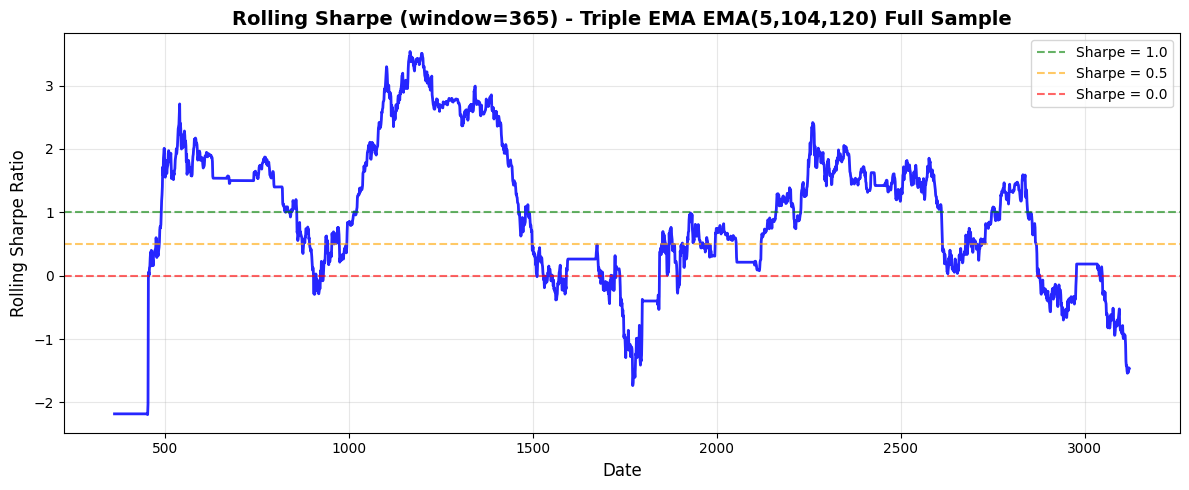

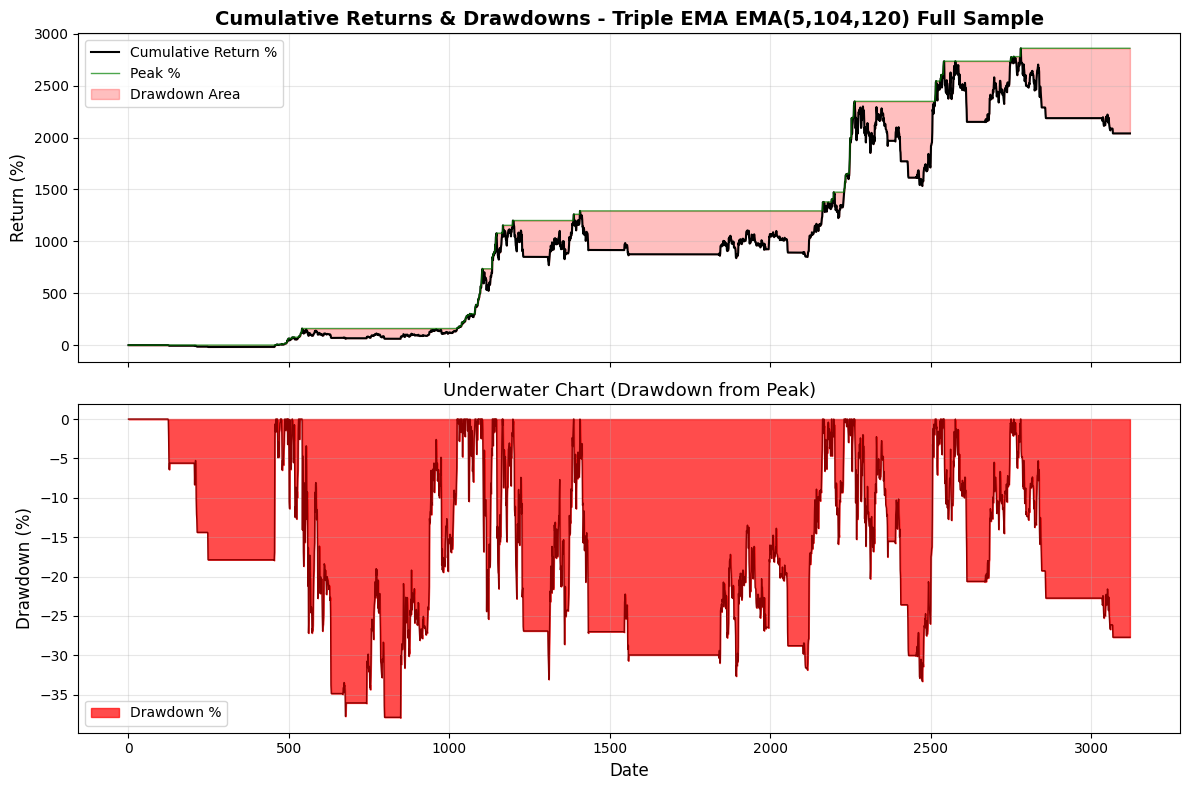

Rolling Sharpe and Drawdown analysis complete for: Triple EMA EMA(5,104,120)


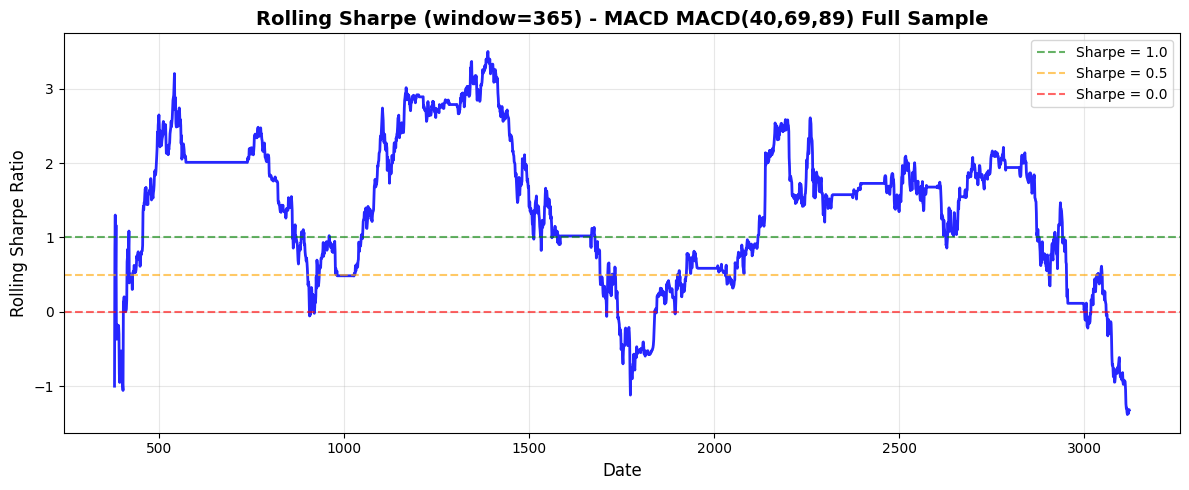

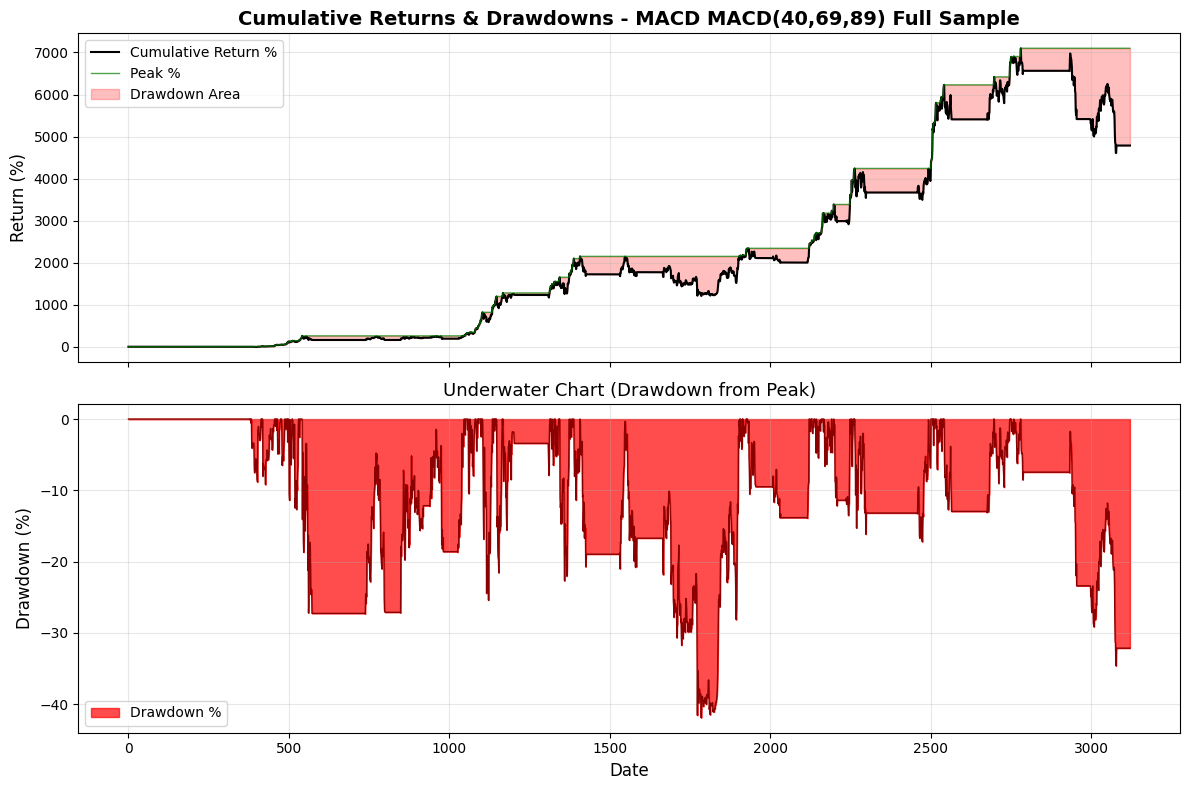

Rolling Sharpe and Drawdown analysis complete for: MACD MACD(40,69,89)


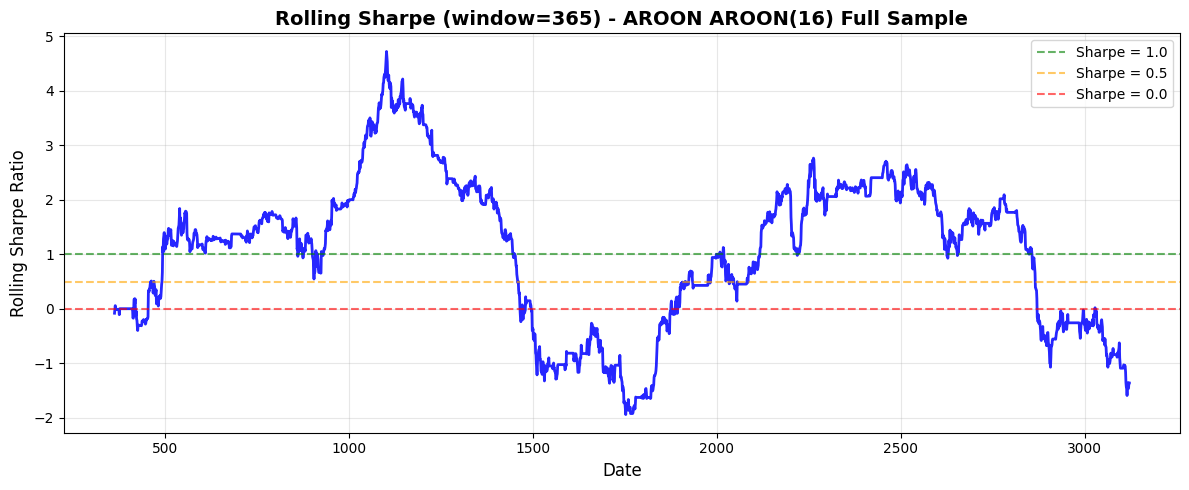

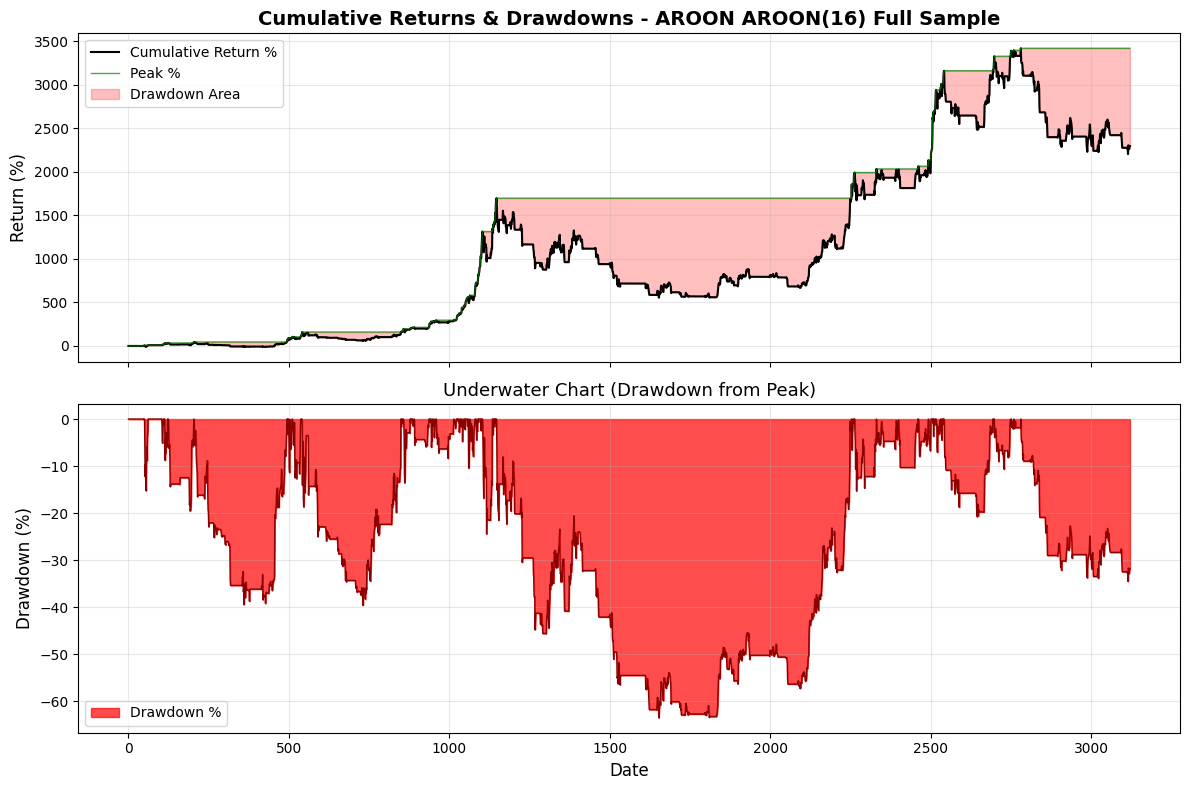

Rolling Sharpe and Drawdown analysis complete for: AROON AROON(16)


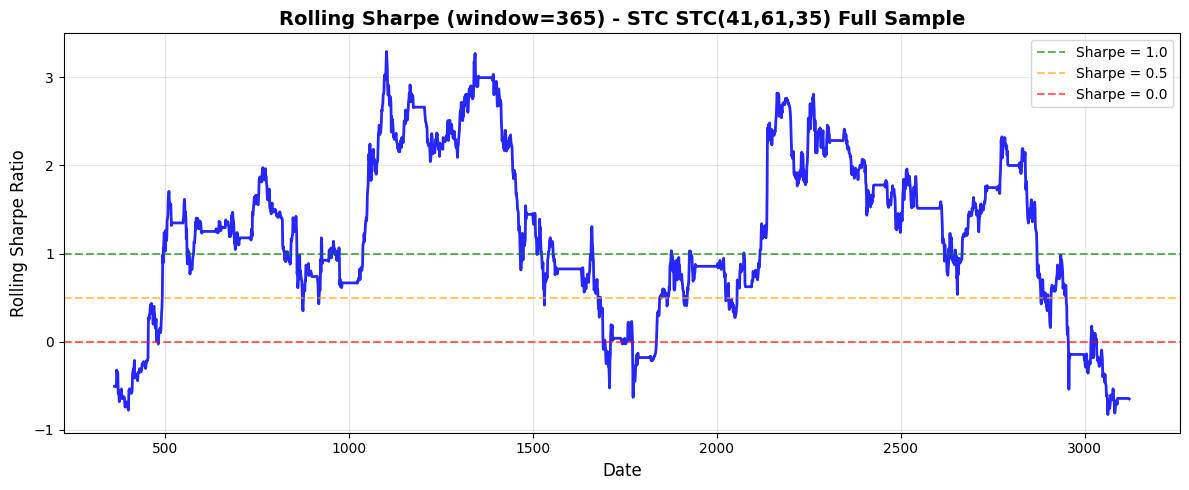

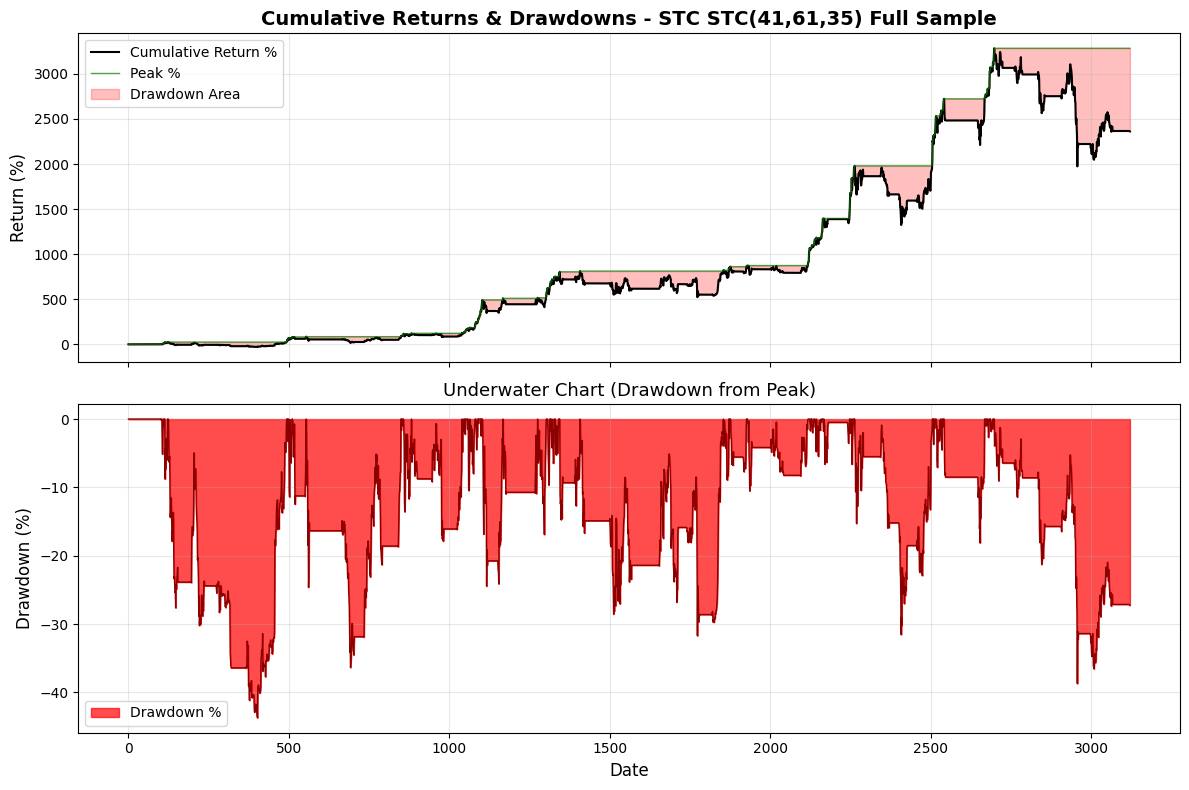

Rolling Sharpe and Drawdown analysis complete for: STC STC(41,61,35)


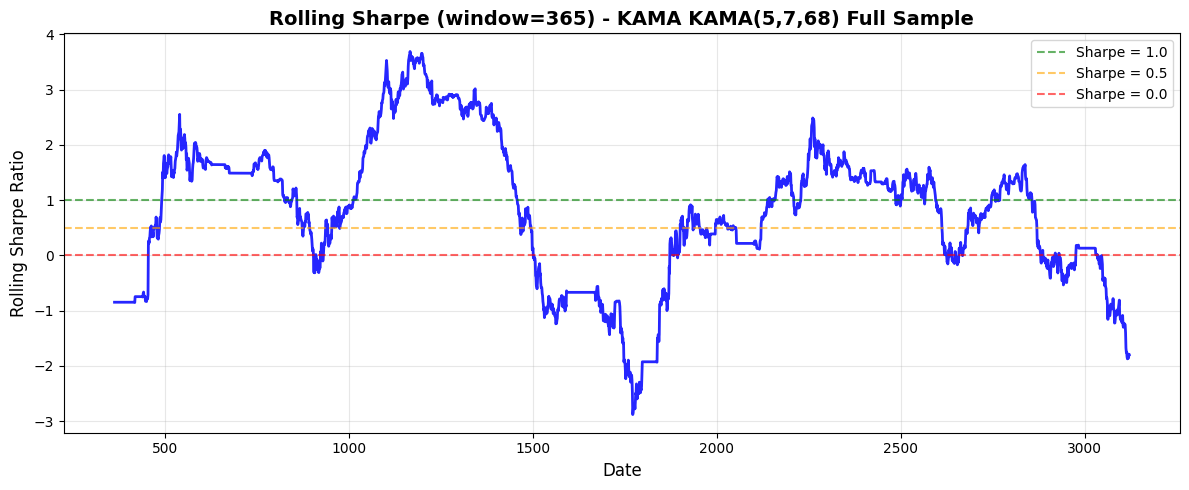

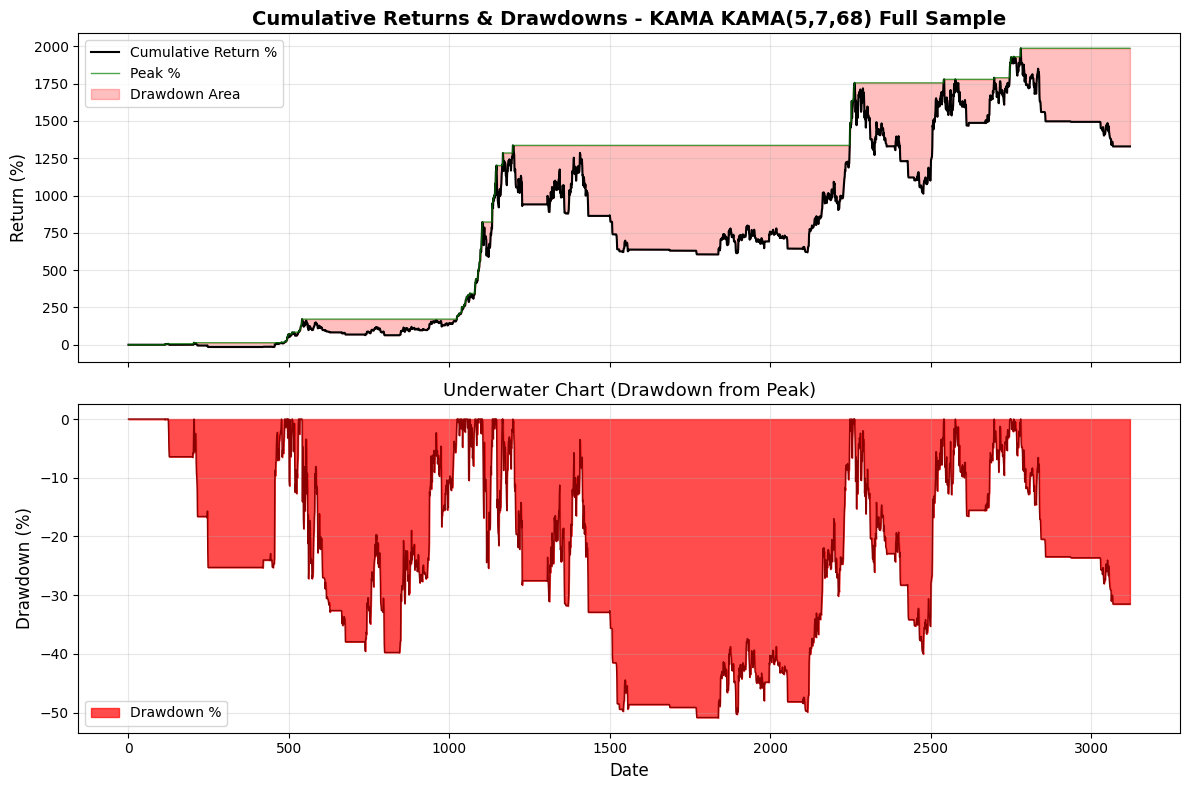

Rolling Sharpe and Drawdown analysis complete for: KAMA KAMA(5,7,68)


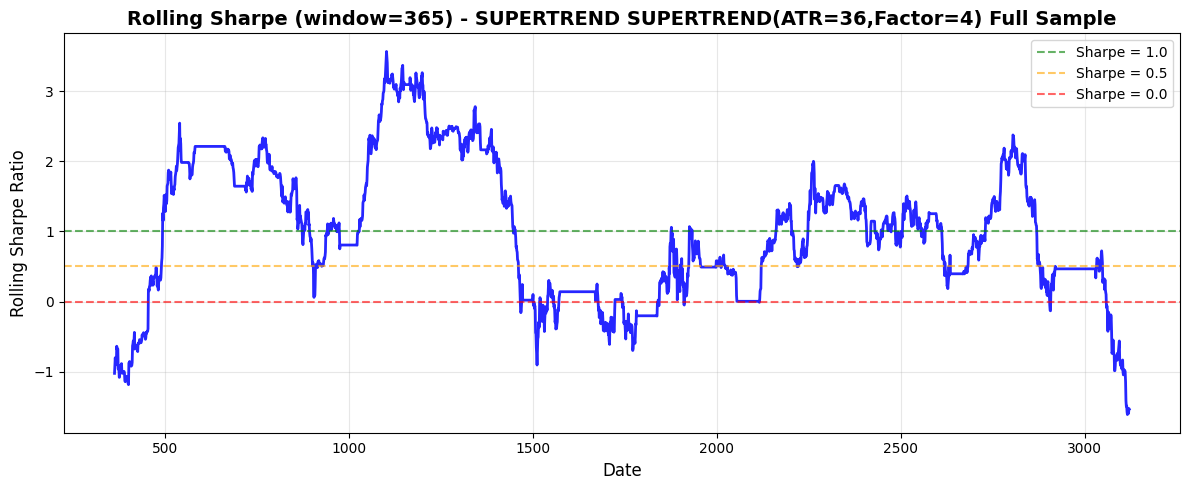

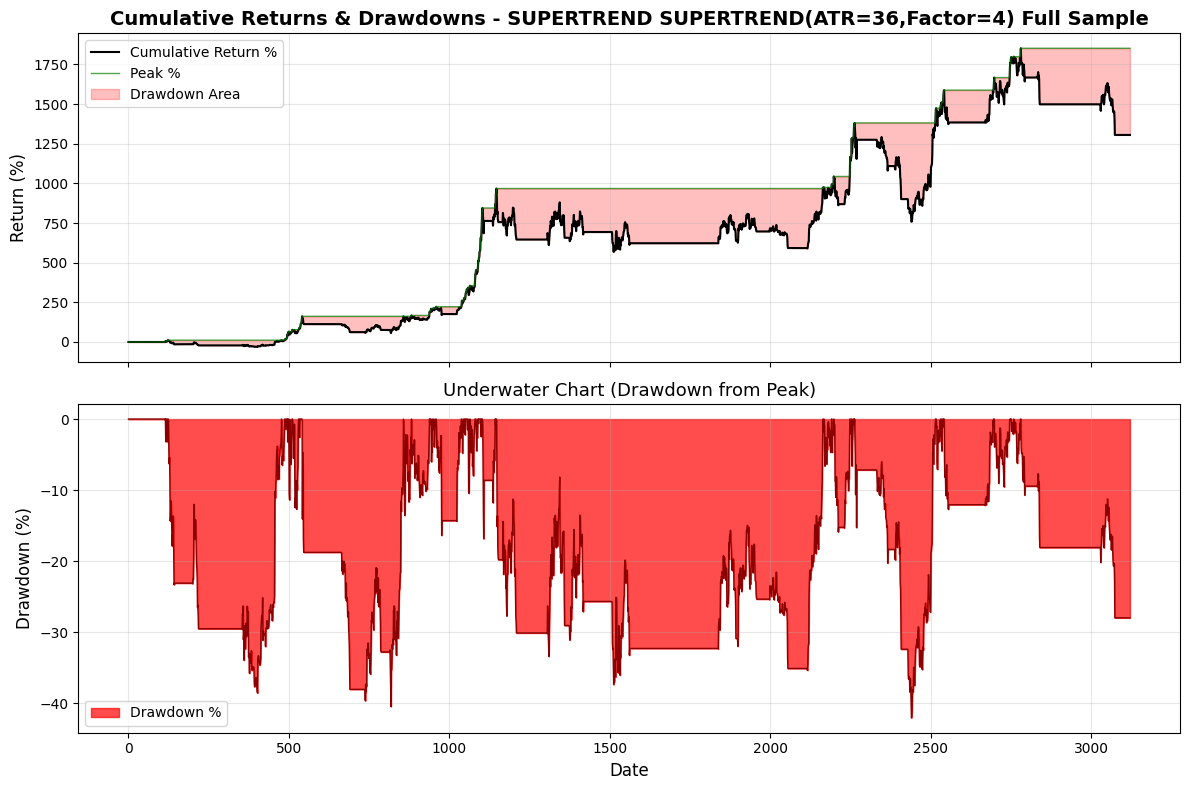

Rolling Sharpe and Drawdown analysis complete for: SUPERTREND SUPERTREND(ATR=36,Factor=4)


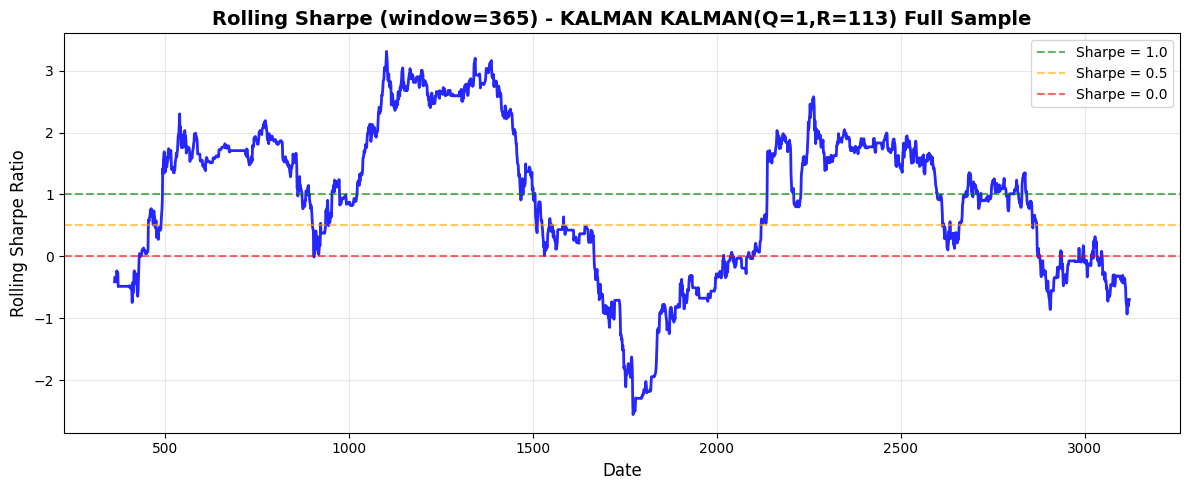

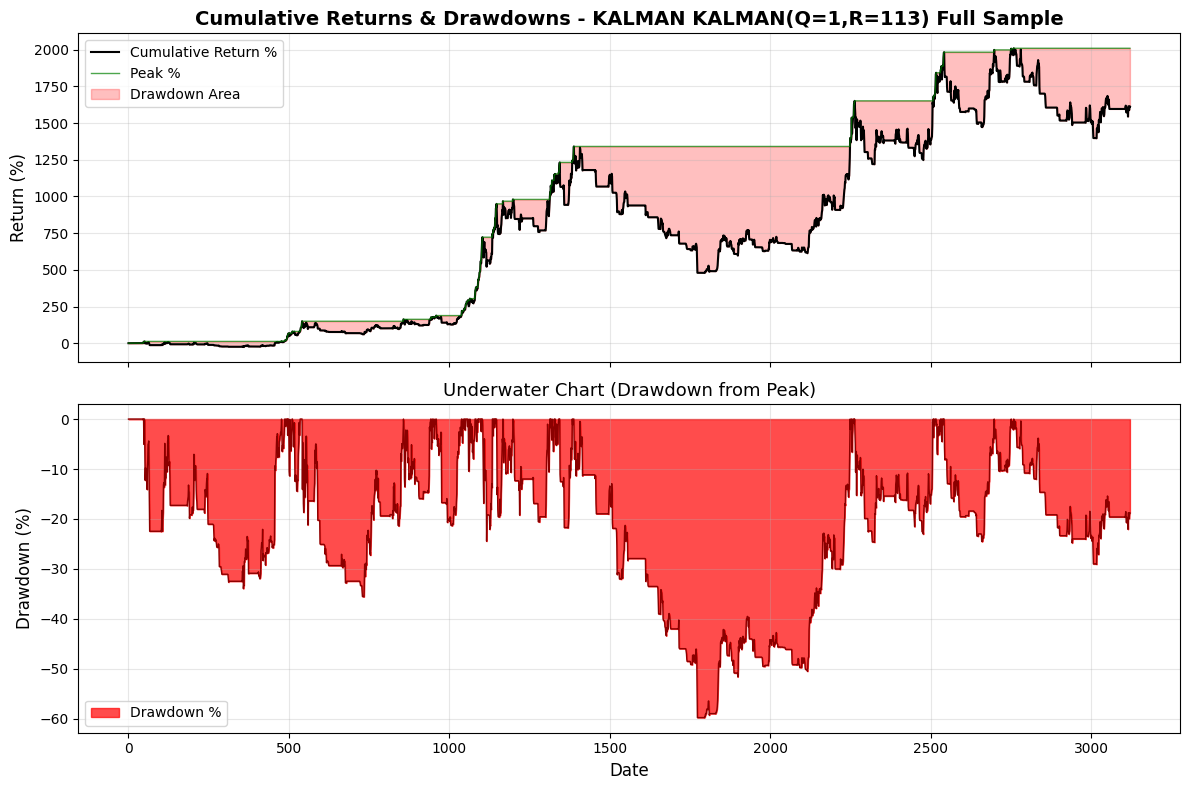

Rolling Sharpe and Drawdown analysis complete for: KALMAN KALMAN(Q=1,R=113)


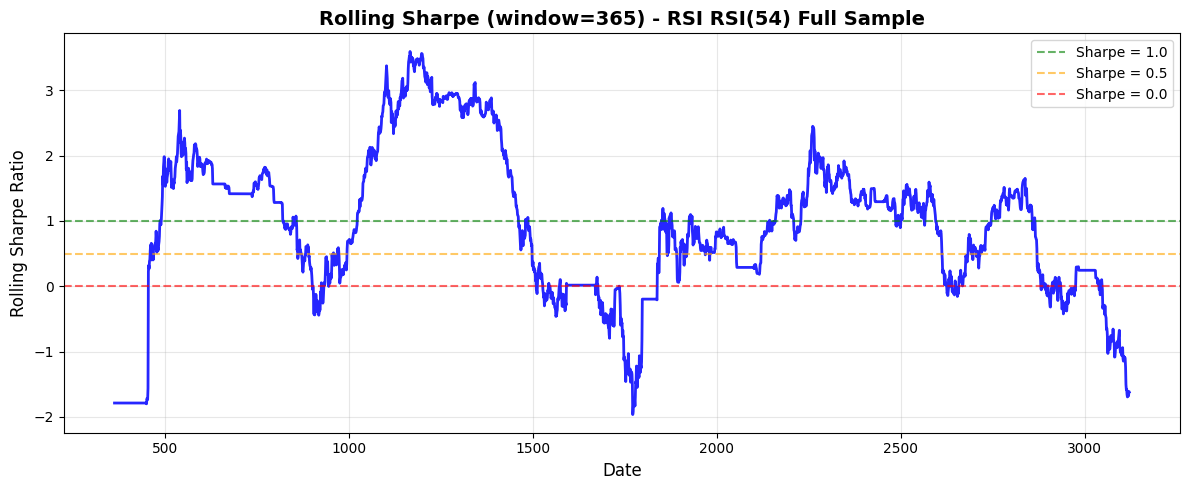

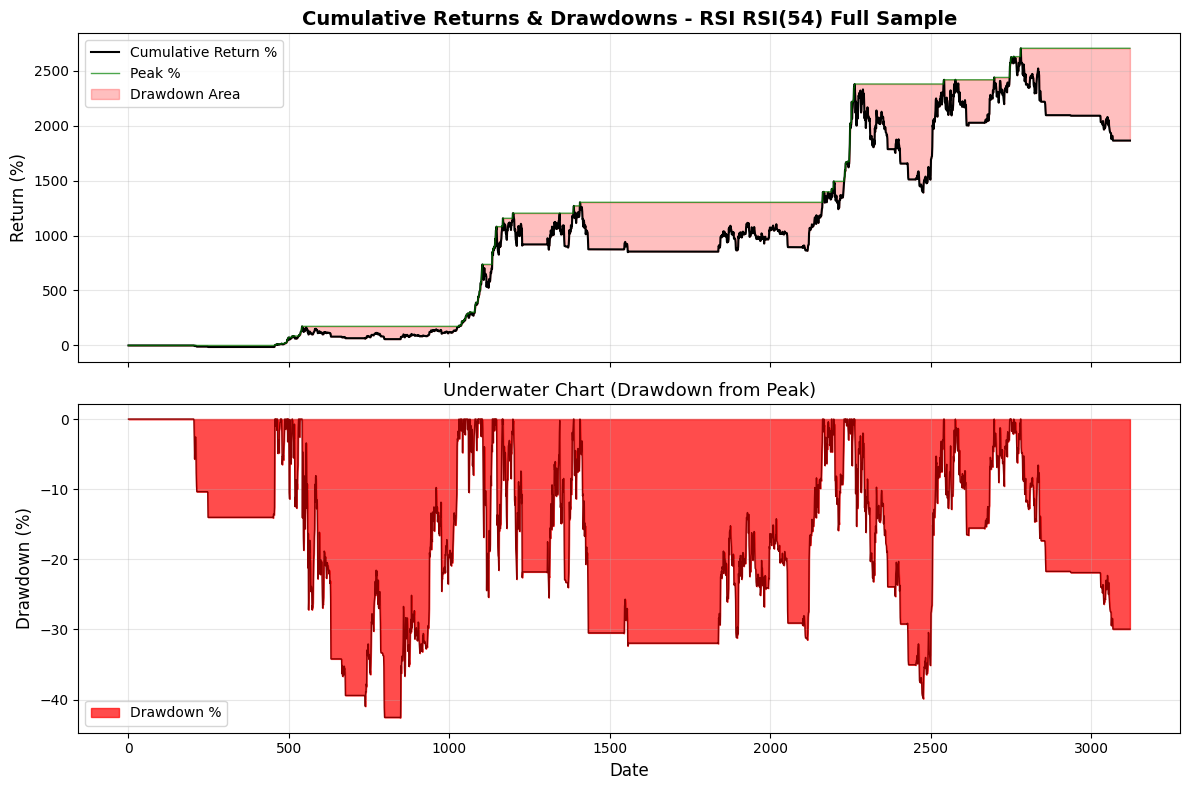

Rolling Sharpe and Drawdown analysis complete for: RSI RSI(54)


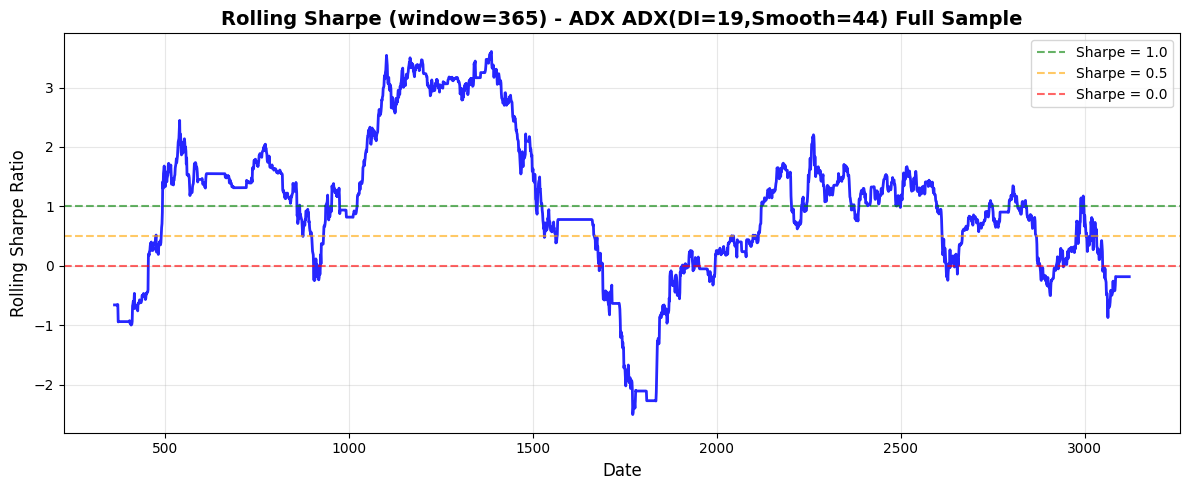

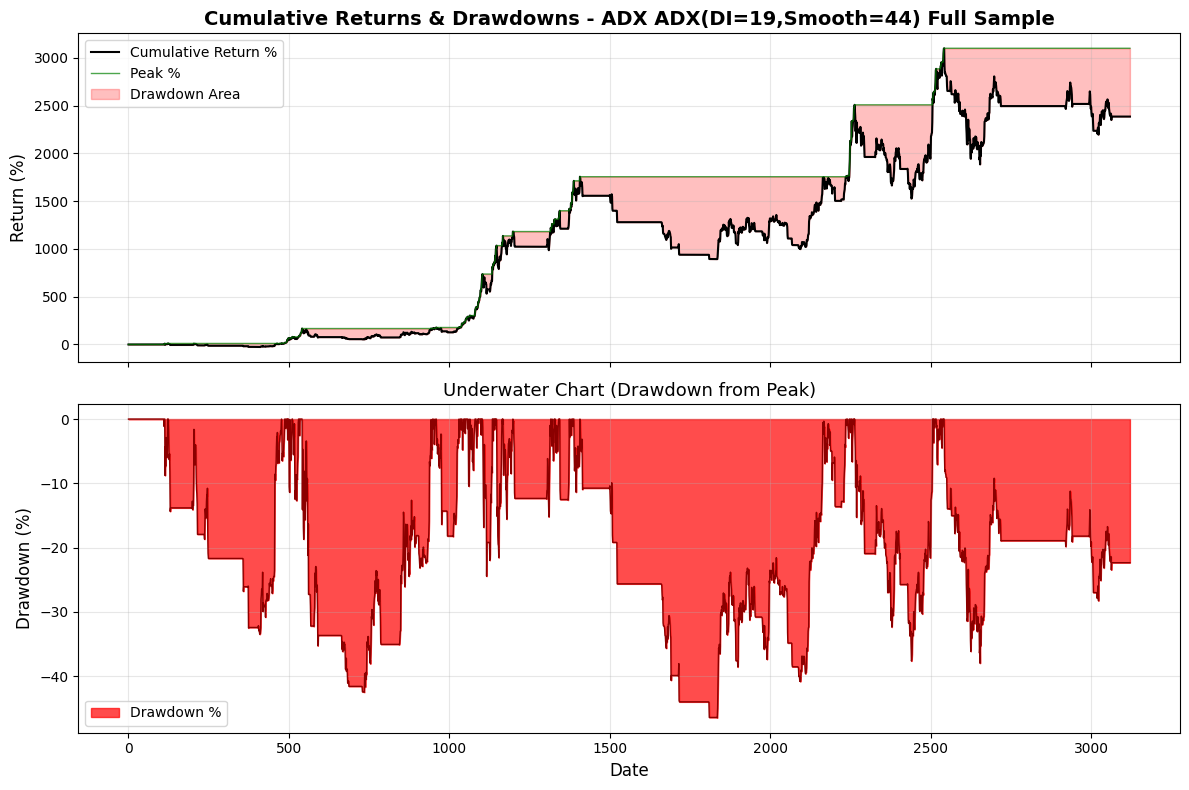

Rolling Sharpe and Drawdown analysis complete for: ADX ADX(DI=19,Smooth=44)


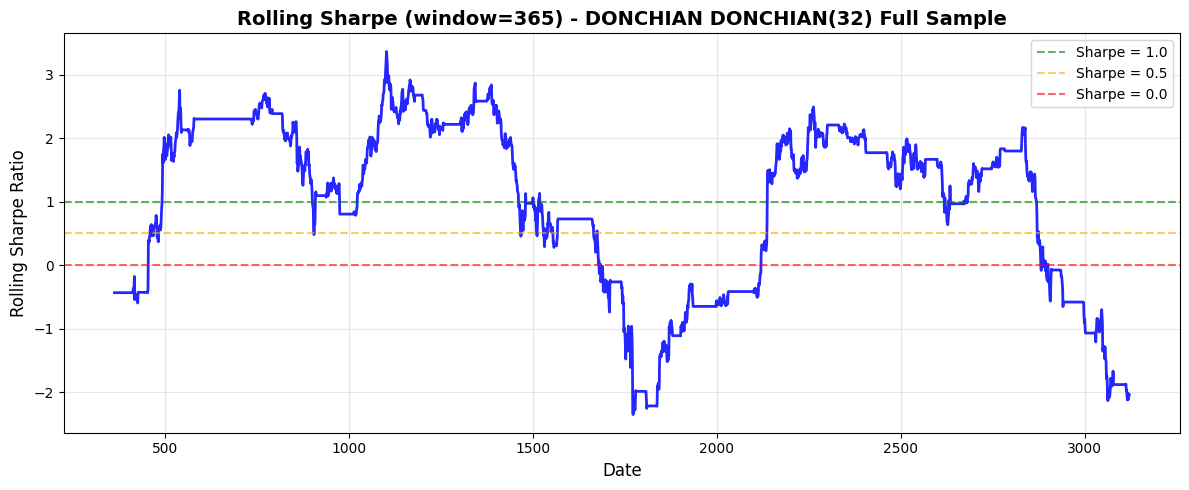

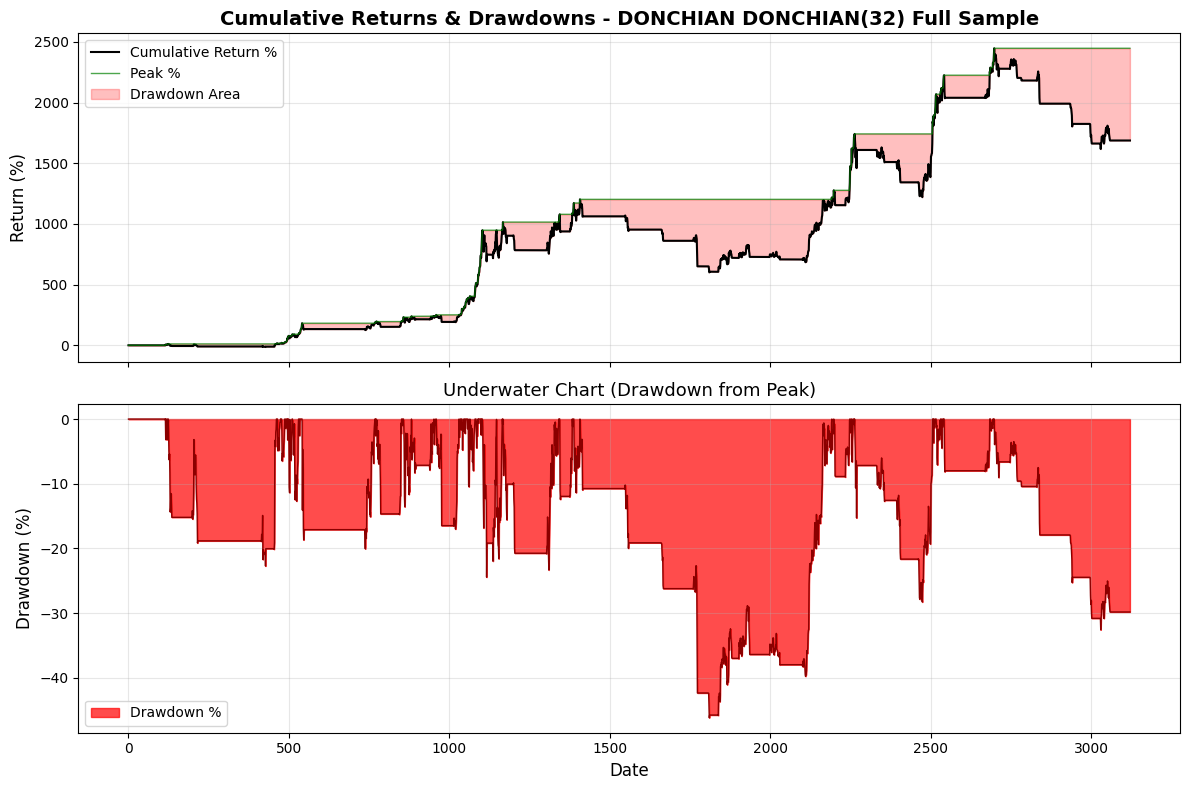

Rolling Sharpe and Drawdown analysis complete for: DONCHIAN DONCHIAN(32)


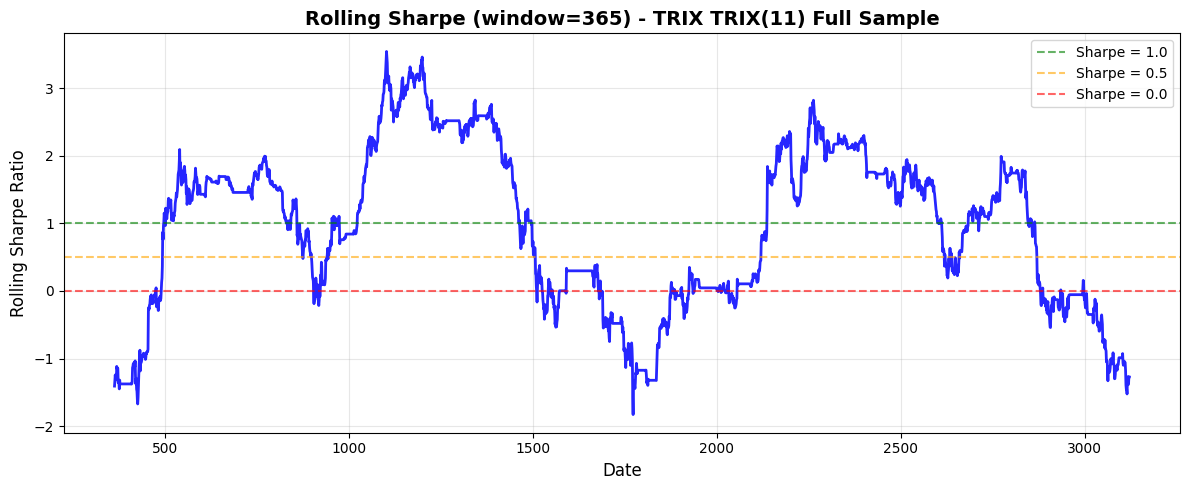

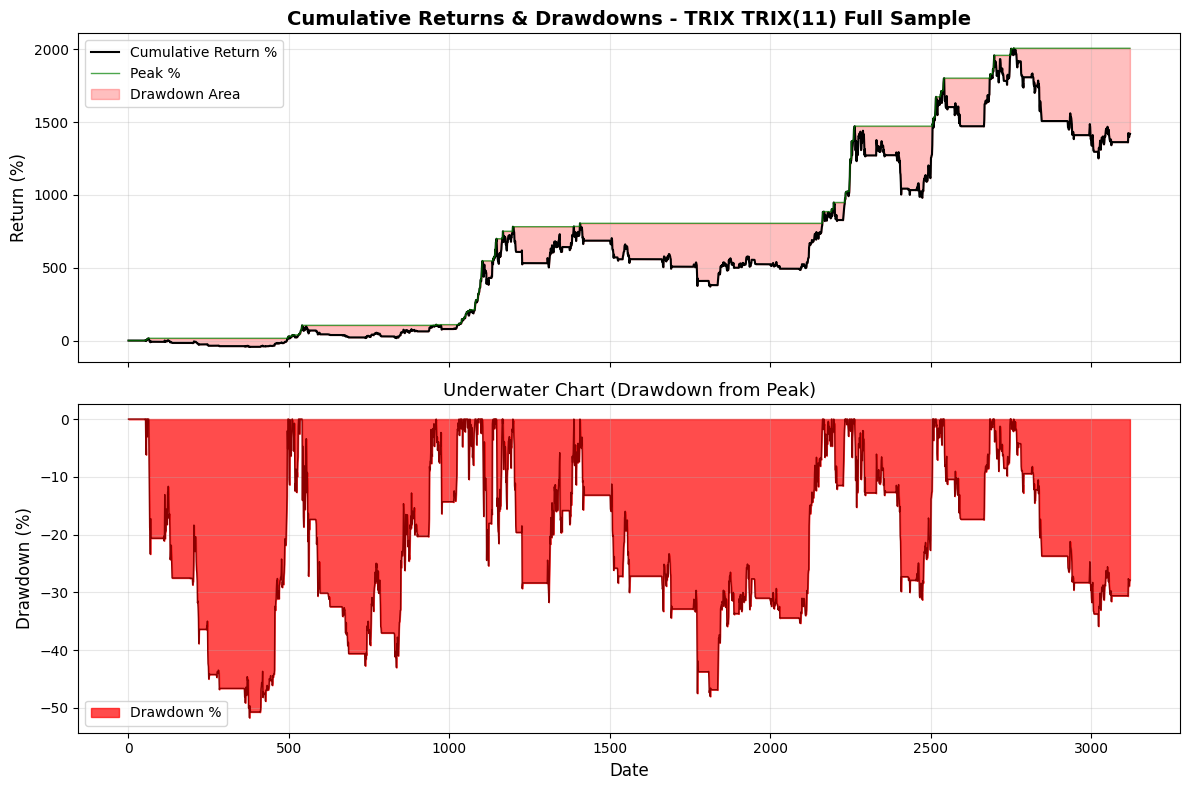

Rolling Sharpe and Drawdown analysis complete for: TRIX TRIX(11)


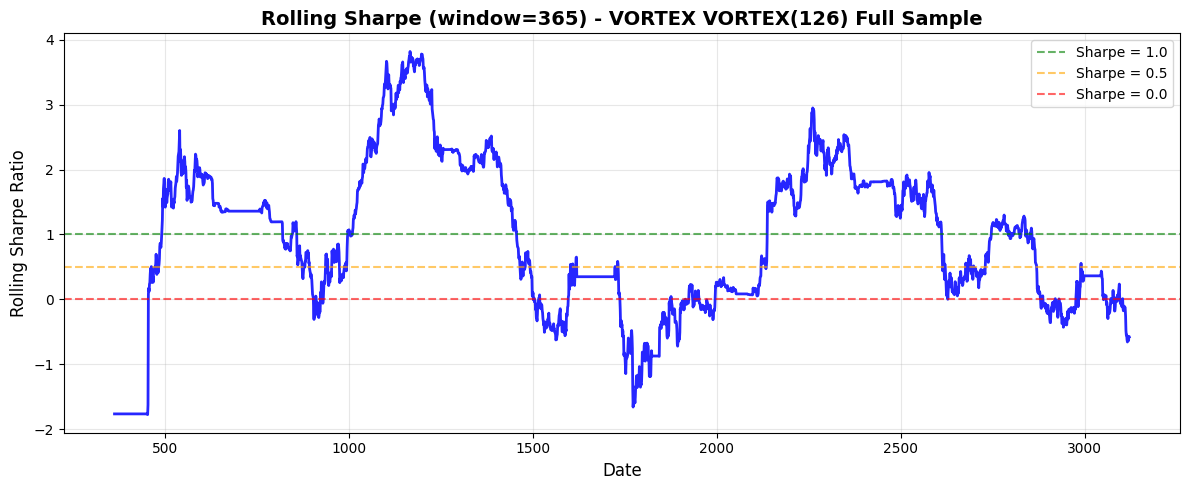

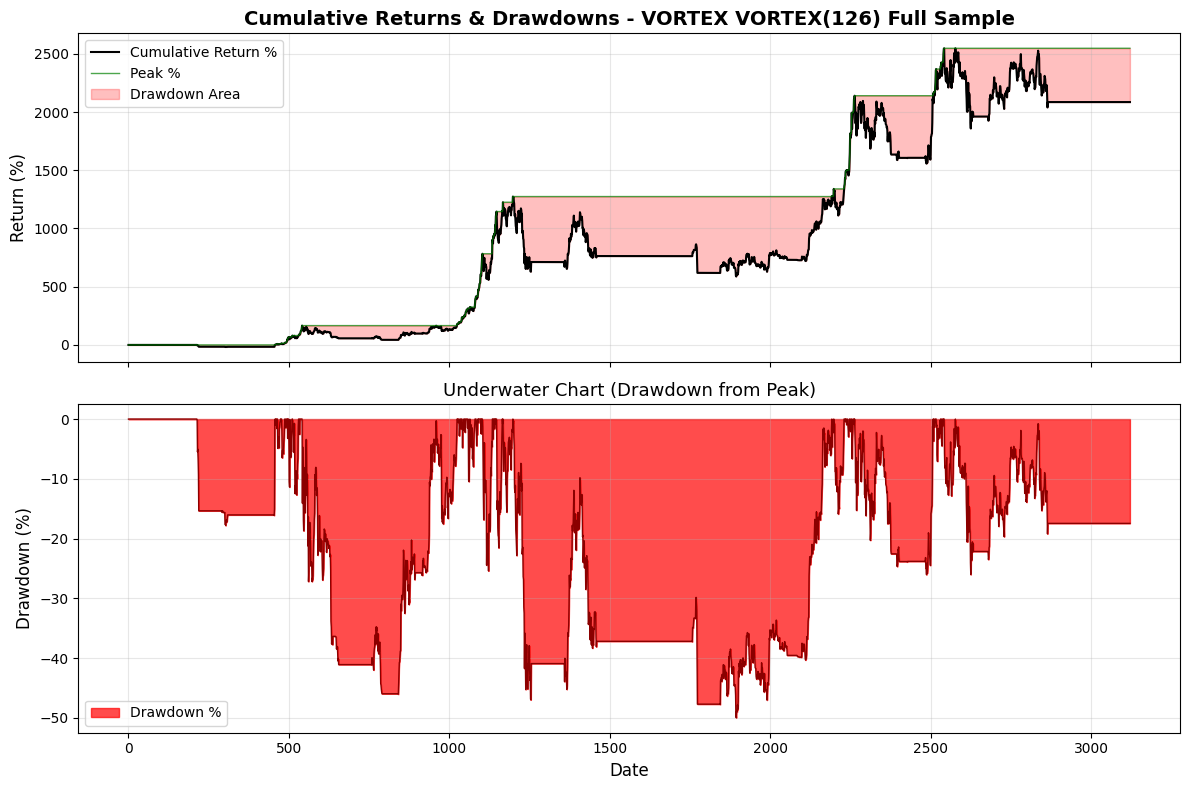

Rolling Sharpe and Drawdown analysis complete for: VORTEX VORTEX(126)


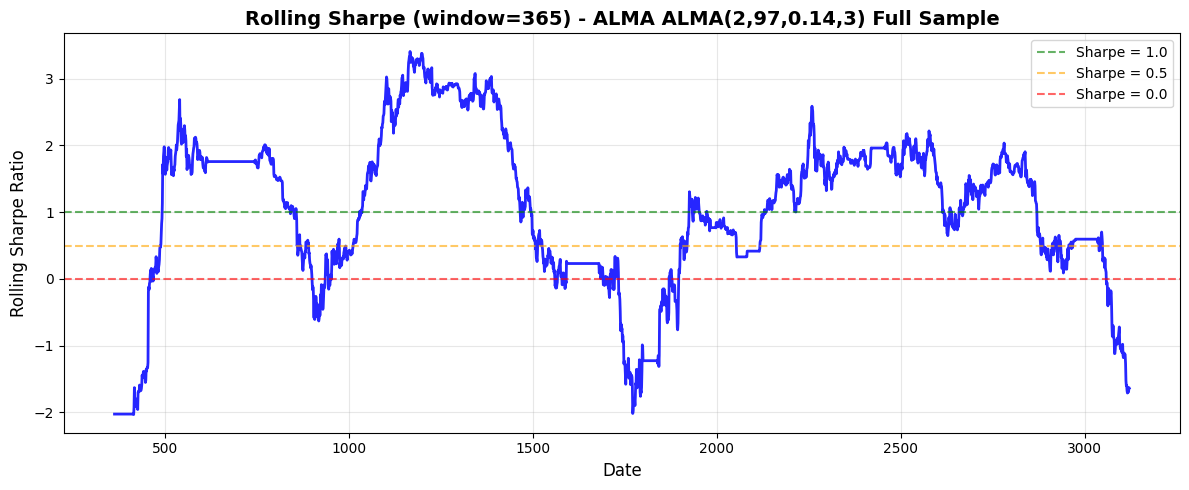

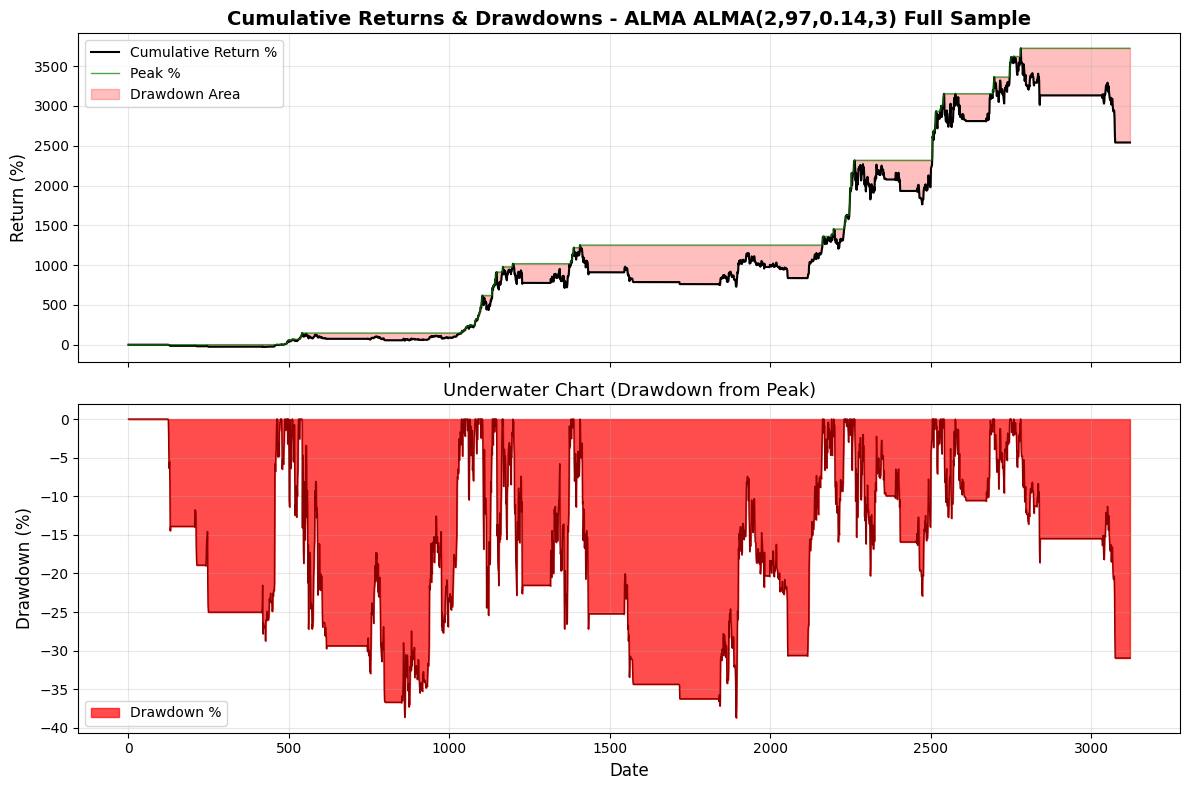

Rolling Sharpe and Drawdown analysis complete for: ALMA ALMA(2,97,0.14,3)


In [15]:
# FULL-SAMPLE ROLLING SHARPE + DRAWDOWNS - for all strategies

# Prefer stored per-indicator best strategies (OOS-best when available, else best IS).
strategies_to_plot = []
if "best_by_indicator" in globals() and best_by_indicator:
    for indicator_name, info in best_by_indicator.items():
        try:
            params = require_params_dict(info["params"], indicator_name)
        except (TypeError, KeyError, ValueError) as exc:
            print(f"{indicator_name}: skipping (invalid stored params: {exc})")
            continue
        strategies_to_plot.append((indicator_name, params, info["param_display"]))
elif "results_df" in globals() and not results_df.empty:
    for indicator_name, indicator_results in results_df.groupby("indicator", sort=False):
        best = best_is_row(indicator_results)
        if best is None:
            continue
        try:
            params = require_params_dict(best["params"], indicator_name)
        except (TypeError, KeyError, ValueError) as exc:
            print(f"{indicator_name}: skipping (invalid IS params: {exc})")
            continue
        strategies_to_plot.append((indicator_name, params, best["param_display"]))

if not strategies_to_plot:
    print("No results to visualize.")
elif "close" not in globals() or close is None or len(close) < 2:
    print("Close series missing or too short for rolling Sharpe / drawdown plots.")
else:
    # Reuse full-sample portfolios when available to avoid re-running identical backtests.
    fs_by_indicator = (
        full_sample_results_by_indicator
        if "full_sample_results_by_indicator" in globals() and full_sample_results_by_indicator
        else {}
    )
    # Window depends only on series length / annualization constants, so compute once.
    rolling_window = max(20, min(TRADING_DAYS_PER_YEAR, max(1, len(close) // 4)))

    for best_indicator, best_params, param_display in strategies_to_plot:
        best_label = f"{best_indicator} {param_display}"
        try:
            fs_result = fs_by_indicator.get(best_indicator)
            if fs_result is not None and fs_result.get("portfolio") is not None:
                pf_full = fs_result["portfolio"]
            else:
                best_spec = get_active_indicator_spec(best_indicator)
                entries_series, exits_series = best_spec["build_signals"](
                    close, best_params, shift_signals=True
                )
                pf_full = run_signal_backtest(close, entries_series, exits_series)

            ret = pf_full.returns()

            # 1) Rolling Sharpe (dynamic annualization window)
            if len(ret) > rolling_window:
                rolling_sharpe = ret.rolling(window=rolling_window).apply(
                    lambda x: (x.mean() * TRADING_DAYS_PER_YEAR) / (x.std() * np.sqrt(TRADING_DAYS_PER_YEAR)) if x.std() and x.std() != 0 else np.nan,
                    raw=False
                )

                plt.figure(figsize=(12, 5))
                plt.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2, color='blue', alpha=0.85)
                plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.6, label='Sharpe = 1.0')
                plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.6, label='Sharpe = 0.5')
                plt.axhline(y=0.0, color='red', linestyle='--', alpha=0.6, label='Sharpe = 0.0')
                plt.title(f'Rolling Sharpe (window={rolling_window}) - {best_label} Full Sample', fontsize=14, fontweight='bold')
                plt.xlabel('Date', fontsize=12)
                plt.ylabel('Rolling Sharpe Ratio', fontsize=12)
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                plt.show()
            else:
                print(f"Not enough data for rolling Sharpe calculation: {best_label}")

            # 2) Drawdowns (underwater)
            eq = (1 + ret).cumprod()
            peak = eq.cummax()
            dd = (eq - peak) / peak.replace(0, np.nan)

            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

            ax1.plot(eq.index, (eq - 1) * 100, color='black', linewidth=1.5, label='Cumulative Return %')
            ax1.plot(peak.index, (peak - 1) * 100, color='green', linewidth=1.0, alpha=0.7, label='Peak %')
            ax1.fill_between(eq.index, (eq - 1) * 100, (peak - 1) * 100, color='red', alpha=0.25, label='Drawdown Area')
            ax1.set_title(f'Cumulative Returns & Drawdowns - {best_label} Full Sample', fontsize=14, fontweight='bold')
            ax1.set_ylabel('Return (%)', fontsize=12)
            ax1.grid(True, alpha=0.3)
            ax1.legend()

            ax2.fill_between(dd.index, dd * 100, 0, color='red', alpha=0.7, label='Drawdown %')
            ax2.plot(dd.index, dd * 100, color='darkred', linewidth=1)
            ax2.set_title('Underwater Chart (Drawdown from Peak)', fontsize=13)
            ax2.set_xlabel('Date', fontsize=12)
            ax2.set_ylabel('Drawdown (%)', fontsize=12)
            ax2.grid(True, alpha=0.3)
            ax2.legend()

            plt.tight_layout()
            plt.show()

            print(f"Rolling Sharpe and Drawdown analysis complete for: {best_label}")
        except Exception as exc:
            print(f"{best_label}: rolling Sharpe / drawdown failed ({type(exc).__name__}: {exc})")


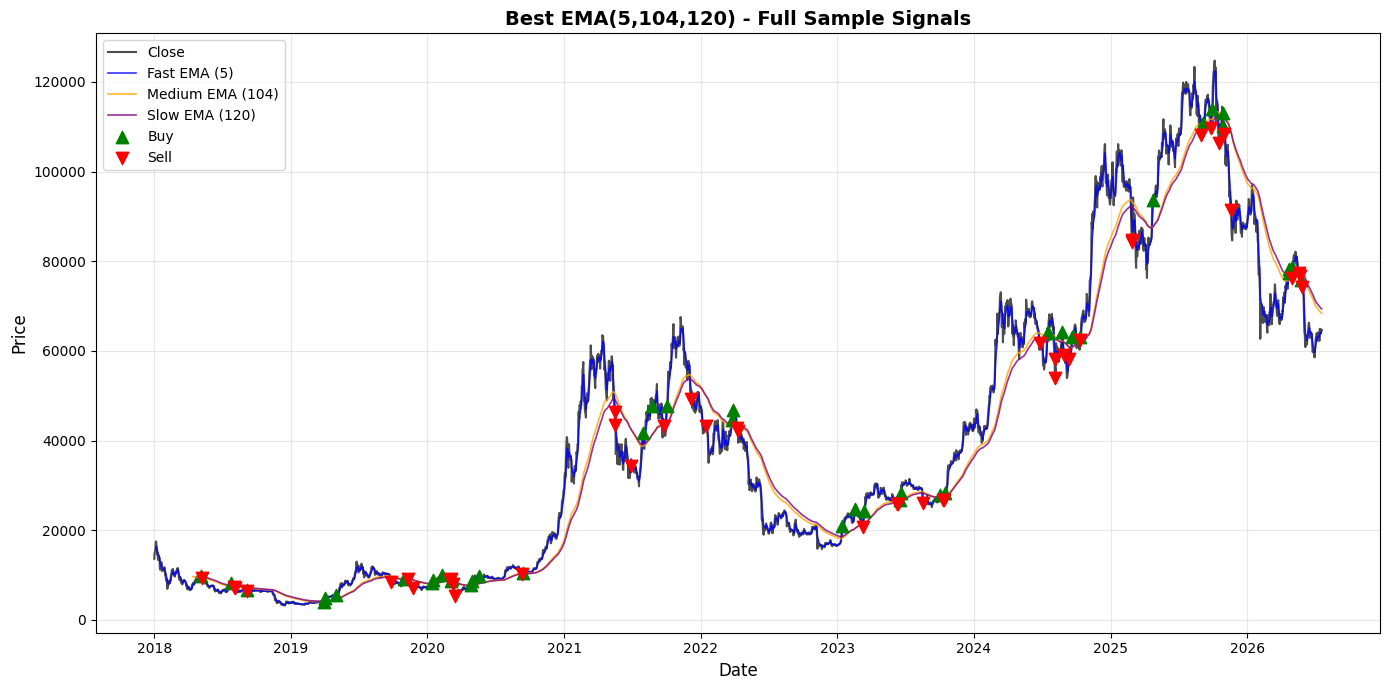

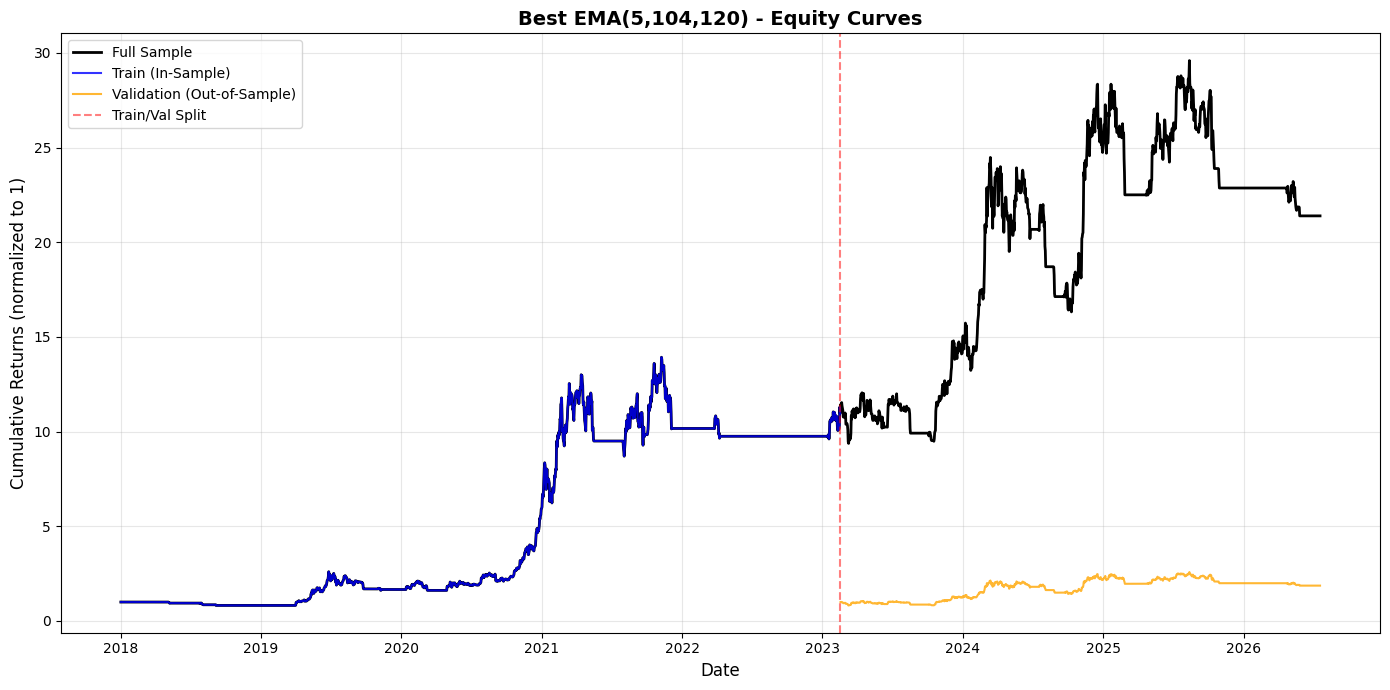

Visualizations complete for: Triple EMA EMA(5,104,120)


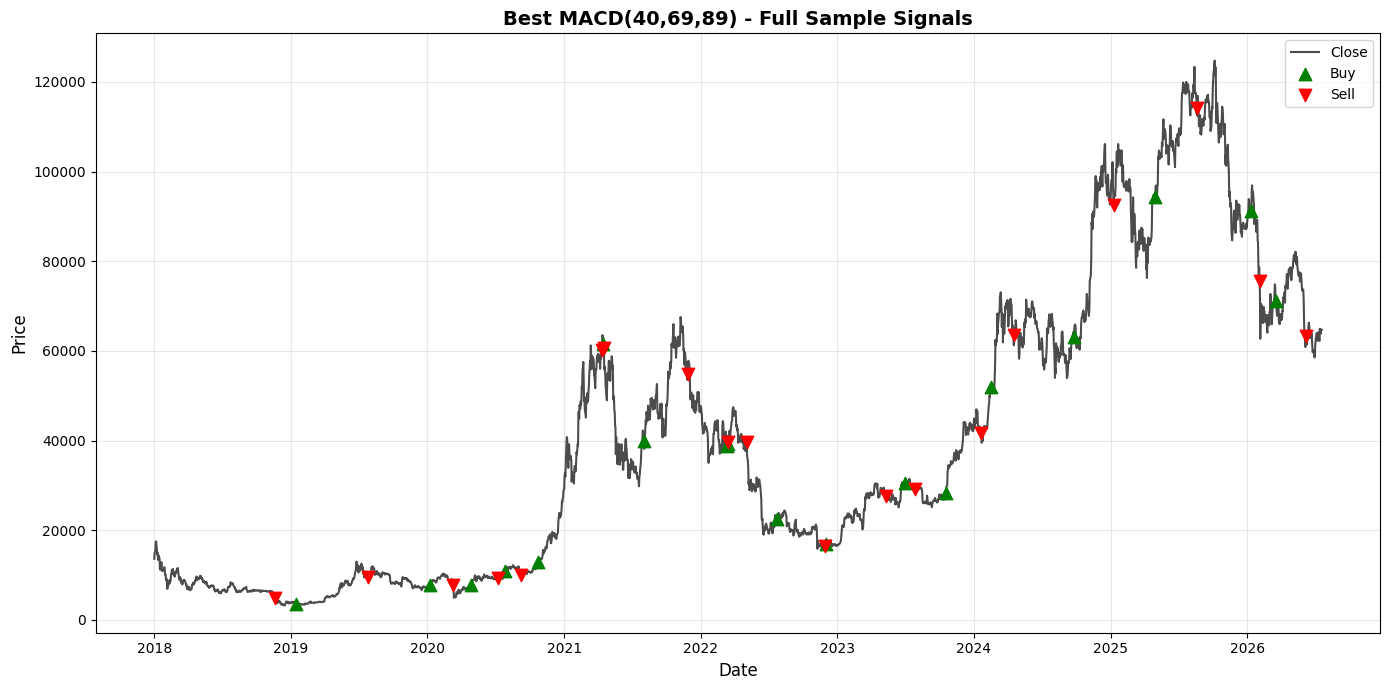

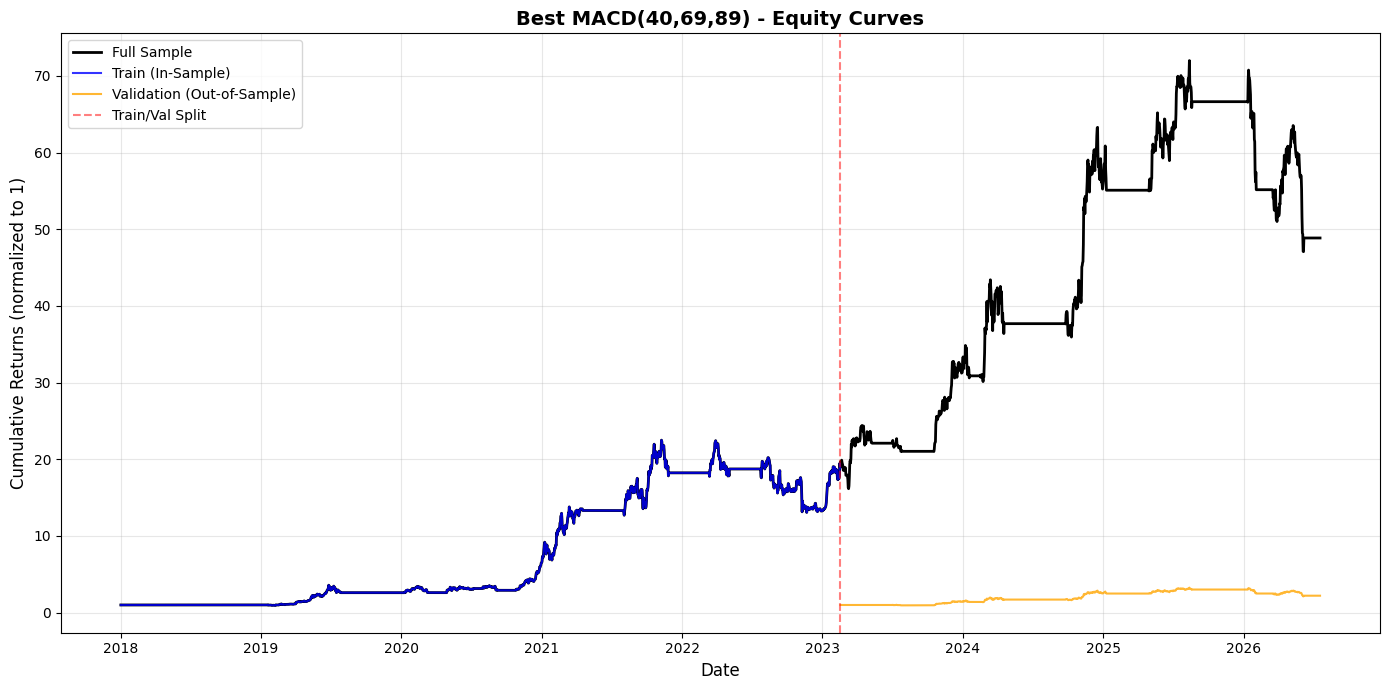

Visualizations complete for: MACD MACD(40,69,89)


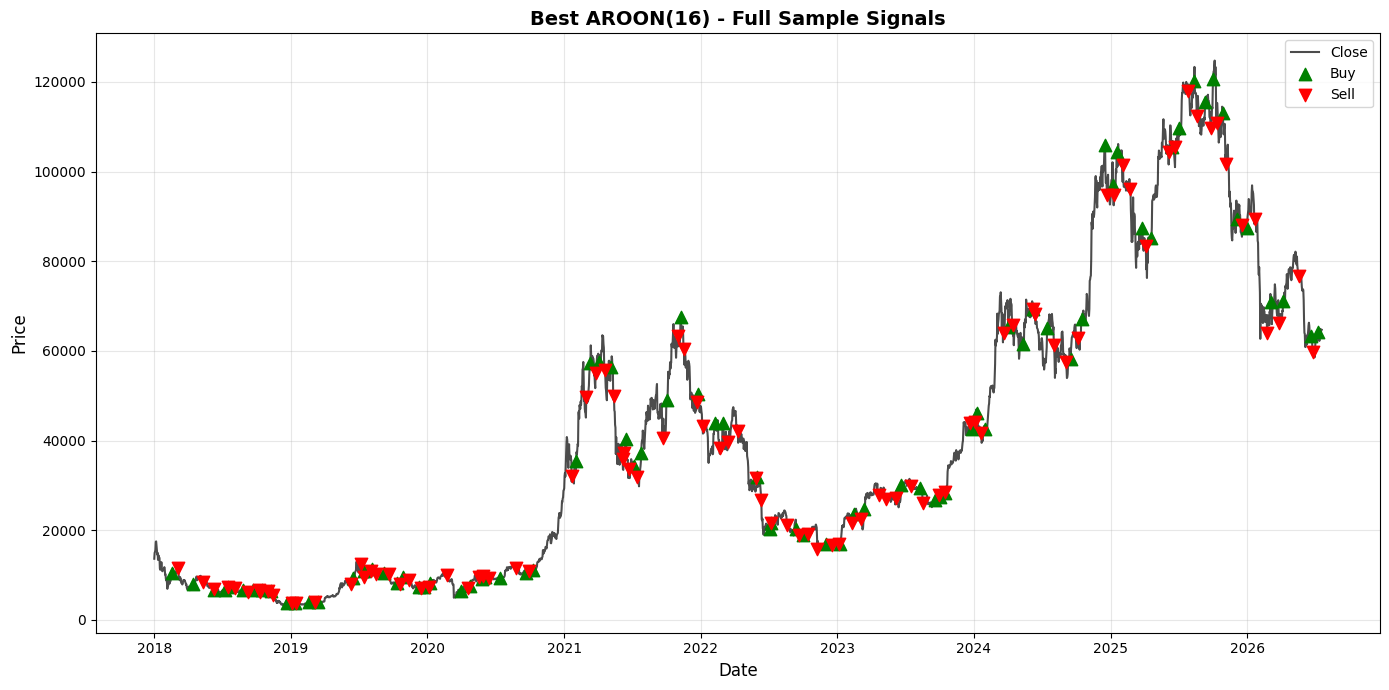

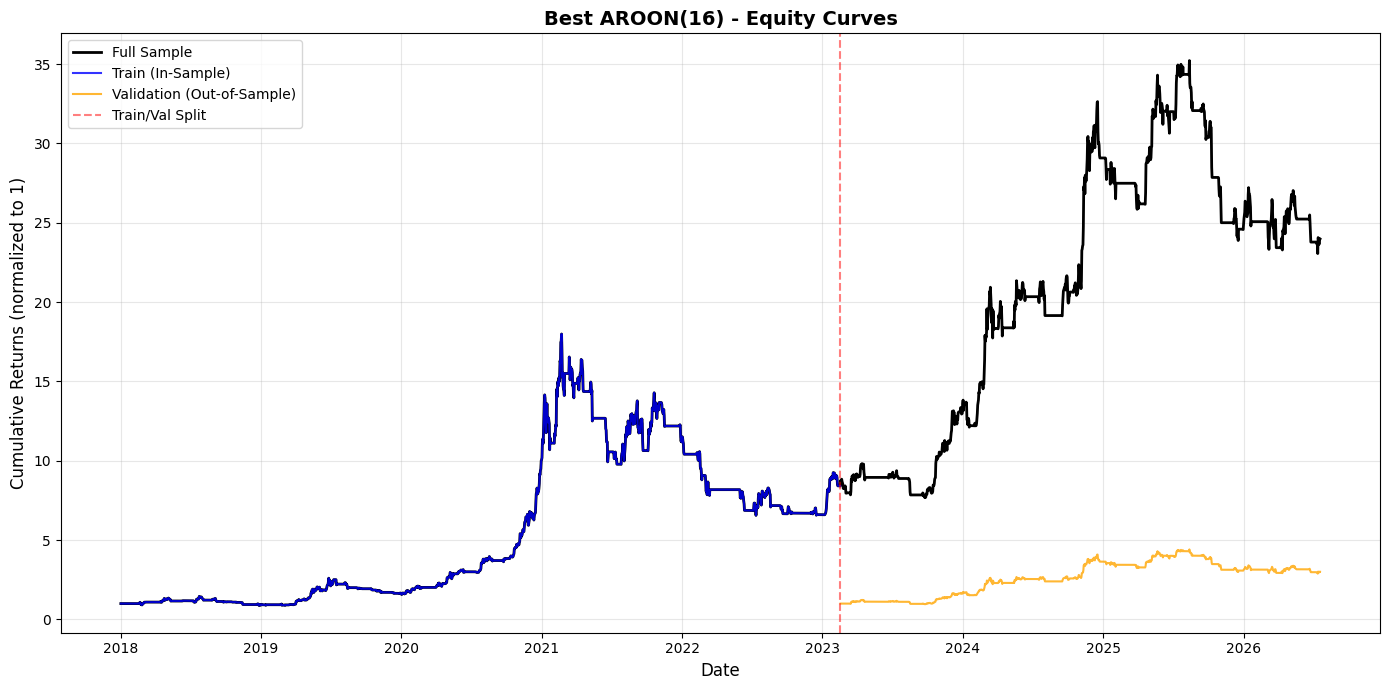

Visualizations complete for: AROON AROON(16)


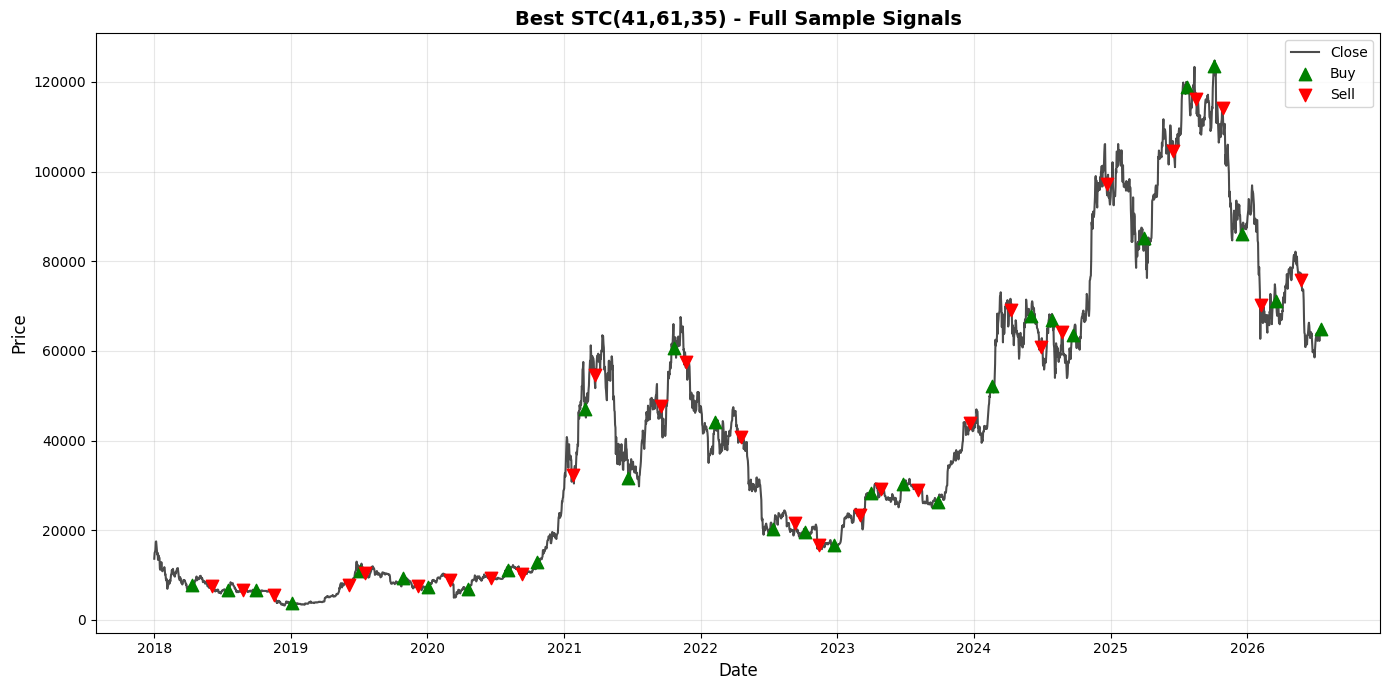

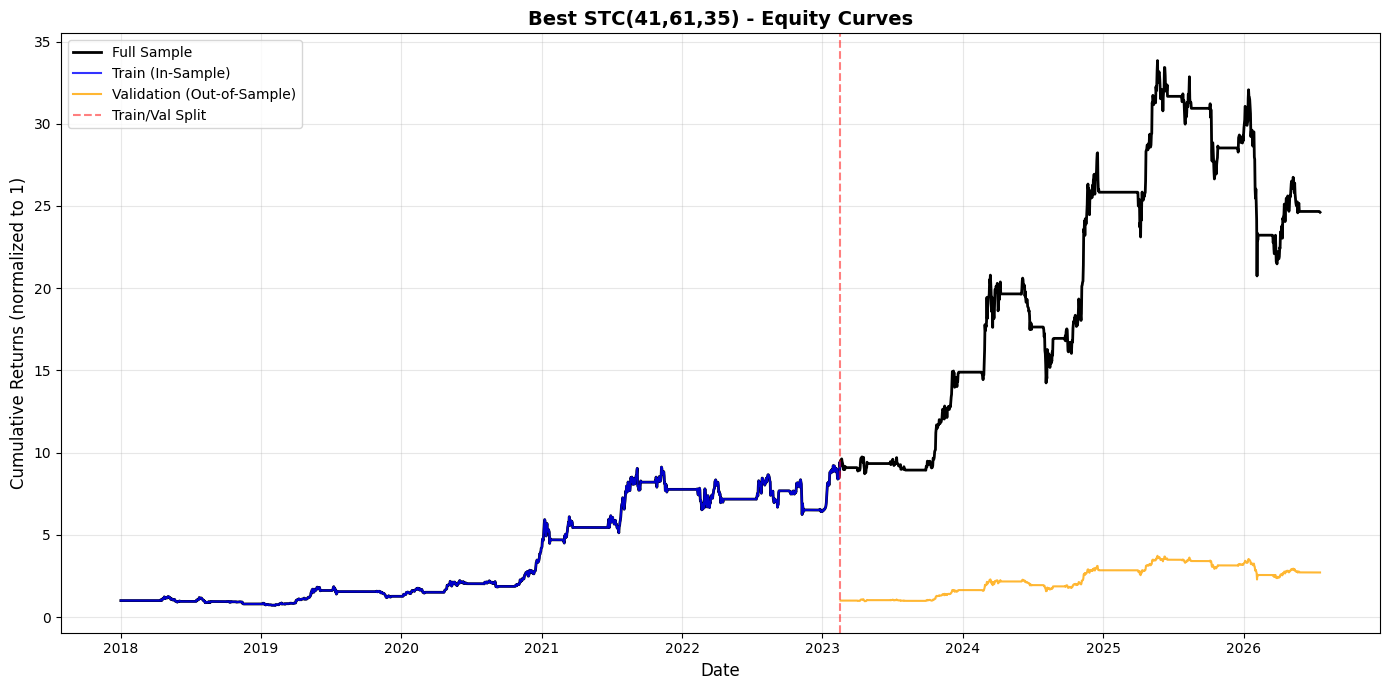

Visualizations complete for: STC STC(41,61,35)


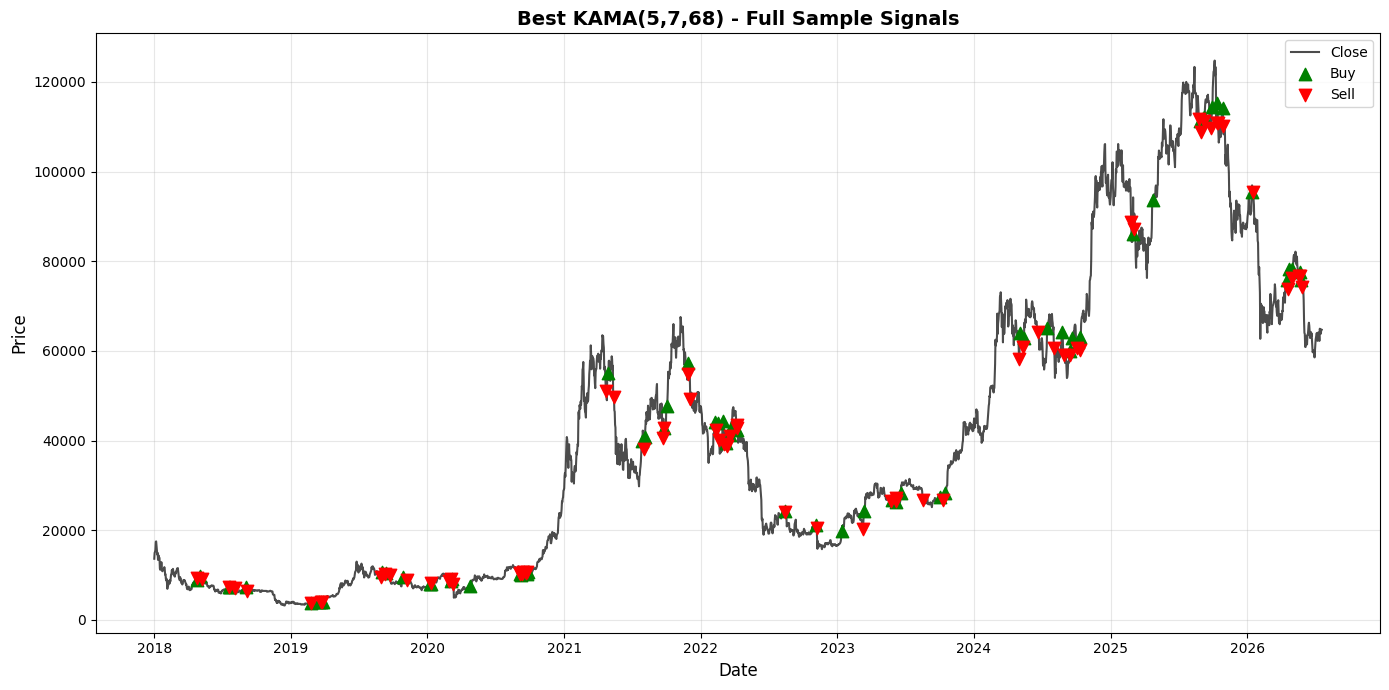

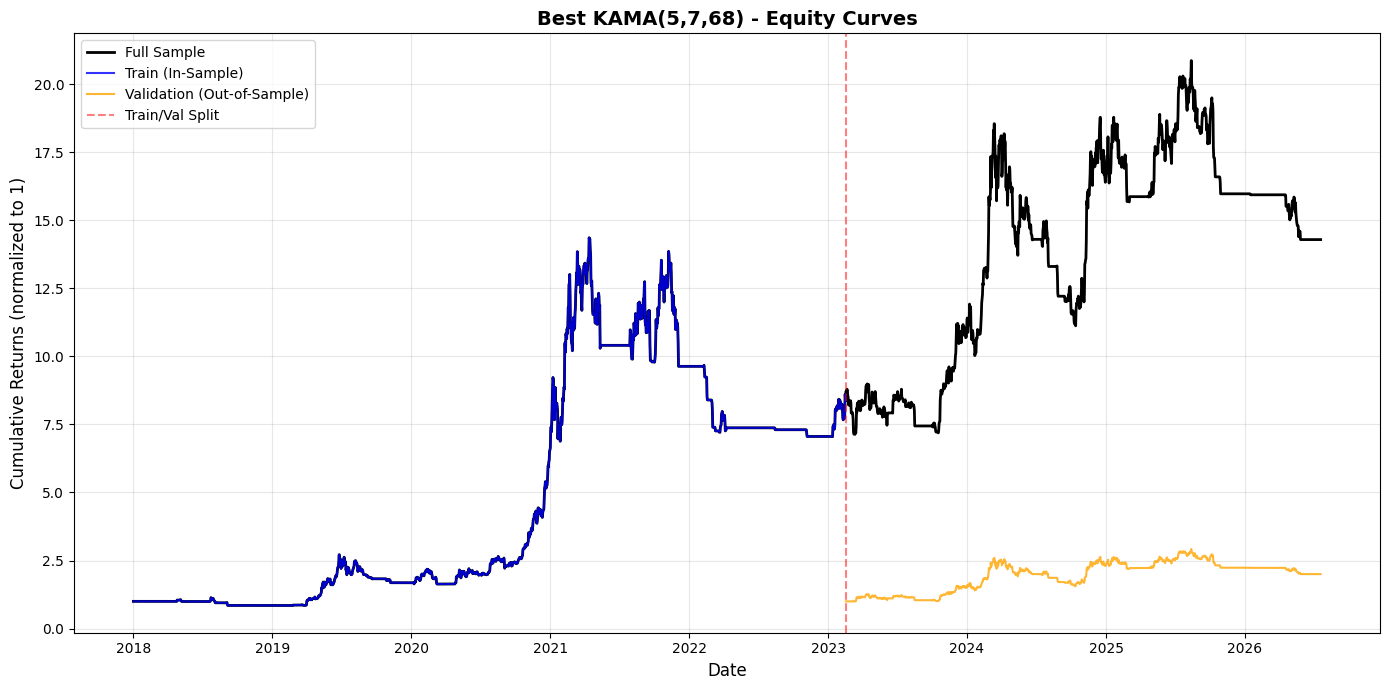

Visualizations complete for: KAMA KAMA(5,7,68)


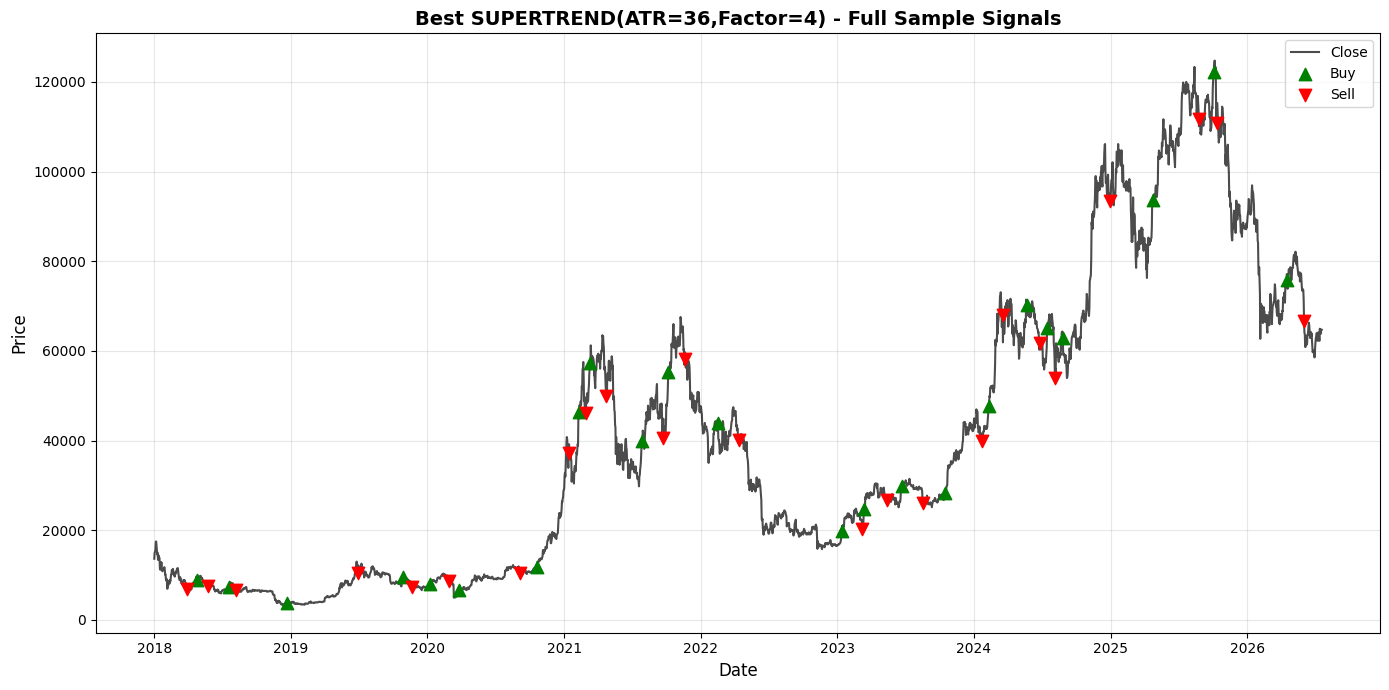

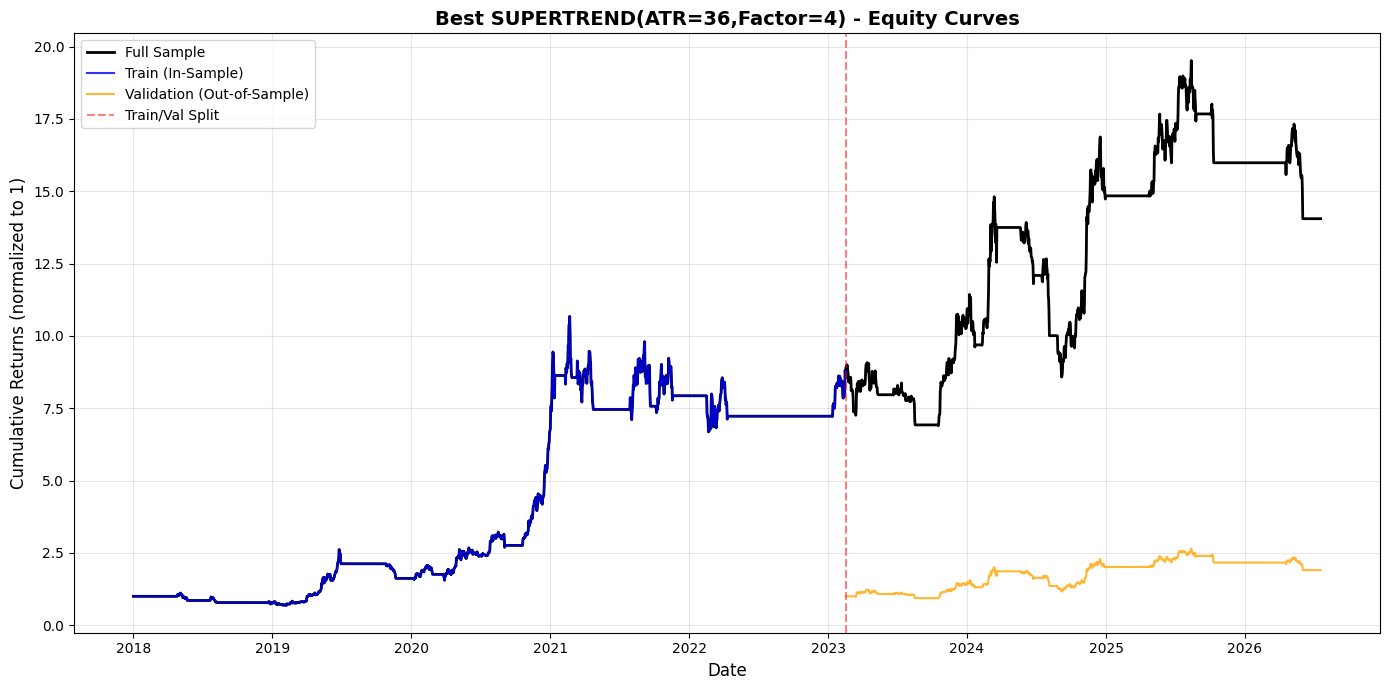

Visualizations complete for: SUPERTREND SUPERTREND(ATR=36,Factor=4)


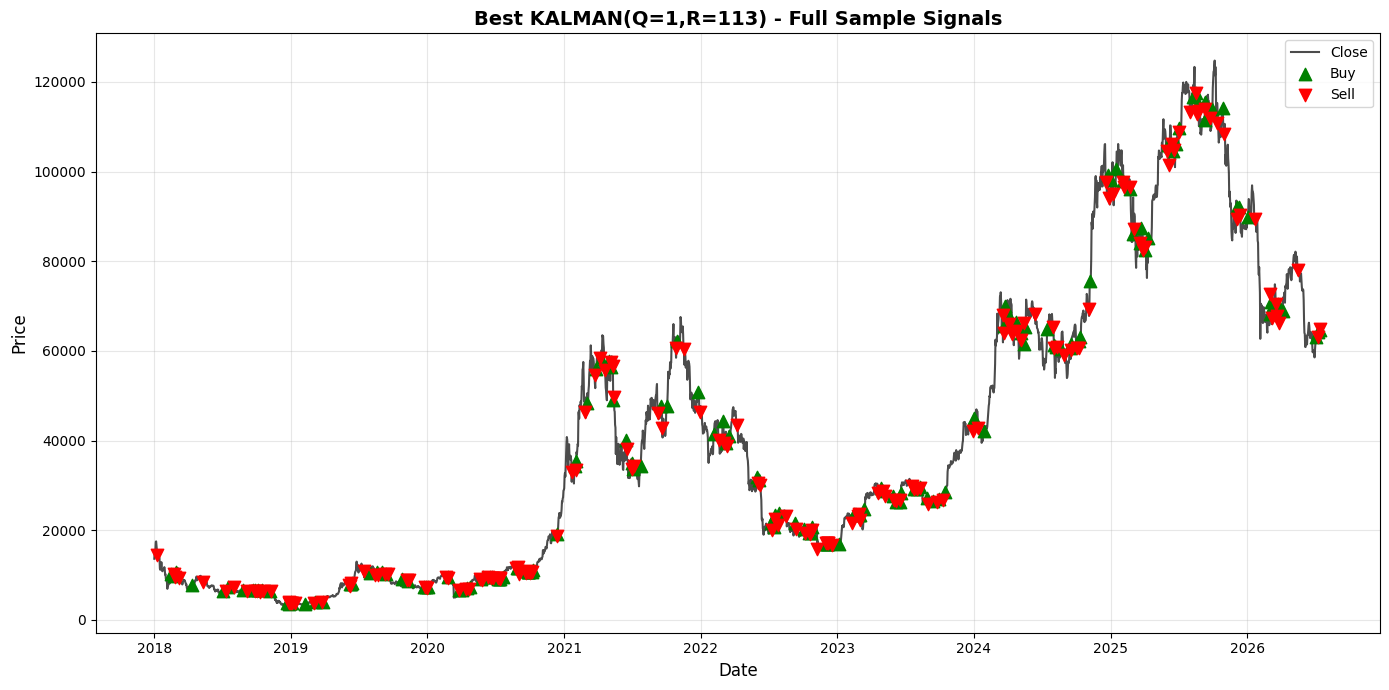

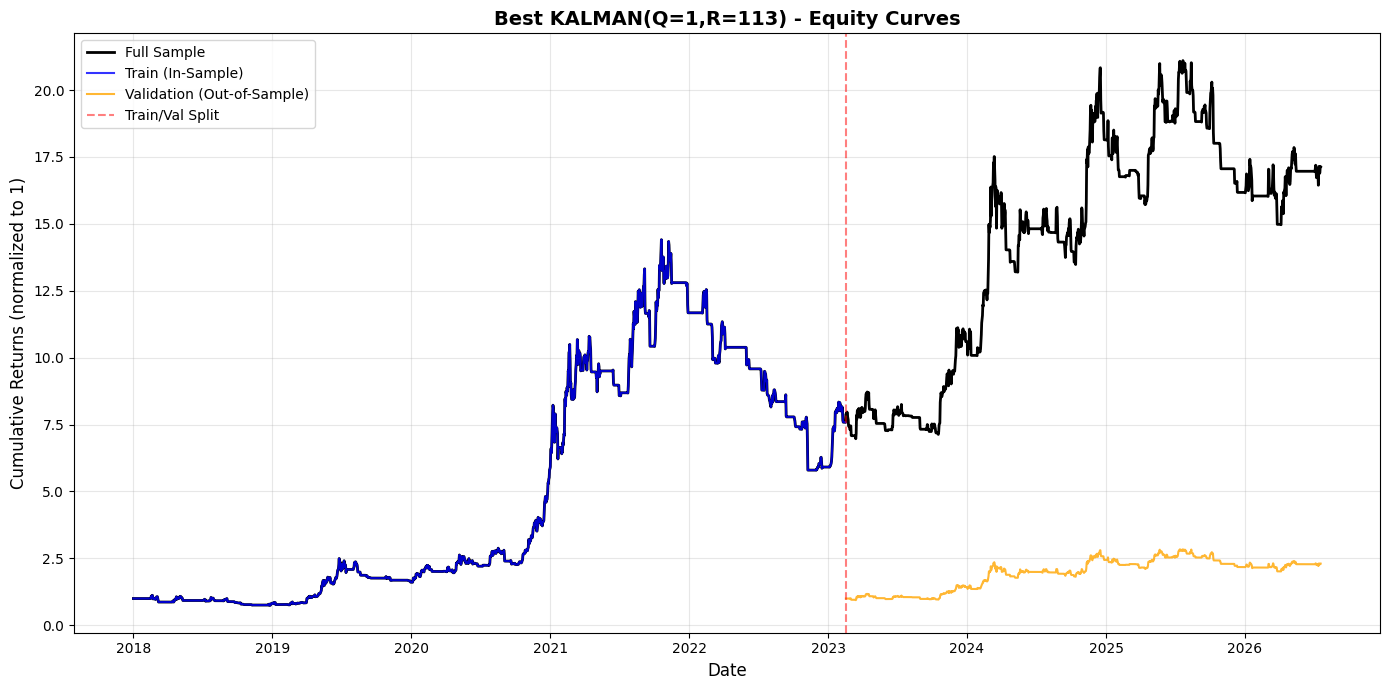

Visualizations complete for: KALMAN KALMAN(Q=1,R=113)


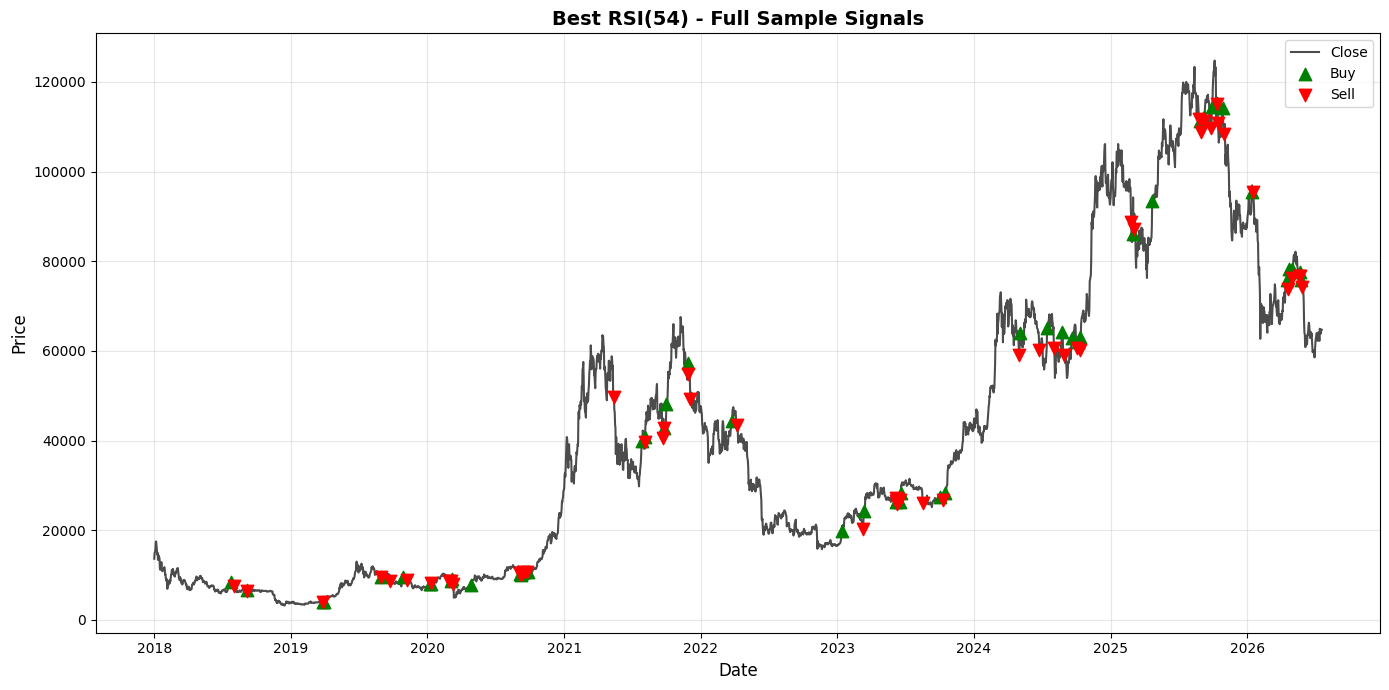

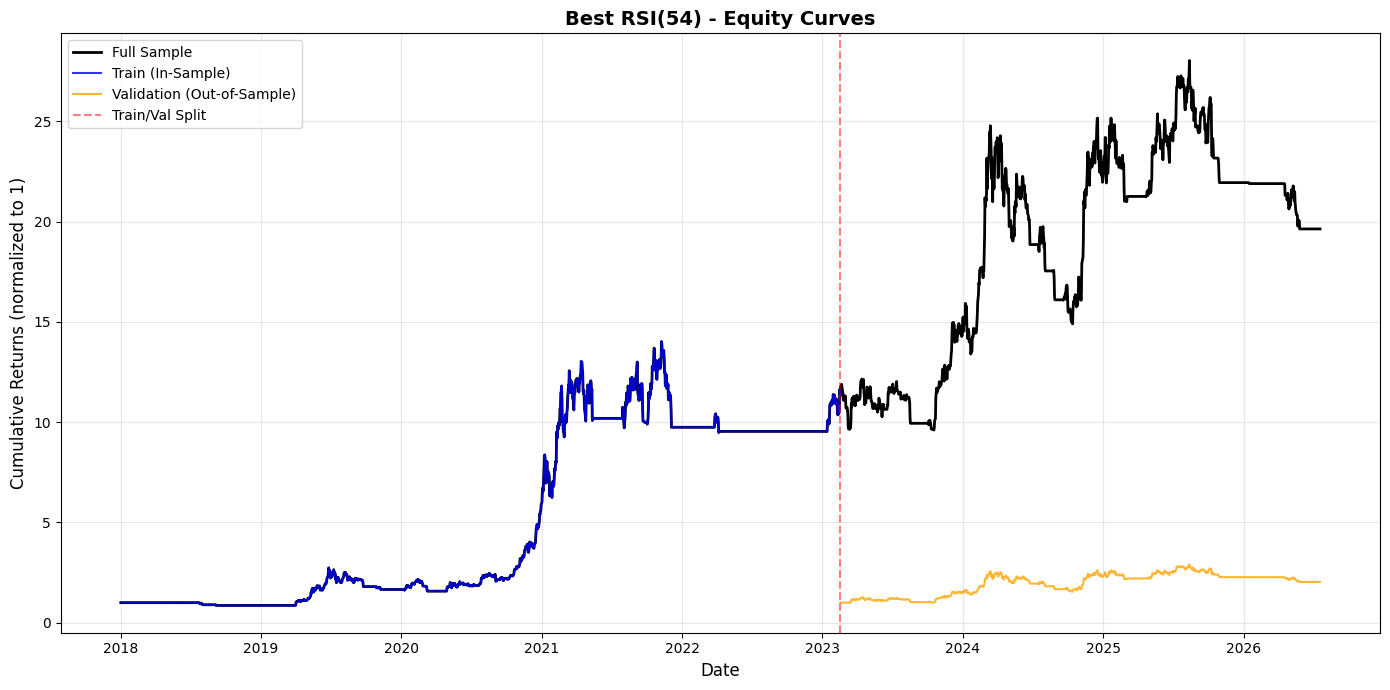

Visualizations complete for: RSI RSI(54)


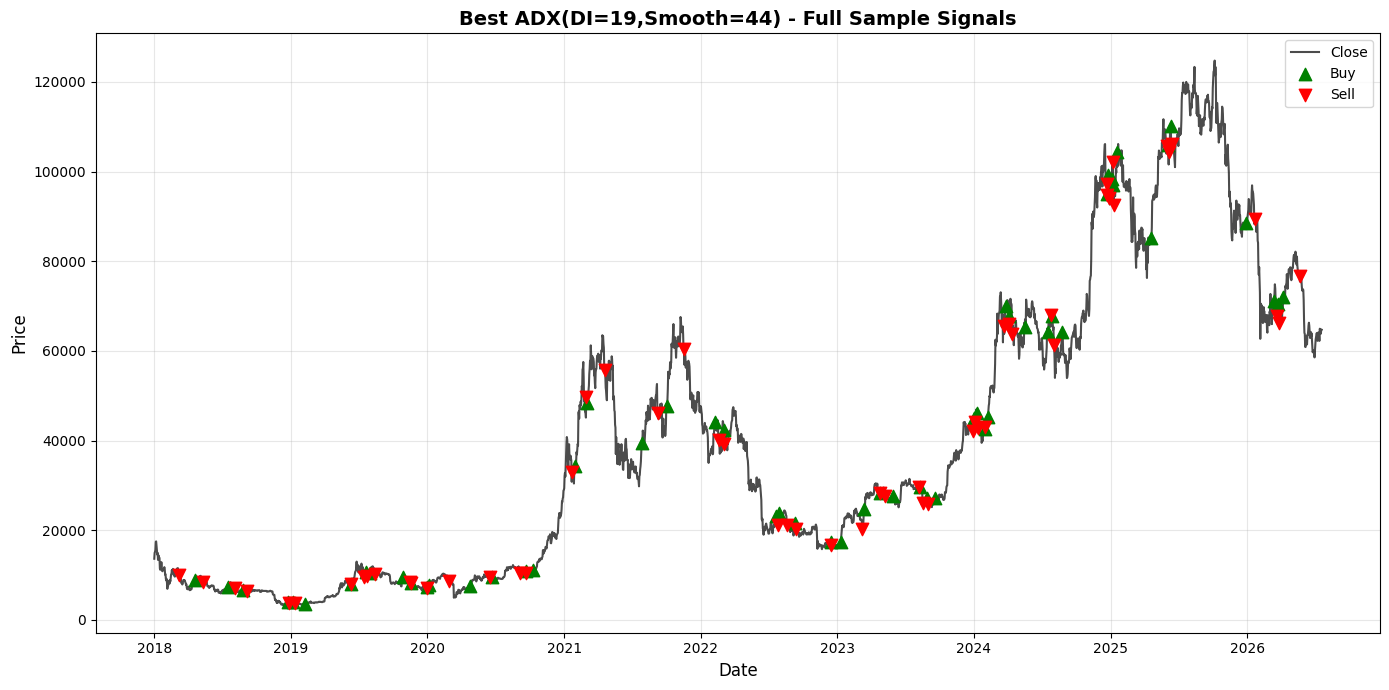

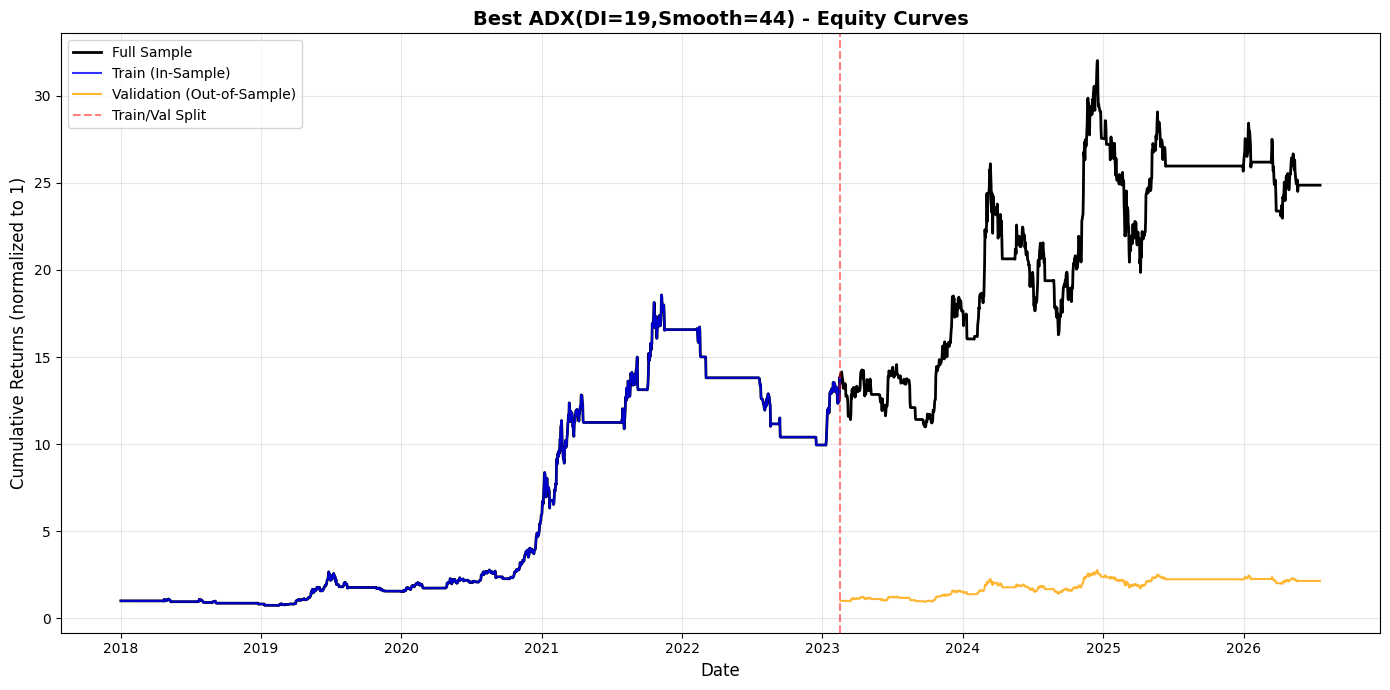

Visualizations complete for: ADX ADX(DI=19,Smooth=44)


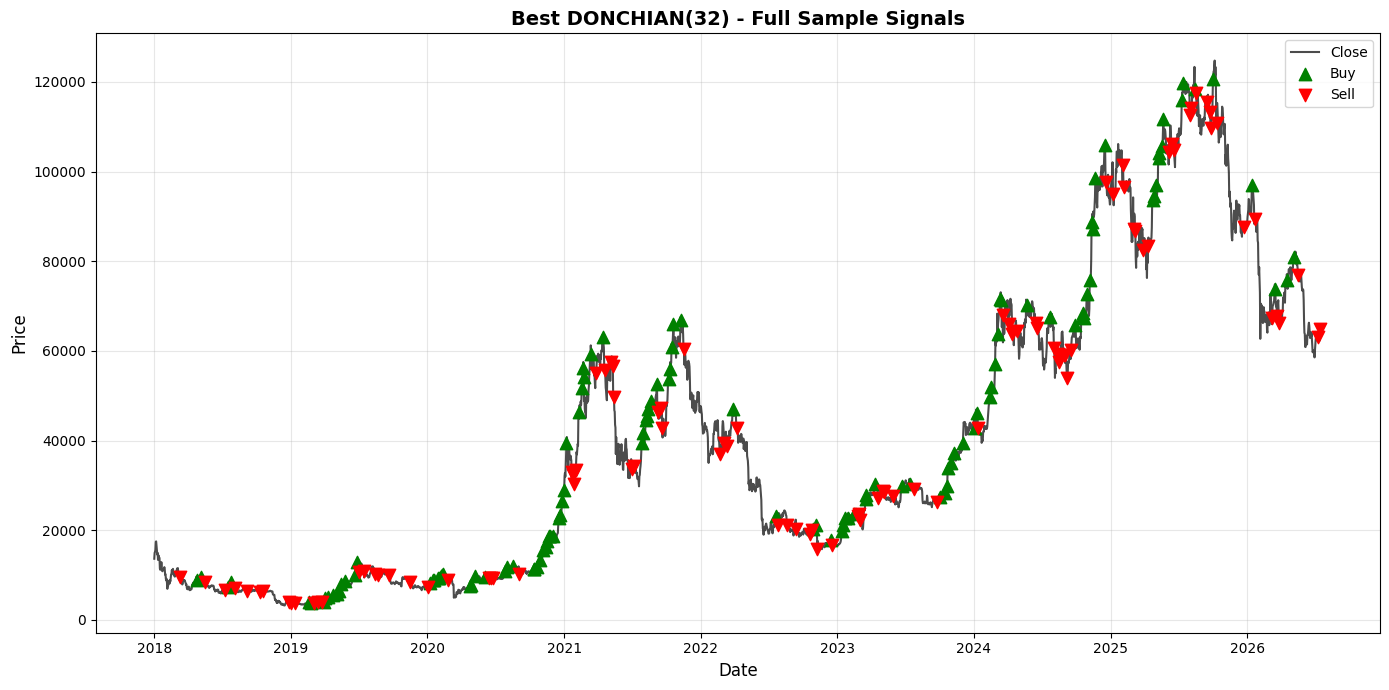

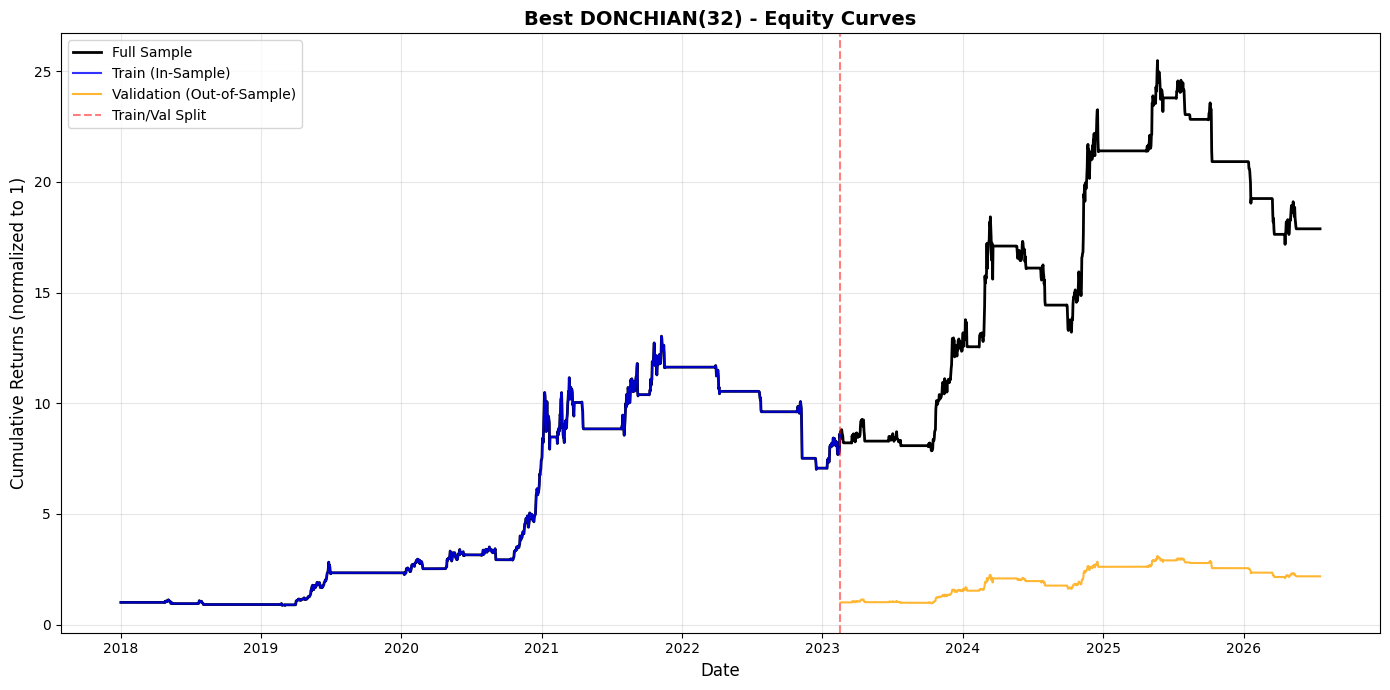

Visualizations complete for: DONCHIAN DONCHIAN(32)


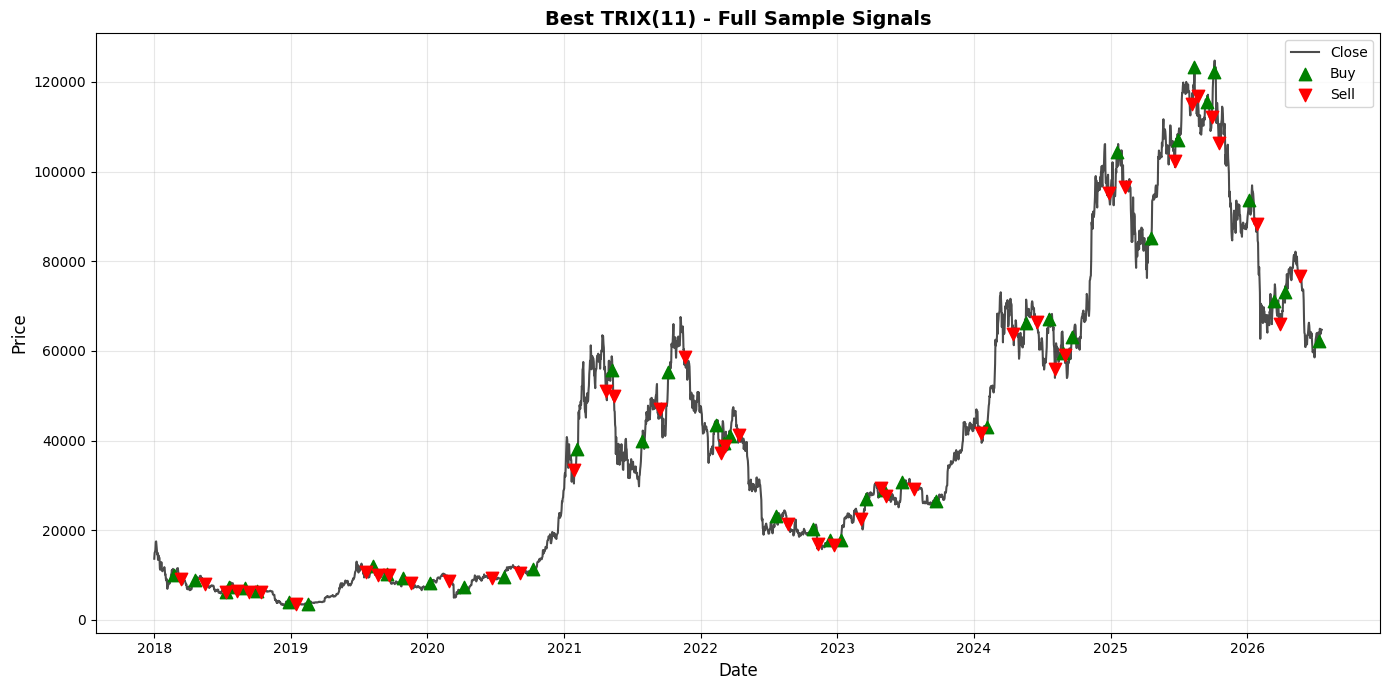

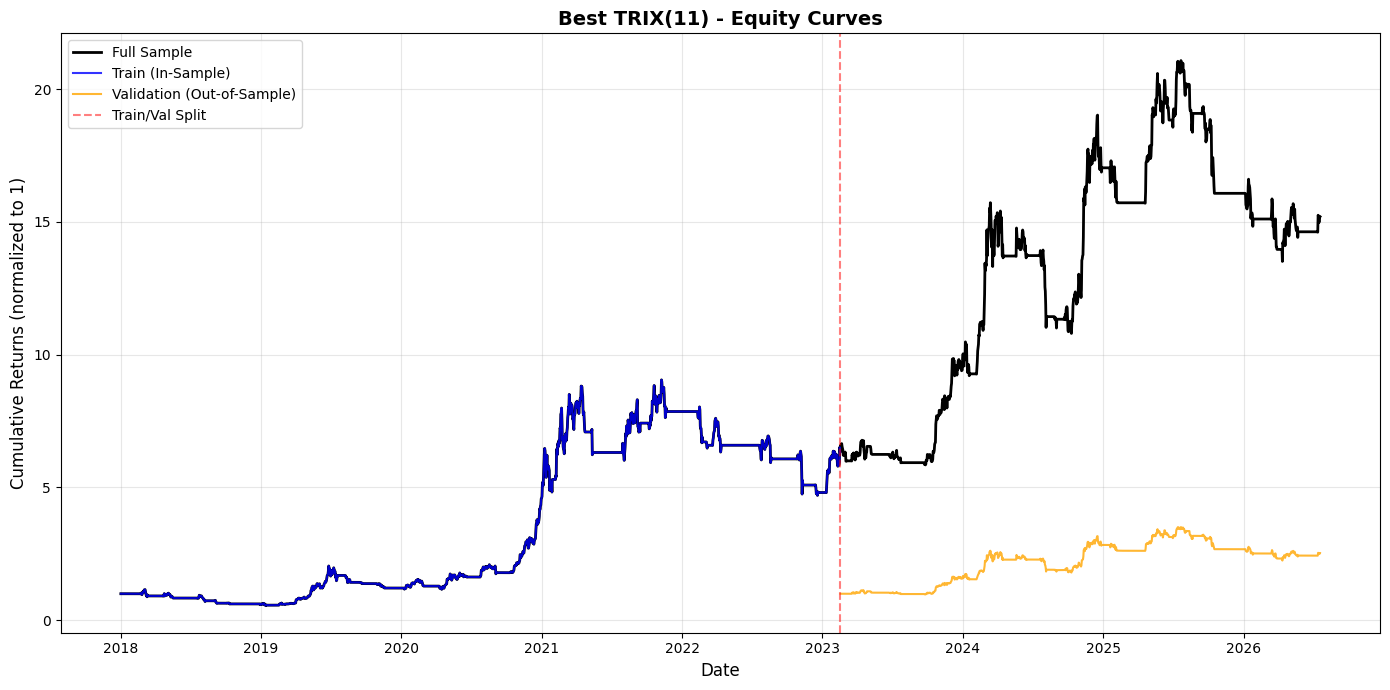

Visualizations complete for: TRIX TRIX(11)


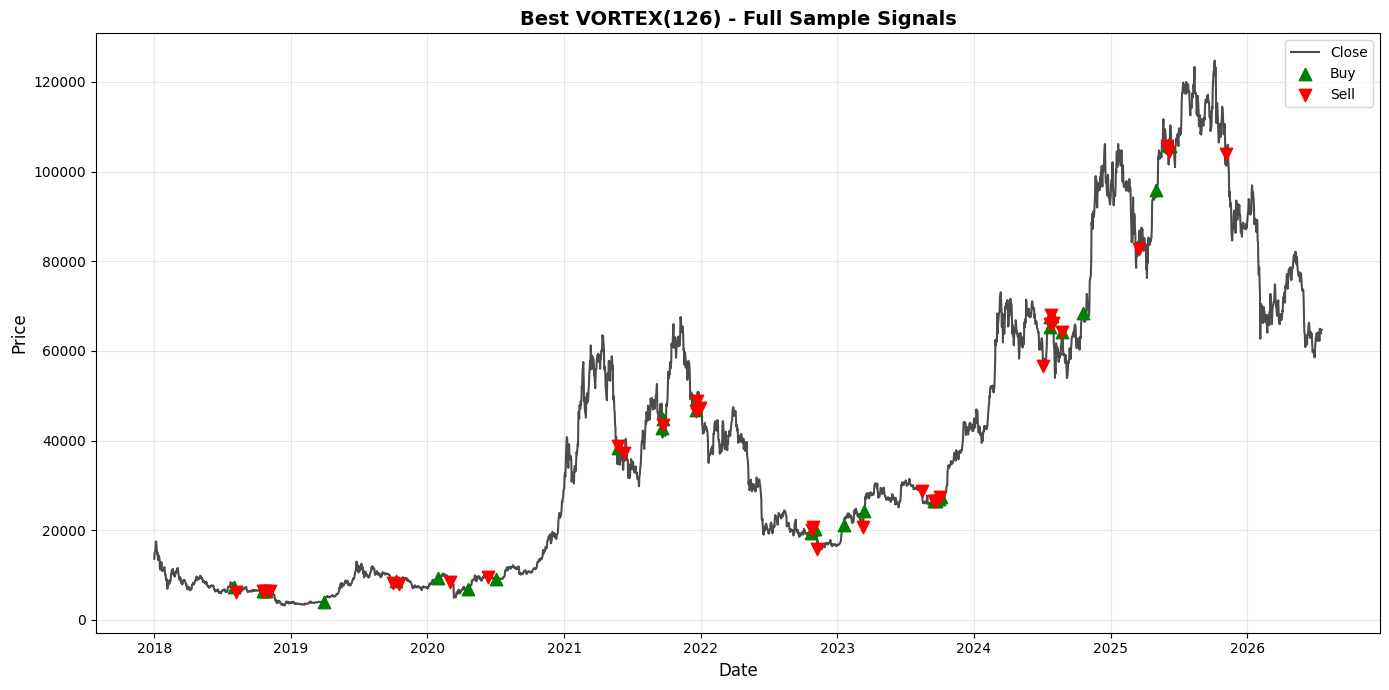

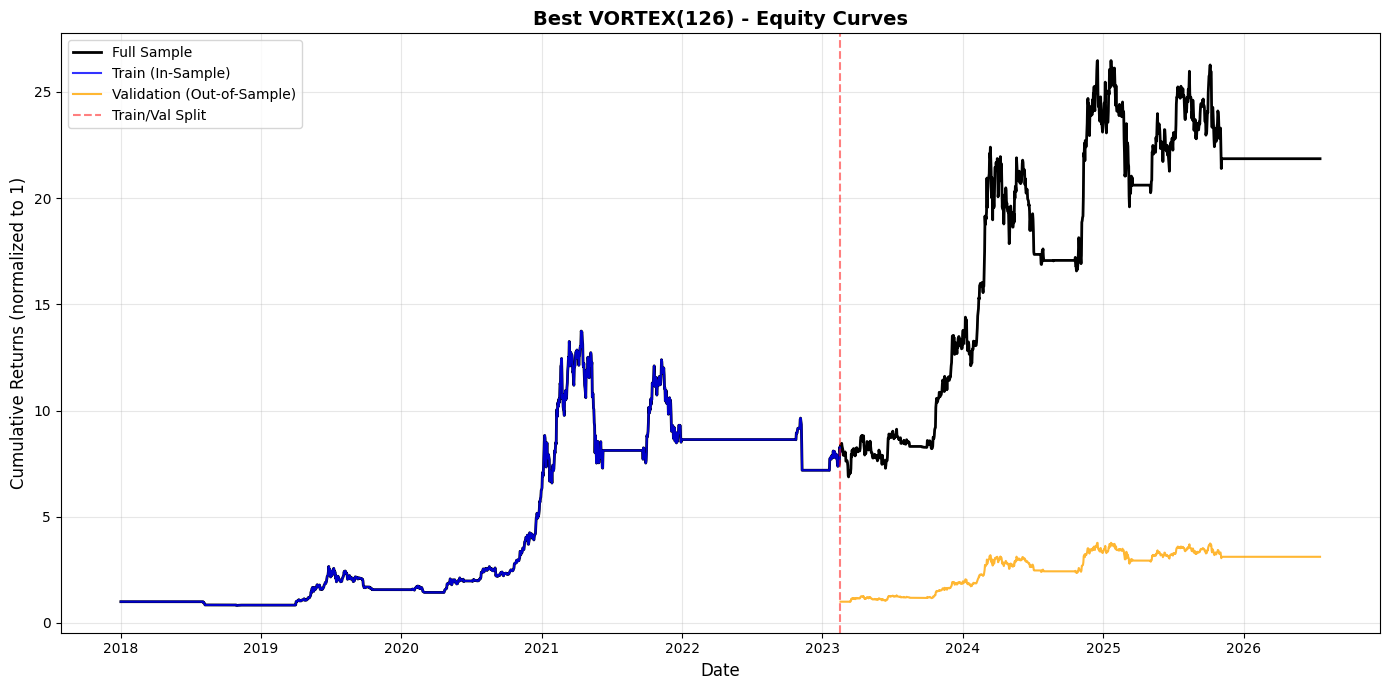

Visualizations complete for: VORTEX VORTEX(126)


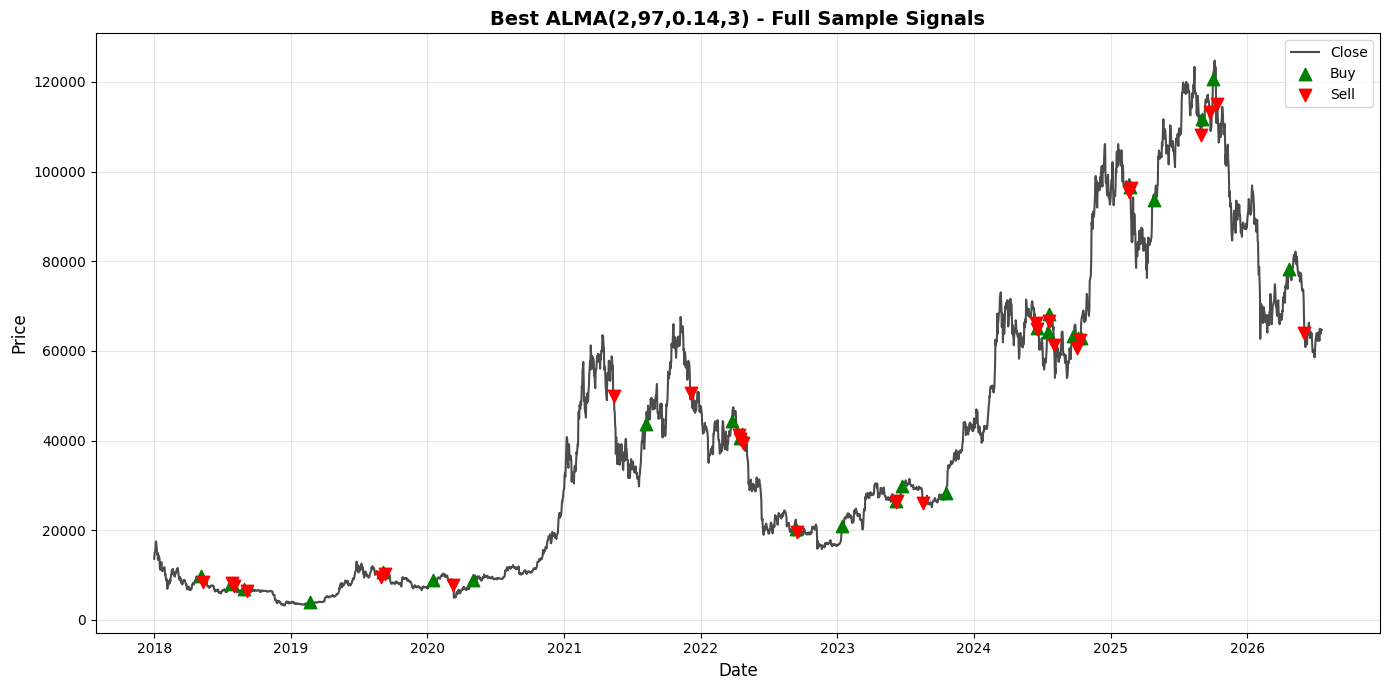

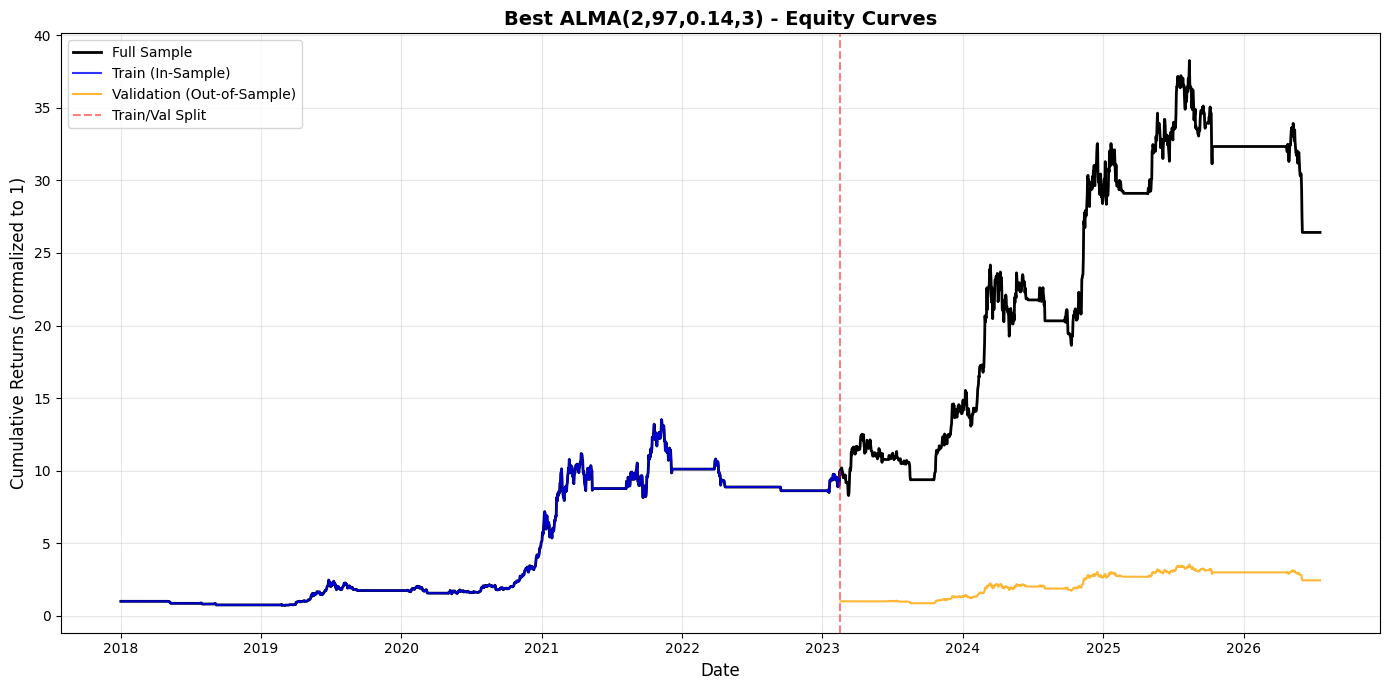

Visualizations complete for: ALMA ALMA(2,97,0.14,3)


In [16]:
# STEP 5C: VISUALS ONLY (Signals + Equity Curves) - for all strategies

def _params_match(stored_params, current_params):
    return isinstance(stored_params, dict) and stored_params == current_params


# Prefer stored per-indicator best strategies (OOS-best when available, else best IS).
strategies_to_plot = []
if "best_by_indicator" in globals() and best_by_indicator:
    for indicator_name, info in best_by_indicator.items():
        if "active_indicator_grids" in globals() and indicator_name not in active_indicator_grids:
            print(f"{indicator_name}: skipping (not in active_indicator_grids)")
            continue
        try:
            params = require_params_dict(info["params"], indicator_name)
            param_display = info.get("param_display")
            if not param_display:
                param_display = get_active_indicator_spec(indicator_name)["format_params"](params)
        except (TypeError, KeyError, ValueError) as exc:
            print(f"{indicator_name}: skipping (invalid stored params: {exc})")
            continue
        strategies_to_plot.append((indicator_name, params, param_display))
elif "results_df" in globals() and not results_df.empty:
    if "best_is_row" not in globals():
        print("best_is_row is not defined; run the grid-search setup cells first.")
    else:
        for indicator_name, indicator_results in results_df.groupby("indicator", sort=False):
            if "active_indicator_grids" in globals() and indicator_name not in active_indicator_grids:
                print(f"{indicator_name}: skipping (not in active_indicator_grids)")
                continue
            best = best_is_row(indicator_results)
            if best is None:
                continue
            try:
                params = require_params_dict(best["params"], indicator_name)
                param_display = best.get("param_display") or get_active_indicator_spec(indicator_name)["format_params"](params)
            except (TypeError, KeyError, ValueError) as exc:
                print(f"{indicator_name}: skipping (invalid IS params: {exc})")
                continue
            strategies_to_plot.append((indicator_name, params, param_display))

required_series = ("close", "train_close", "val_close")
missing_series = [name for name in required_series if name not in globals() or globals()[name] is None]

if not strategies_to_plot:
    print("No results to visualize.")
elif missing_series:
    print(f"Missing required price series: {', '.join(missing_series)}")
elif "split_idx" not in globals():
    print("split_idx is not defined; cannot build train/val equity curves.")
elif len(close) < 2:
    print("Close series too short for visualizations.")
elif len(train_close) < 1 or len(val_close) < 1:
    print(f"Train/val segments are empty: train={len(train_close)}, val={len(val_close)}")
elif split_idx <= 0 or split_idx >= len(close):
    print(f"Invalid split_idx={split_idx} for close length {len(close)}.")
elif len(train_close) != split_idx or len(val_close) != len(close) - split_idx:
    print(
        f"Train/val lengths do not match split_idx: "
        f"train={len(train_close)}, val={len(val_close)}, split_idx={split_idx}, close={len(close)}"
    )
else:
    fs_by_indicator = (
        full_sample_results_by_indicator
        if "full_sample_results_by_indicator" in globals() and full_sample_results_by_indicator
        else {}
    )

    for indicator_name, params, param_display in strategies_to_plot:
        best_label = f"{indicator_name} {param_display}"
        try:
            spec = get_active_indicator_spec(indicator_name)
            entries_series, exits_series = spec["build_signals"](close, params, shift_signals=True)

            if len(entries_series) != len(close) or len(exits_series) != len(close):
                raise ValueError(
                    f"Signal length mismatch: entries={len(entries_series)}, "
                    f"exits={len(exits_series)}, close={len(close)}"
                )

            entries_full = entries_series.to_numpy(dtype=bool)
            exits_full = exits_series.to_numpy(dtype=bool)
            entries_train = entries_full[:split_idx]
            exits_train = exits_full[:split_idx]
            entries_val = entries_full[split_idx:]
            exits_val = exits_full[split_idx:]

            if len(entries_train) != len(train_close) or len(entries_val) != len(val_close):
                raise ValueError("Train/val signal slices do not align with train_close/val_close.")

            # Reuse cached full-sample portfolio when params match; always run train/val backtests.
            fs_result = fs_by_indicator.get(indicator_name)
            if (
                fs_result is not None
                and fs_result.get("portfolio") is not None
                and _params_match(fs_result.get("params"), params)
            ):
                pf_full = fs_result["portfolio"]
            else:
                pf_full = run_signal_backtest(close, entries_full, exits_full)

            pf_train = run_signal_backtest(train_close, entries_train, exits_train)
            pf_val = run_signal_backtest(val_close, entries_val, exits_val)

            # 1) Price + indicator overlay + signals (full sample)
            fig, ax = plt.subplots(figsize=(14, 7))
            ax.plot(close.index, close.values, label='Close', color='black', linewidth=1.5, alpha=0.7)

            if indicator_name == "Triple EMA":
                ema1 = int(params["ema1_period"])
                ema2 = int(params["ema2_period"])
                ema3 = int(params["ema3_period"])
                ema1_full = get_ema_series(close, ema1)
                ema2_full = get_ema_series(close, ema2)
                ema3_full = get_ema_series(close, ema3)
                ax.plot(close.index, ema1_full.values, label=f'Fast EMA ({ema1})', color='blue', alpha=0.8, linewidth=1.2)
                ax.plot(close.index, ema2_full.values, label=f'Medium EMA ({ema2})', color='orange', alpha=0.8, linewidth=1.2)
                ax.plot(close.index, ema3_full.values, label=f'Slow EMA ({ema3})', color='purple', alpha=0.8, linewidth=1.2)

            buy_idx = close.index[entries_full]
            sell_idx = close.index[exits_full]
            ax.scatter(buy_idx, close.reindex(buy_idx).values, marker='^', color='green', s=80, label='Buy', zorder=5)
            ax.scatter(sell_idx, close.reindex(sell_idx).values, marker='v', color='red', s=80, label='Sell', zorder=5)

            ax.set_title(f'Best {param_display} - Full Sample Signals', fontsize=14, fontweight='bold')
            ax.set_xlabel('Date', fontsize=12)
            ax.set_ylabel('Price', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best')
            plt.tight_layout()
            plt.show()

            # 2) Equity curves: train / val / full
            eq_full = (1 + pf_full.returns()).cumprod()
            eq_train = (1 + pf_train.returns()).cumprod()
            eq_val = (1 + pf_val.returns()).cumprod()

            fig, ax = plt.subplots(figsize=(14, 7))
            ax.plot(close.index, eq_full.values, label='Full Sample', color='black', linewidth=2)
            ax.plot(train_close.index, eq_train.values, label='Train (In-Sample)', color='blue', linewidth=1.5, alpha=0.8)
            ax.plot(val_close.index, eq_val.values, label='Validation (Out-of-Sample)', color='orange', linewidth=1.5, alpha=0.8)
            ax.axvline(x=train_close.index[-1], color='red', linestyle='--', alpha=0.5, label='Train/Val Split')

            ax.set_title(f'Best {param_display} - Equity Curves', fontsize=14, fontweight='bold')
            ax.set_xlabel('Date', fontsize=12)
            ax.set_ylabel('Cumulative Returns (normalized to 1)', fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best')
            plt.tight_layout()
            plt.show()

            print(f"Visualizations complete for: {best_label}")
        except Exception as exc:
            print(f"{best_label}: visualization failed ({type(exc).__name__}: {exc})")


FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — Triple EMA EMA(5,104,120)
Total trades plotted: 29
Win Rate: 37.9% (11W / 18L)
Avg Win: 61.30% | Avg Loss: -4.74%
Max Win: 344.17% | Max Loss: -13.32%


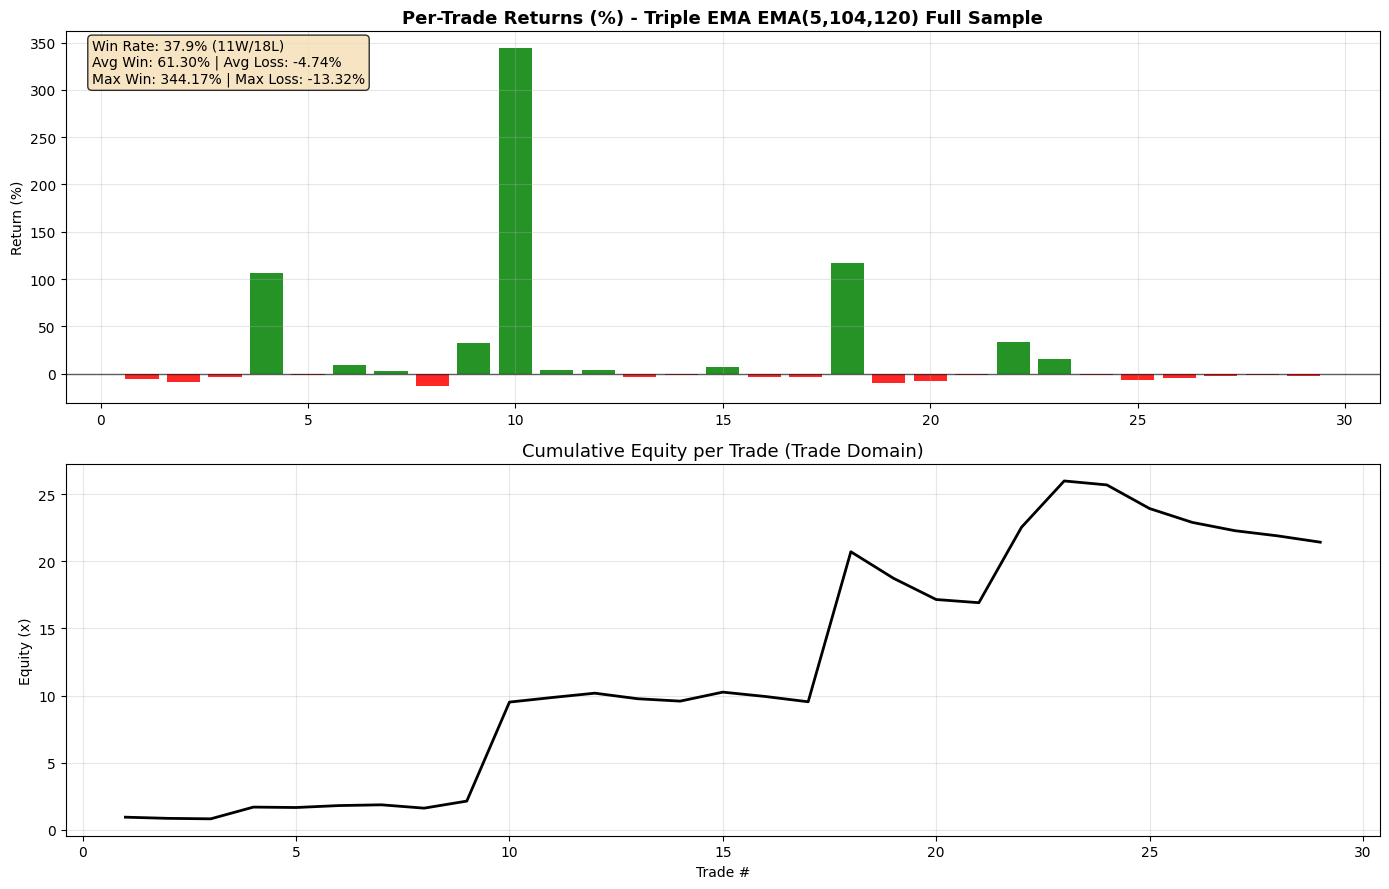

Trade-by-trade analysis complete for: Triple EMA EMA(5,104,120)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — MACD MACD(40,69,89)
Total trades plotted: 18
Win Rate: 66.7% (12W / 6L)
Avg Win: 65.36% | Avg Loss: -11.64%
Max Win: 364.82% | Max Loss: -27.42%


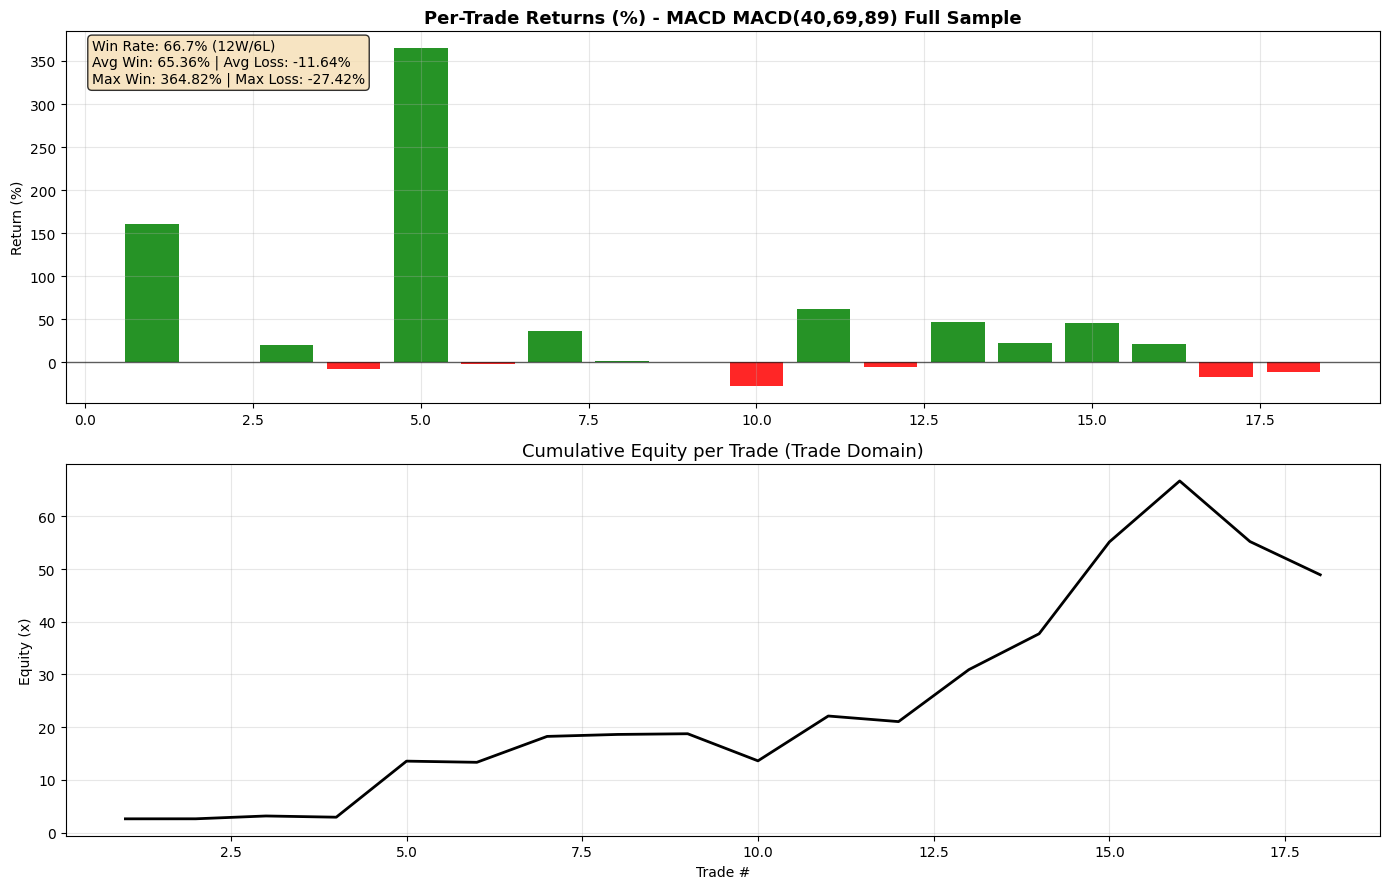

Trade-by-trade analysis complete for: MACD MACD(40,69,89)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — AROON AROON(16)
Total trades plotted: 80
Win Rate: 45.0% (36W / 44L)
Avg Win: 21.91% | Avg Loss: -6.40%
Max Win: 189.34% | Max Loss: -16.72%


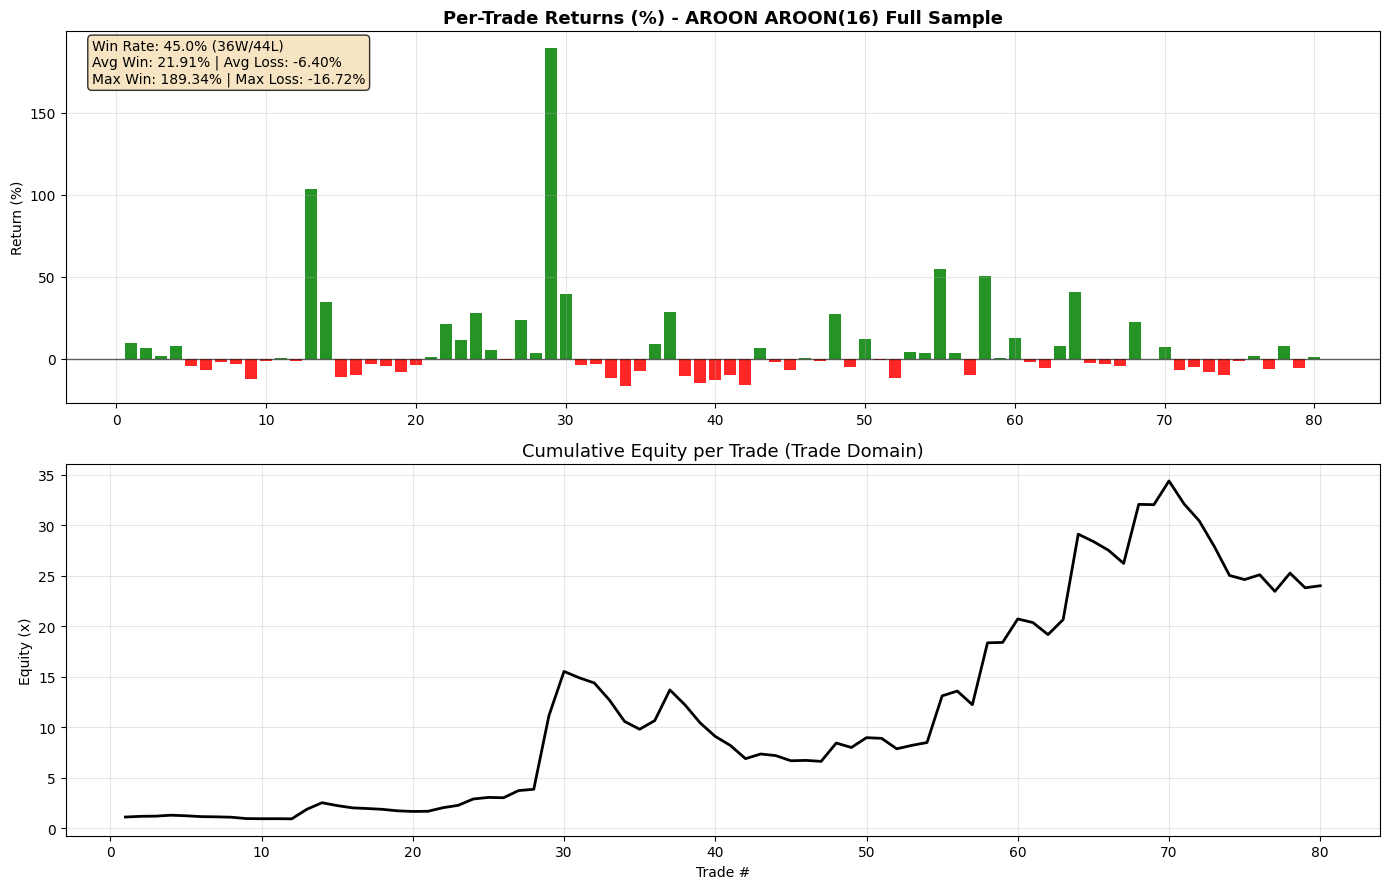

Trade-by-trade analysis complete for: AROON AROON(16)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — STC STC(41,61,35)
Total trades plotted: 30
Win Rate: 46.7% (14W / 16L)
Avg Win: 43.25% | Avg Loss: -7.99%
Max Win: 151.97% | Max Loss: -18.61%


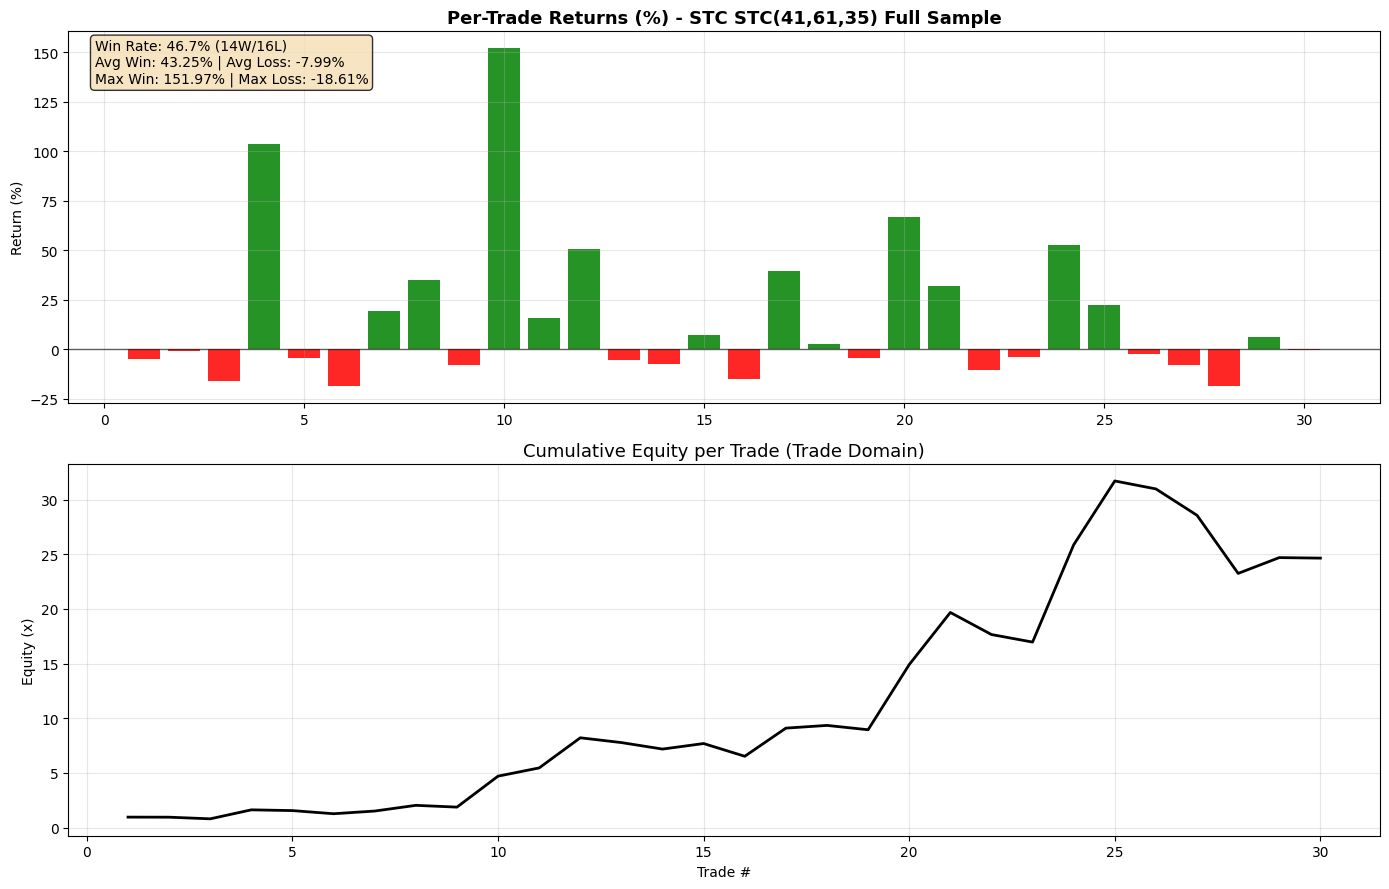

Trade-by-trade analysis complete for: STC STC(41,61,35)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — KAMA KAMA(5,7,68)
Total trades plotted: 67
Win Rate: 38.8% (26W / 41L)
Avg Win: 29.73% | Avg Loss: -4.43%
Max Win: 377.07% | Max Loss: -14.24%


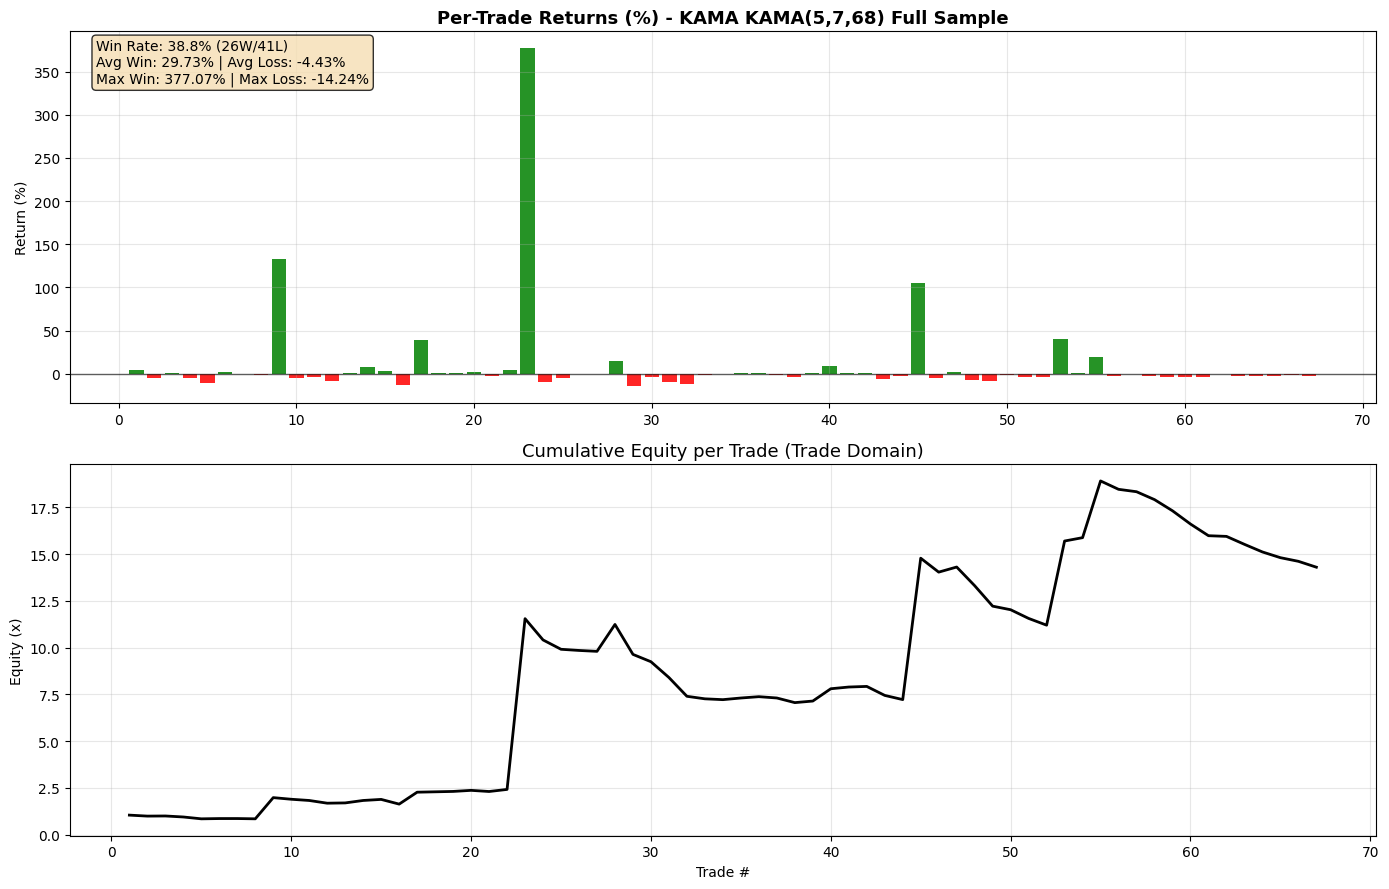

Trade-by-trade analysis complete for: KAMA KAMA(5,7,68)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — SUPERTREND SUPERTREND(ATR=36,Factor=4)
Total trades plotted: 23
Win Rate: 52.2% (12W / 11L)
Avg Win: 51.25% | Avg Loss: -12.11%
Max Win: 212.63% | Max Loss: -23.77%


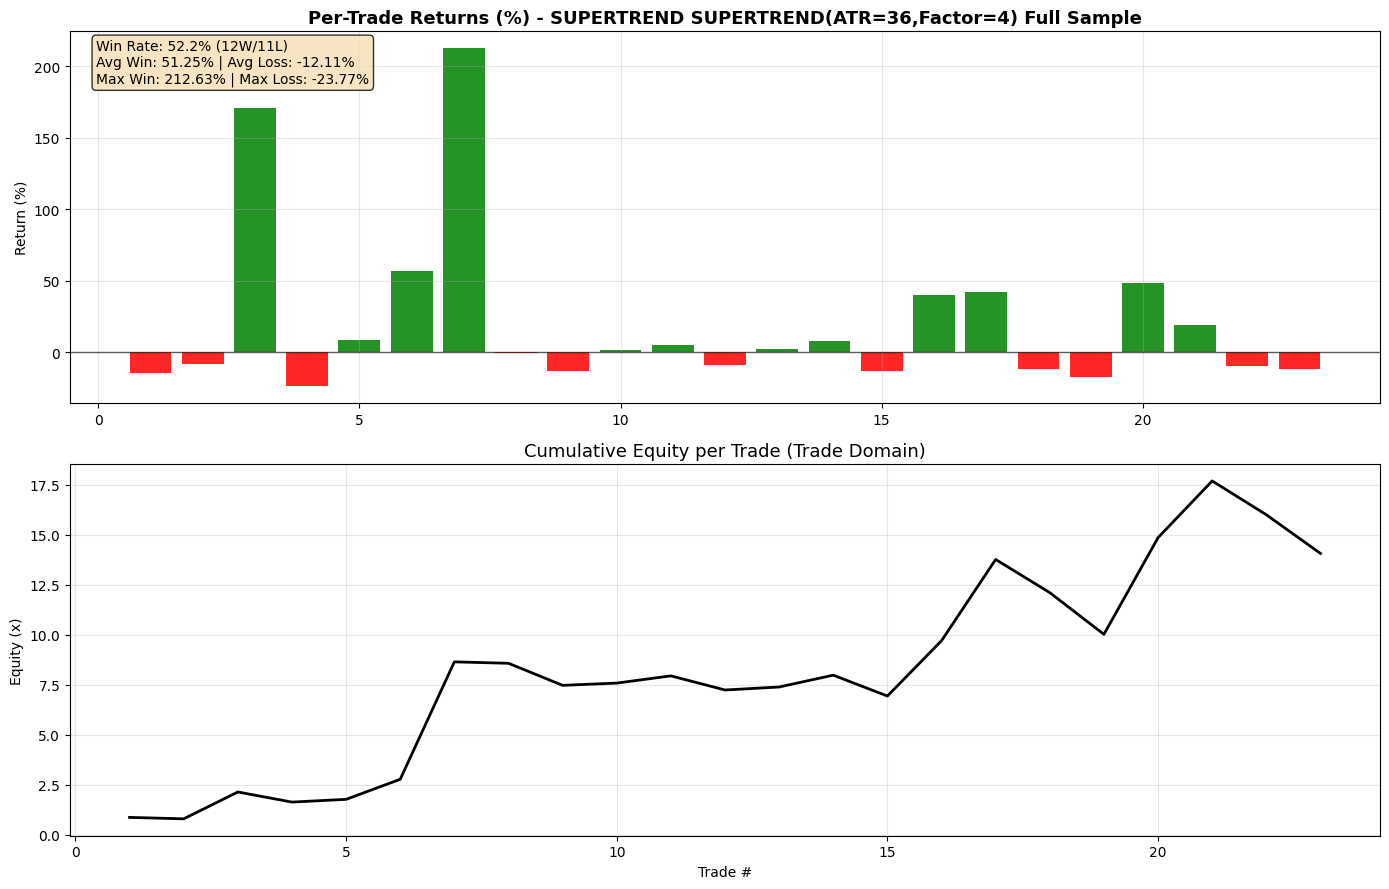

Trade-by-trade analysis complete for: SUPERTREND SUPERTREND(ATR=36,Factor=4)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — KALMAN KALMAN(Q=1,R=113)
Total trades plotted: 162
Win Rate: 41.4% (67W / 95L)
Avg Win: 11.50% | Avg Loss: -3.71%
Max Win: 91.10% | Max Loss: -23.71%


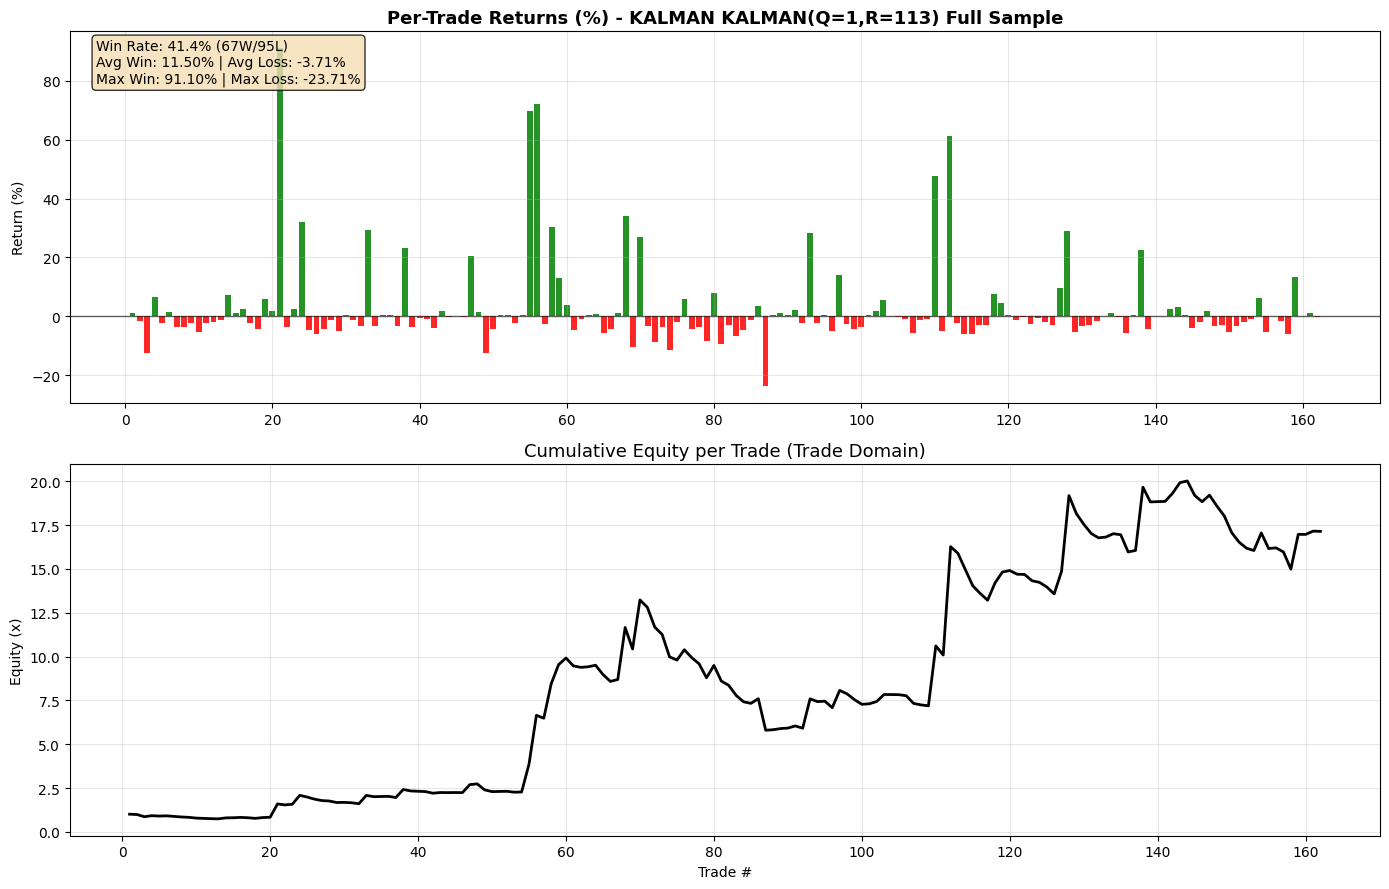

Trade-by-trade analysis complete for: KALMAN KALMAN(Q=1,R=113)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — RSI RSI(54)
Total trades plotted: 50
Win Rate: 38.0% (19W / 31L)
Avg Win: 39.22% | Avg Loss: -4.29%
Max Win: 364.21% | Max Loss: -14.24%


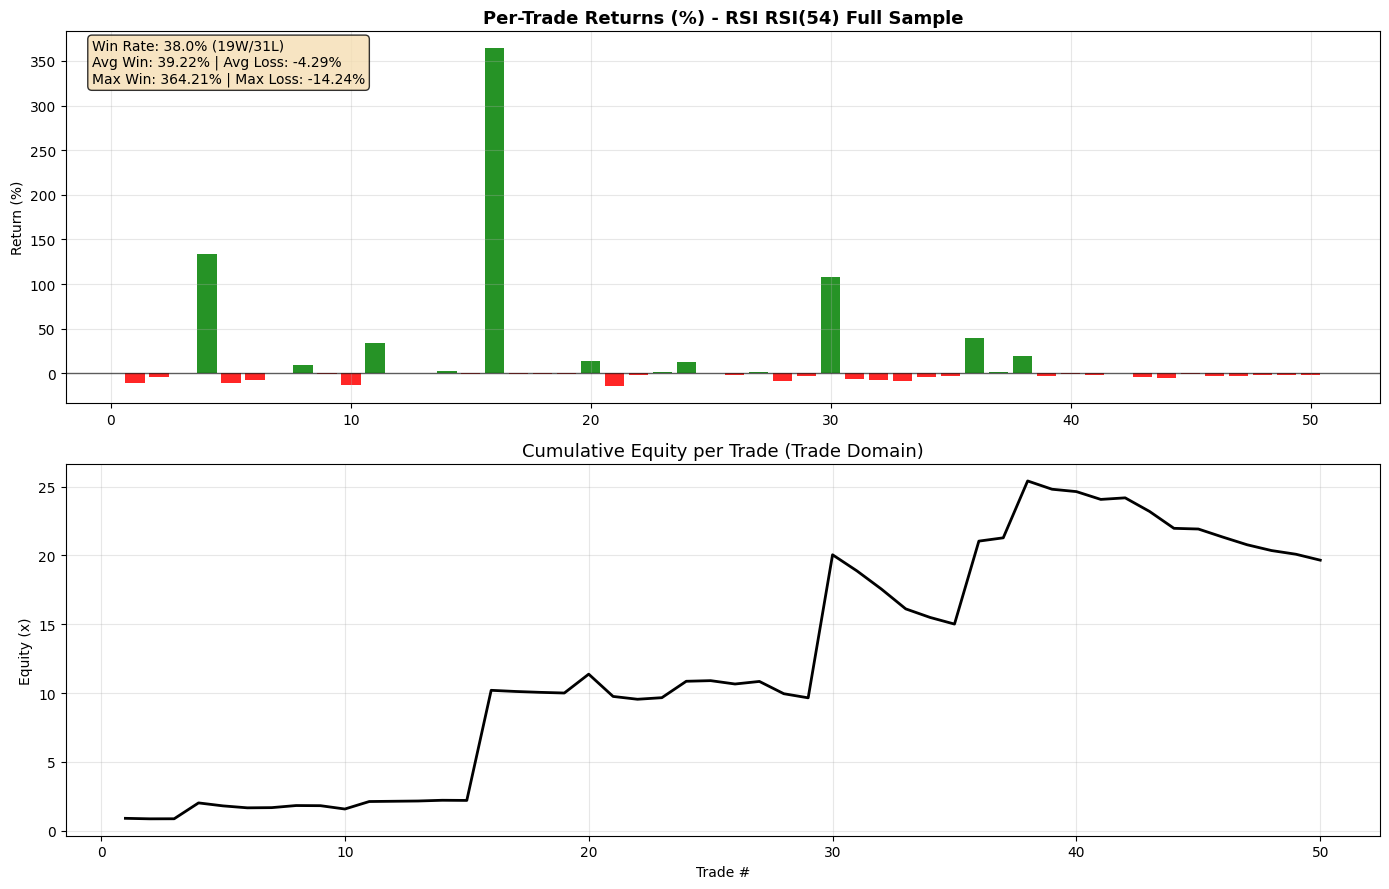

Trade-by-trade analysis complete for: RSI RSI(54)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — ADX ADX(DI=19,Smooth=44)
Total trades plotted: 54
Win Rate: 40.7% (22W / 32L)
Avg Win: 31.35% | Avg Loss: -5.72%
Max Win: 197.81% | Max Loss: -12.06%


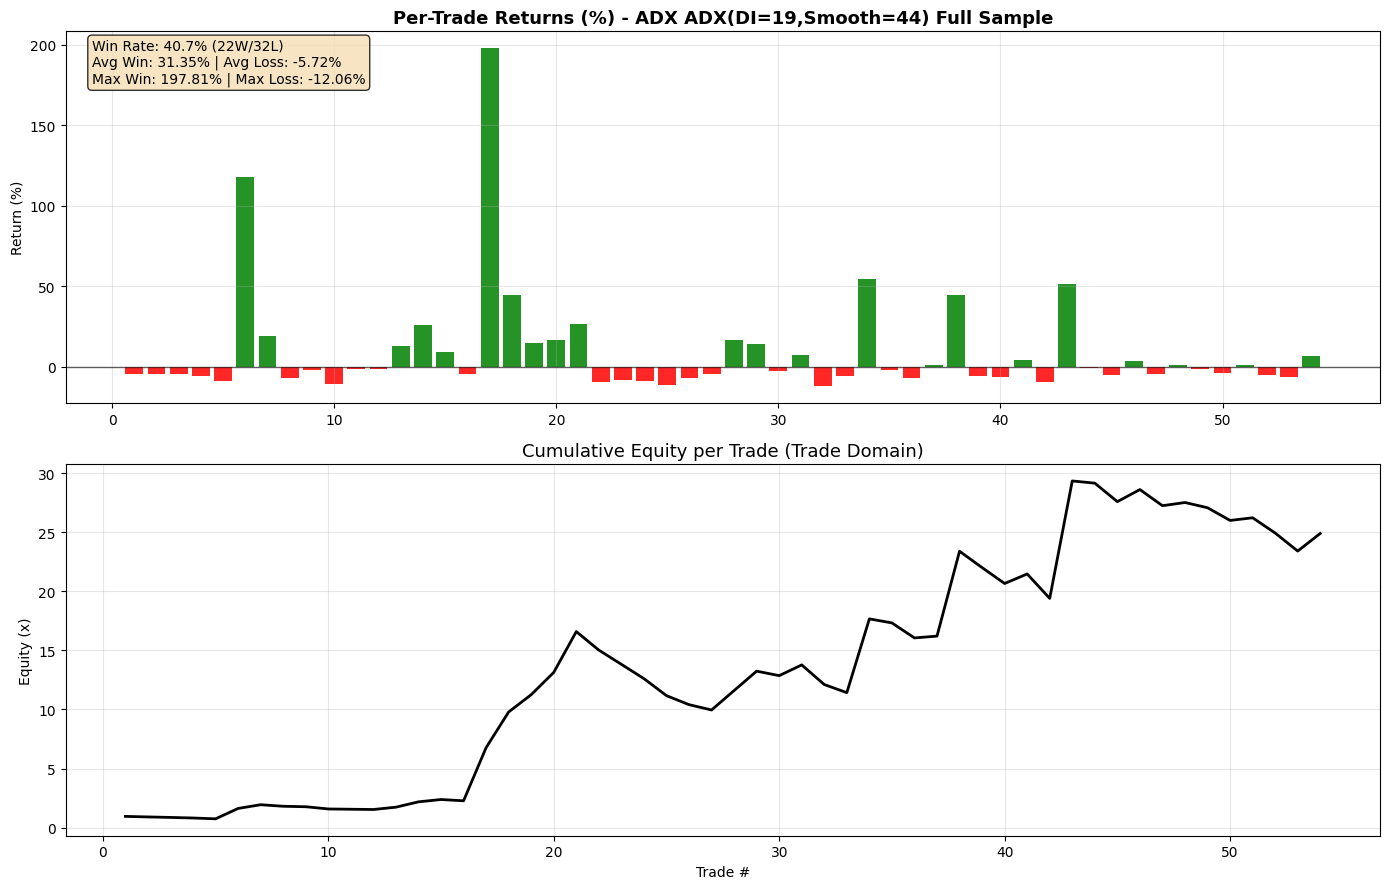

Trade-by-trade analysis complete for: ADX ADX(DI=19,Smooth=44)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — DONCHIAN DONCHIAN(32)
Total trades plotted: 31
Win Rate: 45.2% (14W / 17L)
Avg Win: 43.02% | Avg Loss: -7.28%
Max Win: 189.44% | Max Loss: -21.88%


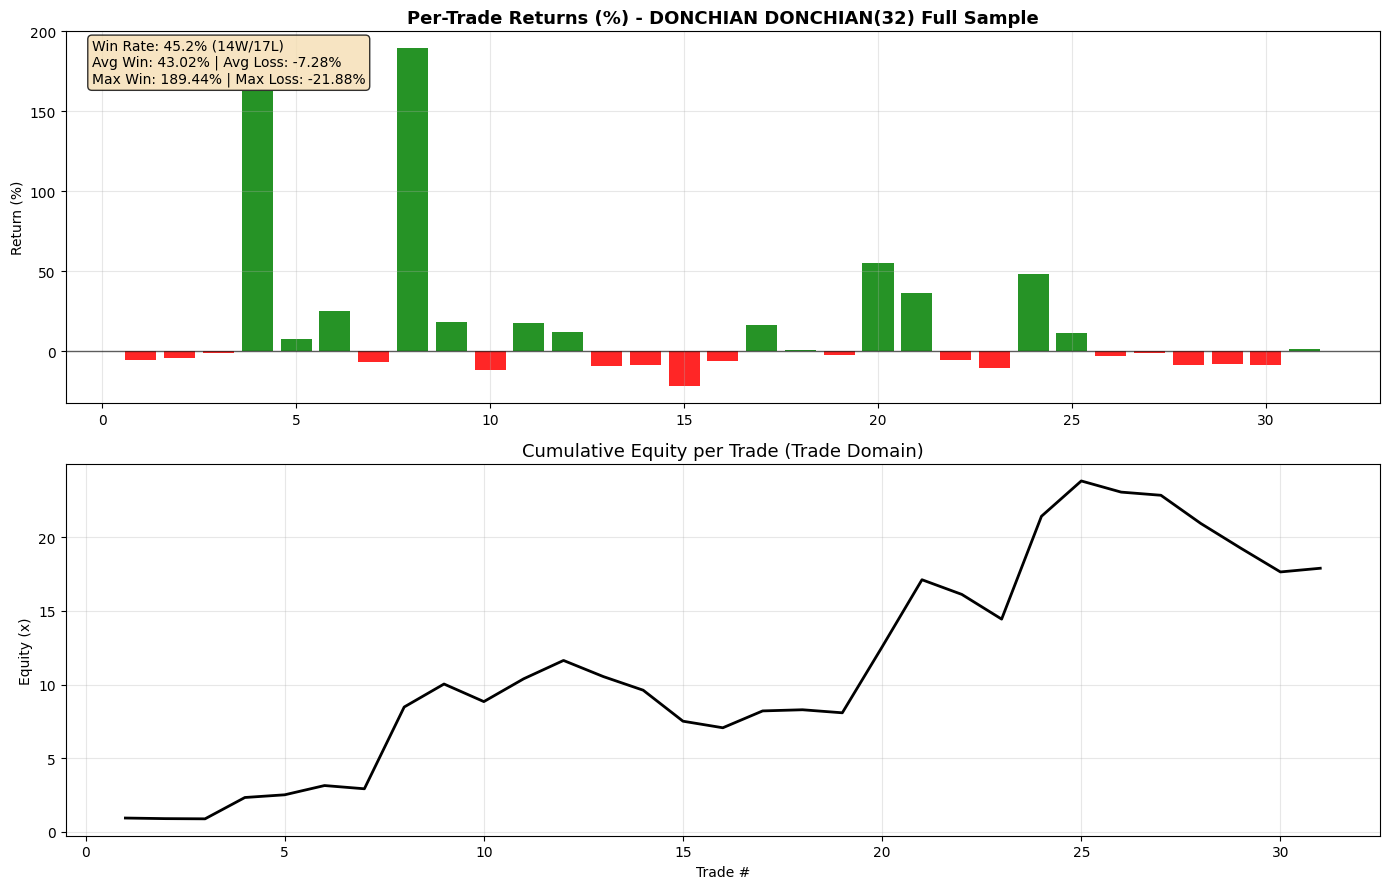

Trade-by-trade analysis complete for: DONCHIAN DONCHIAN(32)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — TRIX TRIX(11)
Total trades plotted: 45
Win Rate: 42.2% (19W / 26L)
Avg Win: 37.71% | Avg Loss: -8.13%
Max Win: 196.87% | Max Loss: -16.75%


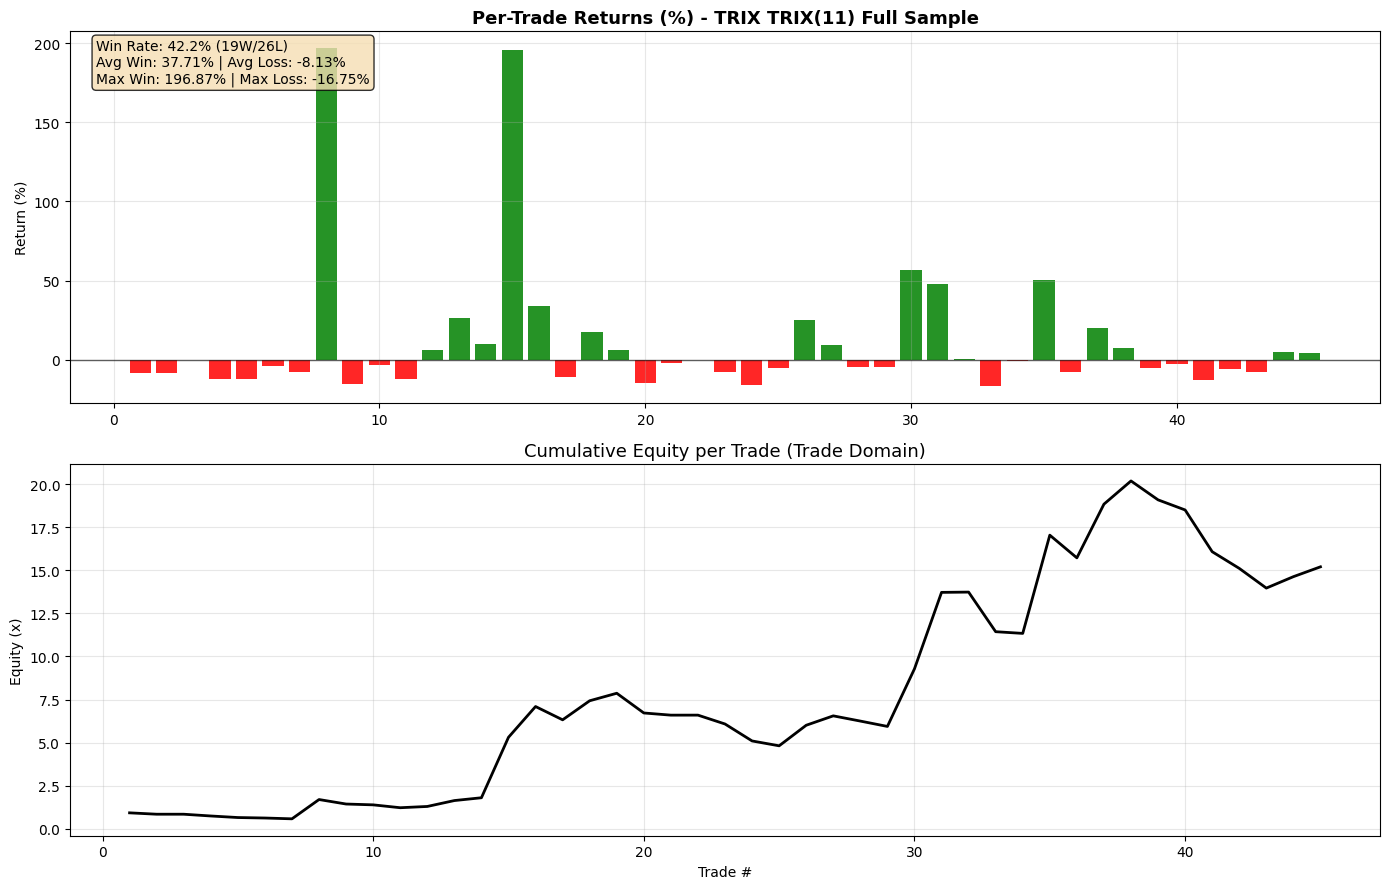

Trade-by-trade analysis complete for: TRIX TRIX(11)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — VORTEX VORTEX(126)
Total trades plotted: 31
Win Rate: 48.4% (15W / 16L)
Avg Win: 42.62% | Avg Loss: -4.45%
Max Win: 323.56% | Max Loss: -21.59%


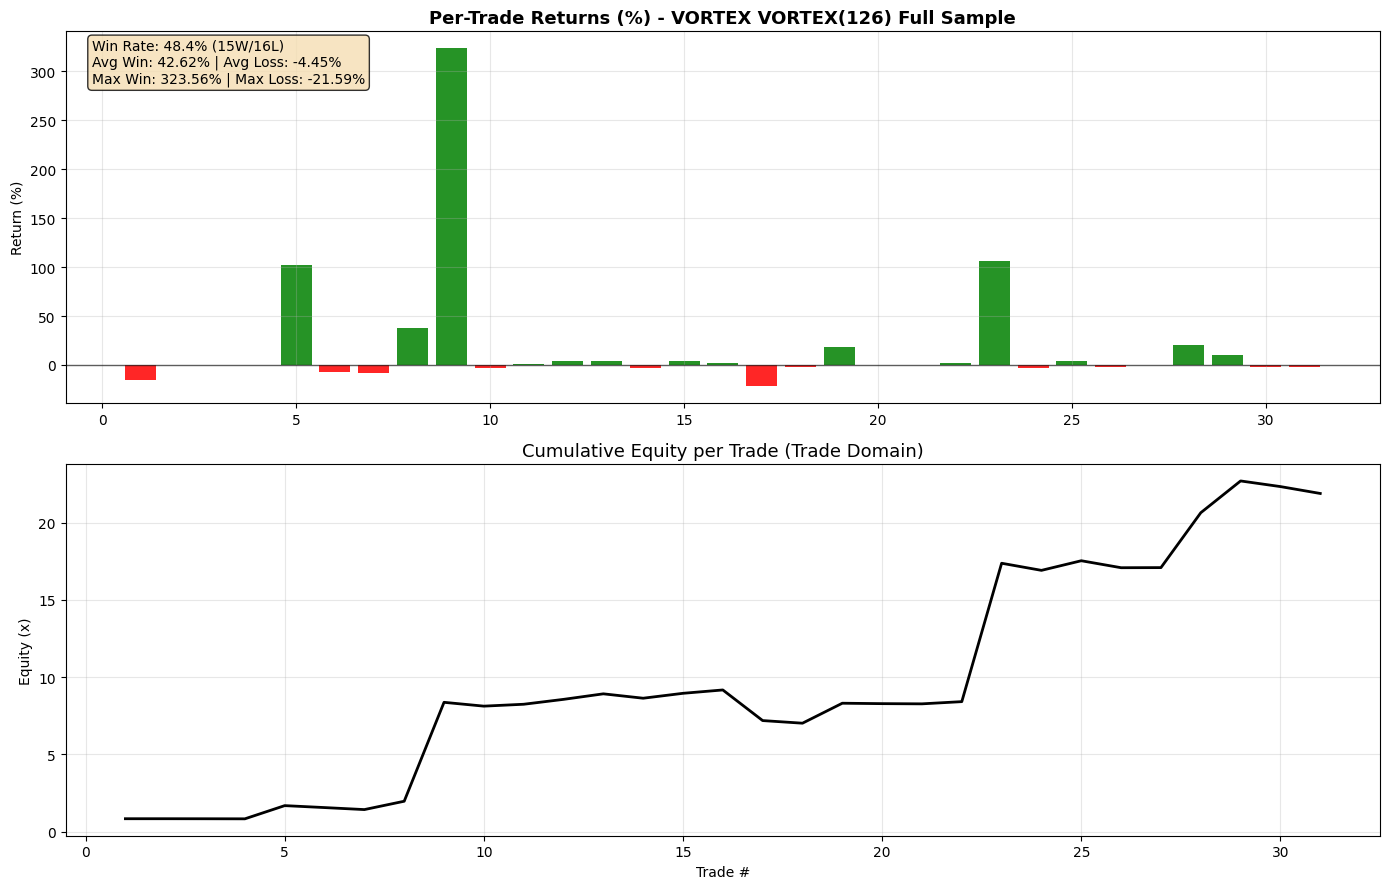

Trade-by-trade analysis complete for: VORTEX VORTEX(126)

FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — ALMA ALMA(2,97,0.14,3)
Total trades plotted: 28
Win Rate: 35.7% (10W / 18L)
Avg Win: 85.25% | Avg Loss: -6.22%
Max Win: 461.79% | Max Loss: -18.32%


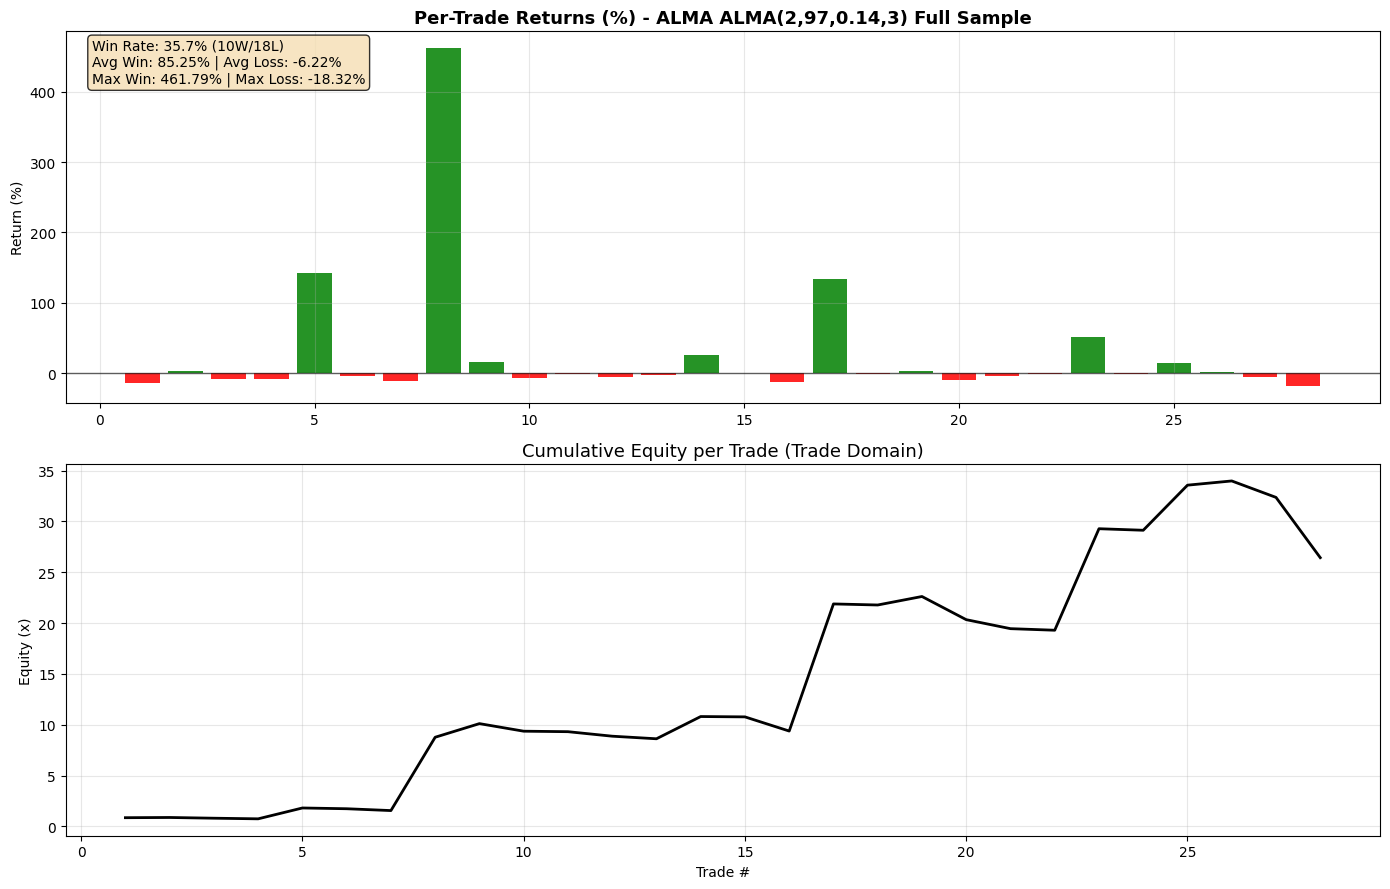

Trade-by-trade analysis complete for: ALMA ALMA(2,97,0.14,3)


In [17]:
# FULL-SAMPLE TRADE-BY-TRADE RETURNS (BAR) + CUMULATIVE PER-TRADE EQUITY — ALL TRADESbt

# Reuse the same full Close series as full-sample evaluation (avoid re-parsing columns).
plot_close = None
if "close" in globals() and close is not None and len(close) >= 2:
    plot_close = close.astype(float).copy()
    plot_close.name = TICKER
elif "stock_data" in globals() and stock_data is not None and "TICKER" in globals():
    try:
        plot_close = select_close_series(stock_data, TICKER).astype(float)
        plot_close.name = TICKER
    except (KeyError, ValueError, TypeError) as exc:
        print(f"Could not resolve Close series from stock_data ({exc})")

# Prefer stored per-indicator best strategies (OOS-best when available, else best IS).
strategies_to_plot = []
if "best_by_indicator" in globals() and best_by_indicator:
    for indicator_name, info in best_by_indicator.items():
        try:
            params = require_params_dict(info.get("params"), indicator_name)
            param_display = info.get("param_display") or str(params)
        except (TypeError, KeyError, ValueError) as exc:
            print(f"{indicator_name}: skipping (invalid stored params: {exc})")
            continue
        strategies_to_plot.append((indicator_name, params, param_display))
elif "results_df" in globals() and not results_df.empty:
    if "best_is_row" not in globals():
        print("best_is_row helper missing. Run the grid-search cells first.")
    else:
        for indicator_name, indicator_results in results_df.groupby("indicator", sort=False):
            best = best_is_row(indicator_results)
            if best is None:
                continue
            try:
                params = require_params_dict(best["params"], indicator_name)
            except (TypeError, KeyError, ValueError) as exc:
                print(f"{indicator_name}: skipping (invalid IS params: {exc})")
                continue
            strategies_to_plot.append((indicator_name, params, best.get("param_display") or str(params)))

if not strategies_to_plot:
    print("No results to visualize.")
elif plot_close is None or len(plot_close) < 2:
    print("Close series missing or too short for trade-by-trade plots.")
else:
    fs_by_indicator = (
        full_sample_results_by_indicator
        if "full_sample_results_by_indicator" in globals() and full_sample_results_by_indicator
        else {}
    )

    if "_params_match" not in globals():
        def _params_match(stored_params, current_params):
            return isinstance(stored_params, dict) and stored_params == current_params

    for indicator_name, params, param_display in strategies_to_plot:
        best_label = f"{indicator_name} {param_display}"
        print("\n" + "=" * 90)
        print(f"FULL-SAMPLE TRADE-BY-TRADE ANALYSIS — {best_label}")
        print("=" * 90)

        try:
            fs_result = fs_by_indicator.get(indicator_name)
            if (
                fs_result is not None
                and fs_result.get("portfolio") is not None
                and _params_match(fs_result.get("params"), params)
            ):
                pf_full = fs_result["portfolio"]
            else:
                if fs_result is not None and not _params_match(fs_result.get("params"), params):
                    print(f"{best_label}: cached portfolio params differ; rebuilding backtest.")
                spec = get_active_indicator_spec(indicator_name)
                entries_series, exits_series = spec["build_signals"](
                    plot_close, params, shift_signals=True
                )
                if len(entries_series) != len(plot_close) or len(exits_series) != len(plot_close):
                    raise ValueError(
                        f"Signal length mismatch: entries={len(entries_series)}, "
                        f"exits={len(exits_series)}, close={len(plot_close)}"
                    )
                pf_full = run_signal_backtest(plot_close, entries_series, exits_series)

            trades = pf_full.trades
            trade_returns = (
                trades.returns.values
                if hasattr(trades.returns, "values")
                else np.asarray(trades.returns)
            )
            trade_returns = np.asarray(trade_returns, dtype=float).ravel()
            bad_mask = ~np.isfinite(trade_returns)
            if np.any(bad_mask):
                print(
                    f"{best_label}: Dropping {int(bad_mask.sum())} trade(s) with non-finite returns."
                )
                trade_returns = trade_returns[~bad_mask]

            if trade_returns.size == 0:
                print(f"{best_label}: No trades to plot.")
                continue

            winning_trades = trade_returns[trade_returns > 0]
            losing_trades = trade_returns[trade_returns < 0]
            total_trades = int(trade_returns.size)
            win_count = int(winning_trades.size)
            loss_count = int(losing_trades.size)
            win_rate = (win_count / total_trades * 100.0) if total_trades > 0 else 0.0

            avg_win_pct = (winning_trades.mean() * 100.0) if win_count > 0 else 0.0
            avg_loss_pct = (losing_trades.mean() * 100.0) if loss_count > 0 else 0.0
            max_win_pct = (winning_trades.max() * 100.0) if win_count > 0 else 0.0
            max_loss_pct = (losing_trades.min() * 100.0) if loss_count > 0 else 0.0

            print(f"Total trades plotted: {total_trades}")
            print(f"Win Rate: {win_rate:.1f}% ({win_count}W / {loss_count}L)")
            print(f"Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%")
            print(f"Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%")

            equity_per_trade = np.cumprod(1.0 + trade_returns)

            x = np.arange(1, trade_returns.size + 1)
            fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

            colors = np.where(trade_returns >= 0, "green", "red")
            axes[0].bar(x, trade_returns * 100.0, color=colors, alpha=0.85, width=0.8)
            axes[0].axhline(0, color="black", linewidth=1, alpha=0.6)

            stats_text = (
                f"Win Rate: {win_rate:.1f}% ({win_count}W/{loss_count}L)\n"
                f"Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%\n"
                f"Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%"
            )
            axes[0].text(
                0.02,
                0.98,
                stats_text,
                transform=axes[0].transAxes,
                fontsize=10,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            )
            axes[0].set_title(
                f"Per-Trade Returns (%) - {best_label} Full Sample",
                fontsize=13,
                fontweight="bold",
            )
            axes[0].set_ylabel("Return (%)")
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(x, equity_per_trade, color="black", linewidth=2)
            axes[1].set_title("Cumulative Equity per Trade (Trade Domain)", fontsize=13)
            axes[1].set_xlabel("Trade #")
            axes[1].set_ylabel("Equity (x)")
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print(f"Trade-by-trade analysis complete for: {best_label}")
        except KeyError as exc:
            print(f"{best_label}: unknown indicator ({exc})")
        except ValueError as exc:
            print(f"{best_label}: invalid data/signals ({exc})")
        except Exception as exc:
            print(f"{best_label}: trade-by-trade plot failed ({type(exc).__name__}: {exc})")


ENSEMBLE GRID SEARCH - OR COMBINATIONS WITH BORUTA (BEST PARAMS FROM RESULTS CSV)
---------------------------------------------------------------------------------

This section builds ensembles from indicators that already passed the single-indicator sweep.

- Best parameter settings are loaded from the saved `*_indicator_sweep_results.csv` file (no re-run of the per-indicator grids).
- Only indicators that clear the editable OOS Sharpe pass threshold (`ENSEMBLE_MIN_OOS_SHARPE`) are eligible.
- Ensembles use at most 3 indicators.
- Entry and exit signals are combined with logical OR (any member entry triggers an entry; any member exit triggers an exit).
- Each ensemble is backtested on the **training (IS)** Close series during the grid search.
- Ensembles are **optimized / ranked by in-sample Sharpe**.
- The top `ENSEMBLE_BORUTA_TOP_N` IS ensembles receive **Boruta** validation: OOS returns are shuffled `ENSEMBLE_BORUTA_SHUFFLES` times with seed `ENSEMBLE_BORUTA_RANDOM_SEED`; `Boruta_Score` is the % of shuffles beaten by the real OOS Sharpe.
- Selected ensembles are also backtested on the **validation (OOS)** Close series for OOS metrics.

---




In [6]:
# ENSEMBLE GRID SEARCH (OR) + BORUTA — BEST PARAMS FROM RESULTS CSV

from itertools import combinations
import ast
import os
import re

# ---------------------------------------------------------------------------
# Editable pass thresholds / ensemble size limits / Boruta settings
# ---------------------------------------------------------------------------
ENSEMBLE_MIN_OOS_SHARPE = 0.8  # indicator must have OOS Sharpe > this to be eligible
ENSEMBLE_MIN_INDICATORS = 2   # smallest ensemble size searched
ENSEMBLE_MAX_INDICATORS = 3   # largest ensemble size searched (max 3 per requirements)
# Boruta validation on top IS ensembles (custom Boruta shuffle test)
ENSEMBLE_BORUTA_TOP_N = 50       # top N by IS Sharpe sent to Boruta / OOS metrics
ENSEMBLE_BORUTA_SHUFFLES = 50    # OOS return permutation count
ENSEMBLE_BORUTA_MIN_OOS_BARS = 11  # require at least this many finite OOS return bars
ENSEMBLE_BORUTA_RANDOM_SEED = 42  # RNG seed so Boruta scores are reproducible


def _parse_sharpe_bound(value, prefer="max"):
    """Parse a CSV sharpe cell ('1.248', '0.715-0.728', 'n/a') to a float bound.

    Kept for legacy range-summary CSVs; per-row exports use numeric columns directly.
    """
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return np.nan
    text = str(value).strip()
    if not text or text.lower() in {"n/a", "nan", "none"}:
        return np.nan
    if re.search(r"\bto\b", text, flags=re.IGNORECASE):
        parts = re.split(r"\s+to\s+", text, flags=re.IGNORECASE)
    else:
        parts = re.split(r"(?<=\d)-(?=\d)", text)
    parsed = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        try:
            parsed.append(float(part))
        except ValueError:
            numbers = re.findall(
                r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?",
                part,
            )
            parsed.extend(float(x) for x in numbers)
    if not parsed:
        return np.nan
    prefer_norm = str(prefer).strip().lower()
    if prefer_norm not in {"min", "max"}:
        raise ValueError(f"prefer must be 'min' or 'max'; got {prefer!r}")
    if prefer_norm == "min":
        return float(min(parsed))
    return float(max(parsed))


def _finite_sharpe_value(value, prefer="max"):
    """Parse a numeric or legacy range Sharpe cell to one finite float."""
    number = safe_float(value)
    if np.isfinite(number):
        return float(number)
    return _parse_sharpe_bound(value, prefer=prefer)


def _parse_param_tokens(param_range):
    """Extract the inside of Name(...) from a legacy param_range label."""
    text = str(param_range).strip()
    match = re.search(r"\((.*)\)\s*$", text)
    if not match:
        raise ValueError(f"Could not parse param_range label: {param_range!r}")
    inside = match.group(1).strip()
    if not inside:
        raise ValueError(f"Empty parameter list in param_range label: {param_range!r}")
    return [token.strip() for token in inside.split(",")]


# Local copy so this cell does not depend on the CSV-export cell having been run.
_ENSEMBLE_PARAM_KEYS = {
    "Triple EMA": ("ema1_period", "ema2_period", "ema3_period"),
    "MACD": ("macd_fast_period", "macd_slow_period", "macd_signal_period"),
    "AROON": ("aroon_timeperiod",),
    "STC": ("stc_ema_short_period", "stc_ema_long_period", "stc_cycle_period"),
    "KAMA": ("kama_period", "kama_fast_ema_constant", "kama_slow_ema_constant"),
    "SUPERTREND": ("supertrend_atr_length", "supertrend_factor"),
    "KALMAN": ("kalman_process_noise", "kalman_measurement_noise"),
    "RSI": ("rsi_timeperiod",),
    "ADX": ("adx_di_length", "adx_smoothing_timeperiod"),
    "DONCHIAN": ("donchian_timeperiod",),
    "TRIX": ("trix_timeperiod",),
    "VORTEX": ("vortex_timeperiod",),
    "ALMA": ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma"),
}

# Named CSV forms: SUPERTREND(ATR=36, Factor=4), KALMAN(Q=1, R=113), ADX(DI=19, Smooth=44)
_ENSEMBLE_NAMED_ALIASES = {
    "SUPERTREND": ("atr", "factor"),
    "KALMAN": ("q", "r"),
    "ADX": ("di", "smooth"),
}


def _normalize_params_dict(params):
    """Normalize param dicts for equality checks (numpy scalars, int-like floats)."""
    if not isinstance(params, dict):
        return params
    normalized = {}
    for key, value in params.items():
        if isinstance(value, np.generic):
            value = value.item()
        if isinstance(value, float) and np.isfinite(value) and value == int(value):
            value = int(value)
        normalized[str(key)] = value
    return normalized


def _parse_params_from_full_param_range(indicator_name, param_range):
    """Rebuild a params dict from a legacy full-stage CSV param_range label."""
    keys = _ENSEMBLE_PARAM_KEYS.get(indicator_name)
    if not keys:
        raise KeyError(f"No param keys registered for indicator {indicator_name!r}")

    tokens = _parse_param_tokens(param_range)
    named = {}
    positional = []
    for token in tokens:
        if "=" in token:
            name, raw = token.split("=", 1)
            named[name.strip().lower()] = raw.strip()
        else:
            positional.append(token)

    if named and positional:
        raise ValueError(
            f"{indicator_name}: mixed named/positional params in {param_range!r}"
        )

    if named:
        aliases = _ENSEMBLE_NAMED_ALIASES.get(indicator_name)
        if aliases is None or len(aliases) != len(keys):
            raise ValueError(
                f"{indicator_name}: unsupported named param_range format: {param_range!r}"
            )
        values = []
        for alias in aliases:
            if alias not in named:
                raise KeyError(
                    f"{indicator_name}: missing '{alias}=' in param_range {param_range!r}"
                )
            values.append(named[alias])
    else:
        if len(positional) != len(keys):
            raise ValueError(
                f"{indicator_name}: expected {len(keys)} values in {param_range!r}, "
                f"got {len(positional)}"
            )
        values = positional

    params = {}
    for key, raw in zip(keys, values):
        number = float(raw)
        if key == "alma_offset":
            # CSV displays fractional offset (0.14); signal builder stores hundredths (14).
            if abs(number) <= 1.0:
                params[key] = int(round(number * 100.0))
            else:
                params[key] = int(round(number))
        elif number == int(number):
            params[key] = int(number)
        else:
            params[key] = float(number)
    return params


def _coerce_params_cell(value, indicator_name):
    """Parse a per-row CSV params cell into a dict."""
    if isinstance(value, dict):
        return _normalize_params_dict(value)
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        raise TypeError(f"{indicator_name}: params cell is missing")
    if not isinstance(value, str):
        raise TypeError(
            f"{indicator_name}: expected params dict/string, got {type(value).__name__}"
        )
    text = value.strip()
    if not (text.startswith("{") and text.endswith("}")):
        raise TypeError(f"{indicator_name}: params cell is not a dict literal: {value!r}")
    try:
        parsed = ast.literal_eval(text)
    except (SyntaxError, ValueError, MemoryError) as exc:
        raise TypeError(f"{indicator_name}: could not parse params cell: {value!r}") from exc
    if not isinstance(parsed, dict):
        raise TypeError(
            f"{indicator_name}: params cell parsed to {type(parsed).__name__}, not dict"
        )
    return _normalize_params_dict(parsed)


def _require_indicator_param_keys(indicator_name, params):
    """Ensure parsed params include the registered keys for this indicator."""
    keys = _ENSEMBLE_PARAM_KEYS.get(indicator_name)
    if not keys:
        raise KeyError(f"No param keys registered for indicator {indicator_name!r}")
    if not isinstance(params, dict):
        raise TypeError(
            f"{indicator_name}: expected params dict, got {type(params).__name__}"
        )
    missing = [key for key in keys if key not in params]
    if missing:
        raise KeyError(f"{indicator_name}: params missing required keys: {missing}")
    return params


def _params_from_full_row(indicator_name, row):
    """Prefer per-row `params`; fall back to legacy `param_range` labels."""
    params = None
    if "params" in row.index and pd.notna(row.get("params")):
        text = str(row.get("params")).strip()
        if text and text.lower() not in {"n/a", "nan", "none"}:
            params = _coerce_params_cell(row.get("params"), indicator_name)
    if params is None and "param_range" in row.index and pd.notna(row.get("param_range")):
        params = _parse_params_from_full_param_range(indicator_name, row.get("param_range"))
    if params is None:
        raise KeyError(
            f"{indicator_name}: full-stage row needs a `params` or `param_range` value"
        )
    return _require_indicator_param_keys(indicator_name, params)


def _metric_column(frame, candidates):
    """Return the first present metric column name from candidates."""
    for col in candidates:
        if col in frame.columns:
            return col
    return None


def _max_sharpe_by_indicator(frame, metric_candidates):
    """Max finite Sharpe per indicator across (possibly many) stage rows."""
    if frame is None or frame.empty:
        return {}
    col = _metric_column(frame, metric_candidates)
    if col is None:
        col = _metric_column(frame, ("sharpe",))
    if col is None:
        return {}
    metrics = frame[col].map(lambda value: _finite_sharpe_value(value, prefer="max"))
    tmp = pd.DataFrame({
        "indicator": frame["indicator"].astype(str),
        "metric": pd.to_numeric(metrics, errors="coerce"),
    })
    out = {}
    for indicator_name, grp in tmp.groupby("indicator", sort=False):
        finite = grp["metric"].dropna()
        finite = finite[np.isfinite(finite)]
        out[str(indicator_name)] = float(finite.max()) if not finite.empty else np.nan
    return out


def _sharpe_matching_params(frame, indicator_name, params, metric_candidates):
    """Return Sharpe for the row whose params match, else NaN."""
    if frame is None or frame.empty or params is None:
        return np.nan
    ind_mask = frame["indicator"].astype(str) == str(indicator_name)
    subset = frame.loc[ind_mask]
    if subset.empty or "params" not in subset.columns:
        return np.nan
    col = _metric_column(subset, metric_candidates)
    if col is None:
        col = _metric_column(subset, ("sharpe",))
    if col is None:
        return np.nan
    target = _normalize_params_dict(params)
    for _, row in subset.iterrows():
        try:
            row_params = _coerce_params_cell(row.get("params"), indicator_name)
        except TypeError:
            continue
        if row_params == target:
            return _finite_sharpe_value(row.get(col), prefer="max")
    return np.nan


def _resolve_ensemble_results_filepath():
    """Prefer the ticker-aware results path helper; fall back to BTC-USD default."""
    default_path = "btc_usd_indicator_sweep_results.csv"
    if "TICKER" in globals() and "_results_filepath_for_ticker" in globals():
        return _results_filepath_for_ticker(TICKER, file_format="csv")
    if "TICKER" in globals():
        ticker = str(TICKER).strip()
        if ticker:
            slug = re.sub(r"[^a-z0-9]+", "_", ticker.lower()).strip("_")
            if slug:
                slug_path = f"{slug}_indicator_sweep_results.csv"
                if os.path.exists(slug_path):
                    return slug_path
    if os.path.exists(default_path):
        return default_path
    raise FileNotFoundError(
        "Could not resolve indicator sweep results CSV. "
        "Run the save-results cell first, or place btc_usd_indicator_sweep_results.csv in the cwd."
    )


def _lookup_stage_sharpe(stage_map, indicator_name):
    """Return stage Sharpe for an indicator, or NaN if missing."""
    if indicator_name not in stage_map:
        return np.nan
    return stage_map[indicator_name]


def _resolve_pass_sharpes(indicator_name, csv_is_sharpe, csv_oos_sharpe, csv_params=None):
    """Prefer exact IS/OOS from best_by_indicator; else CSV values.

    Returns (is_sharpe, oos_sharpe, source_label, oos_from_csv).
    oos_from_csv is True when the OOS value used for eligibility came from CSV
    (including param-mismatch fallback), not from best_by_indicator.
    """
    is_sharpe = csv_is_sharpe
    oos_sharpe = csv_oos_sharpe
    used_stored_is = False
    used_stored_oos = False

    if "best_by_indicator" in globals() and isinstance(best_by_indicator, dict):
        stored = best_by_indicator.get(indicator_name)
        if isinstance(stored, dict):
            stored_params = stored.get("params")
            if (
                stored_params is not None
                and csv_params is not None
                and _normalize_params_dict(stored_params) != _normalize_params_dict(csv_params)
            ):
                # Params disagree: do not trust stored Sharpes for this CSV strategy.
                return is_sharpe, oos_sharpe, "csv_params_mismatch", True

            stored_is = safe_float(stored.get("is_sharpe"))
            stored_oos = safe_float(stored.get("oos_sharpe"))
            if np.isfinite(stored_is):
                is_sharpe = stored_is
                used_stored_is = True
            if np.isfinite(stored_oos):
                oos_sharpe = stored_oos
                used_stored_oos = True

    oos_from_csv = not used_stored_oos
    if used_stored_is and used_stored_oos:
        source = "best_by_indicator"
    elif used_stored_oos and not used_stored_is:
        source = "best_by_indicator+csv_is"
    elif used_stored_is and not used_stored_oos:
        source = "csv_oos+best_is"
    else:
        source = "csv"
    return is_sharpe, oos_sharpe, source, oos_from_csv


# ---------------------------------------------------------------------------
# Load best params + filter by editable pass thresholds
# ---------------------------------------------------------------------------
required_helpers = [
    "train_close",
    "val_close",
    "get_active_indicator_spec",
    "run_signal_backtest",
    "trade_stats_from_portfolio",
    "sample_years",
    "fmt_metric",
    "safe_float",
    "FREQ",
    "YEAR_FREQ",
    "TRADING_DAYS_PER_YEAR",
]
missing_helpers = [name for name in required_helpers if name not in globals()]
if missing_helpers:
    raise NameError(
        "Missing required helpers/data from earlier cells: "
        + ", ".join(missing_helpers)
    )
if train_close is None or len(train_close) < 2:
    raise ValueError("train_close is missing or too short. Run the data-split cell first.")

_oos_min = safe_float(ENSEMBLE_MIN_OOS_SHARPE)
if not np.isfinite(_oos_min):
    raise ValueError(
        f"ENSEMBLE_MIN_OOS_SHARPE must be a finite number; got {ENSEMBLE_MIN_OOS_SHARPE!r}"
    )
ENSEMBLE_MIN_OOS_SHARPE = float(_oos_min)

if not isinstance(ENSEMBLE_MIN_INDICATORS, (int, np.integer)):
    raise ValueError(
        f"ENSEMBLE_MIN_INDICATORS must be an integer; got {ENSEMBLE_MIN_INDICATORS!r}"
    )
if not isinstance(ENSEMBLE_MAX_INDICATORS, (int, np.integer)):
    raise ValueError(
        f"ENSEMBLE_MAX_INDICATORS must be an integer; got {ENSEMBLE_MAX_INDICATORS!r}"
    )
ENSEMBLE_MIN_INDICATORS = int(ENSEMBLE_MIN_INDICATORS)
ENSEMBLE_MAX_INDICATORS = int(ENSEMBLE_MAX_INDICATORS)
if ENSEMBLE_MIN_INDICATORS < 2:
    raise ValueError("ENSEMBLE_MIN_INDICATORS must be >= 2 for OR ensembles.")
if ENSEMBLE_MAX_INDICATORS < ENSEMBLE_MIN_INDICATORS:
    raise ValueError("ENSEMBLE_MAX_INDICATORS must be >= ENSEMBLE_MIN_INDICATORS.")
if ENSEMBLE_MAX_INDICATORS > 3:
    raise ValueError("ENSEMBLE_MAX_INDICATORS must be <= 3 per requirements.")
if not isinstance(ENSEMBLE_BORUTA_TOP_N, (int, np.integer)) or int(ENSEMBLE_BORUTA_TOP_N) < 1:
    raise ValueError(
        f"ENSEMBLE_BORUTA_TOP_N must be an integer >= 1; got {ENSEMBLE_BORUTA_TOP_N!r}"
    )
ENSEMBLE_BORUTA_TOP_N = int(ENSEMBLE_BORUTA_TOP_N)
if (
    not isinstance(ENSEMBLE_BORUTA_SHUFFLES, (int, np.integer))
    or int(ENSEMBLE_BORUTA_SHUFFLES) < 1
):
    raise ValueError(
        f"ENSEMBLE_BORUTA_SHUFFLES must be an integer >= 1; got {ENSEMBLE_BORUTA_SHUFFLES!r}"
    )
ENSEMBLE_BORUTA_SHUFFLES = int(ENSEMBLE_BORUTA_SHUFFLES)
if (
    not isinstance(ENSEMBLE_BORUTA_MIN_OOS_BARS, (int, np.integer))
    or int(ENSEMBLE_BORUTA_MIN_OOS_BARS) < 1
):
    raise ValueError(
        f"ENSEMBLE_BORUTA_MIN_OOS_BARS must be an integer >= 1; "
        f"got {ENSEMBLE_BORUTA_MIN_OOS_BARS!r}"
    )
ENSEMBLE_BORUTA_MIN_OOS_BARS = int(ENSEMBLE_BORUTA_MIN_OOS_BARS)
if (
    not isinstance(ENSEMBLE_BORUTA_RANDOM_SEED, (int, np.integer))
    or int(ENSEMBLE_BORUTA_RANDOM_SEED) < 0
):
    raise ValueError(
        f"ENSEMBLE_BORUTA_RANDOM_SEED must be an integer >= 0; "
        f"got {ENSEMBLE_BORUTA_RANDOM_SEED!r}"
    )
ENSEMBLE_BORUTA_RANDOM_SEED = int(ENSEMBLE_BORUTA_RANDOM_SEED)
_tdpy = safe_float(TRADING_DAYS_PER_YEAR)
if not np.isfinite(_tdpy) or _tdpy <= 0:
    raise ValueError(
        f"TRADING_DAYS_PER_YEAR must be a finite number > 0; got {TRADING_DAYS_PER_YEAR!r}"
    )

ensemble_results_path = _resolve_ensemble_results_filepath()
if not os.path.exists(ensemble_results_path):
    raise FileNotFoundError(f"Results CSV not found: {ensemble_results_path}")

try:
    sweep_results_df = pd.read_csv(ensemble_results_path)
except Exception as exc:
    raise OSError(f"Failed to read results CSV {ensemble_results_path!r}: {exc}") from exc

if sweep_results_df is None or sweep_results_df.empty:
    raise ValueError(f"Results CSV is empty: {ensemble_results_path}")

required_cols = {"stage", "indicator"}
missing_cols = required_cols.difference(sweep_results_df.columns)
if missing_cols:
    raise KeyError(f"Results CSV missing required columns: {sorted(missing_cols)}")
if ("params" not in sweep_results_df.columns) and ("param_range" not in sweep_results_df.columns):
    raise KeyError(
        "Results CSV needs `params` (per-row export) or legacy `param_range` "
        "to rebuild full-sample strategies."
    )

stage_lower = sweep_results_df["stage"].astype(str).str.lower()
full_rows = sweep_results_df[stage_lower == "full"].copy()
is_rows = sweep_results_df[stage_lower == "is"].copy()
oos_rows = sweep_results_df[stage_lower == "oos"].copy()
if full_rows.empty:
    raise ValueError(f"No stage='full' rows found in {ensemble_results_path}")

dup_full = full_rows["indicator"].astype(str).duplicated(keep=False)
if dup_full.any():
    dup_names = sorted(full_rows.loc[dup_full, "indicator"].astype(str).unique())
    raise ValueError(
        f"Duplicate stage='full' rows for indicator(s): {dup_names}. "
        "Expected one full-sample best-param row per indicator."
    )

# IS map is display-only (eligibility is OOS-only).
is_sharpe_by_indicator = _max_sharpe_by_indicator(
    is_rows, ("sharpe_ratio", "sharpe", "IS_Sharpe")
)
# OOS map feeds the eligibility gate. Multiple top-N rows per indicator are expected.
oos_sharpe_by_indicator = _max_sharpe_by_indicator(
    oos_rows, ("OOS_Sharpe", "sharpe", "oos_sharpe")
)
_has_best_by_indicator = (
    "best_by_indicator" in globals()
    and isinstance(best_by_indicator, dict)
    and bool(best_by_indicator)
)
if oos_rows.empty and "oos_sharpe" not in full_rows.columns and not _has_best_by_indicator:
    raise ValueError(
        f"No stage='oos' rows in {ensemble_results_path} and best_by_indicator "
        "is unavailable; cannot apply ENSEMBLE_MIN_OOS_SHARPE eligibility gate. "
        "Re-run the sweep/save cells or the store-best-strategy cell."
    )

ensemble_candidates = {}
oos_gate_used_csv = False
oos_pass_used_csv_fallback = False
print("ENSEMBLE ELIGIBILITY (from results CSV full-sample params)")
print("=" * 70)
print(f"Results file: {ensemble_results_path}")
print(f"Pass threshold: OOS Sharpe > {ENSEMBLE_MIN_OOS_SHARPE}")
print(f"Ensemble sizes: {ENSEMBLE_MIN_INDICATORS} to {ENSEMBLE_MAX_INDICATORS} (OR signals)")
print(
    f"Boruta: top {ENSEMBLE_BORUTA_TOP_N} by IS Sharpe, "
    f"{ENSEMBLE_BORUTA_SHUFFLES} OOS shuffles"
)
print("=" * 70)

for _, row in full_rows.iterrows():
    indicator_name = str(row["indicator"])

    try:
        params = _params_from_full_row(indicator_name, row)
        spec = get_active_indicator_spec(indicator_name)
        if "param_display" in row.index and pd.notna(row.get("param_display")):
            param_display = str(row.get("param_display"))
        else:
            param_display = spec["format_params"](params)
    except Exception as exc:
        print(f"  SKIP {indicator_name}: could not rebuild params from CSV ({exc})")
        continue

    csv_is_sharpe = _finite_sharpe_value(row.get("is_sharpe")) if "is_sharpe" in full_rows.columns else np.nan
    if not np.isfinite(csv_is_sharpe):
        csv_is_sharpe = _sharpe_matching_params(
            is_rows, indicator_name, params, ("sharpe_ratio", "sharpe", "IS_Sharpe")
        )
    if not np.isfinite(csv_is_sharpe):
        csv_is_sharpe = _lookup_stage_sharpe(is_sharpe_by_indicator, indicator_name)

    csv_oos_sharpe = _finite_sharpe_value(row.get("oos_sharpe")) if "oos_sharpe" in full_rows.columns else np.nan
    matched_oos = False
    if np.isfinite(csv_oos_sharpe):
        matched_oos = True
    else:
        csv_oos_sharpe = _sharpe_matching_params(
            oos_rows, indicator_name, params, ("OOS_Sharpe", "sharpe", "oos_sharpe")
        )
        if np.isfinite(csv_oos_sharpe):
            matched_oos = True
    used_oos_max_fallback = False
    if not np.isfinite(csv_oos_sharpe):
        csv_oos_sharpe = _lookup_stage_sharpe(oos_sharpe_by_indicator, indicator_name)
        used_oos_max_fallback = np.isfinite(csv_oos_sharpe)

    is_sharpe, oos_sharpe, sharpe_source, oos_from_csv = _resolve_pass_sharpes(
        indicator_name, csv_is_sharpe, csv_oos_sharpe, csv_params=params
    )
    if oos_from_csv:
        oos_gate_used_csv = True

    selection_source = ""
    if "selection_source" in full_rows.columns:
        selection_source = str(row.get("selection_source", "")).strip().lower()

    passes_oos = np.isfinite(oos_sharpe) and oos_sharpe > ENSEMBLE_MIN_OOS_SHARPE
    status = "PASS" if passes_oos else "FAIL"
    fail_note = ""
    extra_notes = []
    if status == "FAIL":
        if not np.isfinite(oos_sharpe):
            extra_notes.append("missing/non-finite OOS (oos stage row?)")
        elif not passes_oos:
            extra_notes.append(f"OOS <= {ENSEMBLE_MIN_OOS_SHARPE}")
    if (
        selection_source
        and selection_source not in {"oos", "n/a", "nan", "none", ""}
    ):
        extra_notes.append(f"full selection_source={selection_source!r} (not oos)")
    if extra_notes:
        fail_note = " [" + "; ".join(extra_notes) + "]"
    print(
        f"  {status:4s} {indicator_name:12s} {param_display:28s} "
        f"IS={fmt_metric(is_sharpe, '.3f')} OOS={fmt_metric(oos_sharpe, '.3f')} "
        f"({sharpe_source}){fail_note}"
    )
    if not passes_oos:
        continue
    if oos_from_csv and used_oos_max_fallback and not matched_oos:
        oos_pass_used_csv_fallback = True

    ensemble_candidates[indicator_name] = {
        "params": params,
        "param_display": param_display,
        "spec": spec,
        "is_sharpe": is_sharpe,
        "oos_sharpe": oos_sharpe,
        "sharpe_source": sharpe_source,
        "selection_source": selection_source or "n/a",
        "oos_from_csv": bool(oos_from_csv),
    }

if oos_gate_used_csv:
    print(
        "Note: OOS values fell back to CSV for at least one indicator "
        "(full-row ref, param-matched OOS row, or top-N max)."
    )
if oos_pass_used_csv_fallback:
    print(
        "Note: at least one PASS was gated on CSV top-N OOS MAX because the "
        "selected full-sample params were not found in stage='oos' rows. "
        "Run the store-best-strategy cell for exact OOS Sharpes tied to the selected params."
    )

eligible_names = list(ensemble_candidates.keys())
print("-" * 70)
print(f"Eligible indicators for ensembles: {len(eligible_names)}")
if len(eligible_names) < ENSEMBLE_MIN_INDICATORS:
    raise ValueError(
        f"Need at least {ENSEMBLE_MIN_INDICATORS} eligible indicators for ensemble search; "
        f"got {len(eligible_names)}. Loosen ENSEMBLE_MIN_OOS_SHARPE."
    )

# ---------------------------------------------------------------------------
# Resolve validation Close for OOS / Boruta evaluation of top IS ensembles
# ---------------------------------------------------------------------------
if val_close is None or len(val_close) < 2:
    raise ValueError("val_close is missing or too short. Run the data-split cell first.")

# ---------------------------------------------------------------------------
# Pre-compute per-indicator signals on IS only (OOS built later for top-N members)
# ---------------------------------------------------------------------------
print("\nBuilding member signals on training (IS) data...")
member_signals_is = {}

for indicator_name, info in list(ensemble_candidates.items()):
    try:
        entries, exits = info["spec"]["build_signals"](
            train_close, info["params"], shift_signals=True
        )
        if len(entries) != len(train_close) or len(exits) != len(train_close):
            raise ValueError(
                f"signal length mismatch "
                f"(entries={len(entries)}, exits={len(exits)}, close={len(train_close)})"
            )
        member_signals_is[indicator_name] = (
            pd.Series(np.asarray(entries, dtype=bool), index=train_close.index, dtype=bool),
            pd.Series(np.asarray(exits, dtype=bool), index=train_close.index, dtype=bool),
        )
    except Exception as exc:
        print(
            f"  SKIP {indicator_name}: signal build failed on training (IS) "
            f"({type(exc).__name__}: {exc})"
        )
        del ensemble_candidates[indicator_name]

eligible_names = list(ensemble_candidates.keys())
if len(eligible_names) < ENSEMBLE_MIN_INDICATORS:
    raise ValueError(
        f"After signal-build failures, need at least {ENSEMBLE_MIN_INDICATORS} "
        f"eligible indicators; got {len(eligible_names)}."
    )
print(
    f"Cached IS signals for {len(member_signals_is)} indicators "
    f"({len(eligible_names)} eligible)."
)

# ---------------------------------------------------------------------------
# OR ensemble grid search — IS backtests, then Boruta on top IS Sharpe
# ---------------------------------------------------------------------------
ensemble_grid = []
for size in range(ENSEMBLE_MIN_INDICATORS, ENSEMBLE_MAX_INDICATORS + 1):
    ensemble_grid.extend(combinations(eligible_names, size))

train_years = sample_years(train_close)
val_years = sample_years(val_close)
for label, years in (
    ("train_close", train_years),
    ("val_close", val_years),
):
    if not np.isfinite(years) or years <= 0:
        raise ValueError(f"sample_years({label}) must be > 0; got {years!r}")


def _or_combine_member_signals(signal_map, members):
    first_entries, first_exits = signal_map[members[0]]
    entries_or = first_entries
    exits_or = first_exits
    for name in members[1:]:
        entries_i, exits_i = signal_map[name]
        entries_or = entries_or | entries_i
        exits_or = exits_or | exits_i
    return entries_or, exits_or


def _backtest_ensemble(price, signal_map, members, years, need_returns=False):
    missing = [name for name in members if name not in signal_map]
    if missing:
        raise KeyError(f"missing member signals for: {missing}")
    entries_or, exits_or = _or_combine_member_signals(signal_map, members)
    pf = run_signal_backtest(price, entries_or, exits_or)
    sharpe = safe_float(pf.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
    sortino = safe_float(pf.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ))
    total_return = safe_float(pf.total_return())
    max_dd = safe_float(pf.max_drawdown())
    trade_stats = trade_stats_from_portfolio(pf)
    total_trades = int(trade_stats.get("total_trades") or 0)
    trades_per_year = total_trades / years if np.isfinite(years) and years > 0 else np.nan
    result = {
        "sharpe": sharpe,
        "sortino": sortino,
        "total_return": total_return,
        "max_drawdown": max_dd,
        "total_trades": total_trades,
        "win_rate": trade_stats["win_rate_pct"],
        "profit_factor": trade_stats["profit_factor"],
        "trades_per_year": trades_per_year,
        "returns": None,
    }
    if need_returns:
        returns = pf.returns()
        if not isinstance(returns, pd.Series):
            returns = pd.Series(np.asarray(returns, dtype=float))
        result["returns"] = returns
    return result


def _boruta_score_from_oos_returns(oos_returns, n_shuffles, rng):
    """Custom Boruta: % of OOS-return shuffles beaten by the real OOS Sharpe."""
    if oos_returns is None:
        return np.nan
    oos = pd.Series(np.asarray(oos_returns, dtype=float)).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(oos) < ENSEMBLE_BORUTA_MIN_OOS_BARS:
        return np.nan
    oos_std = float(oos.std(ddof=1)) if len(oos) > 1 else np.nan
    if not np.isfinite(oos_std) or oos_std <= 0:
        return np.nan

    # Match custom Boruta script: real and shuffled Sharpes use the same formula.
    ann = np.sqrt(float(TRADING_DAYS_PER_YEAR))
    real_s = float(oos.mean() / oos_std * ann)
    if not np.isfinite(real_s):
        return np.nan

    shadow_wins = 0
    oos_values = np.asarray(oos.values, dtype=float)
    for _ in range(n_shuffles):
        shuffled = rng.permutation(oos_values)
        shuffled_sharpe = float(shuffled.mean() / oos_std * ann)
        if real_s > shuffled_sharpe:
            shadow_wins += 1
    # Scale wins to a 0-100 score (custom Boruta script: wins * 2 with 50 shuffles).
    return float(shadow_wins) * (100.0 / float(n_shuffles))


print("\nINITIATING ENSEMBLE GRID SEARCH (OR) + BORUTA")
print("=" * 70)
print(f"Training Period:    {train_close.index[0].date()} -> {train_close.index[-1].date()}")
print(f"Validation Period:  {val_close.index[0].date()} -> {val_close.index[-1].date()}")
print(f"Combinations to test: {len(ensemble_grid)}")
print("Signal combine rule: OR (any entry / any exit)")
print(
    f"Selection: top {ENSEMBLE_BORUTA_TOP_N} by IS Sharpe, "
    f"then Boruta ({ENSEMBLE_BORUTA_SHUFFLES} OOS shuffles, "
    f"seed={ENSEMBLE_BORUTA_RANDOM_SEED})"
)
print("Ranking: IS Sharpe (descending)")
print("=" * 70)

ensemble_search_results = []
ensemble_failed = 0
ensemble_failure_details = []

for members in ensemble_grid:
    if not members:
        raise ValueError("Empty ensemble member list.")
    label = " | ".join(
        f"{name} {ensemble_candidates[name]['param_display']}" for name in members
    )
    try:
        is_metrics = _backtest_ensemble(train_close, member_signals_is, members, train_years)

        members = tuple(members)
        ensemble_search_results.append({
            "ensemble": " OR ".join(members),
            "members": members,
            "n_members": len(members),
            "param_display": label,
            "combine_rule": "OR",
            "is_sharpe": is_metrics["sharpe"],
            "is_sortino": is_metrics["sortino"],
            "is_total_return": is_metrics["total_return"],
            "is_max_drawdown": is_metrics["max_drawdown"],
            "is_total_trades": is_metrics["total_trades"],
            "is_win_rate": is_metrics["win_rate"],
            "is_profit_factor": is_metrics["profit_factor"],
            "is_trades_per_year": is_metrics["trades_per_year"],
        })
    except Exception as exc:
        ensemble_failed += 1
        if len(ensemble_failure_details) < 10:
            ensemble_failure_details.append(f"{label}: {type(exc).__name__}: {exc}")

ensemble_is_df = pd.DataFrame(ensemble_search_results)
if ensemble_is_df.empty:
    raise ValueError("Ensemble grid search produced no stored results.")

print("\nENSEMBLE GRID SEARCH COMPLETED!")
print("=" * 70)
print(f"Stored IS ensembles: {len(ensemble_is_df)}")
print(f"Failed ensembles: {ensemble_failed}")
if ensemble_failure_details:
    print("Sample failures:")
    for detail in ensemble_failure_details:
        print(f"  - {detail}")

ensemble_is_df = (
    ensemble_is_df
    .dropna(subset=["is_sharpe"])
    .sort_values("is_sharpe", ascending=False, na_position="last")
    .reset_index(drop=True)
)
if ensemble_is_df.empty:
    raise ValueError("Ensemble grid search produced no finite IS Sharpe results.")

top_n = min(int(ENSEMBLE_BORUTA_TOP_N), len(ensemble_is_df))
if top_n < 1:
    raise ValueError("ENSEMBLE_BORUTA_TOP_N must be >= 1 for Boruta validation.")
oos_candidate_ensembles = ensemble_is_df.head(top_n).copy().reset_index(drop=True)
selection_label = (
    f"top {len(oos_candidate_ensembles)} in-sample Sharpe "
    f"(ENSEMBLE_BORUTA_TOP_N={ENSEMBLE_BORUTA_TOP_N})"
)

print(f"\nIN-SAMPLE ENSEMBLES — BORUTA / OOS VALIDATION")
print("=" * 70)
print(f"Candidates: {selection_label}")
print("=" * 70)

# Build OOS signals only for indicators that appear in the selected IS ensembles
needed_oos_members = set()
for raw_members in oos_candidate_ensembles["members"]:
    members = tuple(raw_members)
    if not members:
        raise ValueError("Empty ensemble member list in OOS-candidate IS results.")
    needed_oos_members.update(members)

print(
    f"\nBuilding member signals on validation (OOS) data "
    f"for {len(needed_oos_members)} candidate member indicator(s)..."
)
member_signals_oos = {}
for indicator_name in sorted(needed_oos_members):
    info = ensemble_candidates.get(indicator_name)
    if info is None:
        print(f"  SKIP {indicator_name}: missing from ensemble_candidates")
        continue
    try:
        entries, exits = info["spec"]["build_signals"](
            val_close, info["params"], shift_signals=True
        )
        if len(entries) != len(val_close) or len(exits) != len(val_close):
            raise ValueError(
                f"signal length mismatch "
                f"(entries={len(entries)}, exits={len(exits)}, close={len(val_close)})"
            )
        member_signals_oos[indicator_name] = (
            pd.Series(np.asarray(entries, dtype=bool), index=val_close.index, dtype=bool),
            pd.Series(np.asarray(exits, dtype=bool), index=val_close.index, dtype=bool),
        )
    except Exception as exc:
        print(
            f"  SKIP {indicator_name}: signal build failed on validation (OOS) "
            f"({type(exc).__name__}: {exc})"
        )

ensemble_oos_results = []
ensemble_oos_failed = 0
ensemble_oos_failure_details = []
boruta_rng = np.random.default_rng(ENSEMBLE_BORUTA_RANDOM_SEED)

for is_rank, (_, row) in enumerate(oos_candidate_ensembles.iterrows(), 1):
    members = tuple(row["members"])
    label = row["param_display"]
    try:
        missing_oos = [name for name in members if name not in member_signals_oos]
        if missing_oos:
            raise KeyError(
                f"missing OOS signals for member(s): {missing_oos}"
            )
        oos_metrics = _backtest_ensemble(
            val_close, member_signals_oos, members, val_years, need_returns=True
        )
        boruta_score = _boruta_score_from_oos_returns(
            oos_metrics["returns"],
            ENSEMBLE_BORUTA_SHUFFLES,
            boruta_rng,
        )
        ensemble_oos_results.append({
            "ensemble": row["ensemble"],
            "members": members,
            "n_members": row["n_members"],
            "param_display": label,
            "combine_rule": row["combine_rule"],
            "is_rank": is_rank,
            "is_sharpe": row["is_sharpe"],
            "oos_sharpe": oos_metrics["sharpe"],
            "boruta_score": boruta_score,
            "is_sortino": row["is_sortino"],
            "oos_sortino": oos_metrics["sortino"],
            "is_total_return": row["is_total_return"],
            "oos_total_return": oos_metrics["total_return"],
            "is_max_drawdown": row["is_max_drawdown"],
            "oos_max_drawdown": oos_metrics["max_drawdown"],
            "is_total_trades": row["is_total_trades"],
            "oos_total_trades": oos_metrics["total_trades"],
            "is_win_rate": row["is_win_rate"],
            "oos_win_rate": oos_metrics["win_rate"],
            "is_profit_factor": row["is_profit_factor"],
            "oos_profit_factor": oos_metrics["profit_factor"],
            "is_trades_per_year": row["is_trades_per_year"],
            "oos_trades_per_year": oos_metrics["trades_per_year"],
        })
    except Exception as exc:
        ensemble_oos_failed += 1
        if len(ensemble_oos_failure_details) < 10:
            ensemble_oos_failure_details.append(
                f"IS#{is_rank} {label}: {type(exc).__name__}: {exc}"
            )

ensemble_results_df = pd.DataFrame(ensemble_oos_results)
if ensemble_results_df.empty:
    raise ValueError(
        f"Boruta/OOS validation of {len(oos_candidate_ensembles)} IS ensembles "
        "produced no stored results."
    )

# Optimize / rank by in-sample Sharpe (Boruta score is a validation metric).
ensemble_results_df = (
    ensemble_results_df
    .sort_values("is_sharpe", ascending=False, na_position="last")
    .reset_index(drop=True)
)

print(f"Boruta/OOS-validated ensembles: {len(ensemble_results_df)}")
print(f"Failed Boruta/OOS ensembles: {ensemble_oos_failed}")
_boruta_ok = int(np.isfinite(ensemble_results_df["boruta_score"]).sum())
_boruta_nan = int(len(ensemble_results_df) - _boruta_ok)
print(
    f"Boruta scores: {_boruta_ok} finite, {_boruta_nan} n/a "
    f"(need >= {ENSEMBLE_BORUTA_MIN_OOS_BARS} OOS bars and std > 0)"
)
if _boruta_ok == 0:
    print(
        "WARNING: No finite Boruta scores were produced; "
        "ranking is IS Sharpe only."
    )
if ensemble_oos_failure_details:
    print("Sample Boruta/OOS failures:")
    for detail in ensemble_oos_failure_details:
        print(f"  - {detail}")

# Showcase table (same layout as the multi-asset Boruta leaderboard)
try:
    from IPython.display import display as _notebook_display
except ImportError:  # plain Python / missing IPython
    _notebook_display = None

def _show_dataframe(frame):
    """Render a DataFrame as a notebook table when possible; else print."""
    if _notebook_display is not None:
        _notebook_display(frame)
        return
    # Fallback for non-notebook runners (nbclient still has IPython; scripts may not).
    with pd.option_context("display.max_rows", 100, "display.max_colwidth", 80):
        print(frame.to_string())

_ticker_label = (
    str(TICKER).strip()
    if ("TICKER" in globals() and str(TICKER).strip())
    else "ASSET"
)
_n_show = len(ensemble_results_df)

_showcase_required = {
    "ensemble",
    "is_sharpe",
    "oos_sharpe",
    "boruta_score",
    "oos_total_return",
    "oos_win_rate",
    "oos_profit_factor",
    "oos_max_drawdown",
    "oos_total_trades",
    "param_display",
}
_missing_showcase = _showcase_required.difference(ensemble_results_df.columns)
if _missing_showcase:
    raise KeyError(
        "ensemble_results_df missing columns required for showcase table: "
        f"{sorted(_missing_showcase)}"
    )

def _fmt_frac_pct(value):
    number = safe_float(value)
    if not np.isfinite(number):
        return "n/a"
    return f"{number:.2%}"

def _fmt_win_pct(value):
    # trade_stats stores win rate in percentage points (0-100), not 0-1 fractions.
    number = safe_float(value)
    if not np.isfinite(number):
        return "n/a"
    return f"{number:.2f}%"

def _fmt_boruta_score(value):
    number = safe_float(value)
    if not np.isfinite(number):
        return np.nan
    return int(round(number))

def _fmt_trades(value):
    number = safe_float(value)
    if not np.isfinite(number):
        return np.nan
    return int(number)

def _fmt_profit_factor(value):
    # Do not route through safe_float: it collapses +/-inf (zero-loss books) to NaN.
    try:
        number = float(value)
    except (TypeError, ValueError):
        return np.nan
    if np.isnan(number):
        return np.nan
    if np.isposinf(number):
        return np.inf
    if np.isneginf(number):
        return -np.inf
    return number

showcase_df = pd.DataFrame({
    "ensemble": ensemble_results_df["ensemble"].astype(str),
    "IS_Sharpe": ensemble_results_df["is_sharpe"].map(safe_float),
    "OOS_Sharpe": ensemble_results_df["oos_sharpe"].map(safe_float),
    "Boruta_Score": ensemble_results_df["boruta_score"].map(_fmt_boruta_score),
    "Total_Return": ensemble_results_df["oos_total_return"].map(_fmt_frac_pct),
    "WinRate": ensemble_results_df["oos_win_rate"].map(_fmt_win_pct),
    "ProfitFactor": ensemble_results_df["oos_profit_factor"].map(_fmt_profit_factor),
    "MaxDD": ensemble_results_df["oos_max_drawdown"].map(_fmt_frac_pct),
    "Num_Trades": ensemble_results_df["oos_total_trades"].map(_fmt_trades),
})

print("\n" + "=" * 120)
print(f"DETAILED SHOWCASE: TOP {_n_show} ENSEMBLE COMBINATIONS (Ranked by IS Sharpe)")
print("=" * 120)
print(f"\n{_ticker_label}:")
print("-" * 120)
_show_dataframe(showcase_df)

best_ensemble = ensemble_results_df.iloc[0]
best_is_sharpe = safe_float(best_ensemble["is_sharpe"])
best_boruta = safe_float(best_ensemble["boruta_score"])
if not np.isfinite(best_is_sharpe):
    print(
        "\nWARNING: Best ensemble IS Sharpe is non-finite; ranking is informational only."
    )
if not np.isfinite(best_boruta):
    print(
        "\nWARNING: Best ensemble Boruta Score is n/a "
        "(insufficient/degenerate OOS returns)."
    )
print("\n" + "-" * 120)
print(f"BEST ENSEMBLE: {best_ensemble['ensemble']}")
print(f"IS Sharpe:     {fmt_metric(best_ensemble['is_sharpe'], '.3f')}")
print(f"OOS Sharpe:    {fmt_metric(best_ensemble['oos_sharpe'], '.3f')}")
print(f"Boruta Score:  {fmt_metric(best_ensemble['boruta_score'], '.1f')}")
print(f"Members:       {best_ensemble['param_display']}")
print("Results stored in 'ensemble_results_df' (table above: 'showcase_df')")


ENSEMBLE ELIGIBILITY (from results CSV full-sample params)
Results file: btc_usd_indicator_sweep_results.csv
Pass threshold: OOS Sharpe > 0.8
Ensemble sizes: 2 to 3 (OR signals)
Boruta: top 50 by IS Sharpe, 50 OOS shuffles
  FAIL Triple EMA   EMA(5,104,121)               IS=1.259 OOS=0.729 (csv) [OOS <= 0.8]
  PASS MACD         MACD(40,69,89)               IS=1.478 OOS=0.973 (csv)
  PASS AROON        AROON(16)                    IS=1.126 OOS=1.158 (csv)
  PASS STC          STC(39,65,35)                IS=1.190 OOS=1.061 (csv)
  FAIL KAMA         KAMA(5,7,71)                 IS=1.156 OOS=0.652 (csv) [OOS <= 0.8]
  FAIL SUPERTREND   SUPERTREND(ATR=36,Factor=4)  IS=1.205 OOS=0.707 (csv) [OOS <= 0.8]
  PASS KALMAN       KALMAN(Q=1,R=113)            IS=1.082 OOS=0.959 (csv)
  FAIL RSI          RSI(54)                      IS=1.276 OOS=0.725 (csv) [OOS <= 0.8]
  FAIL ADX          ADX(DI=16,Smooth=76)         IS=1.342 OOS=0.675 (csv) [OOS <= 0.8]
  PASS DONCHIAN     DONCHIAN(32)              

Cached IS signals for 8 indicators (8 eligible).

INITIATING ENSEMBLE GRID SEARCH (OR) + BORUTA
Training Period:    2018-01-01 -> 2023-02-19
Validation Period:  2023-02-20 -> 2026-07-24
Combinations to test: 84
Signal combine rule: OR (any entry / any exit)
Selection: top 50 by IS Sharpe, then Boruta (50 OOS shuffles, seed=42)
Ranking: IS Sharpe (descending)



ENSEMBLE GRID SEARCH COMPLETED!
Stored IS ensembles: 84
Failed ensembles: 0

IN-SAMPLE ENSEMBLES — BORUTA / OOS VALIDATION
Candidates: top 50 in-sample Sharpe (ENSEMBLE_BORUTA_TOP_N=50)

Building member signals on validation (OOS) data for 8 candidate member indicator(s)...


Boruta/OOS-validated ensembles: 50
Failed Boruta/OOS ensembles: 0
Boruta scores: 50 finite, 0 n/a (need >= 11 OOS bars and std > 0)

DETAILED SHOWCASE: TOP 50 ENSEMBLE COMBINATIONS (Ranked by IS Sharpe)

BTC-USD:
------------------------------------------------------------------------------------------------------------------------


,ensemble,IS_Sharpe,OOS_Sharpe,Boruta_Score,Total_Return,WinRate,ProfitFactor,MaxDD,Num_Trades
0,MACD OR DONCHIAN OR VORTEX,1.526232,1.076901,30,137.60%,39.13%,3.367678,-28.59%,23
1,AROON OR STC OR KALMAN,1.449649,1.208037,0,218.48%,40.58%,2.335764,-27.09%,69
2,MACD OR DONCHIAN,1.448356,0.959655,36,113.60%,33.33%,3.026025,-28.35%,15
3,MACD OR VORTEX,1.433250,0.990483,0,136.47%,56.25%,4.057232,-34.62%,16
4,MACD OR ALMA,1.432891,0.687636,0,75.97%,41.18%,2.320423,-33.83%,17
5,MACD OR STC OR DONCHIAN,1.425247,1.062015,50,141.00%,44.44%,3.355478,-27.27%,18
6,DONCHIAN OR VORTEX,1.414862,0.970221,38,114.54%,39.13%,2.901359,-32.81%,23
7,MACD OR DONCHIAN OR ALMA,1.396457,0.973571,20,117.06%,33.33%,2.864667,-26.11%,21
8,DONCHIAN OR VORTEX OR ALMA,1.366323,1.014167,22,124.43%,37.93%,2.808314,-30.72%,29
9,STC OR VORTEX,1.359974,1.101386,0,177.51%,50.00%,3.815838,-39.89%,20



------------------------------------------------------------------------------------------------------------------------
BEST ENSEMBLE: MACD OR DONCHIAN OR VORTEX
IS Sharpe:     1.526
OOS Sharpe:    1.077
Boruta Score:  30.0
Members:       MACD MACD(40,69,89) | DONCHIAN DONCHIAN(32) | VORTEX VORTEX(126)
Results stored in 'ensemble_results_df' (table above: 'showcase_df')
